***Conexiones Iniciales***
----------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
###Reentrenamiemto_Churn_Runtime_Final
from google.colab import auth
from google.cloud import bigquery
from google.colab import data_table
from datetime import date
import pandas as pd
import numpy as np
import time
from scipy.stats import boxcox
import pickle
import gcsfs
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

project = 'data-matrix-lab-ss' # Project ID inserted based on the query results selected to explore
location = 'US' # Location inserted based on the query results selected to explore
client = bigquery.Client(project=project, location=location)
data_table.enable_dataframe_formatter()
auth.authenticate_user()

In [ ]:
sql = f"""
SELECT
*
FROM data-matrix-lab-ss.DS_WORKSPACE_ALAB.INPUT_CHURN_REENTR_HAROLD
WHERE FECHA_SNAPSHOT >= '2025-10-01'
"""
df_final = client.query(sql).to_dataframe()

In [ ]:
df_final.shape

(473998, 329)

In [ ]:
resumen = df_final.groupby('FECHA_SNAPSHOT').agg({'COD_CLIENTE':'count','TARGET_CHURN':'sum'})
resumen['PORCENTAJE_CHURN'] = round((resumen['TARGET_CHURN']/resumen['COD_CLIENTE'])*100,2)
resumen

,COD_CLIENTE,TARGET_CHURN,PORCENTAJE_CHURN
FECHA_SNAPSHOT,,,
2025-10-01,49270,421,0.85
2025-11-01,49220,1237,2.51
2025-12-01,50422,1686,3.34
2026-01-01,51333,527,1.03
2026-02-01,58801,438,0.74
2026-03-01,65349,492,0.75
2026-04-01,70978,535,0.75
2026-05-01,78625,731,0.93


In [ ]:
resumen = pd.DataFrame({
    "columna": df_final.columns,
    "registros_totales": df_final.shape[0],
    "registros_nulos": df_final.isna().sum().values
})
resumen['porcentaje_nulos'] = round((resumen['registros_nulos']/resumen['registros_totales'])*100,2)
resumen

,columna,registros_totales,registros_nulos,porcentaje_nulos
0,FECHA_SNAPSHOT,473998,0,0.00
1,COD_CLIENTE,473998,0,0.00
2,PROFESION,473998,595,0.13
3,DOMAIN_EMAIL,473998,281946,59.48
4,TCF_LAST_INNING,473998,118243,24.95
...,...,...,...,...
324,DAYS_OB_1STREF,473998,431503,91.03
325,DAYS_OB_LASTREF,473998,431503,91.03
326,DAYS_LASTREF_TODATE,473998,431503,91.03
327,FECHA_TARGET,473998,467931,98.72


***Preprocesamiento Datos***
----------------------------------------------------------------------------------------------------------------------------------------------

### *Imputación Nulos*

In [ ]:
imputaciones_valor0_list = ["AMT_INTEREST_EVER","AMT_INTEREST_3M","AMT_INTEREST_1M","AMT_PAYMENT_EVER","AMT_PAYMENT_3M",
"AMT_BENEFITS_EVER","AMT_BENEFITS_3M","AMT_BENEFITS_1M","Q_DELIVERY_EVER","Q_DELIVERY_3M","Q_DELIVERY_1M",
"AMT_DELIVERY_EVER","AMT_DELIVERY_3M","AMT_DELIVERY_1M","Q_SUPER_EVER","Q_SUPER_3M","Q_SUPER_1M",
"AMT_SUPER_EVER","AMT_SUPER_3M","AMT_SUPER_1M","Q_RESTAUR_EVER","Q_RESTAUR_3M","Q_RESTAUR_1M",
"AMT_RESTAUR_EVER","AMT_RESTAUR_3M","AMT_RESTAUR_1M","Q_TECNO_EVER","Q_TECNO_3M","Q_TECNO_1M",
"AMT_TECNO_EVER","AMT_TECNO_3M","AMT_TECNO_1M","Q_RESTCOMRAPIDA_EVER","Q_RESTCOMRAPIDA_3M","Q_RESTCOMRAPIDA_1M",
"AMT_RESTCOMRAPIDA_EVER","AMT_RESTCOMRAPIDA_3M","AMT_RESTCOMRAPIDA_1M","Q_AUTO_EVER","Q_AUTO_3M","Q_AUTO_1M",
"AMT_AUTO_EVER","AMT_AUTO_3M","AMT_AUTO_1M","Q_ROPA_EVER","Q_ROPA_3M","Q_ROPA_1M",
"AMT_ROPA_EVER","AMT_ROPA_3M","AMT_ROPA_1M","Q_TAXI_EVER","Q_TAXI_3M","Q_TAXI_1M",
"AMT_TAXI_EVER","AMT_TAXI_3M","AMT_TAXI_1M","Q_STREAMING_EVER","Q_STREAMING_3M","Q_STREAMING_1M",
"AMT_STREAMING_EVER","AMT_STREAMING_3M","AMT_STREAMING_1M","Q_FARMA_EVER","Q_FARMA_3M","Q_FARMA_1M",
"AMT_FARMA_EVER","AMT_FARMA_3M","AMT_FARMA_1M","Q_PAGSERV_EVER","Q_PAGSERV_3M","Q_PAGSERV_1M",
"AMT_PAGSERV_EVER","AMT_PAGSERV_3M","AMT_PAGSERV_1M","Q_PURCH_7A14_EVER","Q_PURCH_7A14_3M","Q_PURCH_7A14_1M",
"AMT_PURCH_7A14_EVER","AMT_PURCH_7A14_3M","AMT_PURCH_7A14_1M","Q_PURCH_15A22_EVER","Q_PURCH_15A22_3M","Q_PURCH_15A22_1M",
"AMT_PURCH_15A22_EVER","AMT_PURCH_15A22_3M","AMT_PURCH_15A22_1M","Q_PURCH_23A6_EVER","Q_PURCH_23A6_3M","Q_PURCH_23A6_1M",
"AMT_PURCH_23A6_EVER","AMT_PURCH_23A6_3M","AMT_PURCH_23A6_1M","Q_REJ_INSFD_EVER","Q_REJ_INSFD_3M","Q_REJ_INSFD_1M",
"AMT_REJ_INSFD_EVER","AMT_REJ_INSFD_3M","AMT_REJ_INSFD_1M","Q_REJ_MAXAMT_EVER","Q_REJ_MAXAMT_3M","Q_REJ_MAXAMT_1M",
"AMT_REJ_MAXAMT_EVER","AMT_REJ_MAXAMT_3M","AMT_REJ_MAXAMT_1M","Q_REJ_BAD_EVER","Q_REJ_BAD_3M","Q_REJ_BAD_1M",
"AMT_REJ_BAD_EVER","AMT_REJ_BAD_3M","AMT_REJ_BAD_1M","Q_REJ_INV_EVER","Q_REJ_INV_3M","Q_REJ_INV_1M",
"AMT_REJ_INV_EVER","AMT_REJ_INV_3M","AMT_REJ_INV_1M","AVG_STATEMENT_BALANCE_EVER","AVG_STATEMENT_BALANCE_3M","AVG_STATEMENT_BALANCE_1M",
"AVG_CURRENT_BALANCE_EVER","AVG_CURRENT_BALANCE_3M","AVG_CURRENT_BALANCE_1M","PORC_UTILIZ_EVER","PORC_UTILIZ_3M","PORC_UTILIZ_1M",
"SUM_PAYMENT_AMT_EVER","SUM_PAYMENT_AMT_3M","SUM_PAYMENT_AMT_1M","Q_MCC_TRX_EVER","Q_MCC_TRX_LAST3M","Q_MCC_TRX_LAST1M",
"TOTAL_ATTEMPTS_OB","DAYS_DISTCT_ATT_OB","Q_DISTCT_ATT_EMAILS_OB","FLAG_REFERIDO",
"q_int_ever_home_benefits","q_int_last1m_home_benefits","q_int_ever_home_chat","q_int_last1m_home_chat",
"q_int_ever_home_crdetails","q_int_last1m_home_crdetails","q_int_ever_home_amtmov","q_int_last1m_home_amtmov",
"q_int_ever_home_hidebal","q_int_last1m_home_hidebal","q_int_ever_home_showbal","q_int_last1m_home_showbal",
"q_int_ever_home_notif","q_int_last1m_home_notif","q_int_ever_home_settings","q_int_last1m_home_settings",
"q_int_ever_cshb_about","q_int_last1m_cshb_about","q_int_ever_cshb_tryuse","q_int_last1m_cshb_tryuse",
"q_int_ever_cshb_success","q_int_last1m_cshb_success","q_int_ever_cshb_error","q_int_last1m_cshb_error",
"q_int_ever_bnf_seemore","q_int_last1m_bnf_seemore","q_int_ever_bnf_local","q_int_last1m_bnf_local",
"q_int_ever_bnf_share","q_int_last1m_bnf_share","q_int_ever_bnf_bydept","q_int_last1m_bnf_bydept",
"q_int_ever_ref_bau","q_int_last1m_ref_bau","q_int_ever_ref_metal","q_int_ever_ref_copycode",
"q_int_last1m_ref_copycode","q_int_ever_ref_sharecode","q_int_last1m_ref_sharecode",
"q_int_ever_sdta_ccd","q_int_last1m_sdta_ccd","q_int_ever_sdta_ccdshow","q_int_last1m_sdta_ccdshow",
"q_int_ever_sdta_error","q_int_last1m_sdta_error","q_int_ever_myprf_ref","q_int_last1m_myprf_ref",
"q_int_ever_myprf_dropact","q_int_last1m_myprf_dropact","q_int_ever_myprf_edits","q_int_last1m_myprf_edits",
"q_int_ever_myprf_avatar","q_int_last1m_myprf_avatar","q_int_ever_login_recpassbad","q_int_last1m_login_recpassbad",
"q_int_ever_login_recpasscheck","q_int_last1m_login_recpasscheck","q_int_ever_login_forgotpass","q_int_last1m_login_forgotpass",
"q_int_ever_login_fcid","q_int_last1m_login_fcid","q_int_ever_login_tchid","q_int_last1m_login_tchid",
"q_int_ever_chat_expert","q_int_last1m_chat_expert","q_int_ever_chat_wactut","q_int_last1m_chat_wactut",
"q_int_ever_chat_helpctr","q_int_last1m_chat_helpctr","q_int_ever_notfcrdlim_total","q_int_last1m_notfcrdlim_total",
"q_int_ever_notfcrdlim_total_off","q_int_last1m_notfcrdlim_total_off","q_int_ever_notfcrdlim_50","q_int_last1m_notfcrdlim_50",
"q_int_ever_notfcrdlim_50_off","q_int_last1m_notfcrdlim_50_off","q_int_ever_notfcrdlim_75","q_int_last1m_notfcrdlim_75",
"q_int_ever_notfcrdlim_75_off","q_int_last1m_notfcrdlim_75_off","q_int_ever_pay_home","q_int_last1m_pay_home",
"q_int_ever_pay_show","q_int_last1m_pay_show","q_int_ever_pay_inprogress","q_int_last1m_pay_inprogress",
"q_int_ever_pay_yapeok","q_int_last1m_pay_yapeok","q_int_ever_pay_info","q_int_last1m_pay_info",
"q_int_ever_pay_error","q_int_last1m_pay_error",
"AMT_CASHBACK_AWARDED_EVER","AMT_CASHBACK_AWARDED_LAST1M","AMT_CASHBACK_REDEEMED_EVER","AMT_CASHBACK_REDEEMED_LAST1M",
"Q_MONTHS_CASHBACK_REDEEMED_EVER","Q_MONTHS_CASHBACK_REDEEMED_LAST3M",
"Q_MAILING_CUSTIO","Q_MAILING_CUSTIO_EMAIL","Q_MAILING_CUSTIO_EMAIL_SENT","Q_MAILING_CUSTIO_EMAIL_DEL",
"Q_MAILING_CUSTIO_EMAIL_OPEN","Q_MAILING_CUSTIO_EMAIL_CLICK","Q_MAILING_CUSTIO_EMAIL_BOUNCE",
"Q_MAILING_CUSTIO_EMAIL_DROP","Q_MAILING_CUSTIO_SMS",
"FLG_WALLET_GOOGLE","FLG_WALLET_APPLE","REFERENT_PRIZE","REFERENT_QTY_REFERRALS","MONTHS_WITH_REFERRALS",
"REFERRED_PRIZE","TOTAL_PRIZE"]
####
imputaciones_mediana_list = ['TIEMPO_TOTAL_ONBOARGING_MINUTOS','HORA_INICIO_ONBOARDING','HORA_FIN_ONBOARDING','MESES_CON_CONSUMO','MESES_CON_CONSUMO_10','MESES_OB_ANALISIS','MESES_OB_1RACOMPRA',
                             'DIAS_OB_1RACOMPRA','MESES_DESDE_ULTIMA_COMPRA','DIAS_DESDE_ULTIMA_COMPRA','AVG_DIAS_ENTRE_COMPRAS_EVER','AVG_DIAS_ENTRE_COMPRAS_LAST3M','AVG_DIAS_ENTRE_COMPRAS_LAST1M',
                             'TCF_AVG_DAYS_DELIVERY','APROX_AGE']
###
imputacion_max_list = ["DAYS_LAST_RED","DAYS_FIRST_RED","DAYS_LASTOP_CONV","DAYS_LASTCLICK_CONV","DAYS_LASTDLVR_CONV",
"DAYS_1STOP_CONV","DAYS_1STCLICK_CONV","DAYS_1STDLVR_CONV","DAYS_LAST_1ST_OPENED",
"DAYS_OB_1STREF","DAYS_OB_LASTREF","DAYS_LASTREF_TODATE"]

In [ ]:
import pandas as pd
df_imputaciones_valor0 = pd.DataFrame(imputaciones_valor0_list,columns=['Variable'])
df_imputaciones_mediana = pd.DataFrame(imputaciones_mediana_list,columns=['Variable'])
df_imputacion_max = pd.DataFrame(imputacion_max_list,columns=['Variable'])
df_imputaciones_valor0.to_csv('Imputacion0.csv')
df_imputaciones_mediana.to_csv('ImputacionMediana.csv')
df_imputacion_max.to_csv('ImputacionMax.csv')

In [ ]:
len(imputacion_max_list)

12

In [ ]:
df_final2 = df_final.copy()
### Imputación 1
df_final2['TCF_Q_REPLACEMENTS'] = df_final2['TCF_Q_REPLACEMENTS'].fillna(1)
### Imputación 0
for imputaciones_valor0 in imputaciones_valor0_list:
  df_final2[imputaciones_valor0] = df_final2[imputaciones_valor0].fillna(0)
### Imputación mediana
resultados = []
for imputacion_mediana in imputaciones_mediana_list:
  valor_mediana = df_final2[imputacion_mediana].median()
  df_final2[imputacion_mediana] = df_final2[imputacion_mediana].fillna(valor_mediana)
  resultados.append({
            'Variable': imputacion_mediana,
            'Mediana': valor_mediana
        })
diccionario_mediana_variables = pd.DataFrame(resultados)
### Imputación Max
resultados = []
for imputacion_maximo in imputacion_max_list:
  valor_maximo = df_final2[imputacion_maximo].max()
  df_final2[imputacion_maximo] = df_final2[imputacion_maximo].fillna(valor_maximo)
  resultados.append({
            'Variable': imputacion_maximo,
            'Maximo': valor_maximo
        })
diccionario_maximo_variables = pd.DataFrame(resultados)
### Columnas Flag
df_final2['flag_REJ_INSFD_EVER'] = np.where(df_final2['Q_REJ_INSFD_EVER'] == 0, 0, 1)
df_final2['flag_REJ_MAXAMT_EVER'] = np.where(df_final2['Q_REJ_MAXAMT_EVER'] == 0, 0, 1)
df_final2['flag_REJ_BAD_EVER'] = np.where(df_final2['Q_REJ_BAD_EVER'] == 0, 0, 1)
df_final2['flag_REJ_INV_EVER'] = np.where(df_final2['Q_REJ_INV_EVER'] == 0, 0, 1)
df_final2['flag_TC_STATUS_EVER'] = np.where(df_final2['Q_TC_STATUS_EVER'] == 1, 0, 1)
df_final2['flag_MAX_DPD_EVER'] = np.where(df_final2['MAX_DPD_EVER'] == 0, 0, 1)
df_final2['flag_DISTINCT_CREDITLINE_EVER'] = np.where(df_final2['Q_DISTINCT_CREDITLINE_EVER'] == 1, 0, 1)
df_final2['flag_DISTINCT_APRVALUE_EVER'] = df_final2['Q_DISTINCT_APRVALUE_EVER'].fillna(0)
df_final2['flag_TOTAL_ATTEMPTS_OB'] = np.where(df_final2['TOTAL_ATTEMPTS_OB'] == 0, 0, 1)
df_final2['flag_TCF_Q_REPLACEMENTS'] = np.where(df_final2['TCF_Q_REPLACEMENTS'] == 1, 0, 1)
### Columnas categóricas
df_final2['PROFESION_cat'] = np.where((df_final2['PROFESION'].str.contains('ING')) | (df_final2['PROFESION'].str.contains('SISTEMAS')) , 'INGENIERO',
                                               np.where((df_final2['PROFESION'].str.contains('TECN')) | (df_final2['PROFESION'].str.contains('TÉCN')), 'TECNICO',
                                                        np.where(df_final2['PROFESION'].str.contains('ADM'), 'ADMINISTRADOR',
                                                            np.where(df_final2['PROFESION'].str.contains('CONTA'), 'CONTADOR',
                                                                np.where(df_final2['PROFESION'].str.contains('ABO'), 'ABOGACIA',
                                                                    np.where(df_final2['PROFESION'].str.contains('DOC'), 'DOCENTE',
                                                                        np.where(df_final2['PROFESION'].str.contains('PSI'), 'PSICOLOGO',
                                                                            np.where(df_final2['PROFESION'].str.contains('COMUN'), 'COMUNIC',
                                                                                np.where(df_final2['PROFESION'].str.contains('ECON'), 'ECONOMISTA',
                                                                                         'RESTO')))))))))
df_final2['DOMAIN_EMAIL'] = df_final2['DOMAIN_EMAIL'].str.upper()
df_final2['DOMAIN_EMAIL'] = df_final2['DOMAIN_EMAIL'].apply(lambda x: f'CORREO_{x}')
df_final2['DOMAIN_EMAIL_cat'] = np.where(df_final2['DOMAIN_EMAIL'].str.contains('GMAIL') , 'gmail',
                                               np.where(df_final2['DOMAIN_EMAIL'].str.contains('HOTMAIL'), 'hotmail',
                                                        np.where(df_final2['DOMAIN_EMAIL'].str.contains('OUTLOOK'), 'outlook',
                                                            np.where(df_final2['DOMAIN_EMAIL'].str.contains('YAHOO'), 'yahoo',
                                                                     'RESTO'))))
moda_TCF_LAST_INNING = df_final2['TCF_LAST_INNING'].mode()[0]
df_final2['TCF_LAST_INNING'] = df_final2['TCF_LAST_INNING'].fillna(moda_TCF_LAST_INNING)
moda_TCF_LAST_STATUS = df_final2['TCF_LAST_STATUS'].mode()[0]
df_final2['TCF_LAST_STATUS'] = df_final2['TCF_LAST_STATUS'].fillna(moda_TCF_LAST_STATUS)
df_final2['TCF_LAST_LOCATION_PROV_upper'] = df_final2.TCF_LAST_LOCATION_PROV.str.upper()
df_final2['Lima_Prov'] = np.where(df_final2['TCF_LAST_LOCATION_PROV_upper']=="LIMA",'Lima','Provincia')
df_final2['GENDER'] = df_final2['GENDER'].fillna(1)
df_final2['GENDER'] = np.where(df_final2['GENDER'] ==2,'MASCULINO',np.where(df_final2['GENDER']==3,'FEMENINO','DESCONOCIDO'))
df_final2.shape

/tmp/ipykernel_156/3896468969.py:51: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final2['DOMAIN_EMAIL_cat'] = np.where(df_final2['DOMAIN_EMAIL'].str.contains('GMAIL') , 'gmail',
/tmp/ipykernel_156/3896468969.py:60: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_final2['TCF_LAST_LOCATION_PROV_upper'] = df_final2.TCF_LAST_LOCATION_PROV.str.upper()
/tmp/ipykernel_156/3896468969.py:61: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performan

(473998, 343)

In [ ]:
df_final2['DOMAIN_EMAIL_cat'].value_counts()

,count
DOMAIN_EMAIL_cat,
RESTO,291831
gmail,132079
hotmail,41108
outlook,5746
yahoo,3234


In [ ]:
diccionario_mediana_variables.to_csv('Diccionario_mediana_variables.csv', index=False)
diccionario_maximo_variables.to_csv('Diccionario_maximo_variables.csv', index=False)

In [ ]:
print(moda_TCF_LAST_INNING)
print(moda_TCF_LAST_STATUS)

morning
CLOSED


In [ ]:
variables_iniciales = ['AMT_PURCH_EVER','AMT_PURCH_3M','AMT_PURCH_1M','AMT_PHY_PURCH_EVER','AMT_PHY_PURCH_3M','AMT_PHY_PURCH_1M','AMT_WE_PURCH_EVER','AMT_WE_PURCH_3M','AMT_WE_PURCH_1M',
 'AMT_INTEREST_EVER','AMT_INTEREST_3M','AMT_INTEREST_1M','AMT_PAYMENT_EVER','AMT_PAYMENT_3M','AMT_BENEFITS_EVER','AMT_BENEFITS_3M','AMT_BENEFITS_1M','AMT_DELIVERY_EVER',
 'AMT_DELIVERY_3M','AMT_DELIVERY_1M','AMT_SUPER_EVER','AMT_SUPER_3M','AMT_SUPER_1M','AMT_RESTAUR_EVER','AMT_RESTAUR_3M','AMT_RESTAUR_1M','AMT_TECNO_EVER','AMT_TECNO_3M',
 'AMT_TECNO_1M','AMT_RESTCOMRAPIDA_EVER','AMT_RESTCOMRAPIDA_3M','AMT_RESTCOMRAPIDA_1M','AMT_AUTO_EVER','AMT_AUTO_3M','AMT_AUTO_1M','AMT_ROPA_EVER','AMT_ROPA_3M','AMT_ROPA_1M',
 'AMT_TAXI_EVER','AMT_TAXI_3M','AMT_TAXI_1M','AMT_STREAMING_EVER','AMT_STREAMING_3M','AMT_STREAMING_1M','AMT_FARMA_EVER','AMT_FARMA_3M','AMT_FARMA_1M','AMT_PAGSERV_EVER',
 'AMT_PAGSERV_3M','AMT_PAGSERV_1M','AMT_PURCH_7A14_EVER','AMT_PURCH_7A14_3M','AMT_PURCH_7A14_1M','AMT_PURCH_15A22_EVER','AMT_PURCH_15A22_3M','AMT_PURCH_15A22_1M',
 'AMT_PURCH_23A6_EVER','AMT_PURCH_23A6_3M','AMT_PURCH_23A6_1M','AMT_REJ_INSFD_EVER','AMT_REJ_INSFD_3M','AMT_REJ_INSFD_1M','AMT_REJ_MAXAMT_EVER','AMT_REJ_MAXAMT_3M',
 'AMT_REJ_MAXAMT_1M','AMT_REJ_BAD_EVER','AMT_REJ_BAD_3M','AMT_REJ_BAD_1M','AMT_REJ_INV_EVER','AMT_REJ_INV_3M','AMT_REJ_INV_1M','MAX_CREDIT_LINE_EVER','MAX_CREDIT_LINE_3M',
 'MAX_CREDIT_LINE_1M','AVG_STATEMENT_BALANCE_EVER','AVG_STATEMENT_BALANCE_3M','AVG_STATEMENT_BALANCE_1M','AVG_CURRENT_BALANCE_EVER','AVG_CURRENT_BALANCE_3M',
 'AVG_CURRENT_BALANCE_1M','PORC_UTILIZ_EVER','PORC_UTILIZ_3M','PORC_UTILIZ_1M','SUM_PAYMENT_AMT_EVER','SUM_PAYMENT_AMT_3M','SUM_PAYMENT_AMT_1M','MAX_APR_VALUE_EVER',
 'AVG_DIAS_ENTRE_COMPRAS_EVER','AVG_DIAS_ENTRE_COMPRAS_LAST3M','AVG_DIAS_ENTRE_COMPRAS_LAST1M','TCF_AVG_DAYS_DELIVERY','APROX_AGE','TIEMPO_TOTAL_ONBOARGING_MINUTOS',
 'HORA_INICIO_ONBOARDING','HORA_FIN_ONBOARDING','Q_PURCH_EVER','Q_PURCH_3M','Q_PURCH_1M','Q_PHY_PURCH_EVER','Q_PHY_PURCH_3M','Q_PHY_PURCH_1M','Q_WE_PURCH_EVER',
 'Q_WE_PURCH_3M','Q_WE_PURCH_1M','Q_DELIVERY_EVER','Q_DELIVERY_3M','Q_DELIVERY_1M','Q_SUPER_EVER','Q_SUPER_3M','Q_SUPER_1M','Q_RESTAUR_EVER','Q_RESTAUR_3M','Q_RESTAUR_1M',
 'Q_TECNO_EVER','Q_TECNO_3M','Q_TECNO_1M','Q_RESTCOMRAPIDA_EVER','Q_RESTCOMRAPIDA_3M','Q_RESTCOMRAPIDA_1M','Q_AUTO_EVER','Q_AUTO_3M','Q_AUTO_1M','Q_ROPA_EVER','Q_ROPA_3M',
 'Q_ROPA_1M','Q_TAXI_EVER','Q_TAXI_3M','Q_TAXI_1M','Q_STREAMING_EVER','Q_STREAMING_3M','Q_STREAMING_1M','Q_FARMA_EVER','Q_FARMA_3M','Q_FARMA_1M','Q_PAGSERV_EVER','Q_PAGSERV_3M',
 'Q_PAGSERV_1M','Q_PURCH_7A14_EVER','Q_PURCH_7A14_3M','Q_PURCH_7A14_1M','Q_PURCH_15A22_EVER','Q_PURCH_15A22_3M','Q_PURCH_15A22_1M','Q_PURCH_23A6_EVER','Q_PURCH_23A6_3M',
 'Q_PURCH_23A6_1M','MESES_CON_CONSUMO','MESES_CON_CONSUMO_10','MESES_OB_ANALISIS','MESES_OB_1RACOMPRA','DIAS_OB_1RACOMPRA','MESES_DESDE_ULTIMA_COMPRA','DIAS_DESDE_ULTIMA_COMPRA',
 'Q_REJ_INSFD_EVER','Q_REJ_INSFD_3M','Q_REJ_INSFD_1M','Q_REJ_MAXAMT_EVER','Q_REJ_MAXAMT_3M','Q_REJ_MAXAMT_1M','Q_REJ_BAD_EVER','Q_REJ_BAD_3M','Q_REJ_BAD_1M','Q_REJ_INV_EVER',
 'Q_REJ_INV_3M','Q_REJ_INV_1M','MAX_DPD_EVER','MAX_DPD_3M','MAX_DPD_1M','Q_MCC_TRX_EVER','Q_MCC_TRX_LAST3M','Q_MCC_TRX_LAST1M','TOTAL_ATTEMPTS_OB','DAYS_DISTCT_ATT_OB',
 'Q_DISTCT_ATT_EMAILS_OB','FLAG_FALLO_PRUEBAVIDA','FLAG_FALLO_IDVALIDATION','FLAG_REFERIDO','FLG_MODIF_LINEA1M','FLAG_FALLO_GENERICO','Q_DISTINCT_CREDITLINE_EVER',
 'Q_DISTINCT_CREDITLINE_3M','Q_DISTINCT_CREDITLINE_1M','Q_DISTINCT_APRVALUE_EVER','Q_DISTINCT_APRVALUE_3M','Q_DISTINCT_APRVALUE_1M','TCF_Q_REPLACEMENTS','Q_TC_STATUS_EVER',
 'flag_REJ_INSFD_EVER','flag_REJ_MAXAMT_EVER','flag_REJ_BAD_EVER','flag_REJ_INV_EVER','flag_TC_STATUS_EVER','flag_MAX_DPD_EVER','flag_DISTINCT_CREDITLINE_EVER',
 'flag_DISTINCT_APRVALUE_EVER','flag_TOTAL_ATTEMPTS_OB','flag_TCF_Q_REPLACEMENTS','q_int_ever_home_benefits','q_int_last1m_home_benefits','q_int_ever_home_chat',
 'q_int_last1m_home_chat','q_int_ever_home_crdetails','q_int_last1m_home_crdetails','q_int_ever_home_amtmov','q_int_last1m_home_amtmov','q_int_ever_home_hidebal',
 'q_int_last1m_home_hidebal','q_int_ever_home_showbal','q_int_last1m_home_showbal','q_int_ever_home_notif','q_int_last1m_home_notif','q_int_ever_home_settings',
 'q_int_last1m_home_settings','q_int_ever_cshb_about','q_int_last1m_cshb_about','q_int_ever_cshb_tryuse','q_int_last1m_cshb_tryuse','q_int_ever_cshb_success',
 'q_int_last1m_cshb_success','q_int_ever_cshb_error','q_int_last1m_cshb_error','q_int_ever_bnf_seemore','q_int_last1m_bnf_seemore','q_int_ever_bnf_local',
 'q_int_last1m_bnf_local','q_int_ever_bnf_share','q_int_last1m_bnf_share','q_int_ever_bnf_bydept','q_int_last1m_bnf_bydept','q_int_ever_ref_bau','q_int_last1m_ref_bau',
 'q_int_ever_ref_metal','q_int_ever_ref_copycode','q_int_last1m_ref_copycode','q_int_ever_ref_sharecode','q_int_last1m_ref_sharecode','q_int_ever_sdta_ccd',
 'q_int_last1m_sdta_ccd','q_int_ever_sdta_ccdshow','q_int_last1m_sdta_ccdshow','q_int_ever_sdta_error','q_int_last1m_sdta_error','q_int_ever_myprf_ref',
 'q_int_last1m_myprf_ref','q_int_ever_myprf_dropact','q_int_last1m_myprf_dropact','q_int_ever_myprf_edits','q_int_last1m_myprf_edits','q_int_ever_myprf_avatar',
 'q_int_last1m_myprf_avatar','q_int_ever_login_recpassbad','q_int_last1m_login_recpassbad','q_int_ever_login_recpasscheck','q_int_last1m_login_recpasscheck',
 'q_int_ever_login_forgotpass','q_int_last1m_login_forgotpass','q_int_ever_login_fcid','q_int_last1m_login_fcid','q_int_ever_login_tchid','q_int_last1m_login_tchid',
 'q_int_ever_chat_expert','q_int_last1m_chat_expert','q_int_ever_chat_wactut','q_int_last1m_chat_wactut','q_int_ever_chat_helpctr','q_int_last1m_chat_helpctr',
 'q_int_ever_notfcrdlim_total','q_int_last1m_notfcrdlim_total','q_int_ever_notfcrdlim_total_off','q_int_last1m_notfcrdlim_total_off','q_int_ever_notfcrdlim_50',
 'q_int_last1m_notfcrdlim_50','q_int_ever_notfcrdlim_50_off','q_int_last1m_notfcrdlim_50_off','q_int_ever_notfcrdlim_75','q_int_last1m_notfcrdlim_75',
 'q_int_ever_notfcrdlim_75_off','q_int_last1m_notfcrdlim_75_off','q_int_ever_pay_home','q_int_last1m_pay_home','q_int_ever_pay_show','q_int_last1m_pay_show',
 'q_int_ever_pay_inprogress','q_int_last1m_pay_inprogress','q_int_ever_pay_yapeok','q_int_last1m_pay_yapeok','q_int_ever_pay_info','q_int_last1m_pay_info',
 'q_int_ever_pay_error','q_int_last1m_pay_error',"AMT_CASHBACK_AWARDED_EVER","AMT_CASHBACK_AWARDED_LAST1M","AMT_CASHBACK_REDEEMED_EVER","AMT_CASHBACK_REDEEMED_LAST1M",
"Q_MONTHS_CASHBACK_REDEEMED_EVER","Q_MONTHS_CASHBACK_REDEEMED_LAST3M","DAYS_LAST_RED","DAYS_FIRST_RED",
"Q_MAILING_CUSTIO","Q_MAILING_CUSTIO_EMAIL","Q_MAILING_CUSTIO_EMAIL_SENT","Q_MAILING_CUSTIO_EMAIL_DEL",
"Q_MAILING_CUSTIO_EMAIL_OPEN","Q_MAILING_CUSTIO_EMAIL_CLICK","Q_MAILING_CUSTIO_EMAIL_BOUNCE",
"Q_MAILING_CUSTIO_EMAIL_DROP","Q_MAILING_CUSTIO_SMS","DAYS_LASTOP_CONV","DAYS_LASTCLICK_CONV",
"DAYS_LASTDLVR_CONV","DAYS_1STOP_CONV","DAYS_1STCLICK_CONV","DAYS_1STDLVR_CONV","DAYS_LAST_1ST_OPENED",
"FLG_WALLET_GOOGLE","FLG_WALLET_APPLE","REFERENT_PRIZE","REFERENT_QTY_REFERRALS","MONTHS_WITH_REFERRALS",
"REFERRED_PRIZE","TOTAL_PRIZE","DAYS_OB_1STREF","DAYS_OB_LASTREF","DAYS_LASTREF_TODATE"
 ### Categóricas
,'PROFESION_cat','Lima_Prov','DOMAIN_EMAIL_cat','TCF_LAST_INNING','TCF_LAST_STATUS','USERDEVICE_PLATFORM_SO',
'mobile_brand_name','COUNTRY_1','COUNTRY_2','GENDER']

In [ ]:
df_variables_iniciales = pd.DataFrame(variables_iniciales, columns=['Variable'])
df_variables_iniciales.to_csv('df_variables_iniciales.csv', index=False)

In [ ]:
len(variables_iniciales)

334

In [ ]:
variables_idx = ['FECHA_SNAPSHOT','COD_CLIENTE','FLAG_ACTIVE_EVER','FECHA_TARGET','TARGET_CHURN']
df_final3 = df_final2[variables_iniciales].copy()
df_final3 = df_final3.fillna(0)
df_final4 = df_final2[variables_idx].copy()
df_final5 = pd.concat([df_final4,df_final3],axis=1)
resumen = pd.DataFrame({
    "columna": df_final5.columns,
    "registros_totales": df_final5.shape[0],
    "registros_nulos": df_final5.isna().sum().values
})
resumen['porcentaje_nulos'] = round((resumen['registros_nulos']/resumen['registros_totales'])*100,2)
resumen

,columna,registros_totales,registros_nulos,porcentaje_nulos
0,FECHA_SNAPSHOT,473998,0,0.00
1,COD_CLIENTE,473998,0,0.00
2,FLAG_ACTIVE_EVER,473998,0,0.00
3,FECHA_TARGET,473998,467931,98.72
4,TARGET_CHURN,473998,0,0.00
...,...,...,...,...
334,USERDEVICE_PLATFORM_SO,473998,0,0.00
335,mobile_brand_name,473998,0,0.00
336,COUNTRY_1,473998,0,0.00
337,COUNTRY_2,473998,0,0.00


### *Normalización y manejo de outliers*

In [ ]:
variables_numericas = ["AMT_PURCH_EVER","AMT_PURCH_3M","AMT_PURCH_1M","AMT_PHY_PURCH_EVER","AMT_PHY_PURCH_3M","AMT_PHY_PURCH_1M",
"AMT_WE_PURCH_EVER","AMT_WE_PURCH_3M","AMT_WE_PURCH_1M","AMT_INTEREST_EVER","AMT_INTEREST_3M","AMT_INTEREST_1M",
"AMT_PAYMENT_EVER","AMT_PAYMENT_3M","AMT_BENEFITS_EVER","AMT_BENEFITS_3M","AMT_BENEFITS_1M","AMT_DELIVERY_EVER",
"AMT_DELIVERY_3M","AMT_DELIVERY_1M","AMT_SUPER_EVER","AMT_SUPER_3M","AMT_SUPER_1M","AMT_RESTAUR_EVER",
"AMT_RESTAUR_3M","AMT_RESTAUR_1M","AMT_TECNO_EVER","AMT_TECNO_3M","AMT_TECNO_1M","AMT_RESTCOMRAPIDA_EVER",
"AMT_RESTCOMRAPIDA_3M","AMT_RESTCOMRAPIDA_1M","AMT_AUTO_EVER","AMT_AUTO_3M","AMT_AUTO_1M","AMT_ROPA_EVER",
"AMT_ROPA_3M","AMT_ROPA_1M","AMT_TAXI_EVER","AMT_TAXI_3M","AMT_TAXI_1M","AMT_STREAMING_EVER",
"AMT_STREAMING_3M","AMT_STREAMING_1M","AMT_FARMA_EVER","AMT_FARMA_3M","AMT_FARMA_1M","AMT_PAGSERV_EVER",
"AMT_PAGSERV_3M","AMT_PAGSERV_1M","AMT_PURCH_7A14_EVER","AMT_PURCH_7A14_3M","AMT_PURCH_7A14_1M",
"AMT_PURCH_15A22_EVER","AMT_PURCH_15A22_3M","AMT_PURCH_15A22_1M","AMT_PURCH_23A6_EVER",
"AMT_PURCH_23A6_3M","AMT_PURCH_23A6_1M","AMT_REJ_INSFD_EVER","AMT_REJ_INSFD_3M","AMT_REJ_INSFD_1M",
"AMT_REJ_MAXAMT_EVER","AMT_REJ_BAD_EVER","AMT_REJ_INV_EVER","AMT_REJ_INV_3M","AMT_REJ_INV_1M",
"MAX_CREDIT_LINE_EVER","MAX_CREDIT_LINE_3M","MAX_CREDIT_LINE_1M","AVG_STATEMENT_BALANCE_EVER",
"AVG_STATEMENT_BALANCE_3M","AVG_STATEMENT_BALANCE_1M","AVG_CURRENT_BALANCE_EVER","AVG_CURRENT_BALANCE_3M",
"AVG_CURRENT_BALANCE_1M","PORC_UTILIZ_EVER","PORC_UTILIZ_3M","PORC_UTILIZ_1M","SUM_PAYMENT_AMT_EVER",
"SUM_PAYMENT_AMT_3M","SUM_PAYMENT_AMT_1M","MAX_APR_VALUE_EVER","AVG_DIAS_ENTRE_COMPRAS_EVER",
"AVG_DIAS_ENTRE_COMPRAS_LAST3M","AVG_DIAS_ENTRE_COMPRAS_LAST1M","TCF_AVG_DAYS_DELIVERY","APROX_AGE",
"TIEMPO_TOTAL_ONBOARGING_MINUTOS","HORA_INICIO_ONBOARDING","HORA_FIN_ONBOARDING","Q_PURCH_EVER",
"Q_PURCH_3M","Q_PURCH_1M","Q_PHY_PURCH_EVER","Q_PHY_PURCH_3M","Q_PHY_PURCH_1M","Q_WE_PURCH_EVER",
"Q_WE_PURCH_3M","Q_WE_PURCH_1M","Q_DELIVERY_EVER","Q_DELIVERY_3M","Q_DELIVERY_1M","Q_SUPER_EVER",
"Q_SUPER_3M","Q_SUPER_1M","Q_RESTAUR_EVER","Q_RESTAUR_3M","Q_RESTAUR_1M","Q_TECNO_EVER","Q_TECNO_3M",
"Q_TECNO_1M","Q_RESTCOMRAPIDA_EVER","Q_RESTCOMRAPIDA_3M","Q_RESTCOMRAPIDA_1M","Q_AUTO_EVER","Q_AUTO_3M",
"Q_AUTO_1M","Q_ROPA_EVER","Q_ROPA_3M","Q_ROPA_1M","Q_TAXI_EVER","Q_TAXI_3M","Q_TAXI_1M",
"Q_STREAMING_EVER","Q_STREAMING_3M","Q_STREAMING_1M","Q_FARMA_EVER","Q_FARMA_3M","Q_FARMA_1M",
"Q_PAGSERV_EVER","Q_PAGSERV_3M","Q_PAGSERV_1M","Q_PURCH_7A14_EVER","Q_PURCH_7A14_3M",
"Q_PURCH_7A14_1M","Q_PURCH_15A22_EVER","Q_PURCH_15A22_3M","Q_PURCH_15A22_1M","Q_PURCH_23A6_EVER",
"Q_PURCH_23A6_3M","Q_PURCH_23A6_1M","MESES_CON_CONSUMO","MESES_CON_CONSUMO_10","MESES_OB_ANALISIS",
"MESES_OB_1RACOMPRA","DIAS_OB_1RACOMPRA","MESES_DESDE_ULTIMA_COMPRA","DIAS_DESDE_ULTIMA_COMPRA",
"Q_REJ_INSFD_EVER","Q_REJ_INSFD_3M","Q_REJ_INSFD_1M","Q_REJ_MAXAMT_EVER","Q_REJ_BAD_EVER",
"Q_REJ_INV_EVER","Q_REJ_INV_3M","Q_REJ_INV_1M","MAX_DPD_EVER","MAX_DPD_3M","MAX_DPD_1M",
"Q_MCC_TRX_EVER","Q_MCC_TRX_LAST3M","Q_MCC_TRX_LAST1M","TOTAL_ATTEMPTS_OB","DAYS_DISTCT_ATT_OB",
"Q_DISTCT_ATT_EMAILS_OB","Q_DISTINCT_CREDITLINE_EVER","Q_DISTINCT_CREDITLINE_3M","Q_DISTINCT_CREDITLINE_1M",
"Q_DISTINCT_APRVALUE_EVER","Q_DISTINCT_APRVALUE_3M","Q_DISTINCT_APRVALUE_1M","TCF_Q_REPLACEMENTS",
"Q_TC_STATUS_EVER","q_int_ever_home_benefits","q_int_last1m_home_benefits","q_int_ever_home_chat",
"q_int_ever_home_crdetails","q_int_last1m_home_crdetails","q_int_ever_home_amtmov","q_int_last1m_home_amtmov",
"q_int_ever_home_hidebal","q_int_last1m_home_hidebal","q_int_ever_home_showbal","q_int_last1m_home_showbal",
"q_int_ever_home_notif","q_int_last1m_home_notif","q_int_ever_home_settings","q_int_last1m_home_settings",
"q_int_ever_cshb_about","q_int_ever_cshb_tryuse","q_int_last1m_cshb_tryuse","q_int_ever_cshb_success",
"q_int_last1m_cshb_success","q_int_ever_cshb_error","q_int_last1m_cshb_error","q_int_ever_bnf_seemore",
"q_int_ever_bnf_local","q_int_ever_bnf_share","q_int_ever_bnf_bydept","q_int_ever_ref_bau",
"q_int_last1m_ref_bau","q_int_ever_ref_metal","q_int_ever_ref_copycode","q_int_last1m_ref_copycode",
"q_int_ever_ref_sharecode","q_int_last1m_ref_sharecode","q_int_ever_sdta_ccd","q_int_last1m_sdta_ccd",
"q_int_ever_sdta_ccdshow","q_int_last1m_sdta_ccdshow","q_int_ever_sdta_error","q_int_last1m_sdta_error",
"q_int_ever_myprf_ref","q_int_last1m_myprf_ref","q_int_ever_myprf_dropact","q_int_ever_myprf_edits",
"q_int_ever_myprf_avatar","q_int_last1m_myprf_avatar","q_int_ever_login_recpassbad",
"q_int_ever_login_recpasscheck","q_int_last1m_login_recpasscheck","q_int_ever_login_forgotpass",
"q_int_last1m_login_forgotpass","q_int_ever_login_fcid","q_int_last1m_login_fcid","q_int_ever_login_tchid",
"q_int_last1m_login_tchid","q_int_ever_chat_expert","q_int_last1m_chat_expert","q_int_ever_chat_wactut",
"q_int_last1m_chat_wactut","q_int_ever_chat_helpctr","q_int_last1m_chat_helpctr","q_int_ever_notfcrdlim_total",
"q_int_last1m_notfcrdlim_total","q_int_ever_notfcrdlim_total_off","q_int_ever_notfcrdlim_50",
"q_int_ever_notfcrdlim_50_off","q_int_ever_notfcrdlim_75","q_int_ever_notfcrdlim_75_off","q_int_ever_pay_home",
"q_int_last1m_pay_home","q_int_ever_pay_show","q_int_last1m_pay_show","q_int_ever_pay_inprogress",
"q_int_last1m_pay_inprogress","q_int_ever_pay_yapeok","q_int_ever_pay_info","q_int_ever_pay_error",
"q_int_last1m_pay_error","AMT_CASHBACK_AWARDED_EVER","AMT_CASHBACK_AWARDED_LAST1M",
"AMT_CASHBACK_REDEEMED_EVER","AMT_CASHBACK_REDEEMED_LAST1M","Q_MONTHS_CASHBACK_REDEEMED_EVER",
"Q_MONTHS_CASHBACK_REDEEMED_LAST3M","DAYS_LAST_RED","DAYS_FIRST_RED","Q_MAILING_CUSTIO",
"Q_MAILING_CUSTIO_EMAIL","Q_MAILING_CUSTIO_EMAIL_SENT","Q_MAILING_CUSTIO_EMAIL_DEL",
"Q_MAILING_CUSTIO_EMAIL_OPEN","Q_MAILING_CUSTIO_EMAIL_CLICK","Q_MAILING_CUSTIO_EMAIL_BOUNCE",
"Q_MAILING_CUSTIO_SMS","DAYS_LASTOP_CONV","DAYS_LASTCLICK_CONV","DAYS_LASTDLVR_CONV",
"DAYS_1STOP_CONV","DAYS_1STCLICK_CONV","DAYS_1STDLVR_CONV","DAYS_LAST_1ST_OPENED",
"REFERENT_PRIZE","REFERENT_QTY_REFERRALS","MONTHS_WITH_REFERRALS","REFERRED_PRIZE","TOTAL_PRIZE",
"DAYS_OB_1STREF","DAYS_OB_LASTREF","DAYS_LASTREF_TODATE"
]

In [ ]:
df_variables_numericas = pd.DataFrame(variables_numericas, columns=['Variable'])
df_variables_numericas.to_csv('Var_numericas.csv', index=False)

In [ ]:
len(variables_numericas)

282

In [ ]:
df_final6 = df_final5.copy()
resultados = []
for variable in variables_numericas:
  df_final6[variable] = df_final6[variable].astype(float)
  limite_inferior = df_final6[variable].quantile(0.01)
  limite_superior = df_final6[variable].quantile(0.99)
  df_final6[variable] = df_final6[variable].clip(lower=limite_inferior, upper=limite_superior)
  df_final6[variable] = np.log1p(df_final6[variable])
  resultados.append({
            'Variable': variable,
            'Limite_Inferior': limite_inferior,
            'Limite_Superior': limite_superior
        })
  print("===================================================================")
  print(f"Variable procesada:{variable}")
diccionario_limites_variables = pd.DataFrame(resultados)

Variable procesada:AMT_PURCH_EVER
Variable procesada:AMT_PURCH_3M
Variable procesada:AMT_PURCH_1M
Variable procesada:AMT_PHY_PURCH_EVER
Variable procesada:AMT_PHY_PURCH_3M
Variable procesada:AMT_PHY_PURCH_1M
Variable procesada:AMT_WE_PURCH_EVER
Variable procesada:AMT_WE_PURCH_3M
Variable procesada:AMT_WE_PURCH_1M
Variable procesada:AMT_INTEREST_EVER
Variable procesada:AMT_INTEREST_3M
Variable procesada:AMT_INTEREST_1M
Variable procesada:AMT_PAYMENT_EVER
Variable procesada:AMT_PAYMENT_3M
Variable procesada:AMT_BENEFITS_EVER
Variable procesada:AMT_BENEFITS_3M
Variable procesada:AMT_BENEFITS_1M
Variable procesada:AMT_DELIVERY_EVER
Variable procesada:AMT_DELIVERY_3M
Variable procesada:AMT_DELIVERY_1M
Variable procesada:AMT_SUPER_EVER
Variable procesada:AMT_SUPER_3M
Variable procesada:AMT_SUPER_1M
Variable procesada:AMT_RESTAUR_EVER
Variable procesada:AMT_RESTAUR_3M
Variable procesada:AMT_RESTAUR_1M
Variable procesada:AMT_TECNO_EVER
Variable procesada:AMT_TECNO_3M
Variable procesada:AMT_TEC

In [ ]:
#diccionario_limites_variables.to_csv('diccionario_limites_variables.csv', index=False)

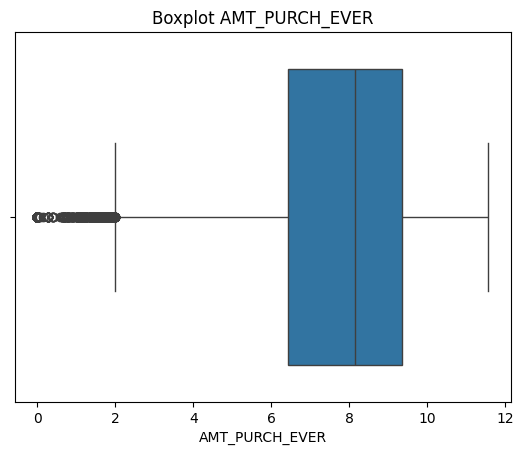

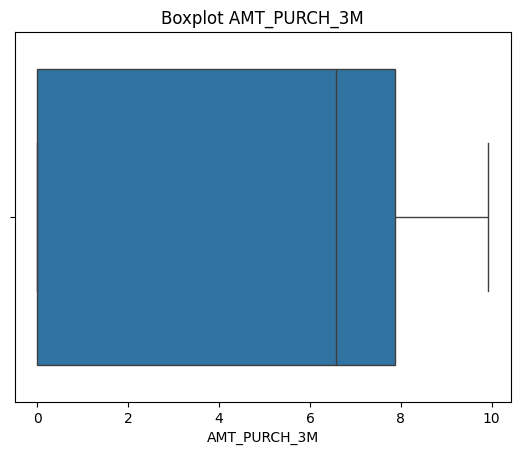

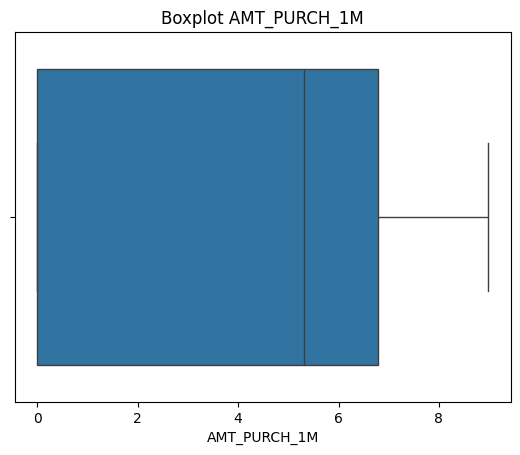

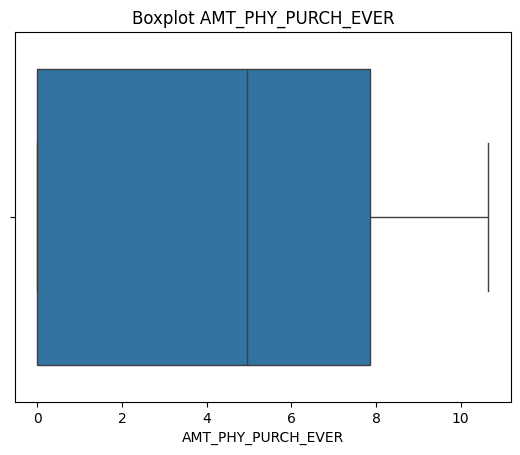

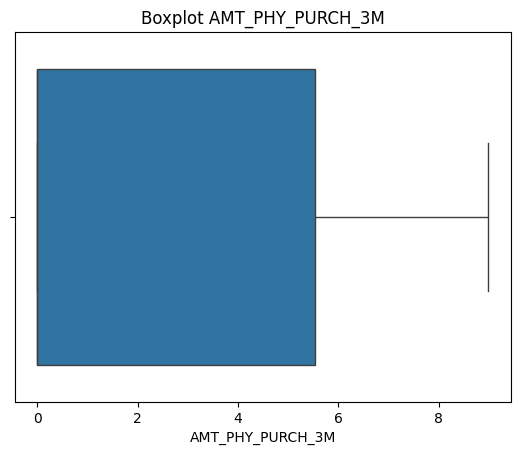

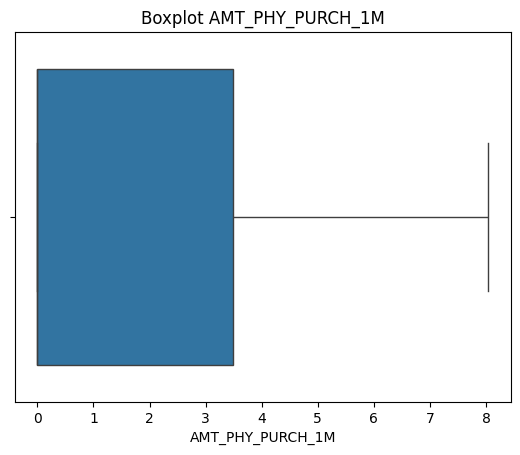

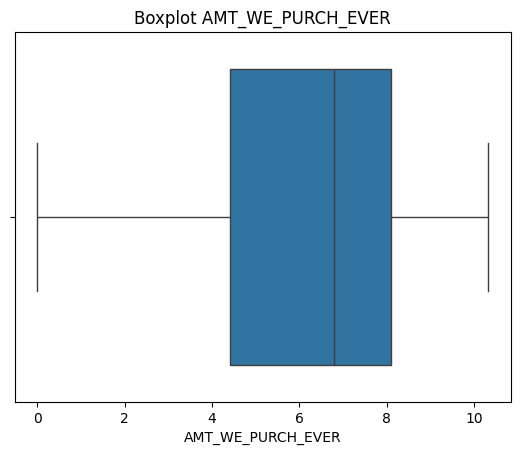

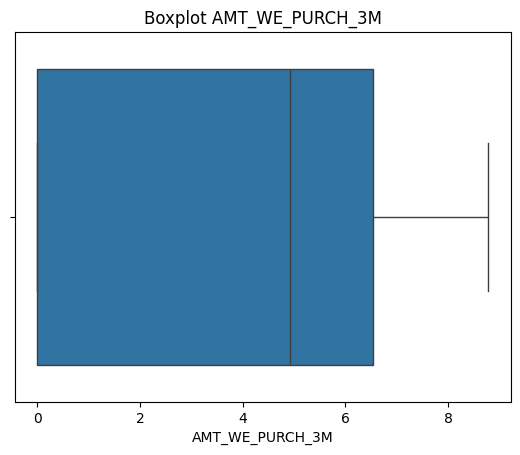

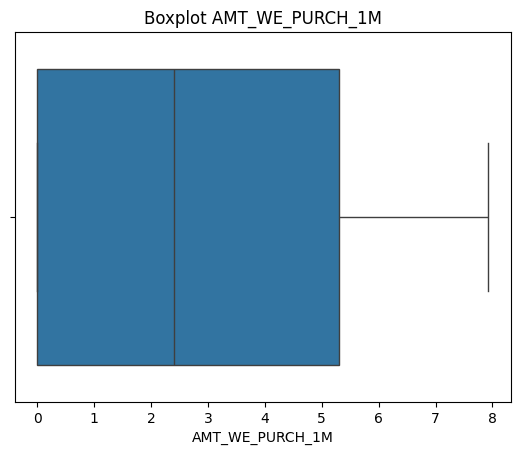

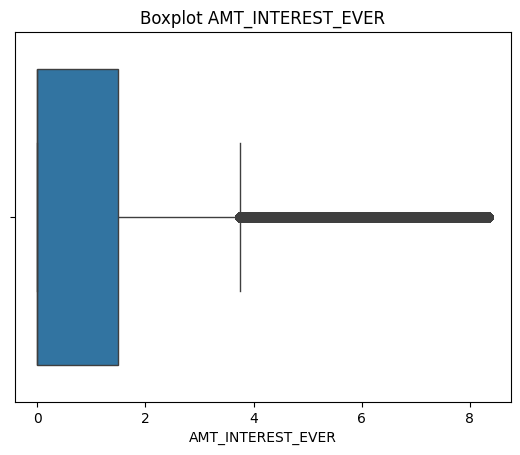

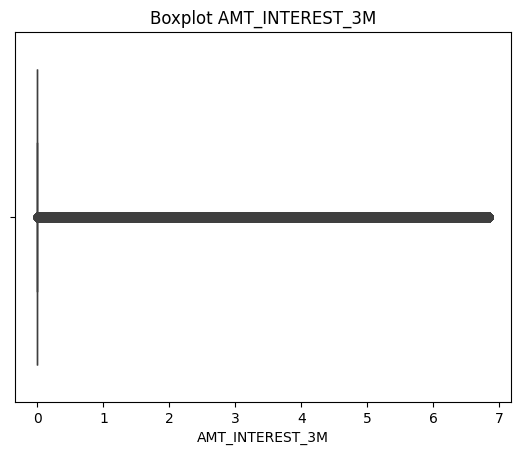

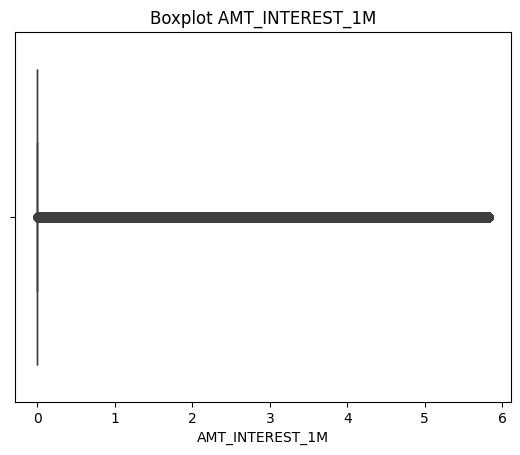

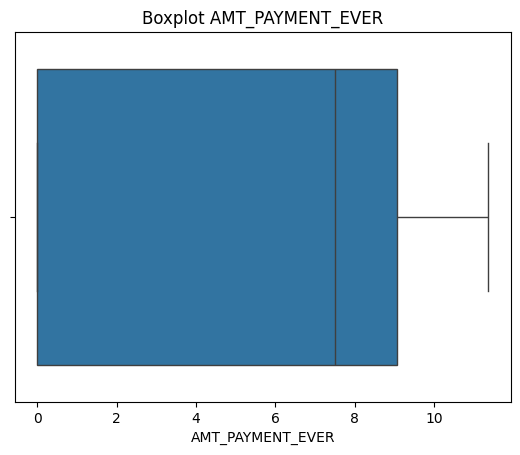

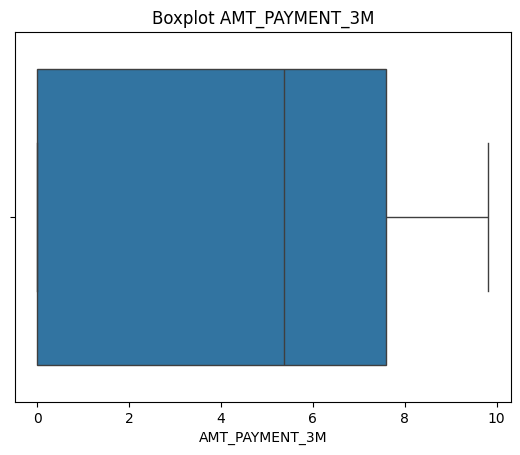

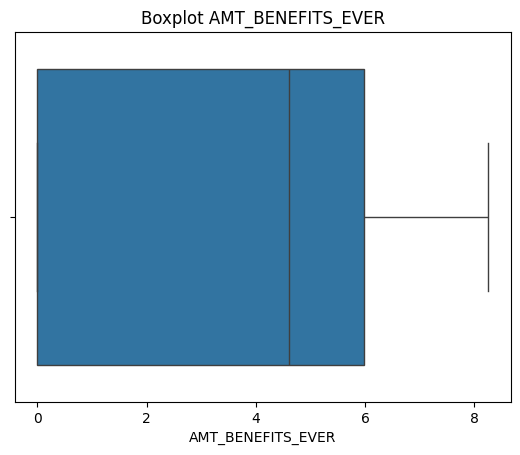

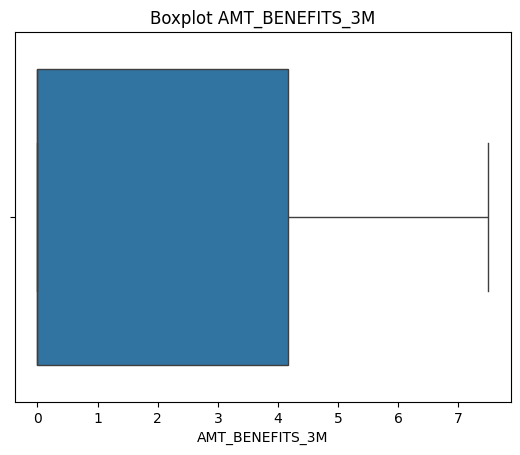

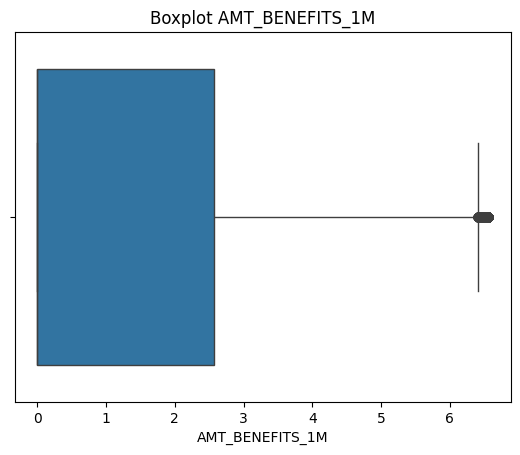

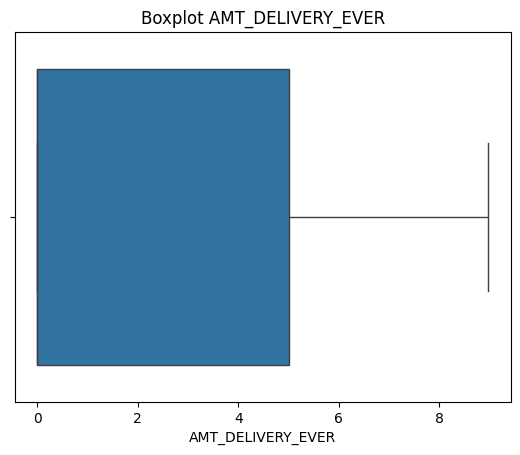

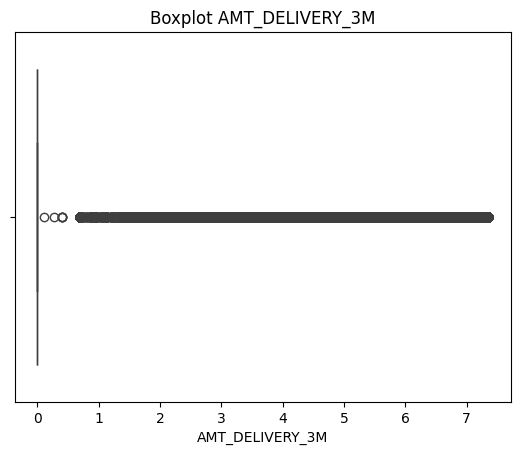

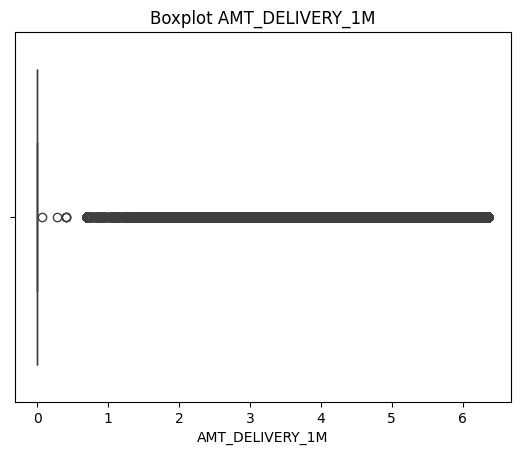

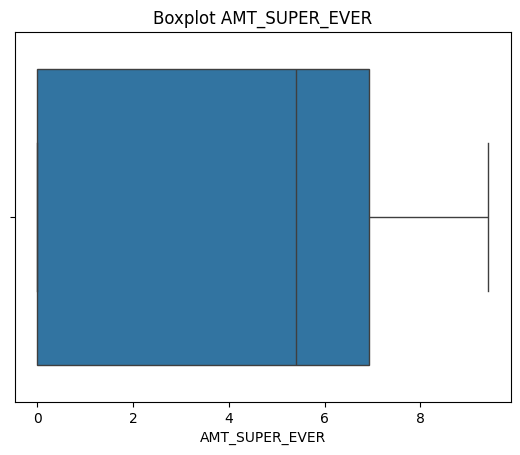

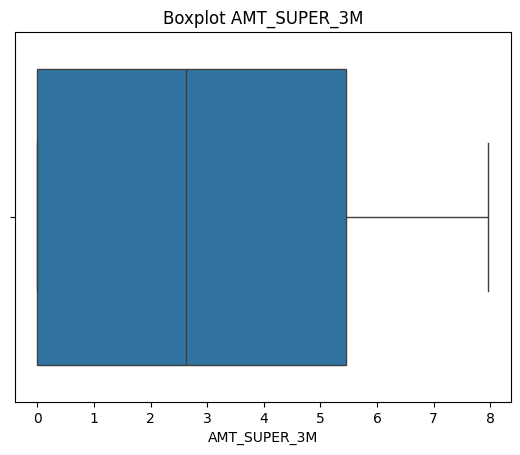

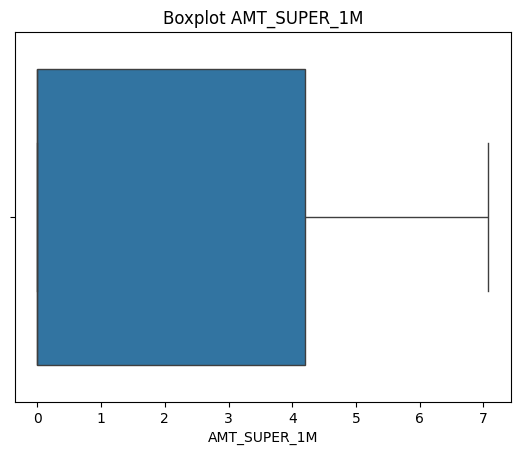

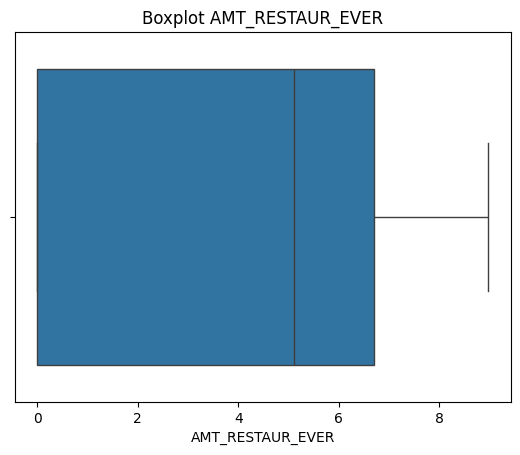

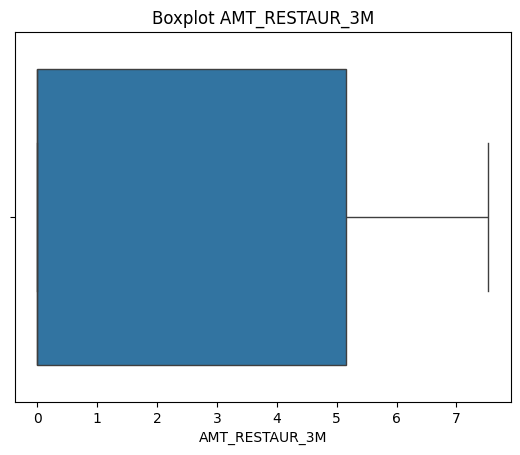

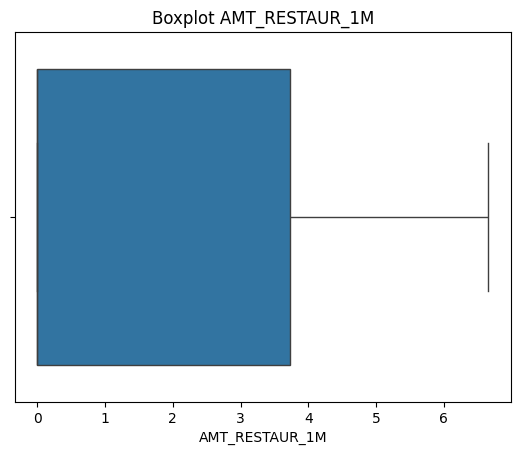

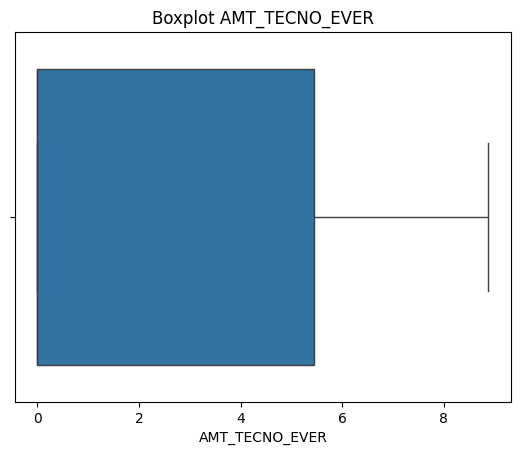

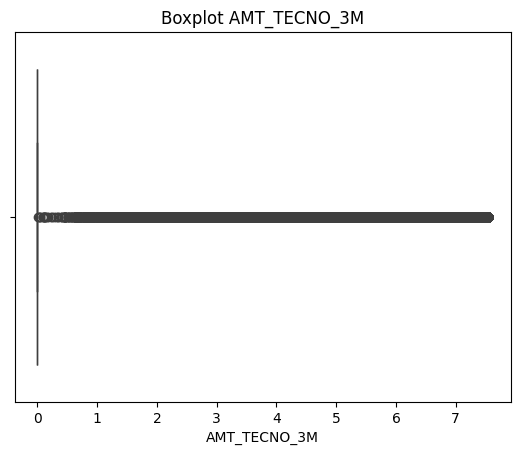

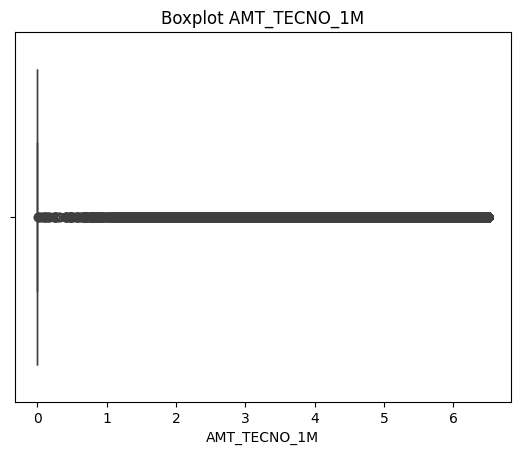

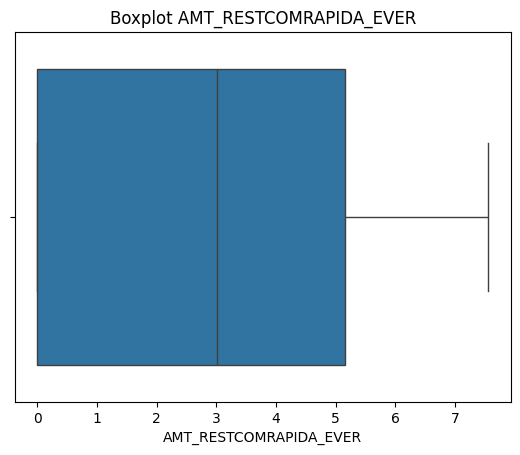

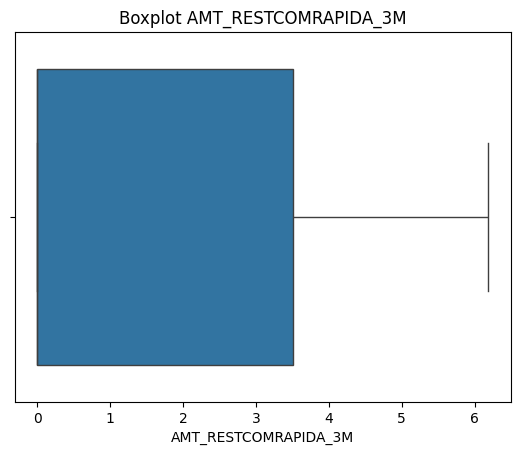

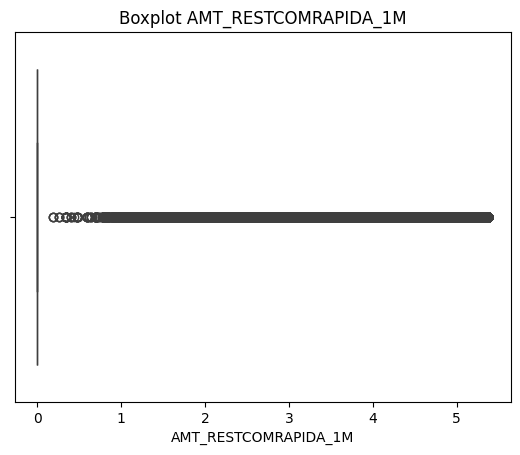

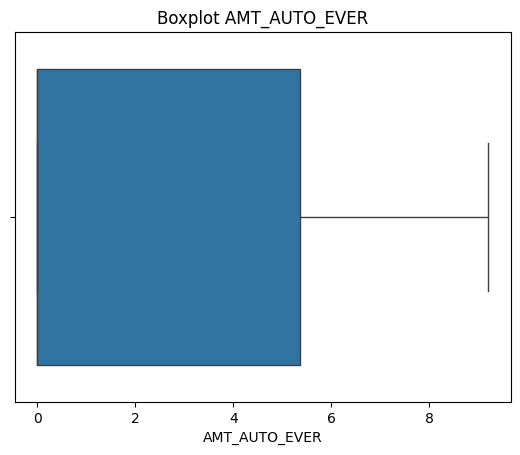

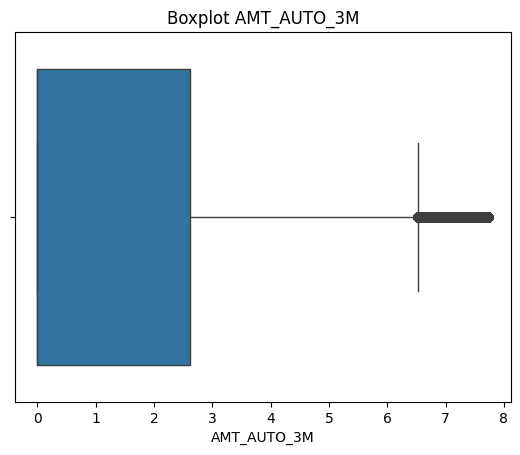

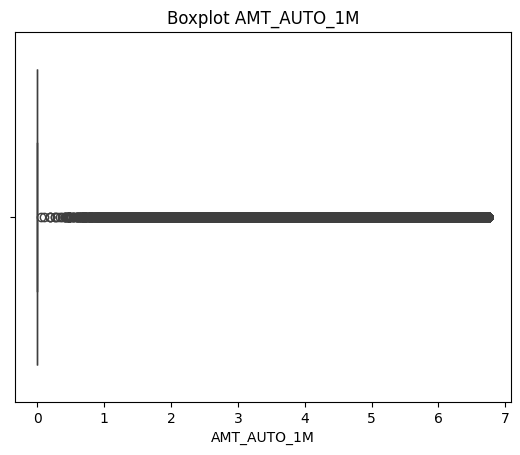

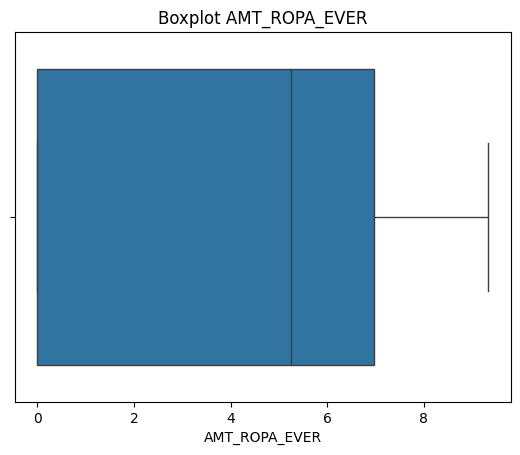

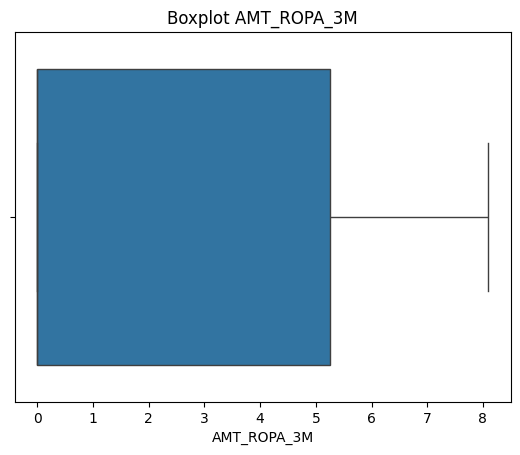

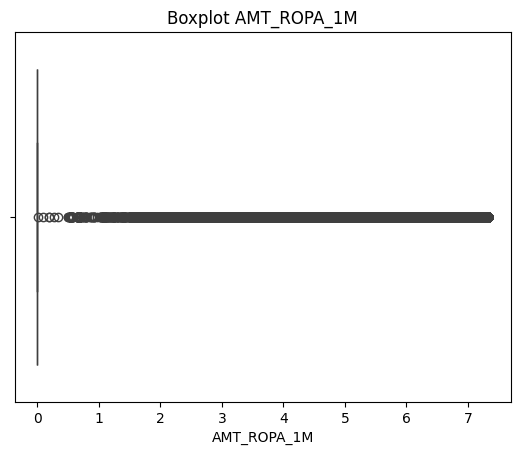

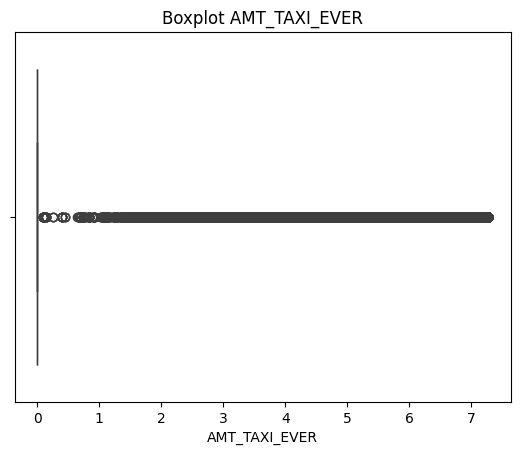

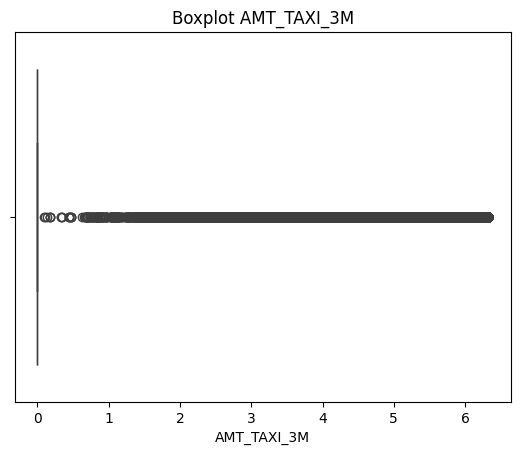

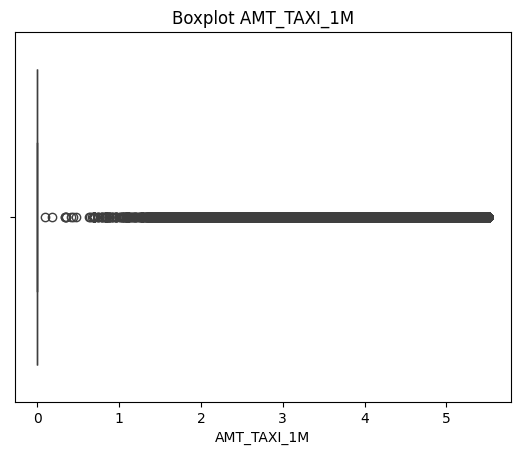

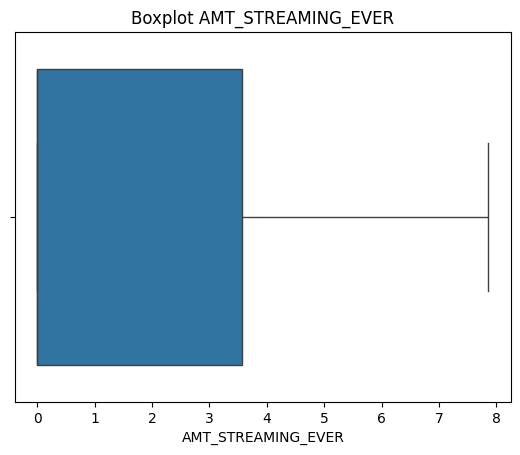

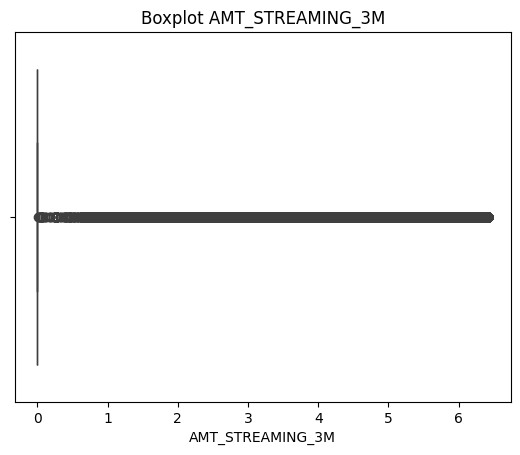

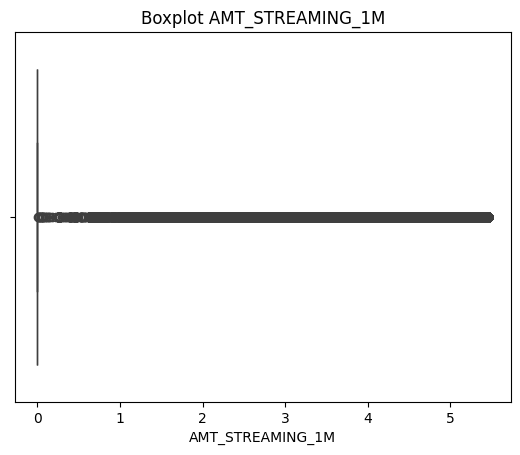

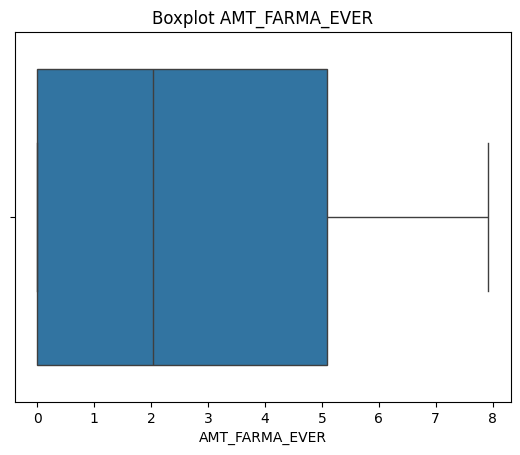

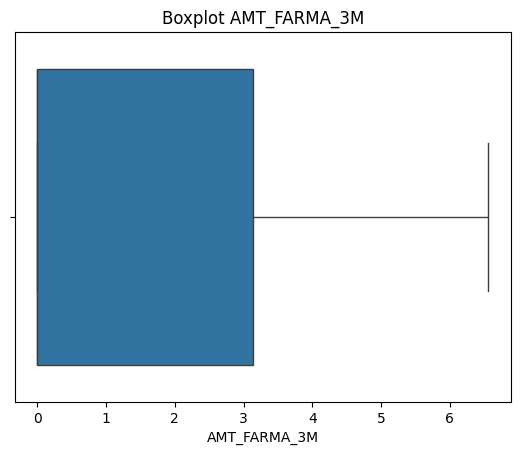

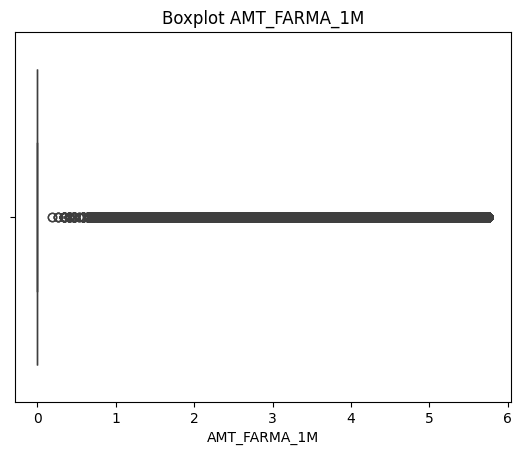

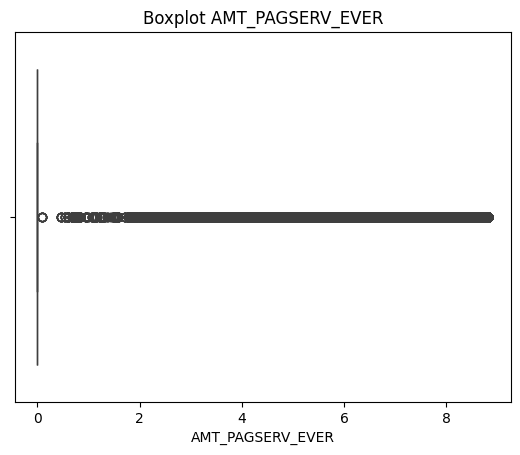

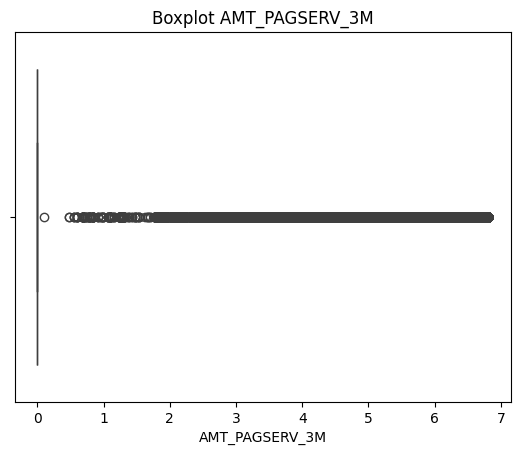

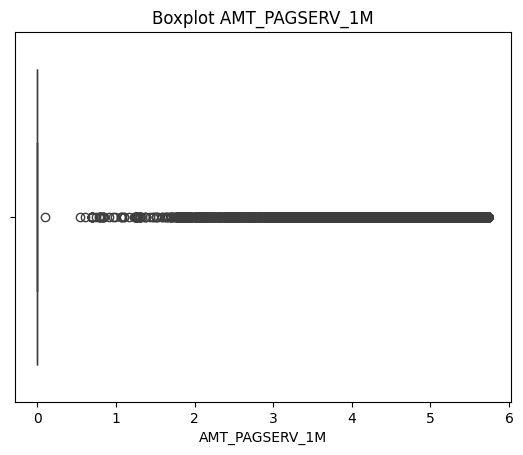

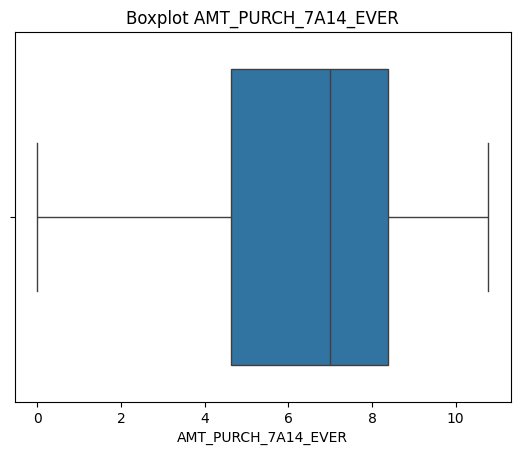

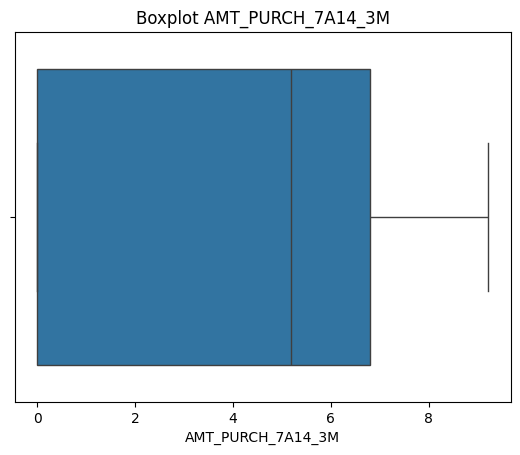

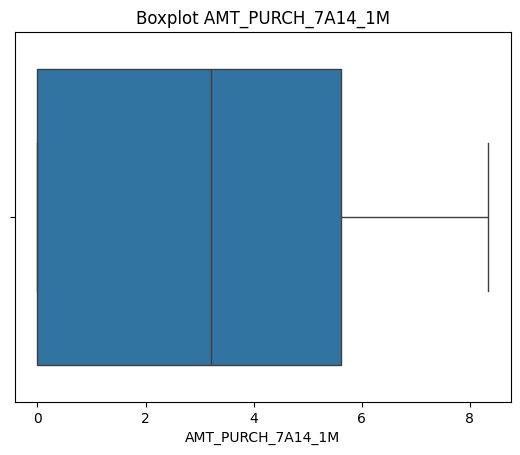

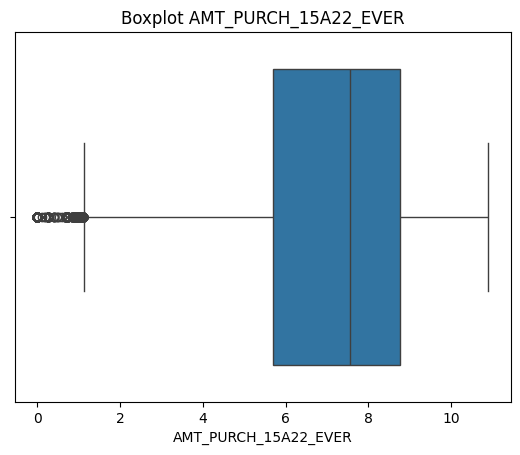

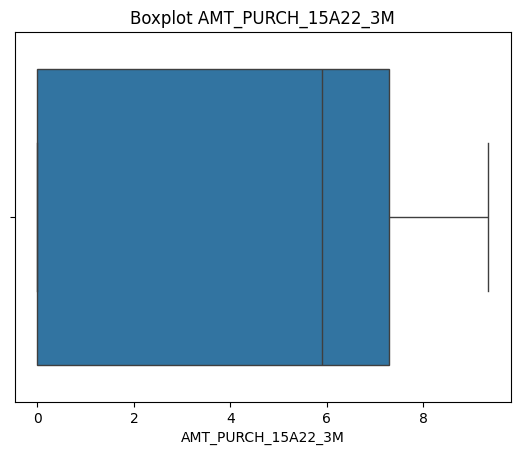

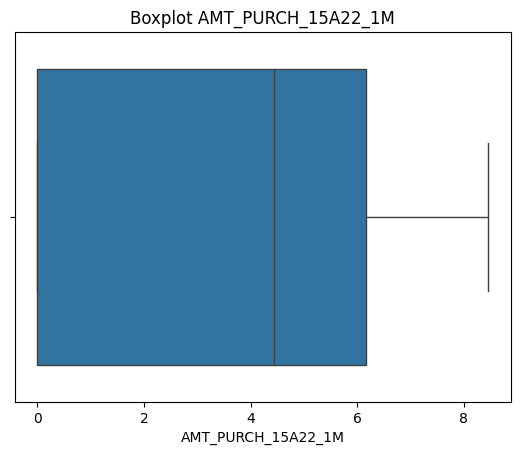

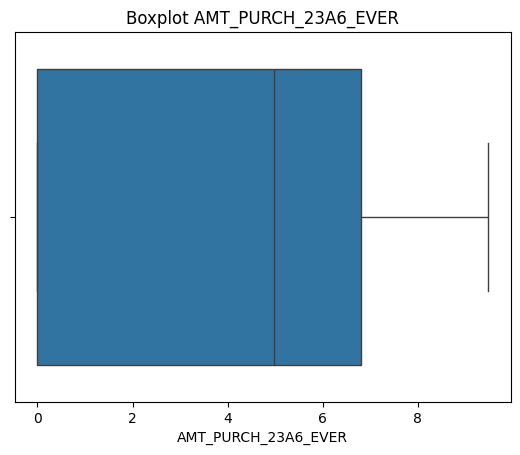

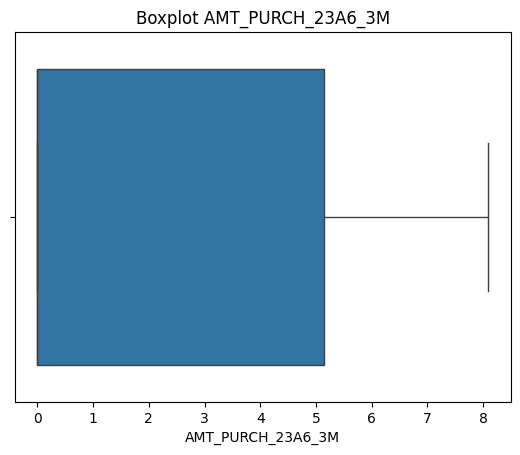

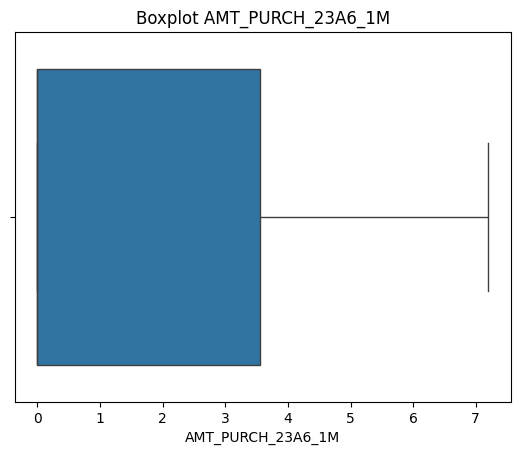

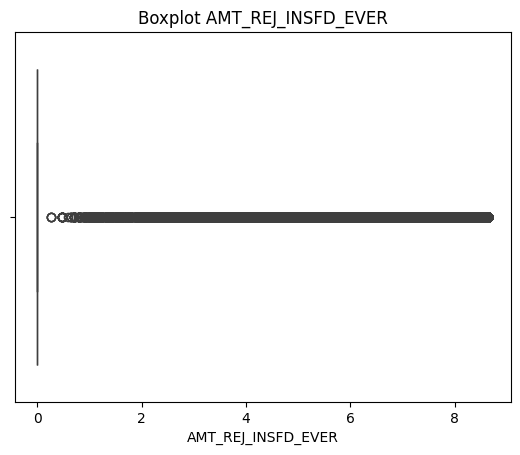

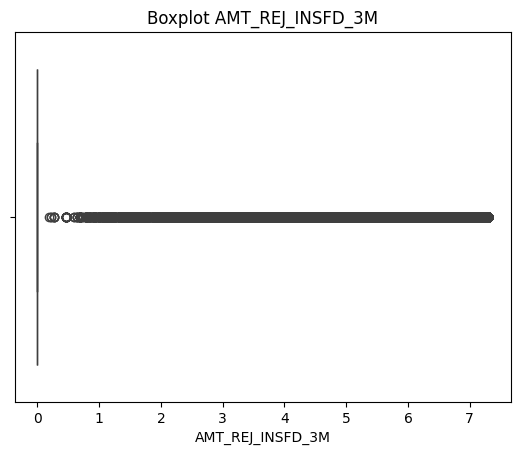

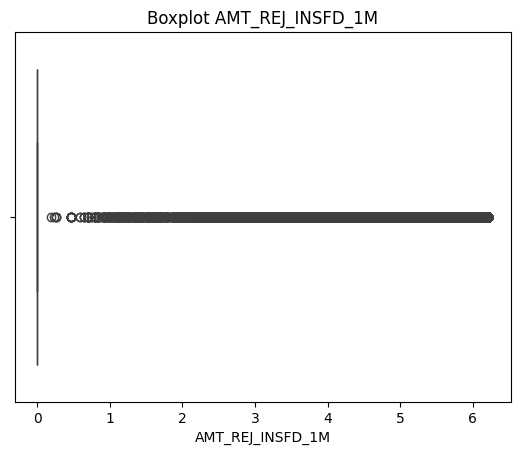

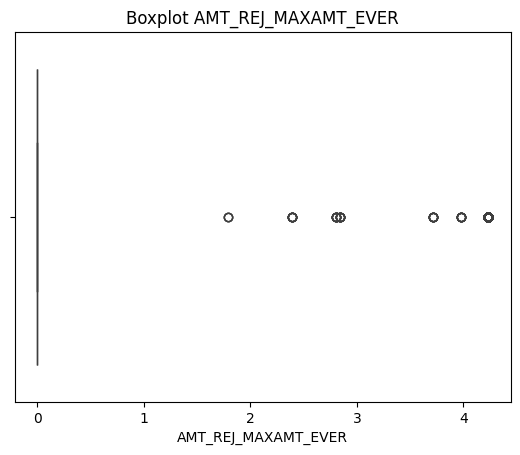

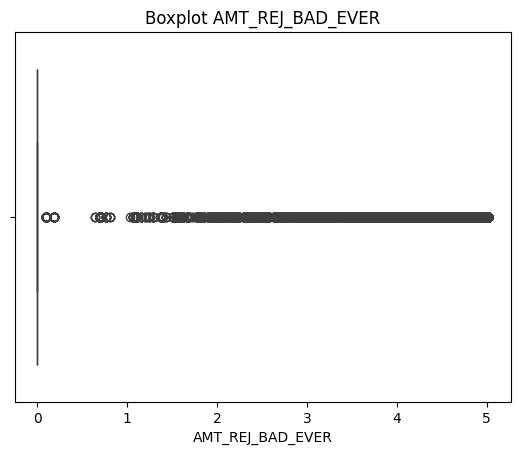

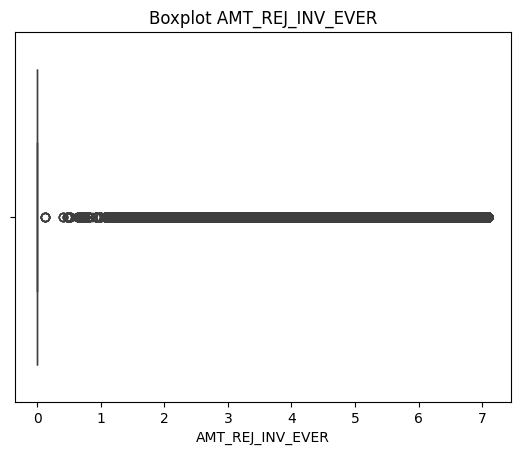

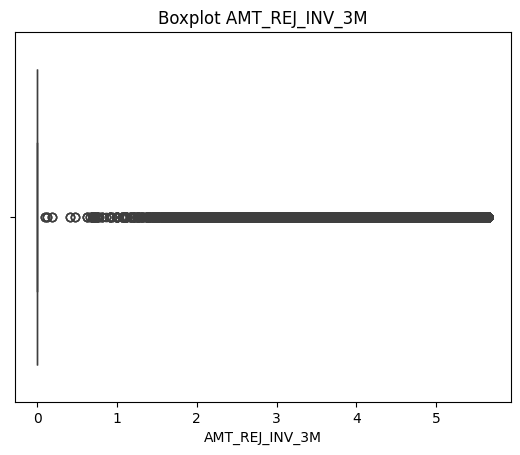

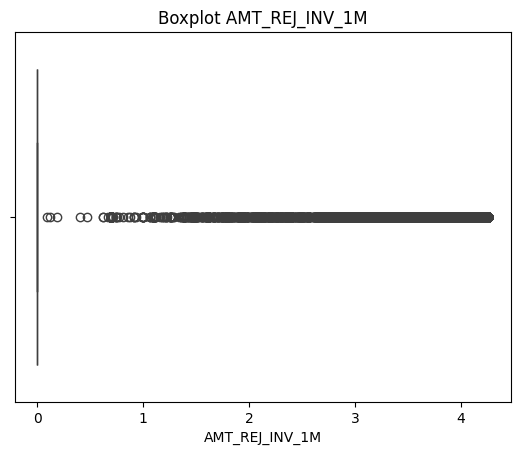

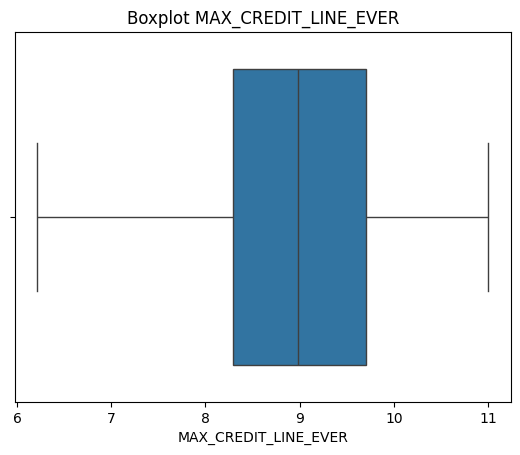

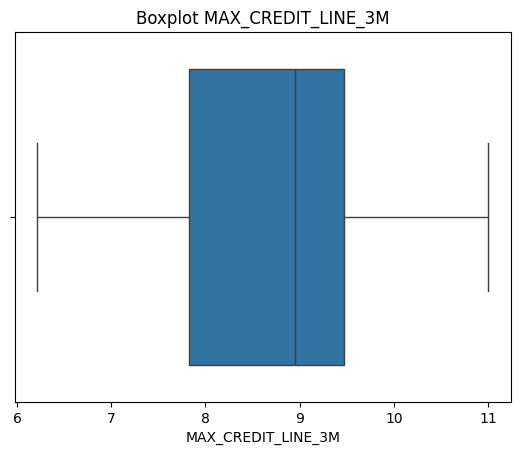

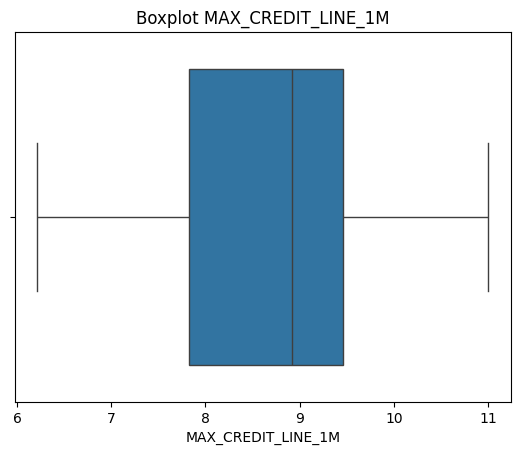

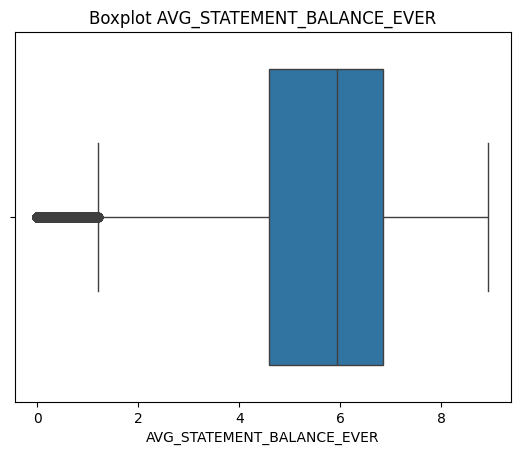

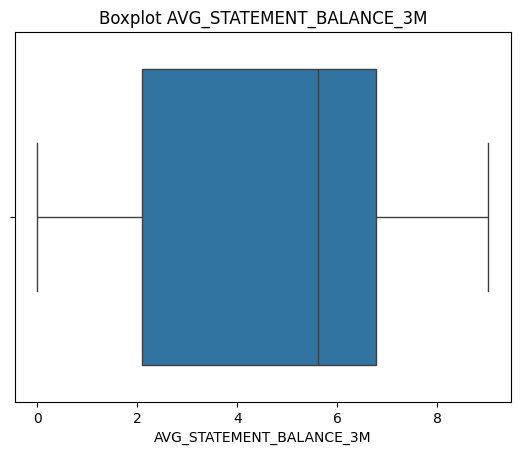

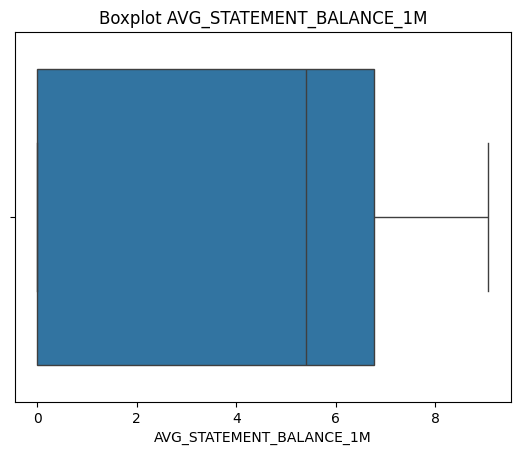

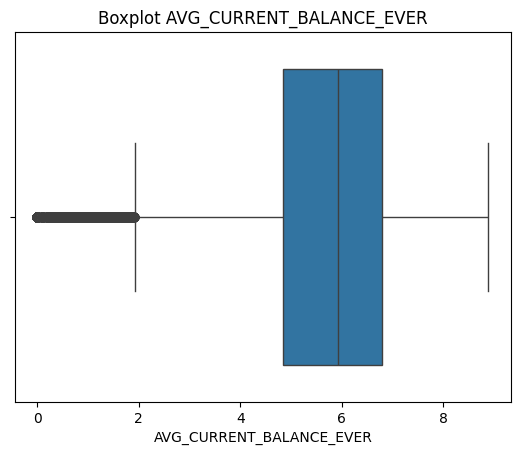

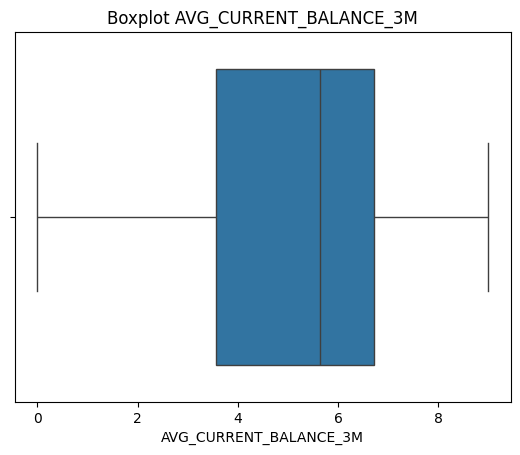

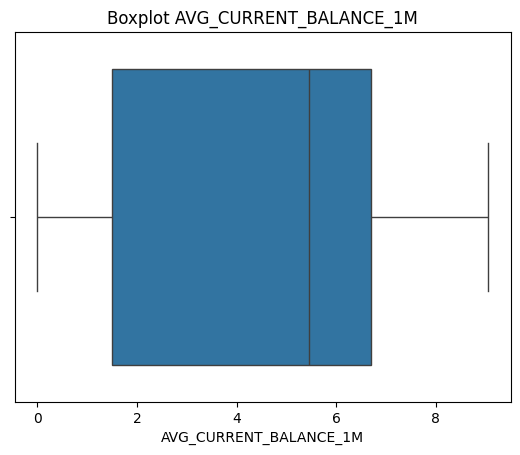

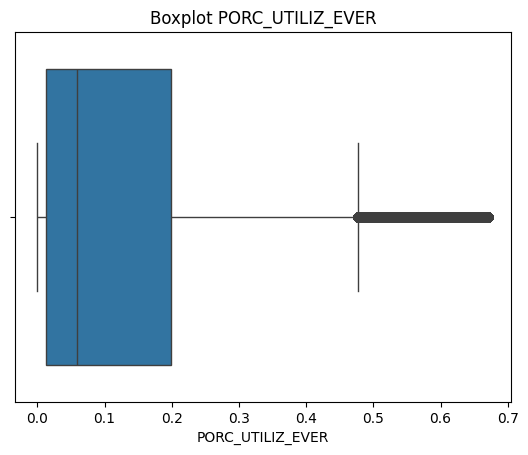

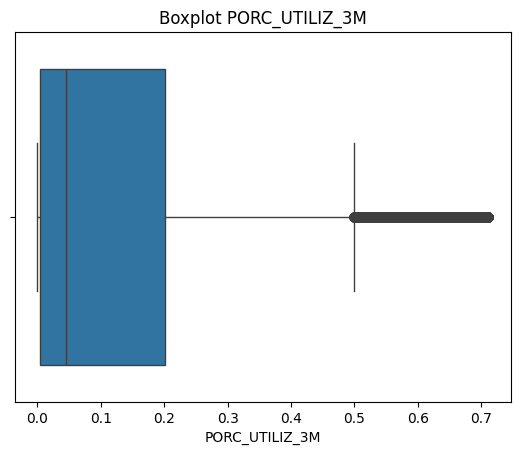

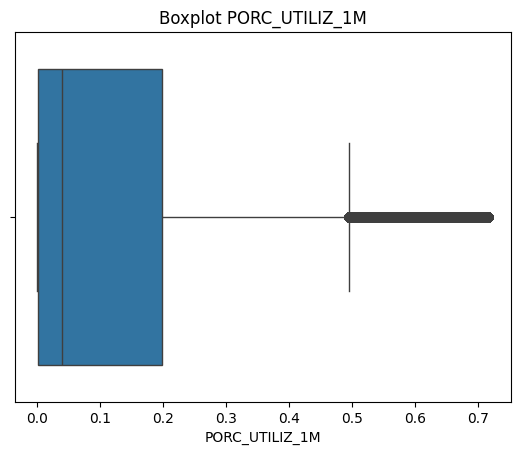

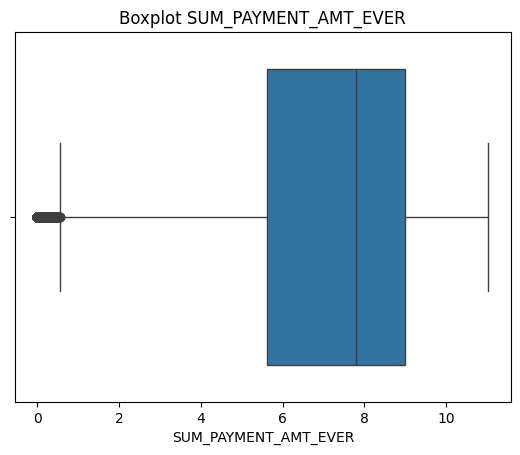

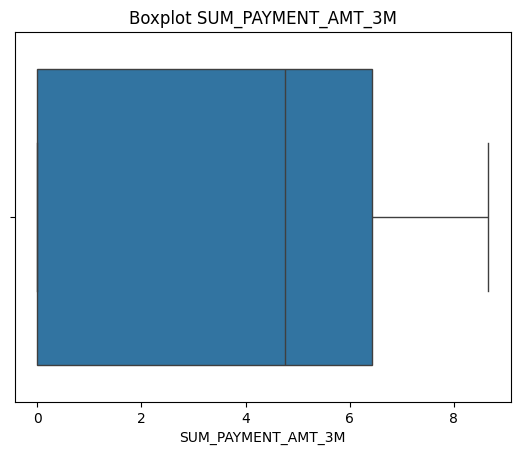

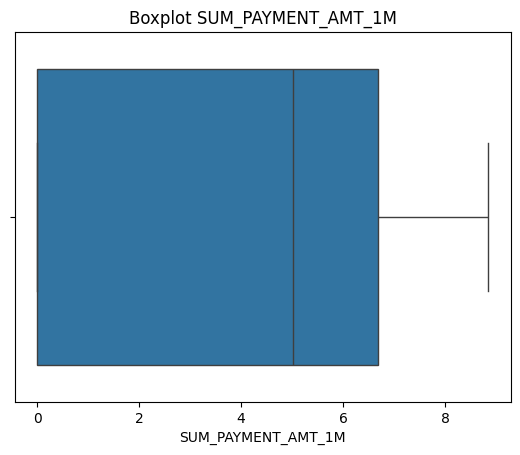

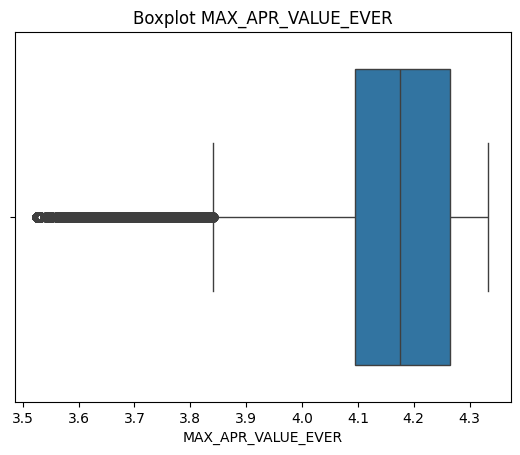

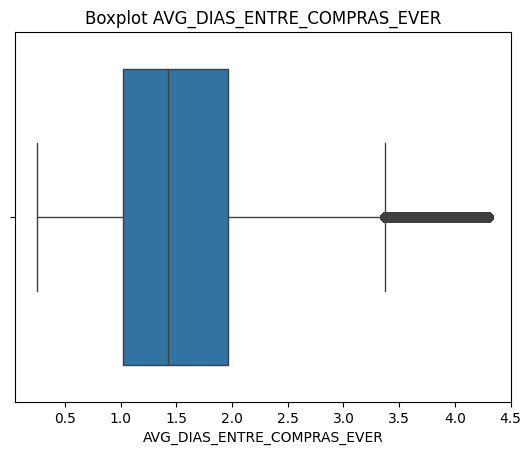

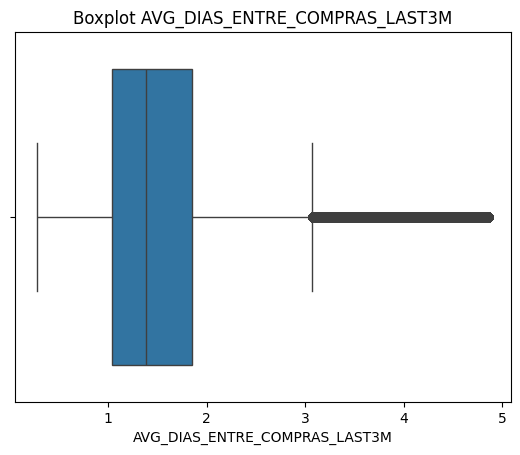

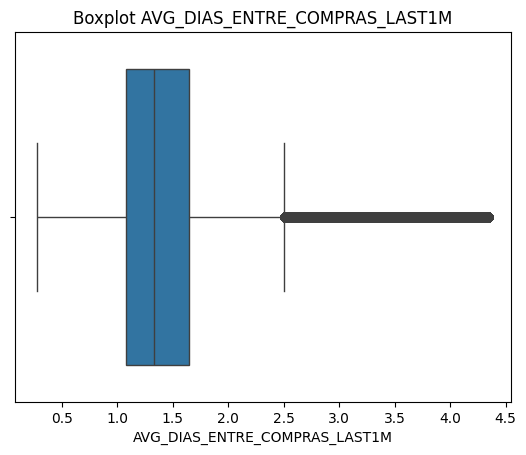

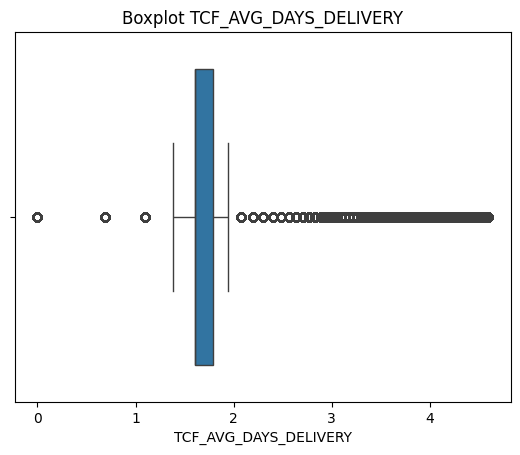

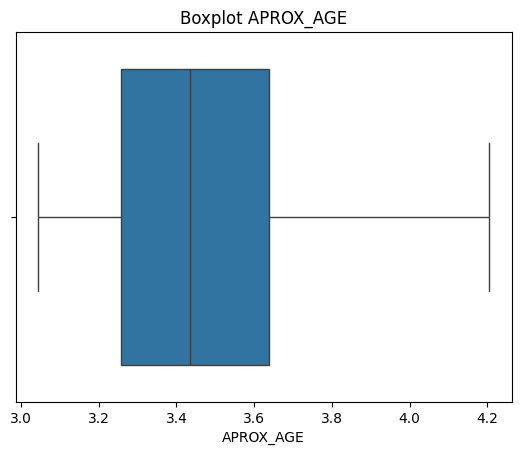

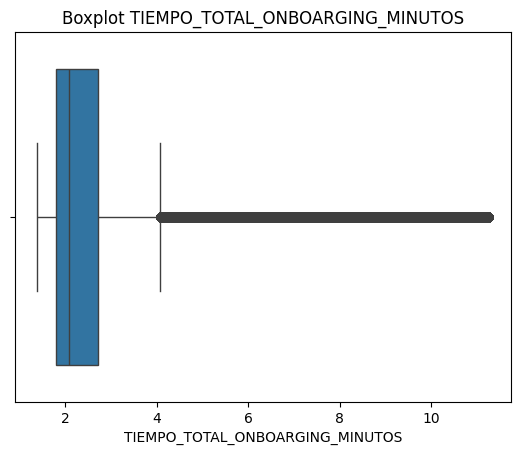

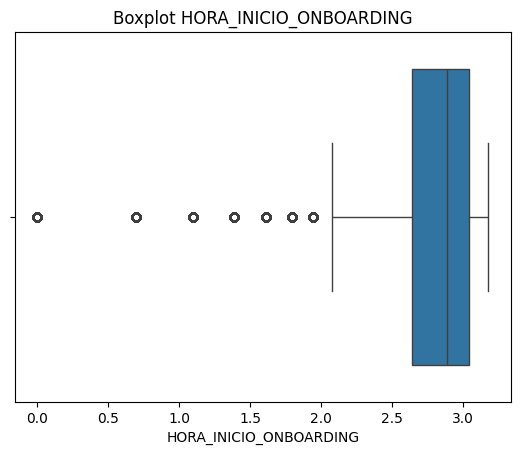

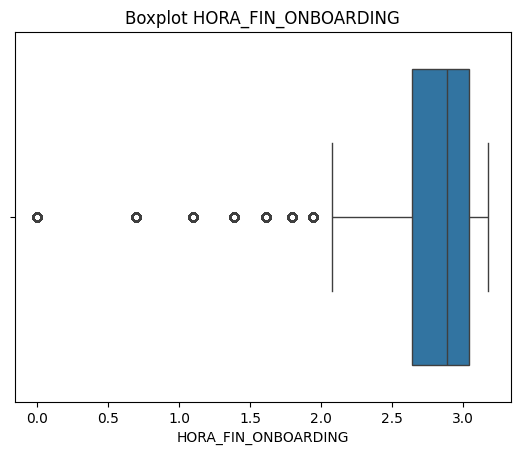

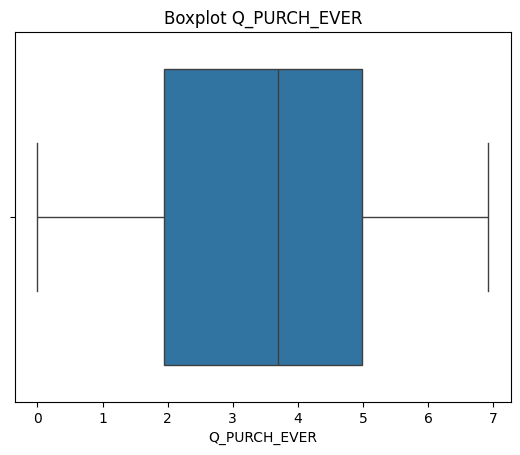

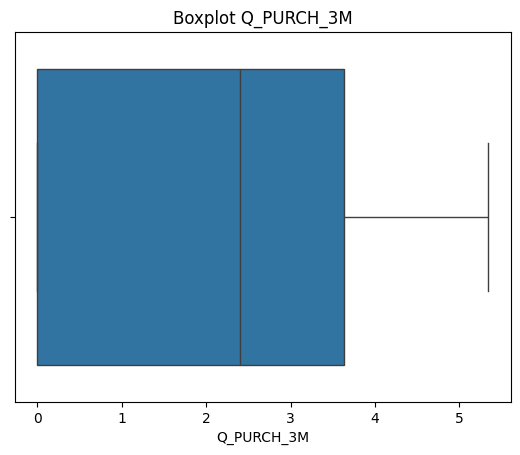

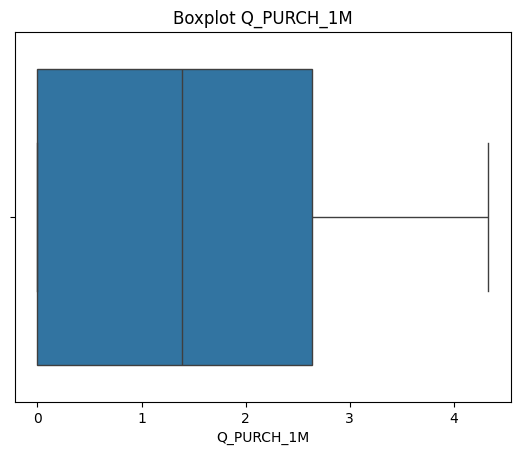

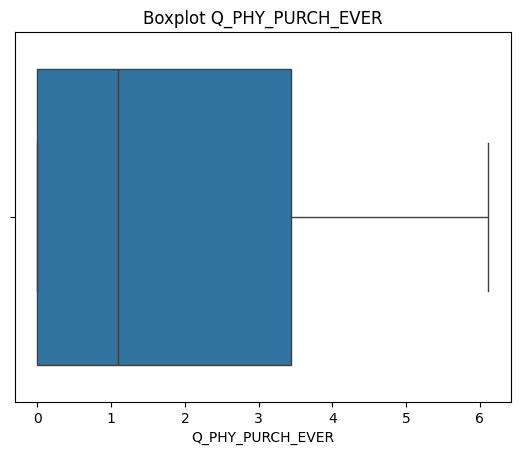

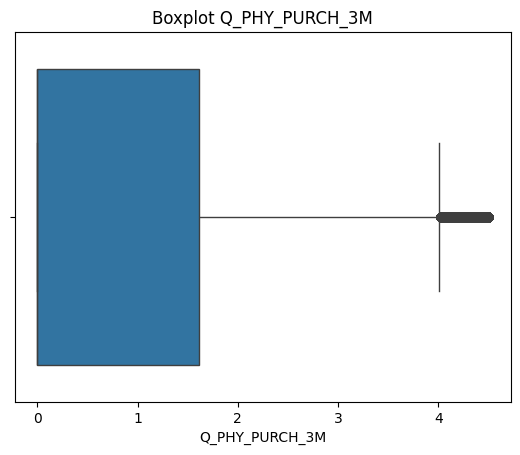

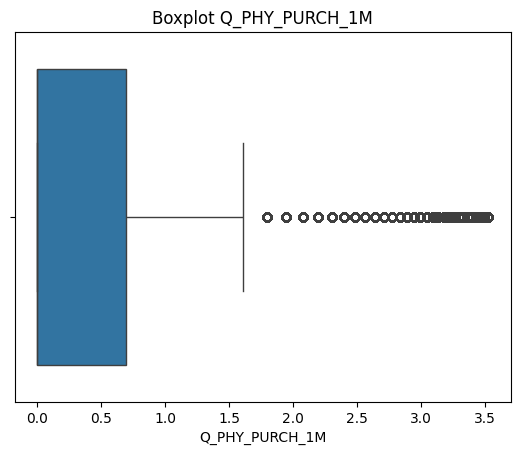

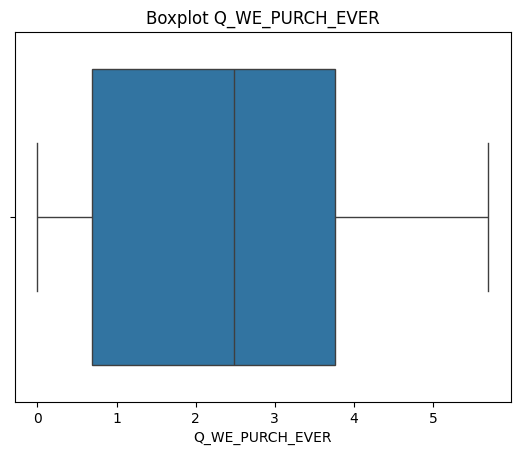

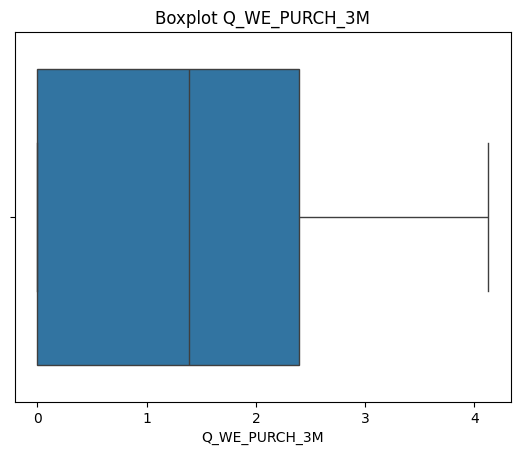

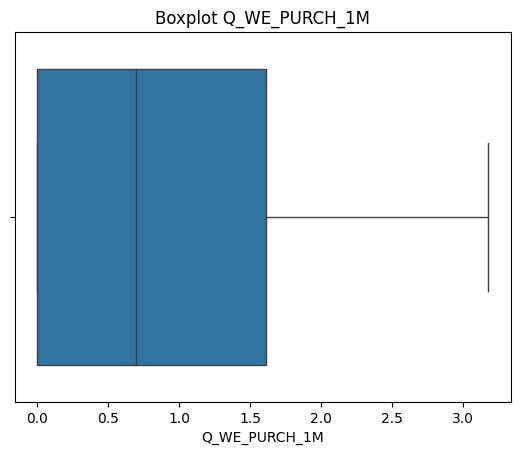

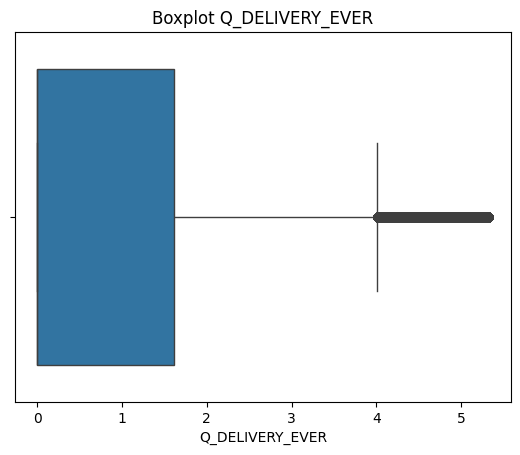

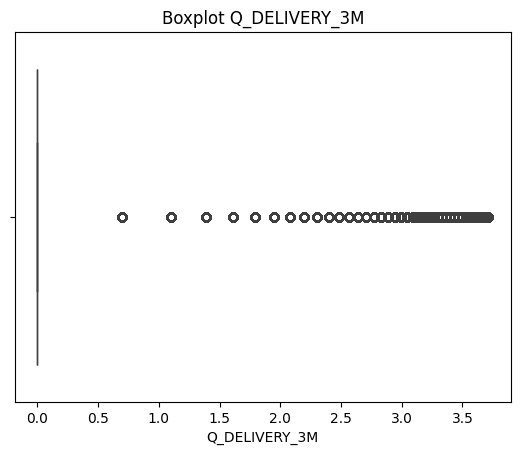

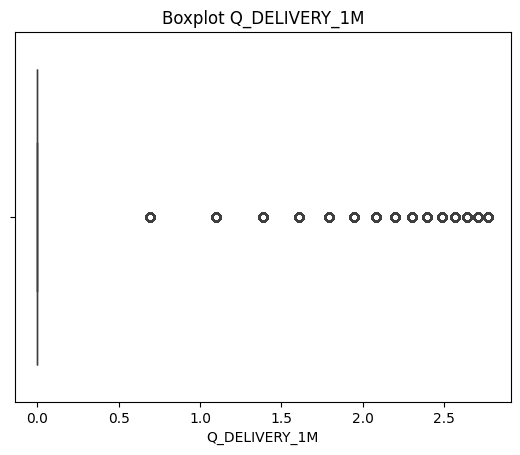

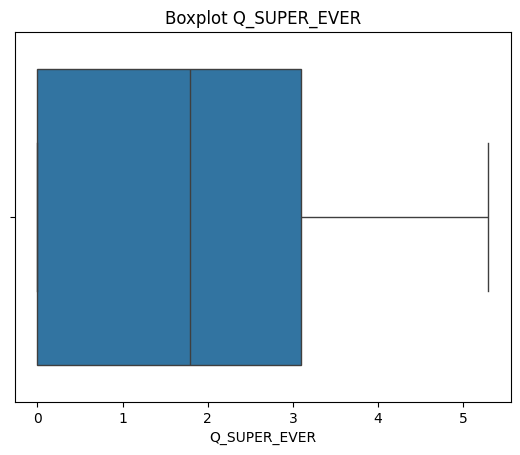

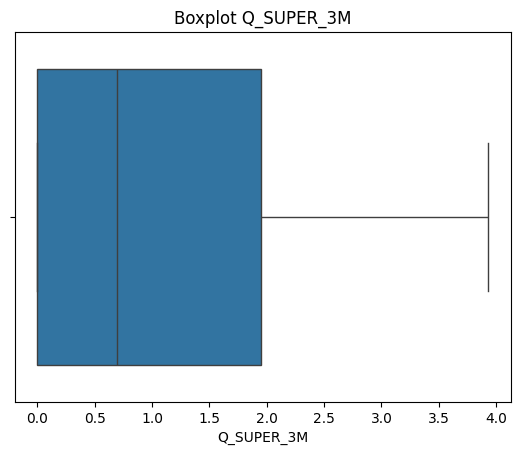

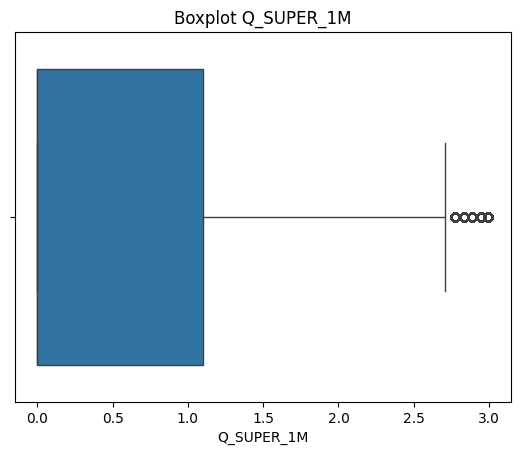

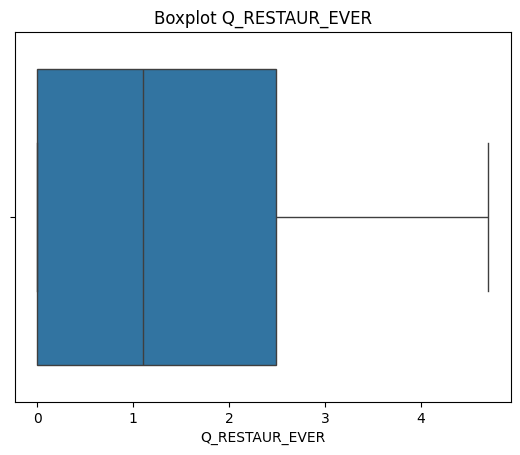

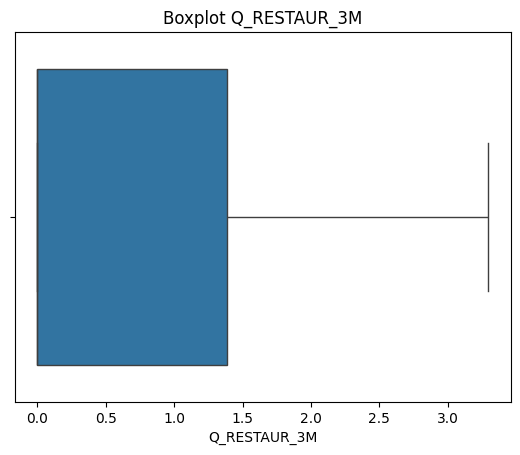

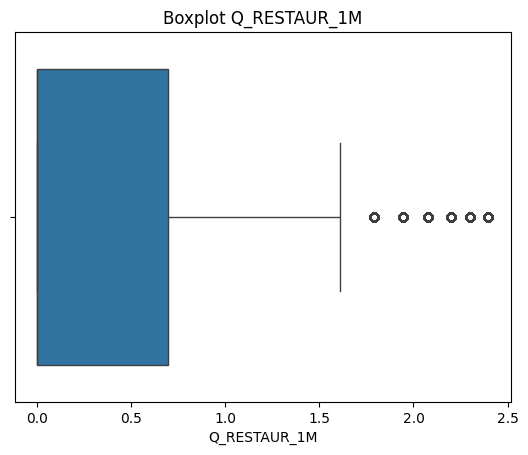

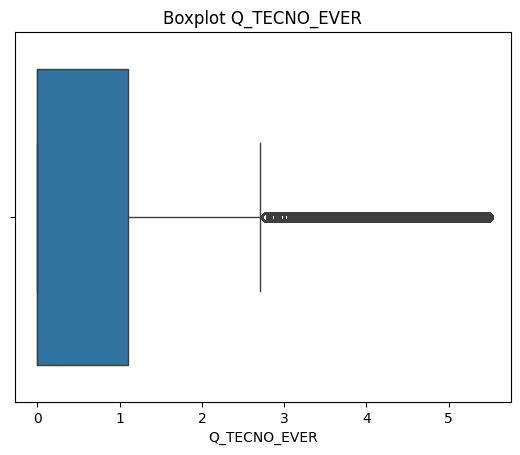

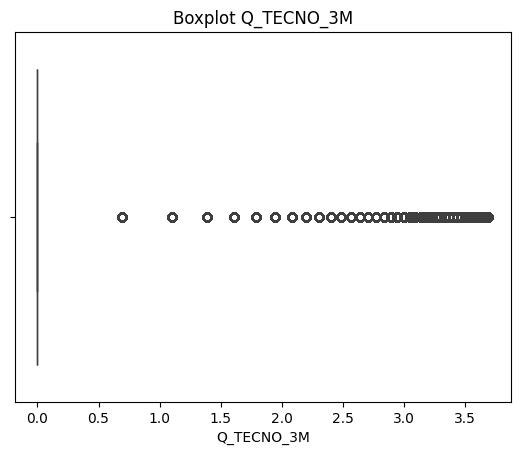

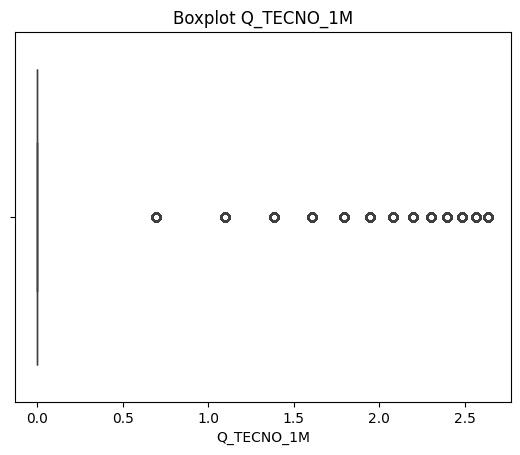

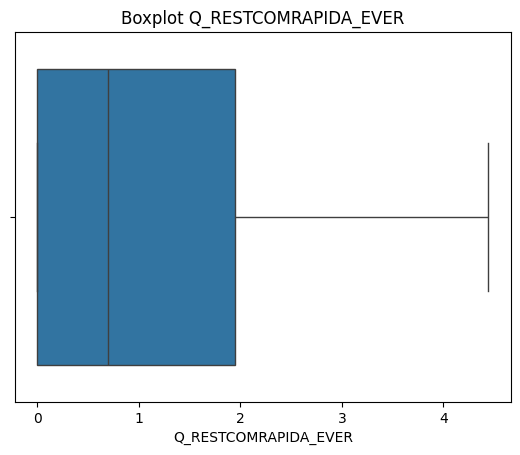

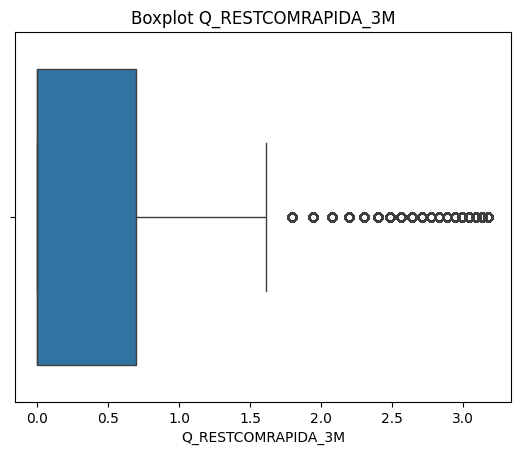

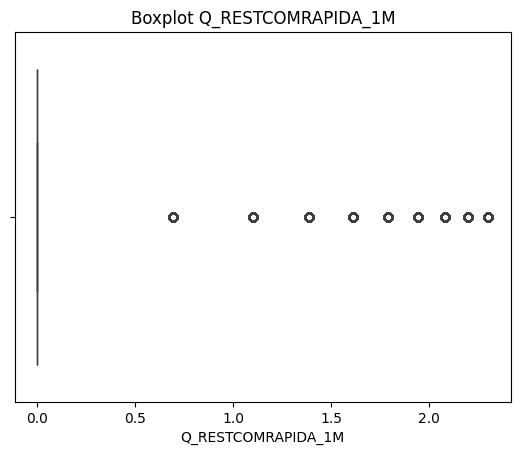

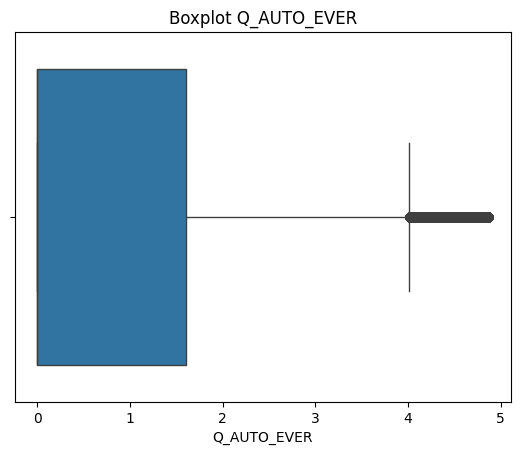

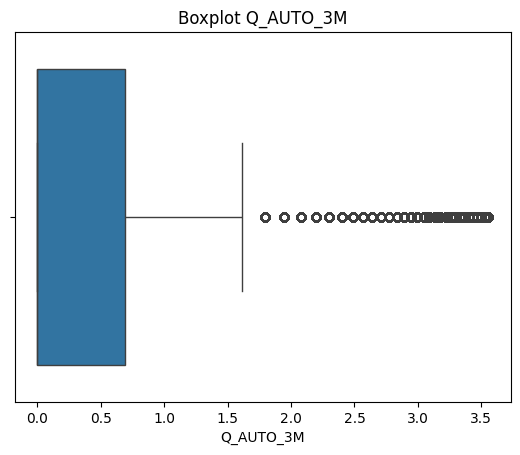

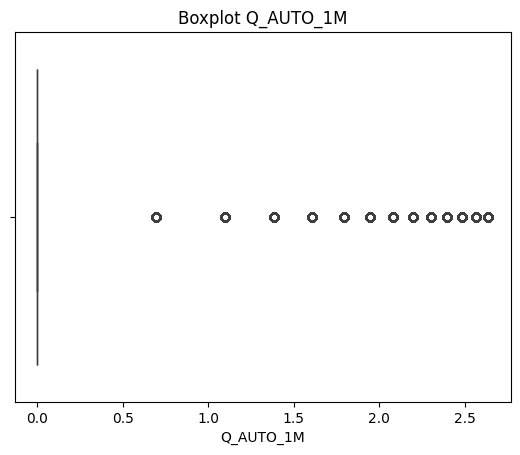

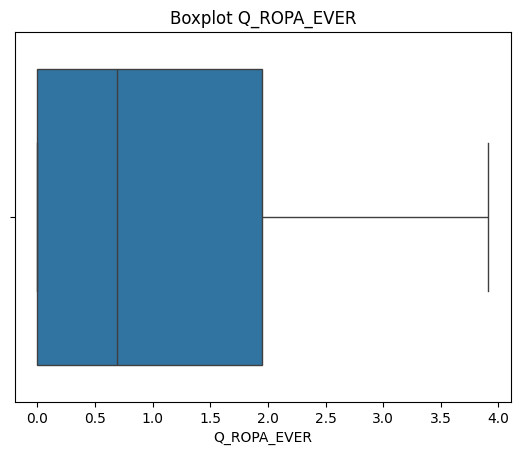

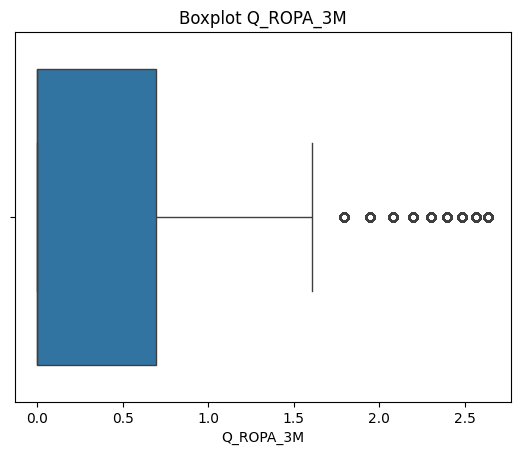

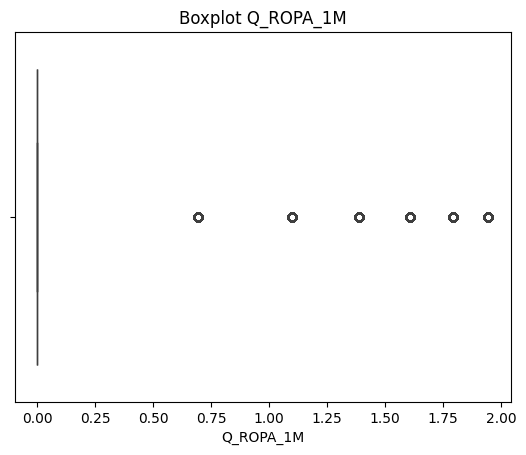

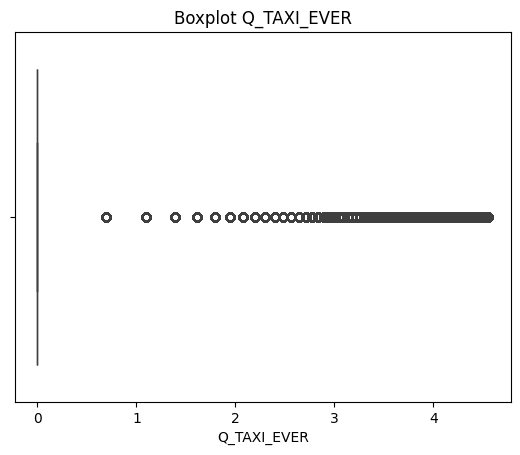

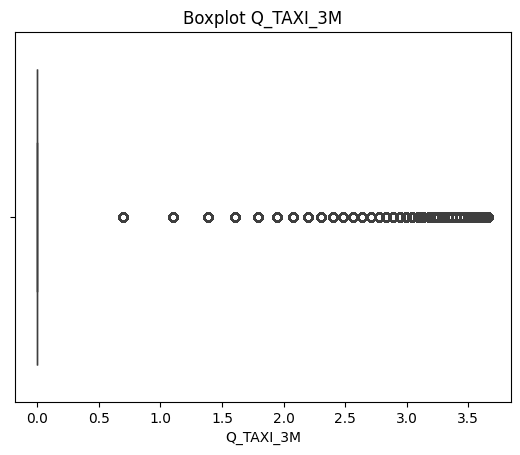

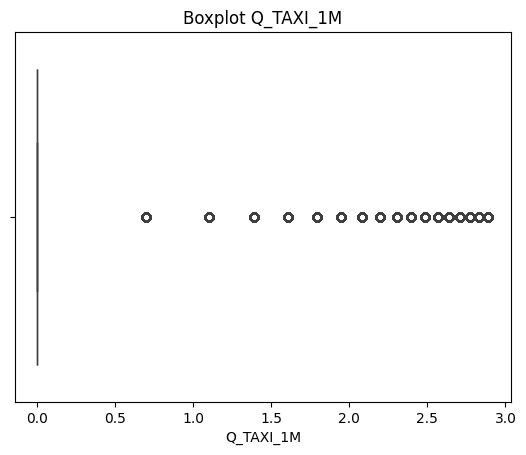

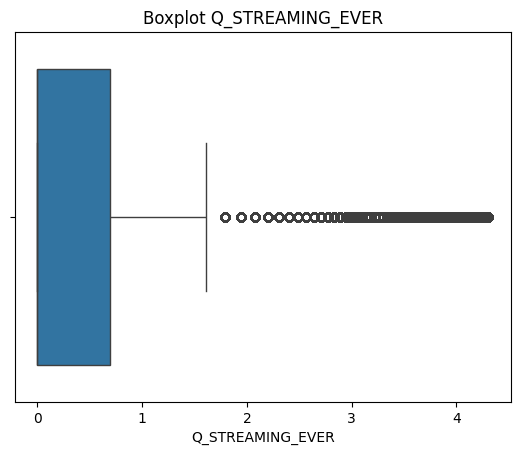

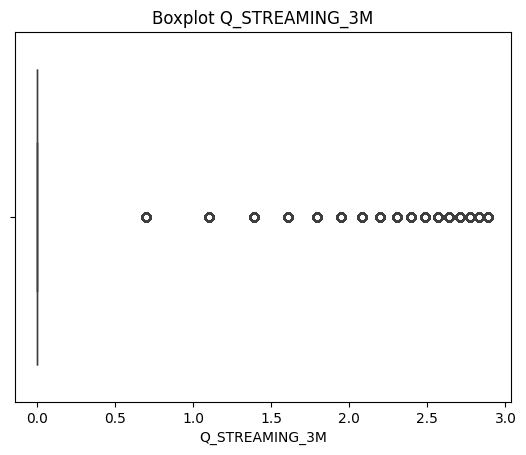

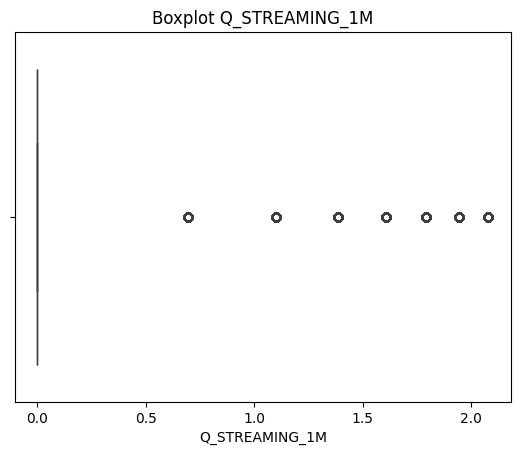

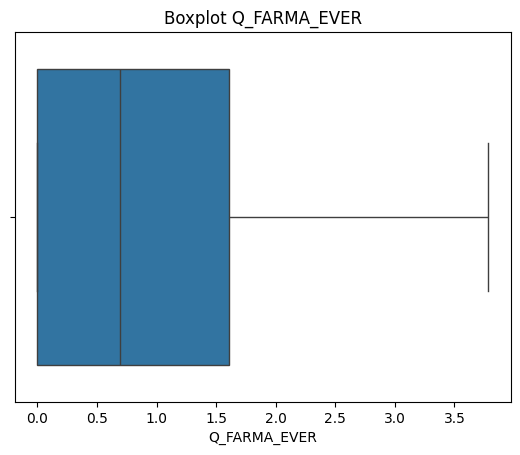

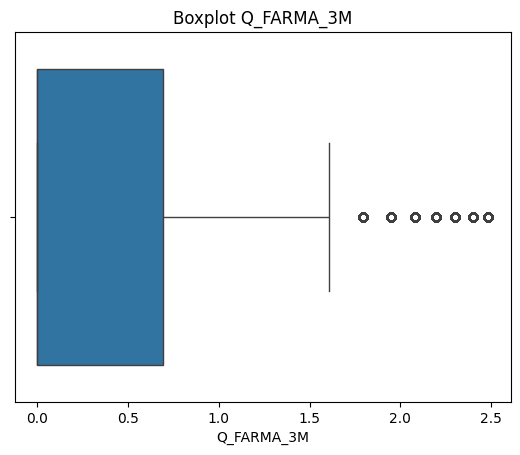

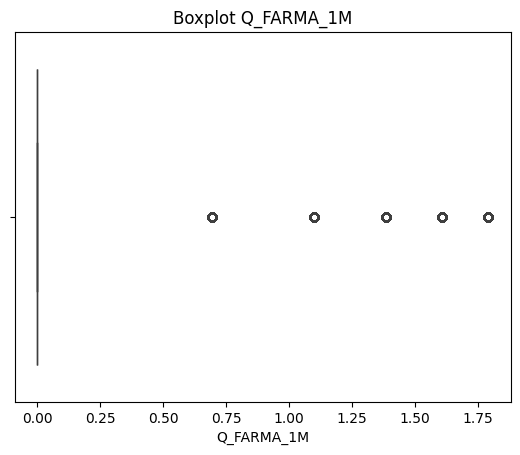

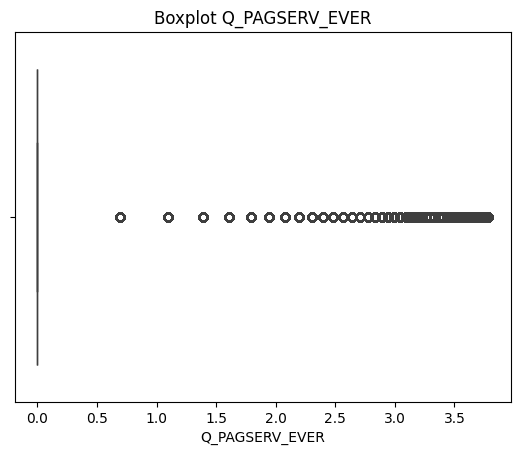

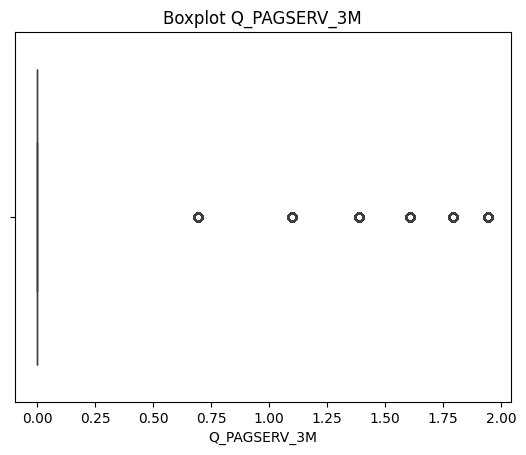

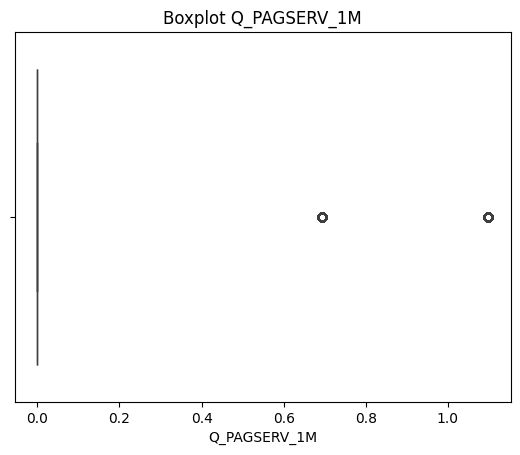

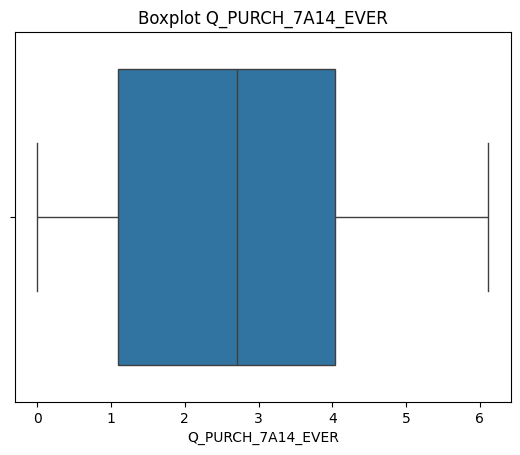

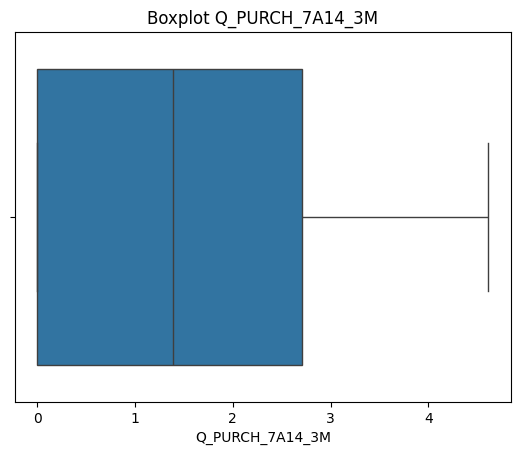

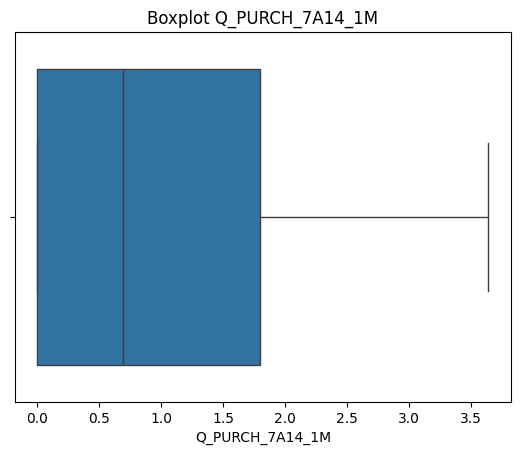

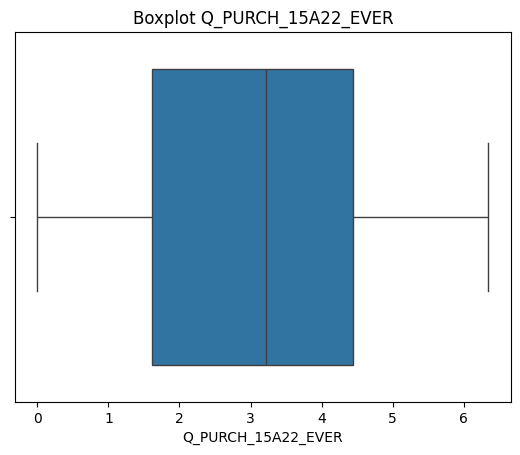

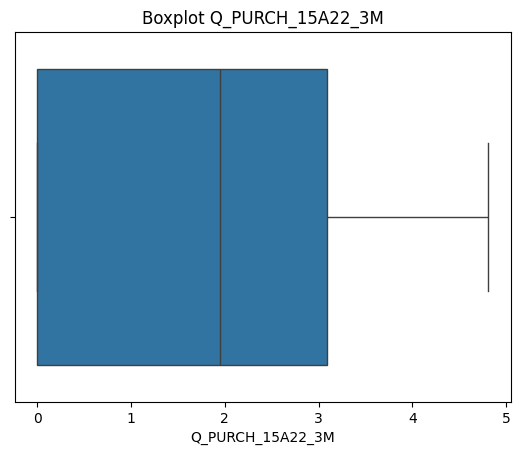

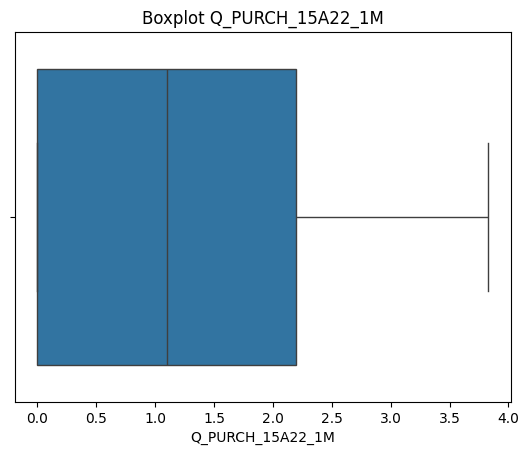

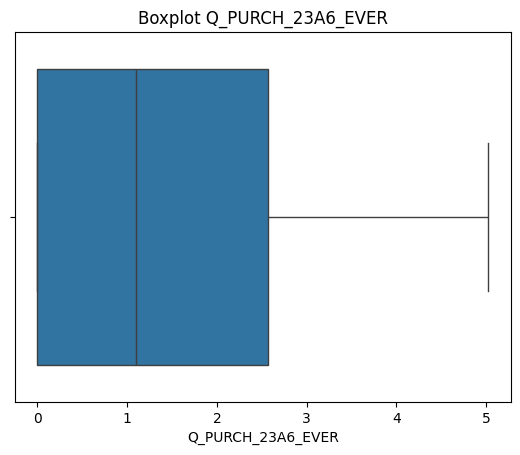

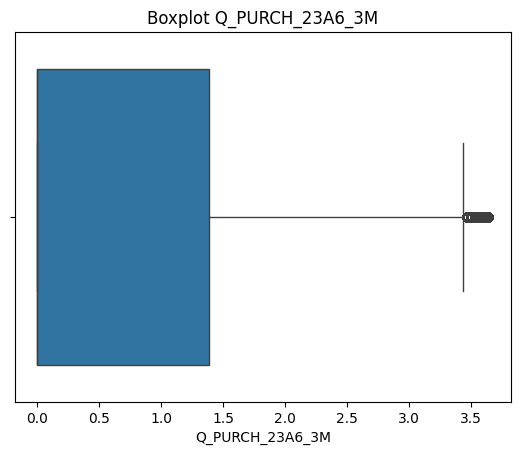

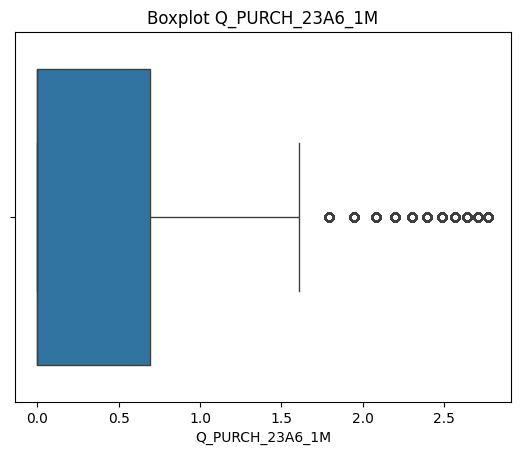

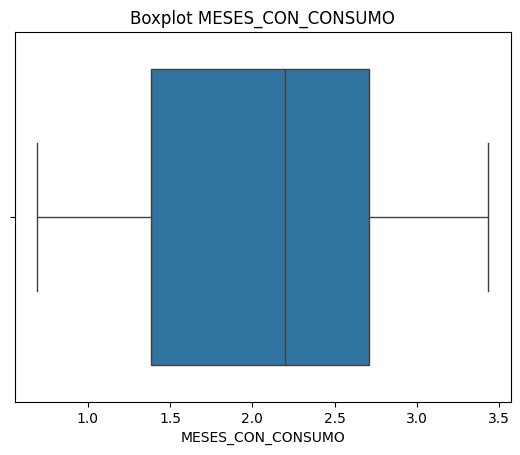

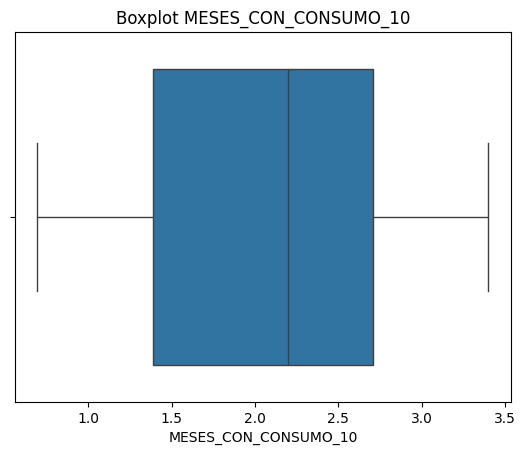

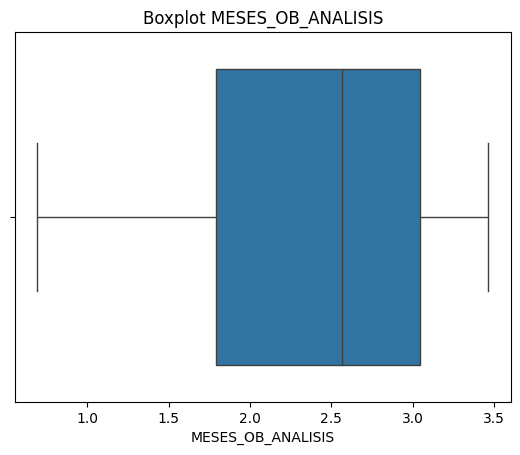

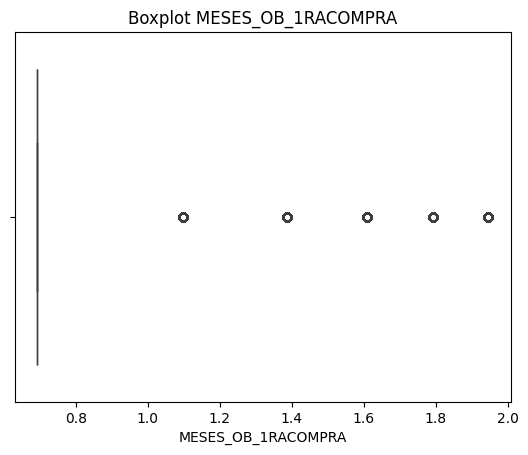

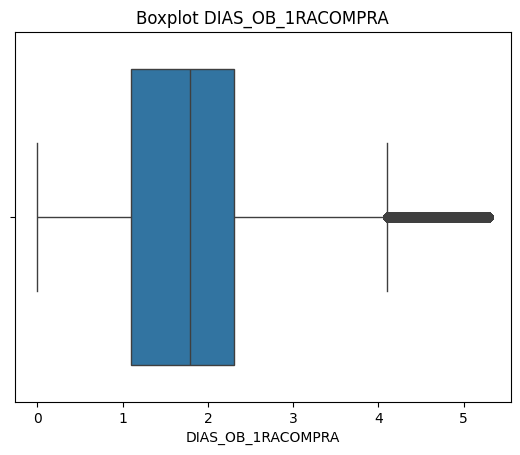

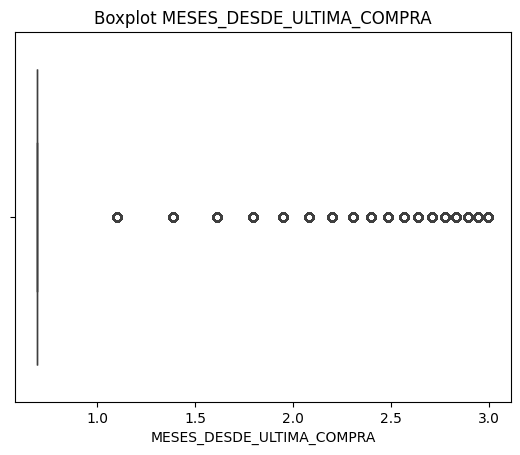

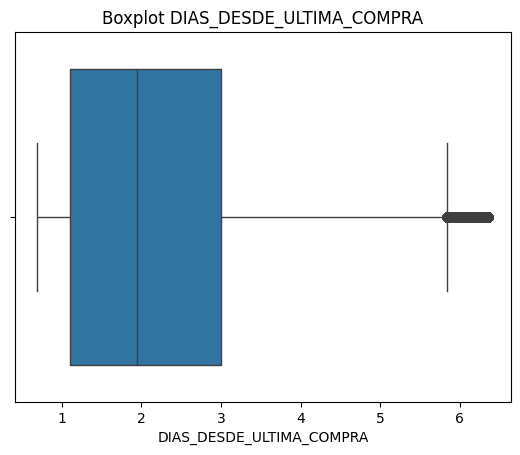

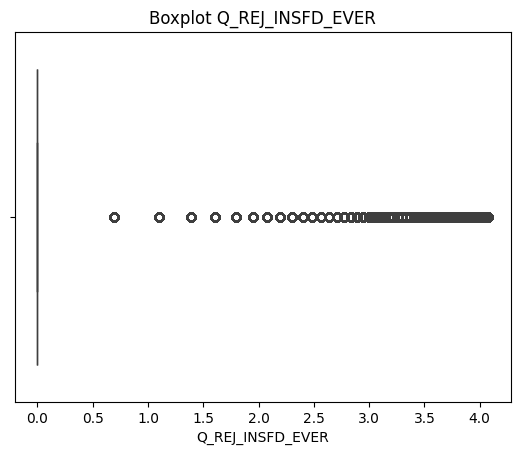

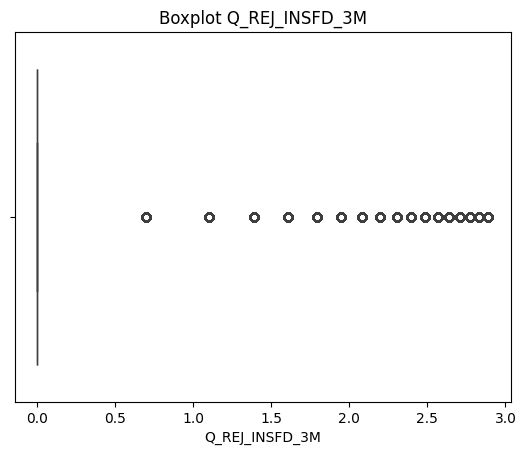

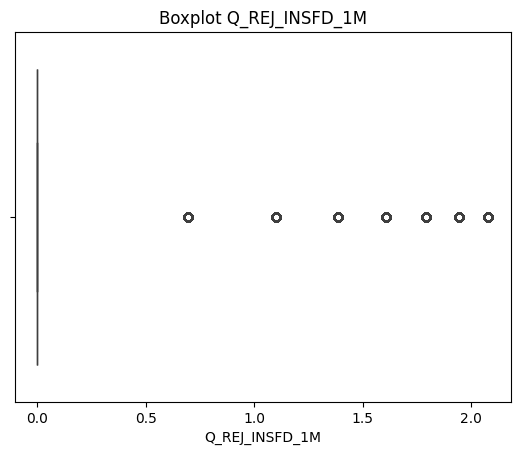

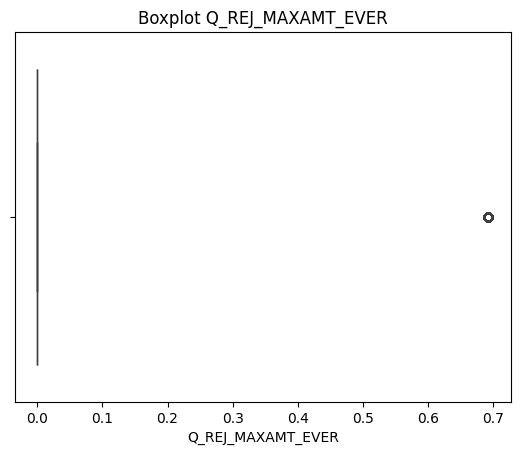

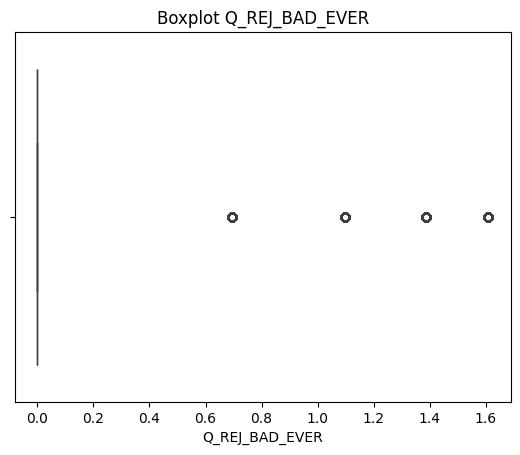

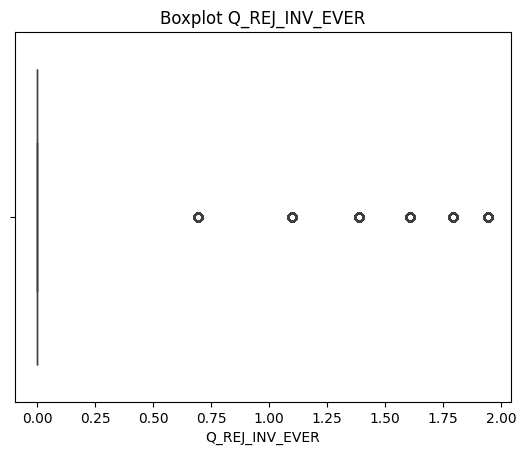

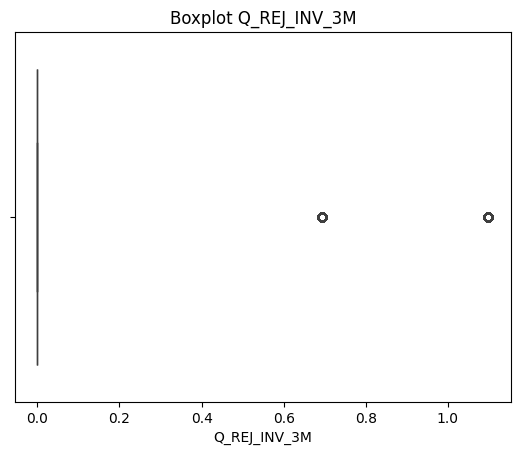

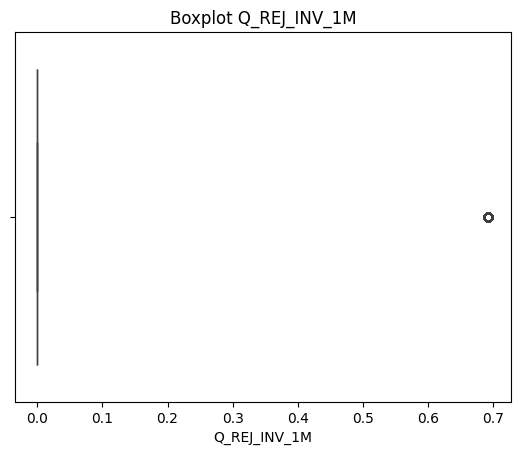

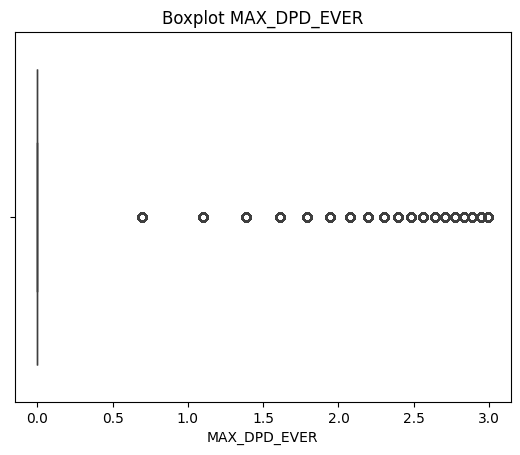

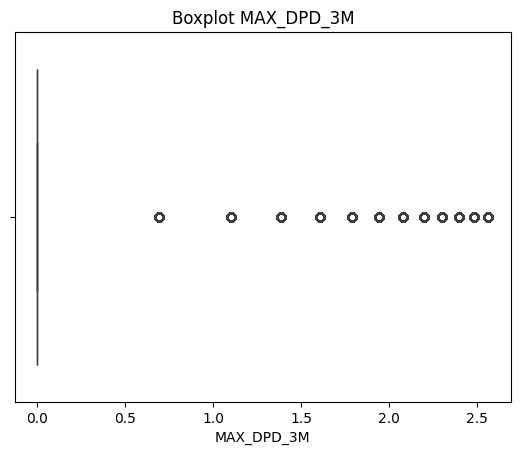

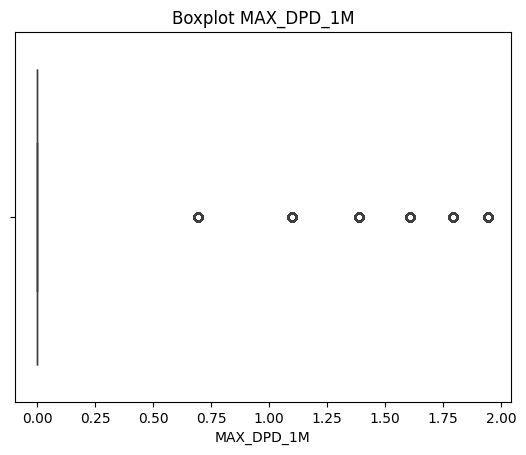

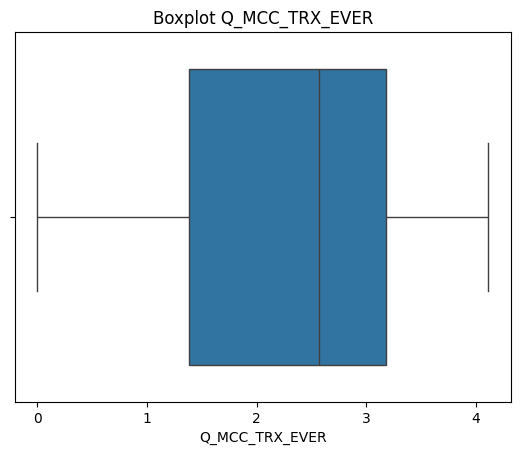

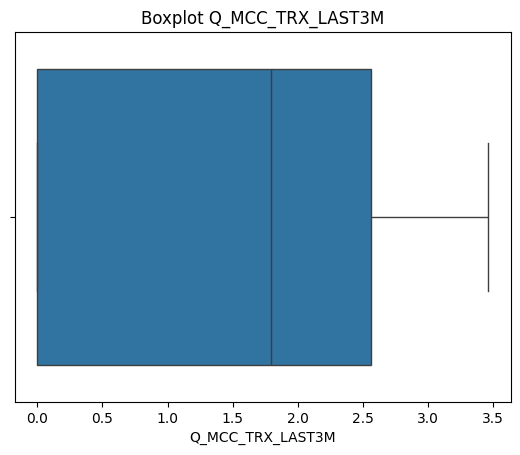

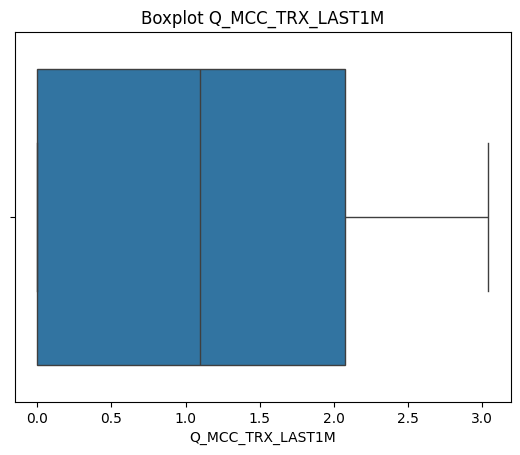

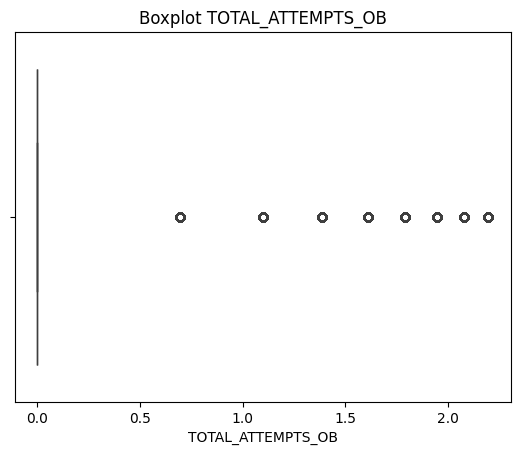

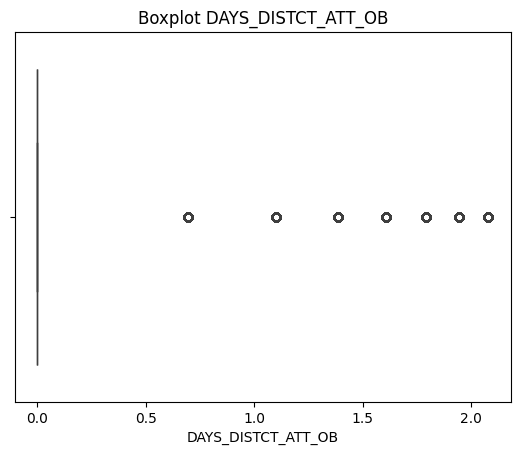

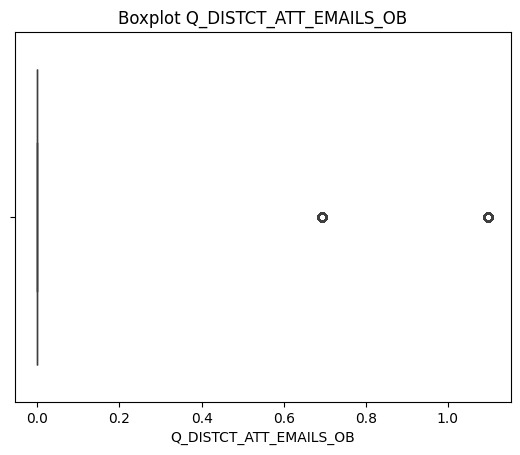

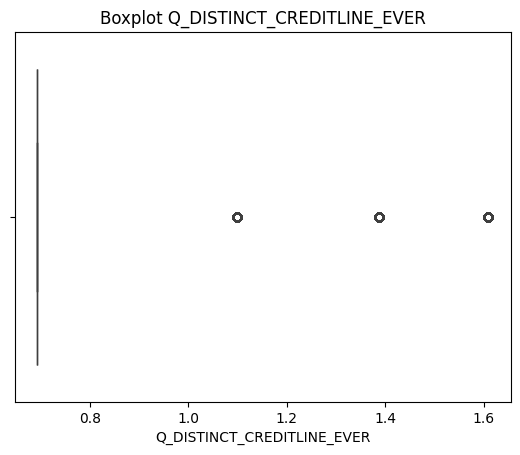

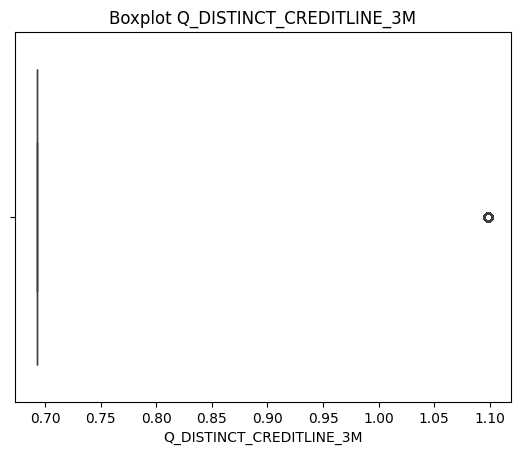

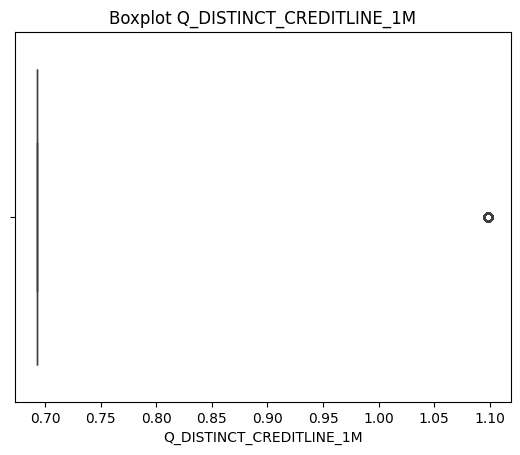

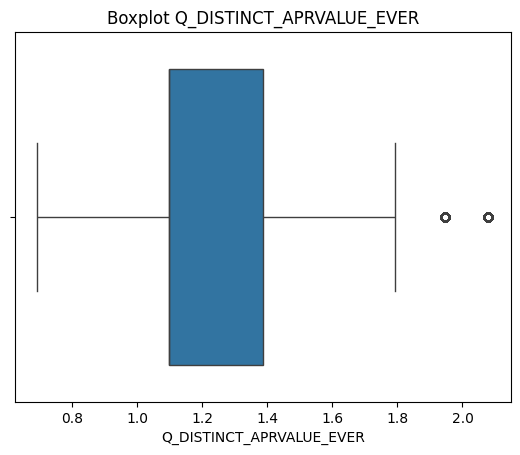

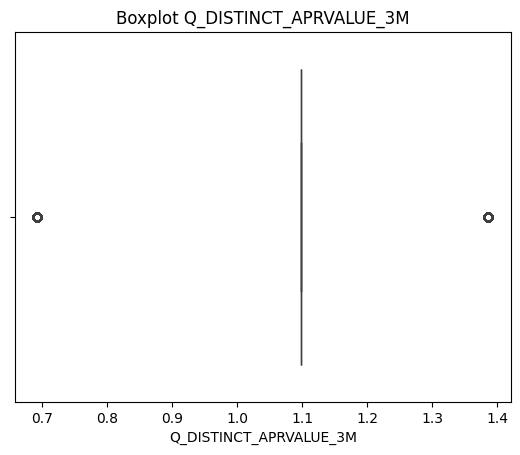

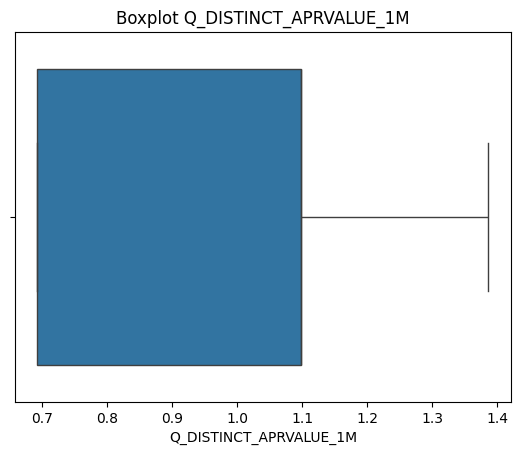

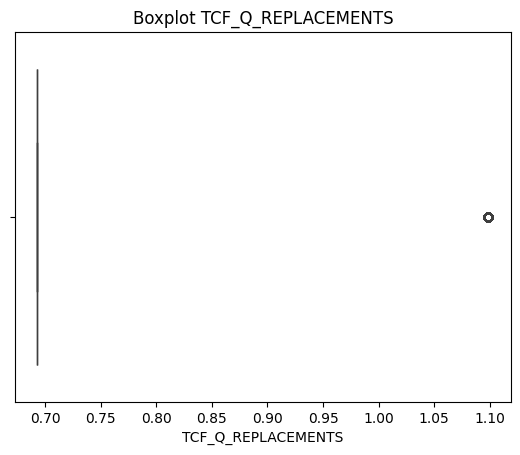

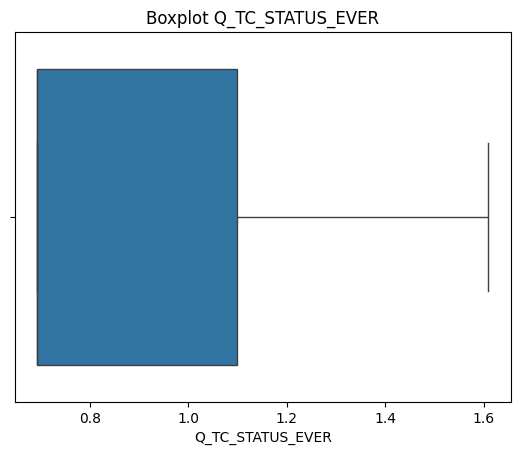

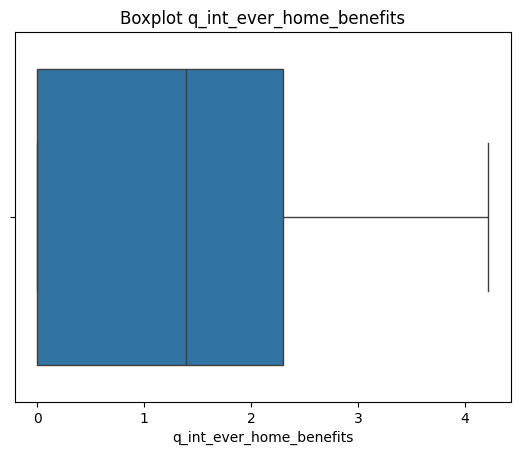

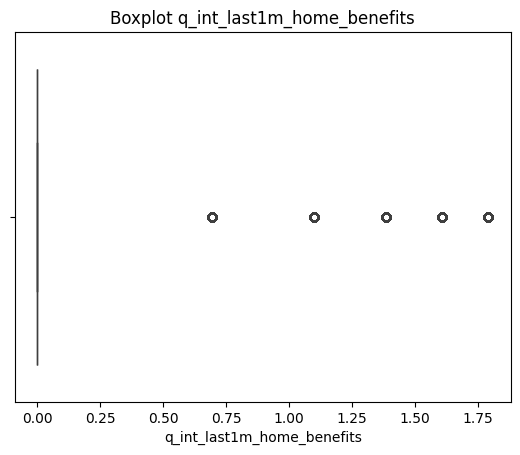

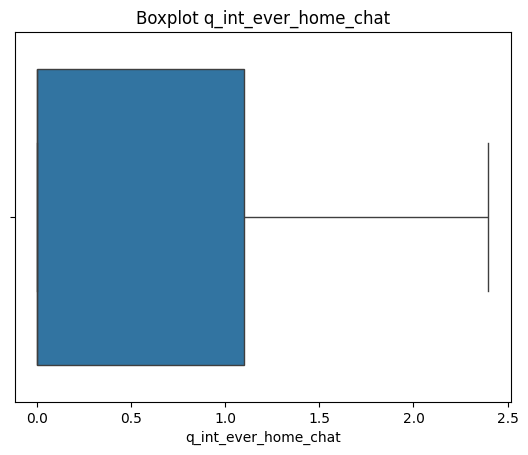

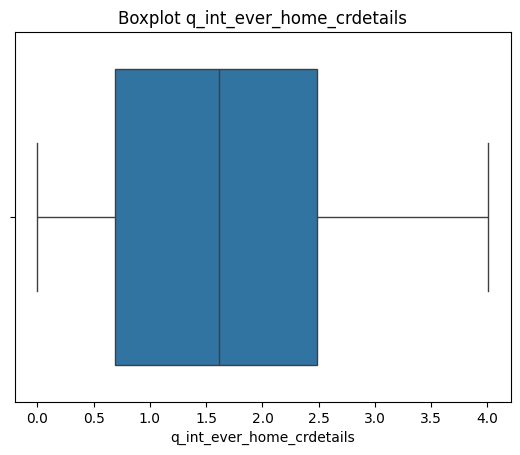

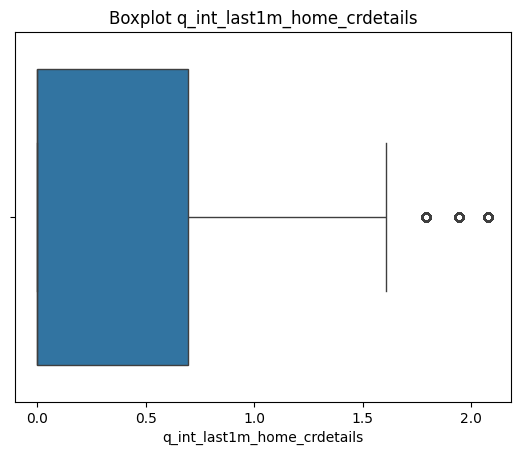

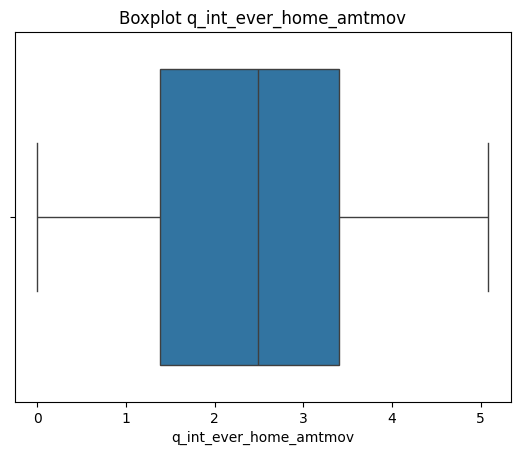

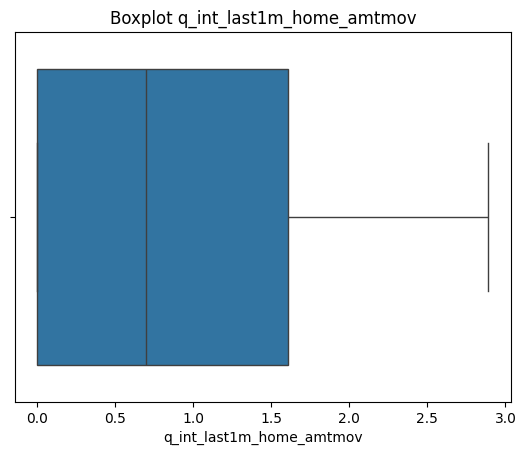

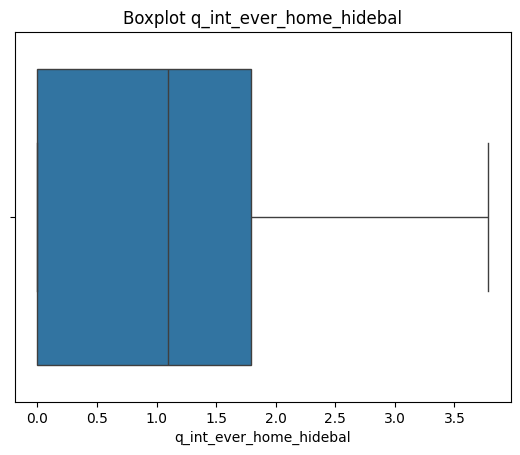

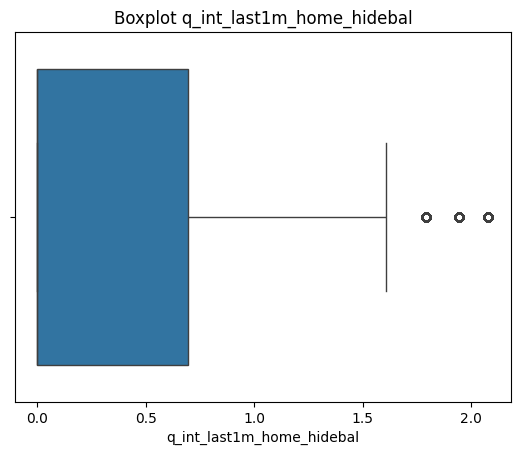

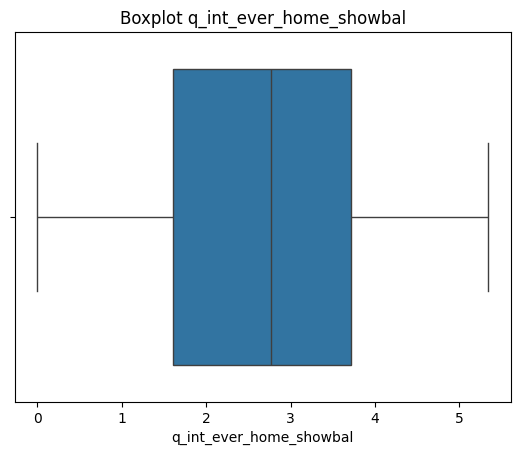

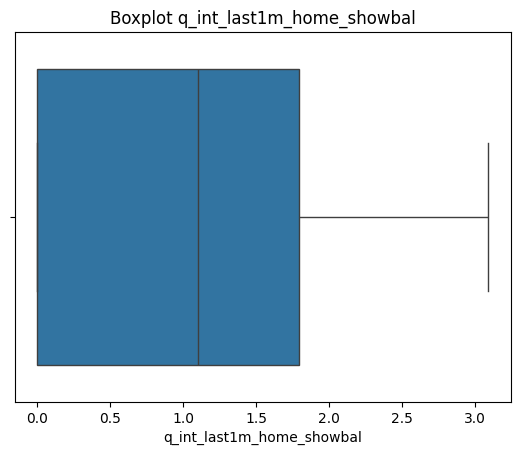

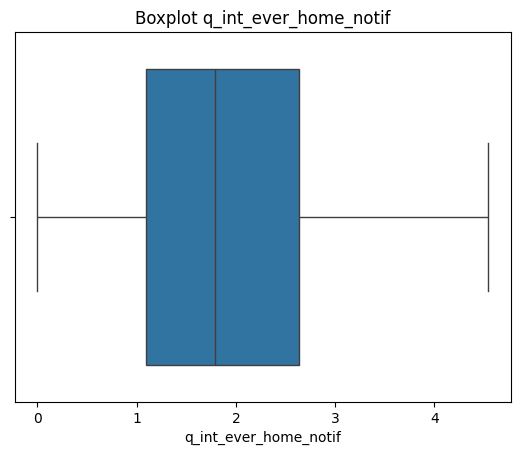

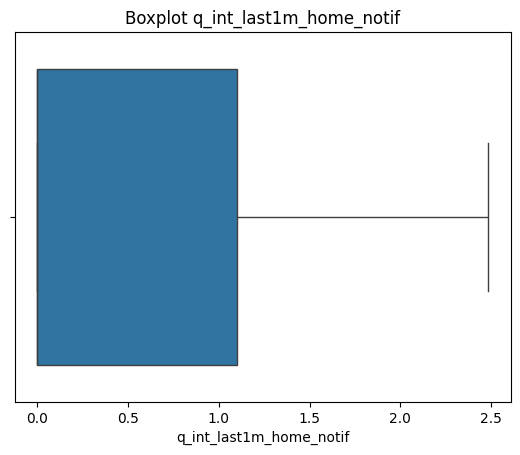

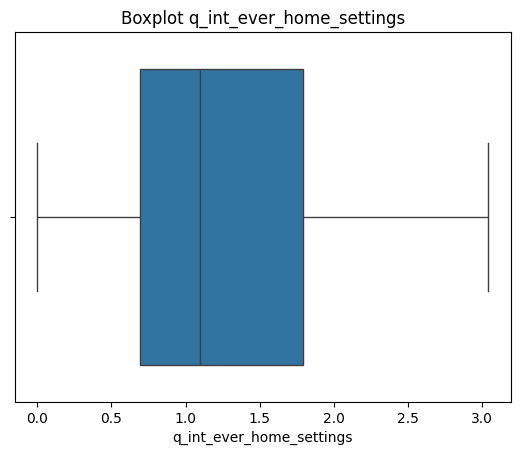

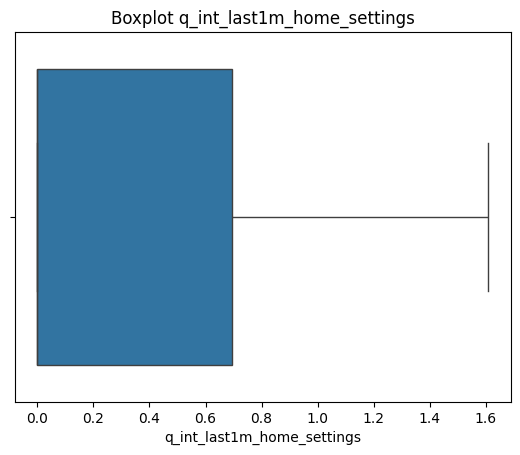

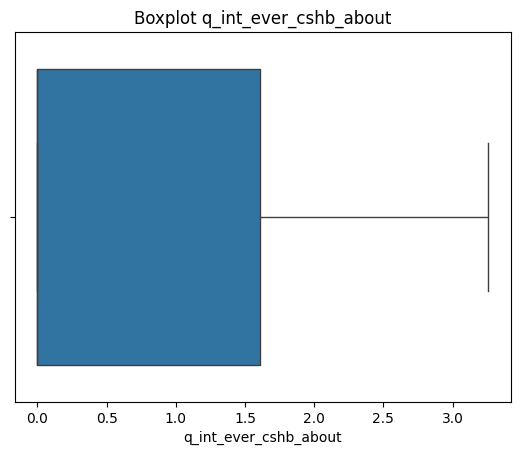

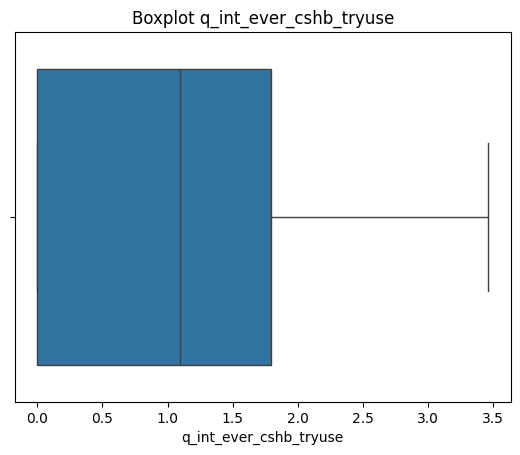

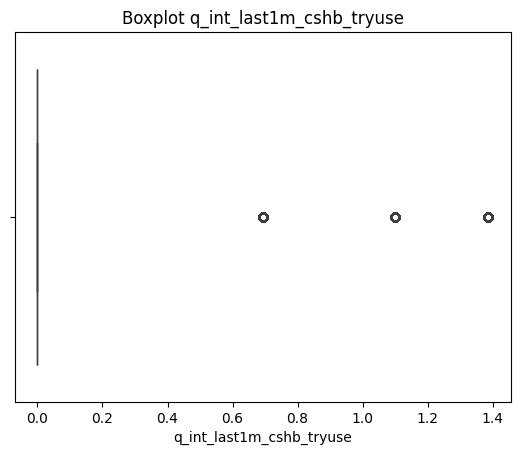

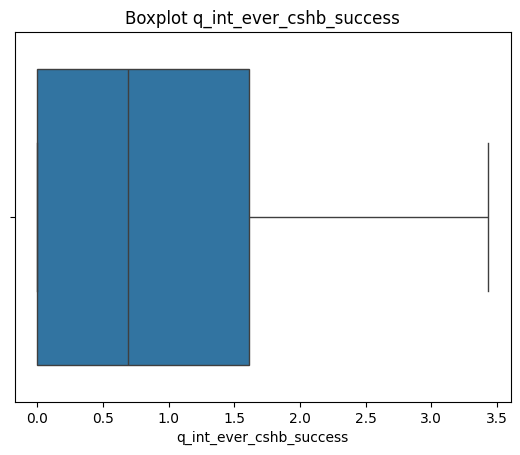

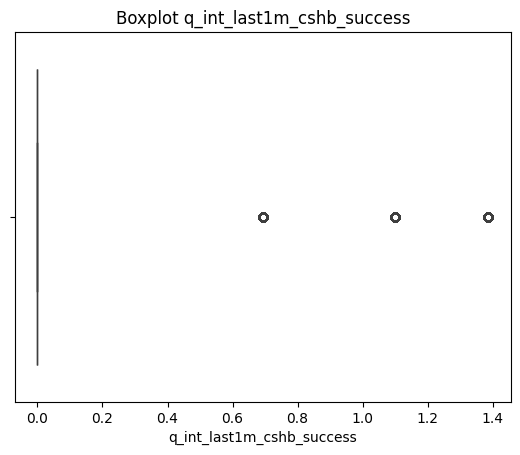

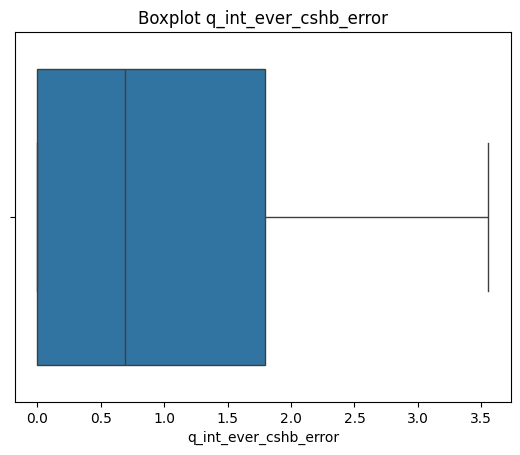

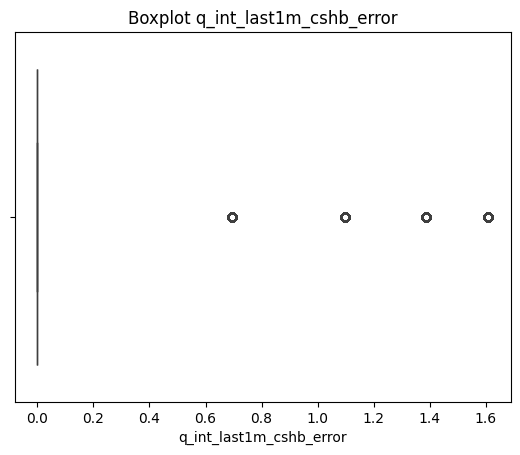

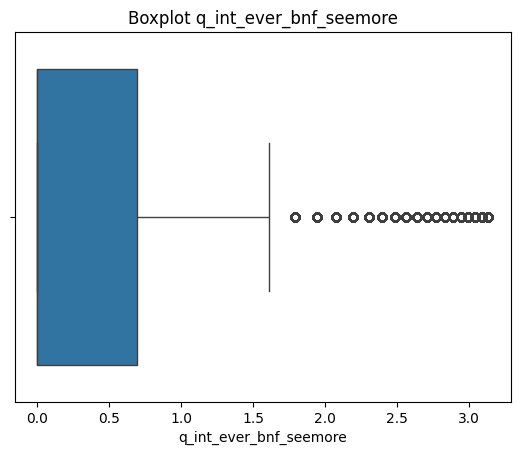

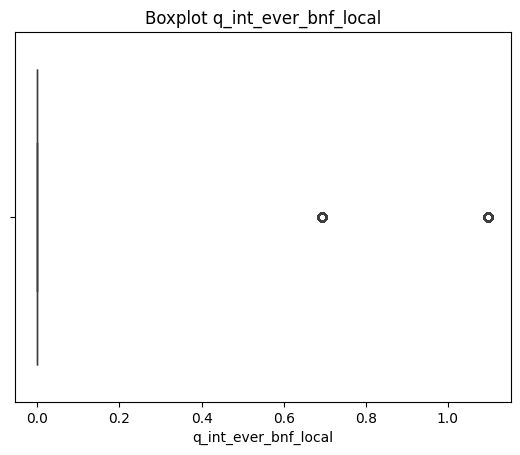

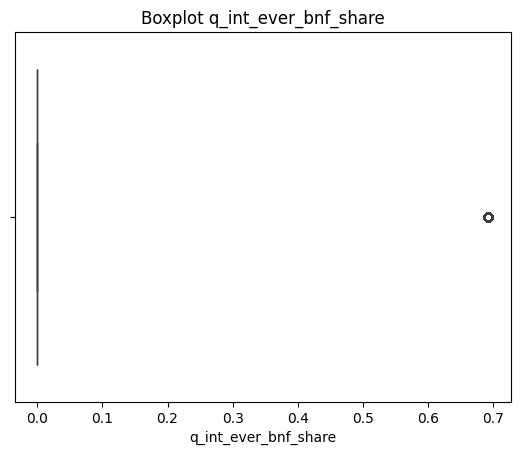

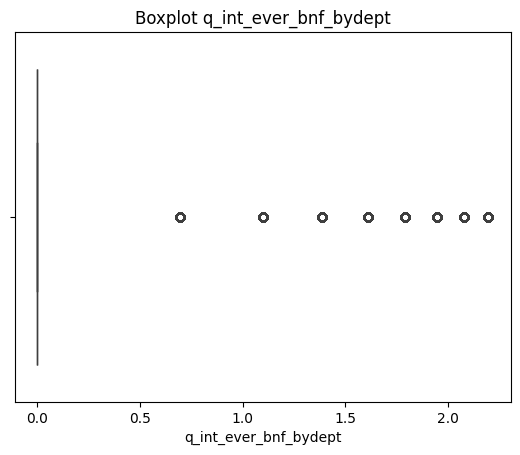

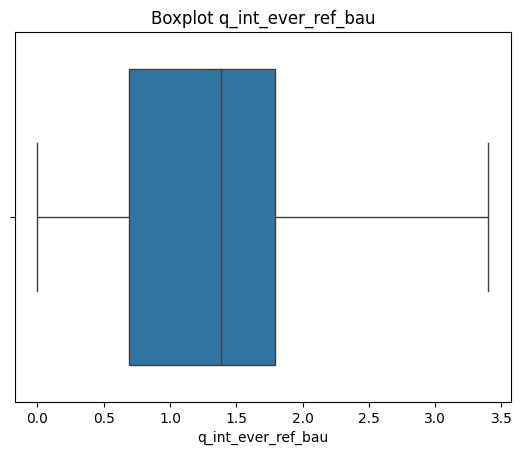

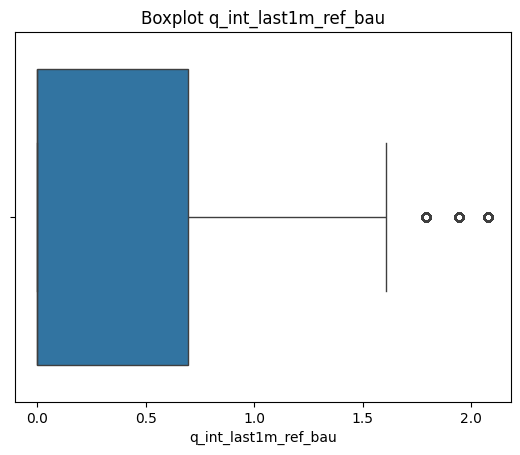

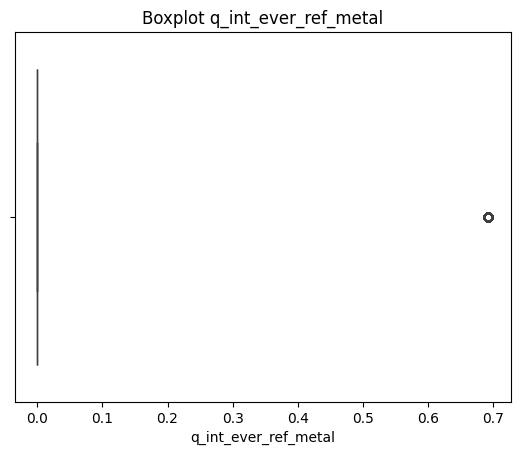

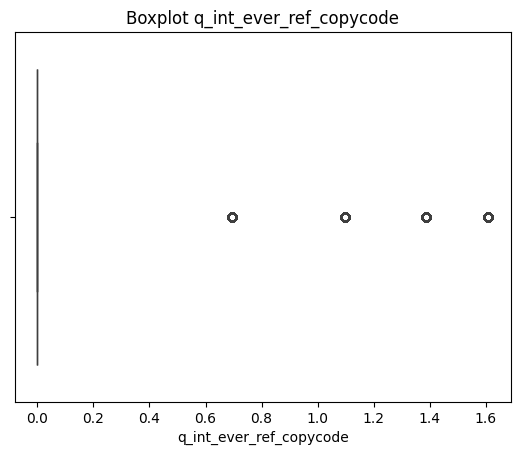

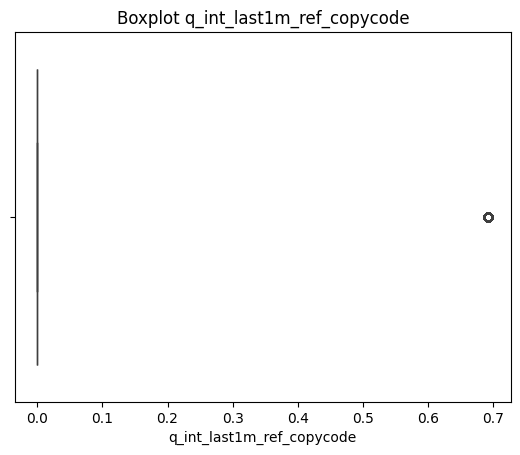

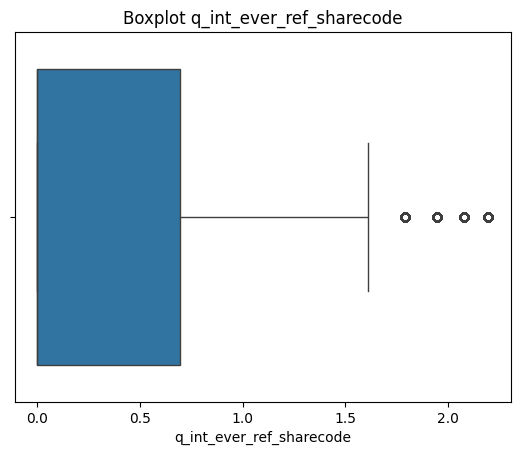

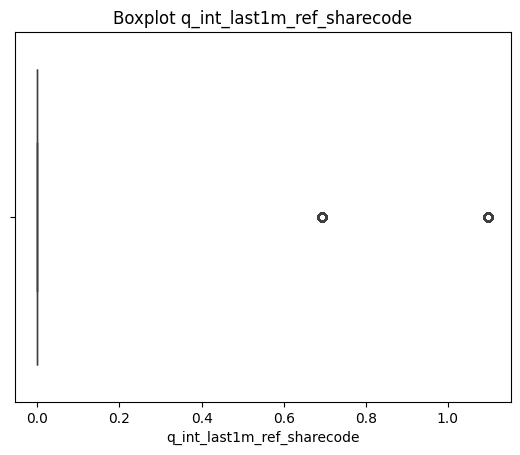

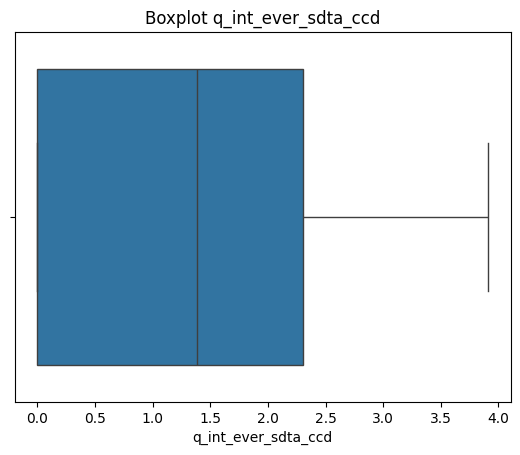

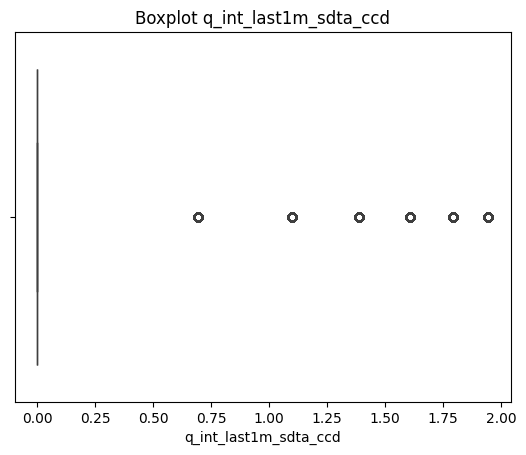

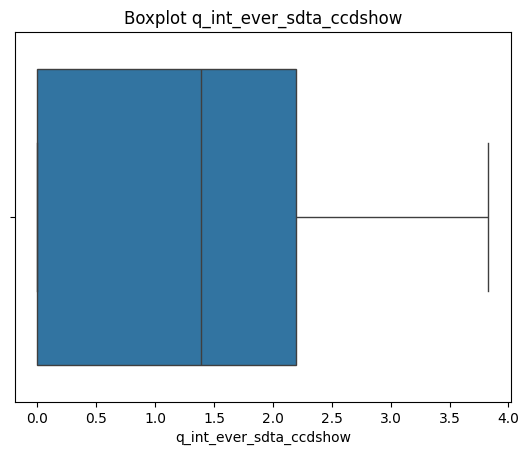

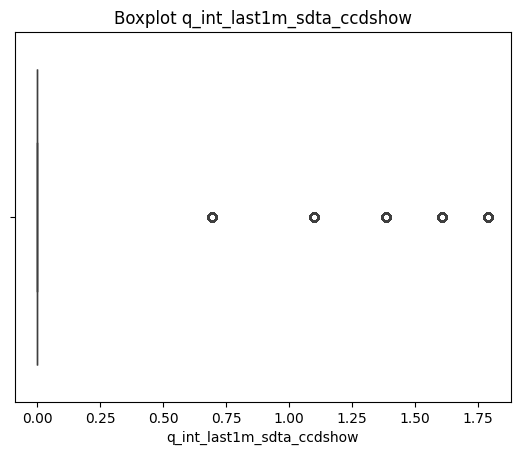

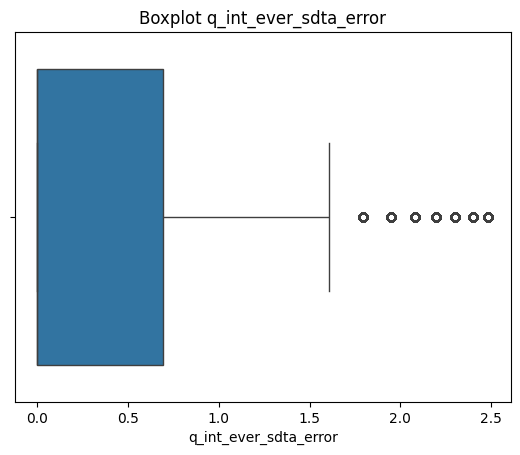

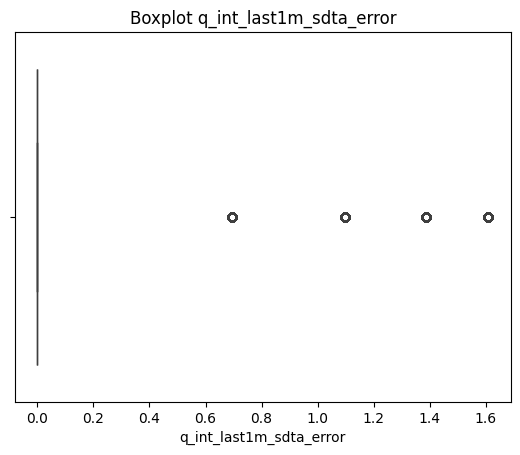

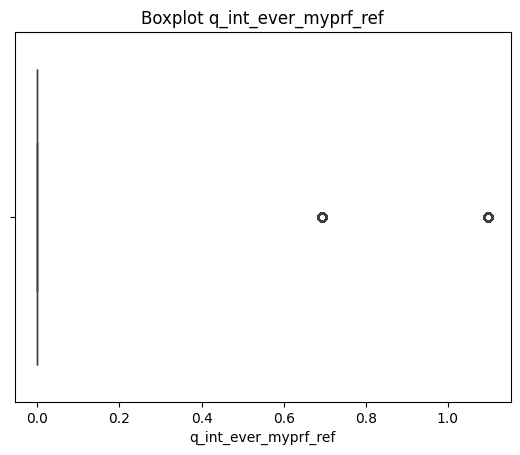

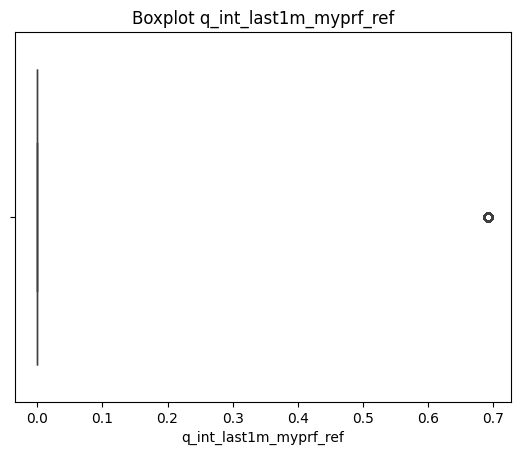

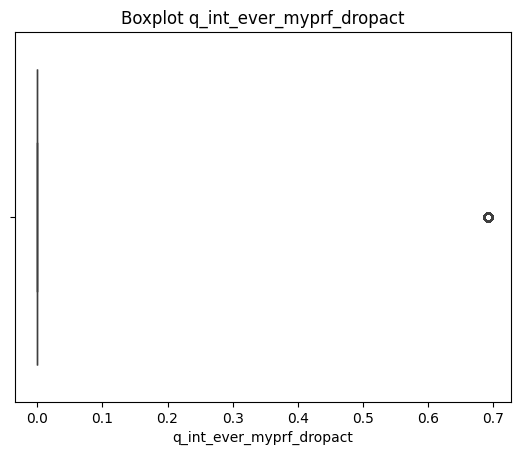

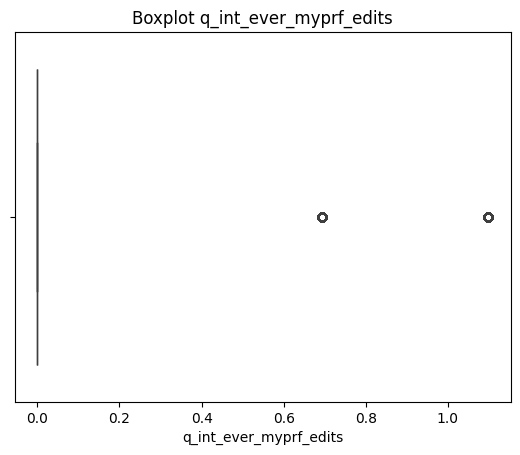

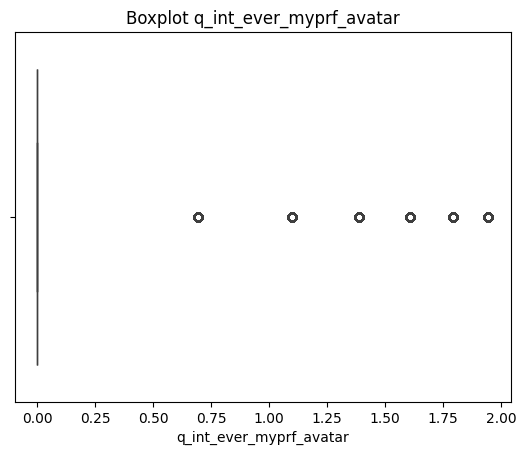

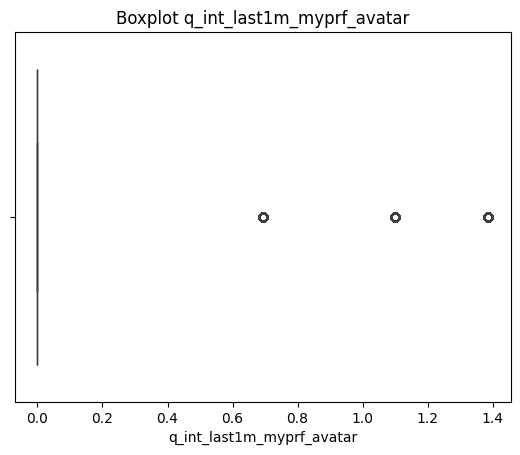

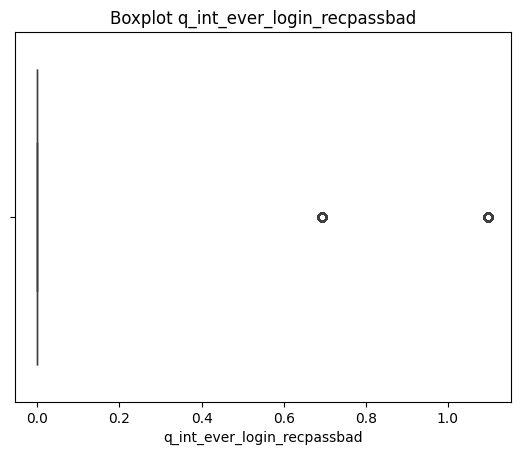

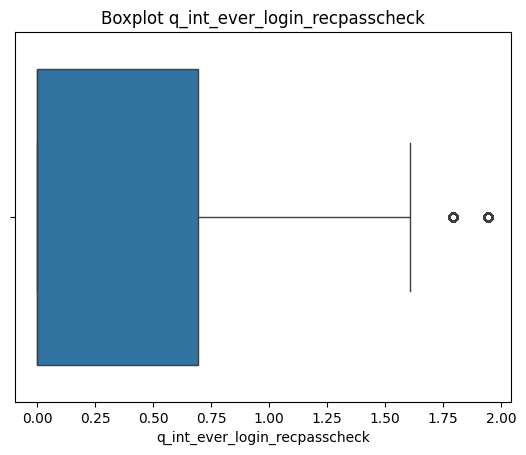

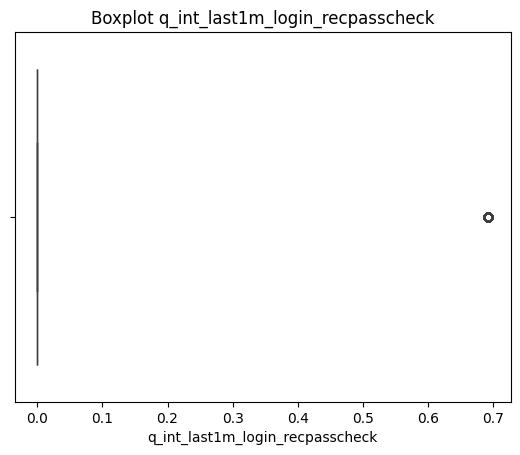

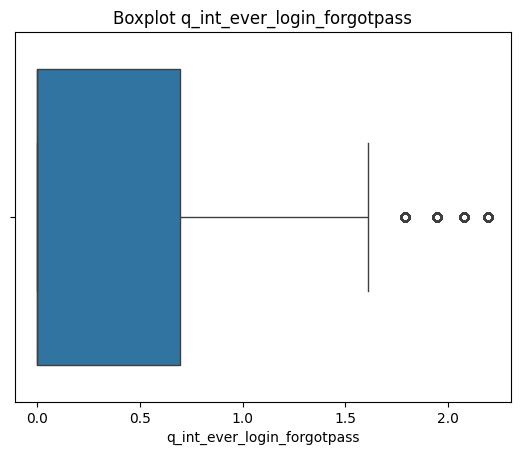

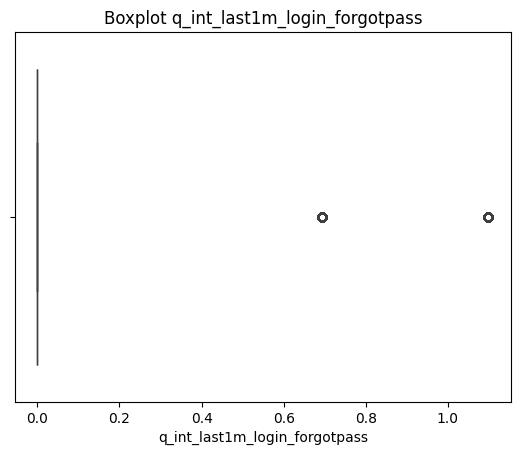

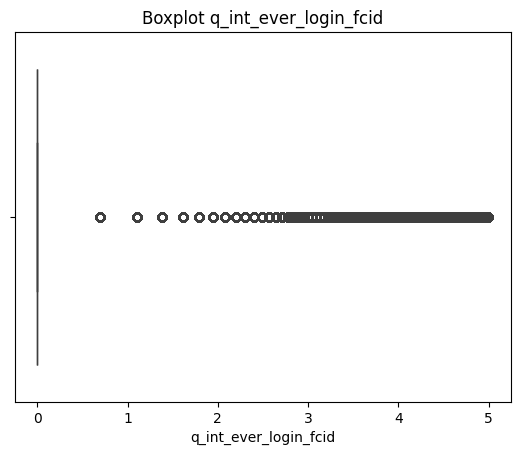

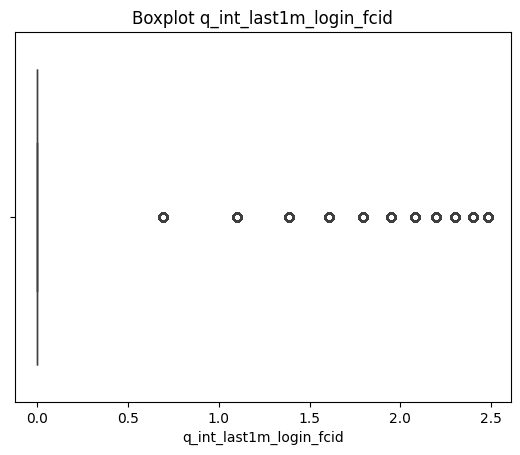

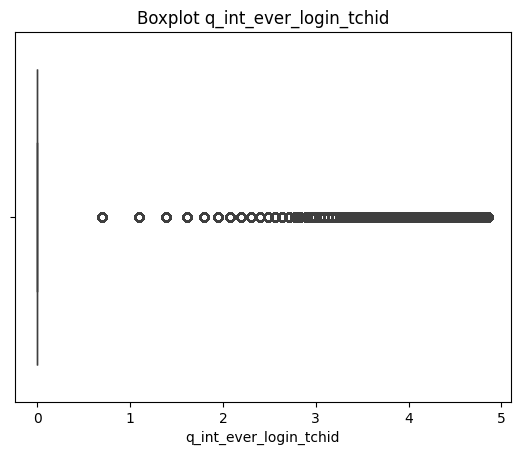

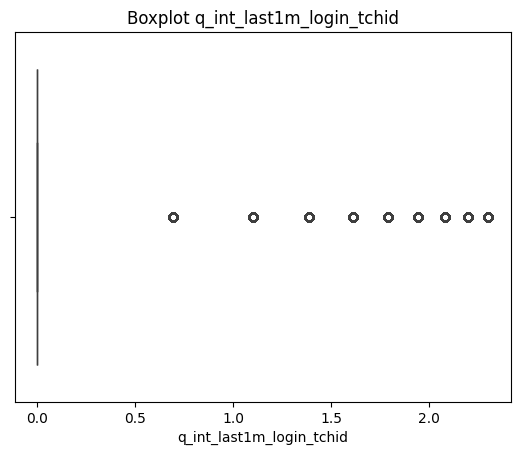

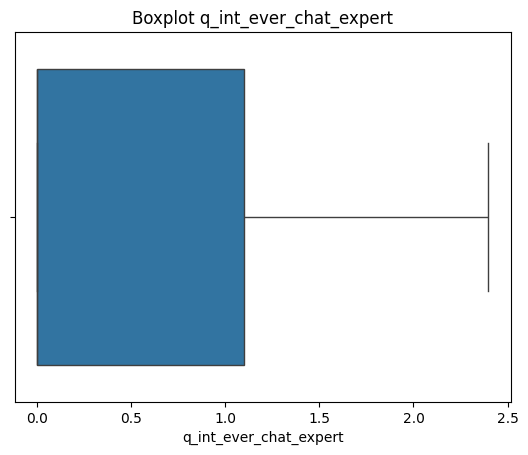

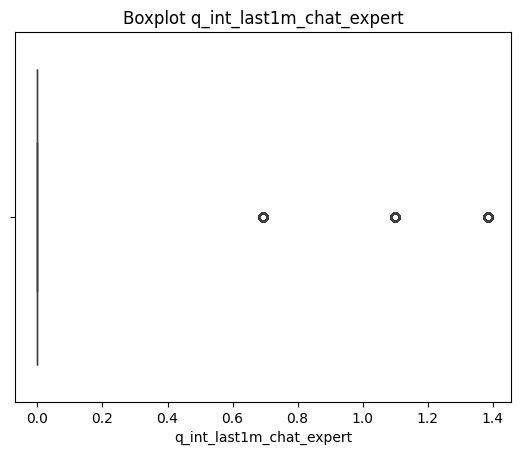

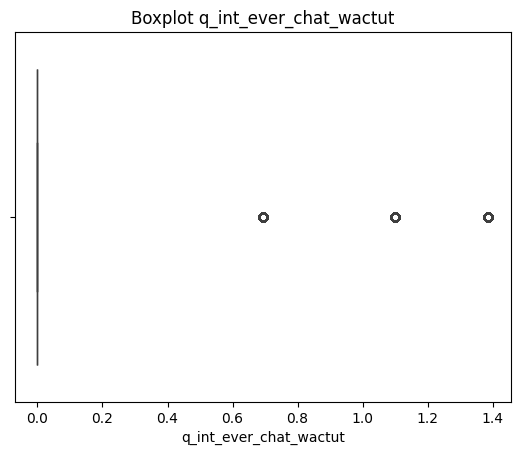

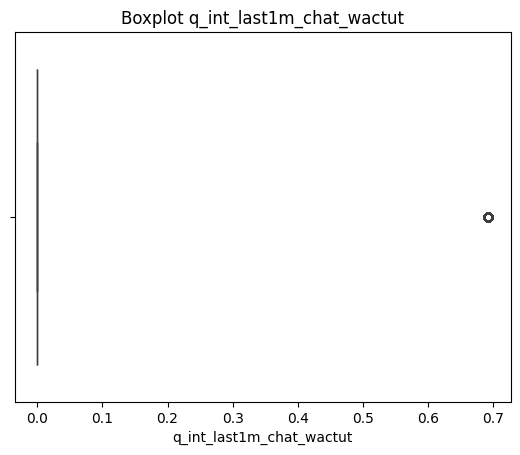

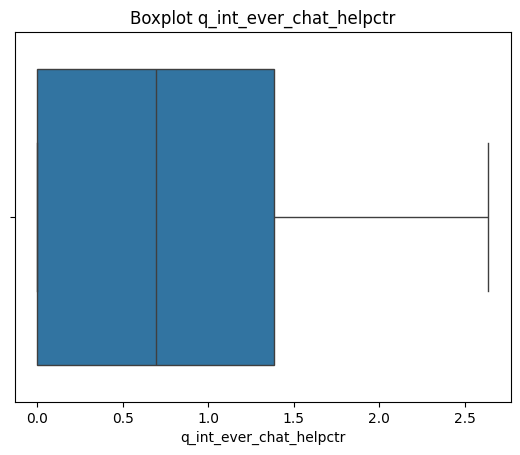

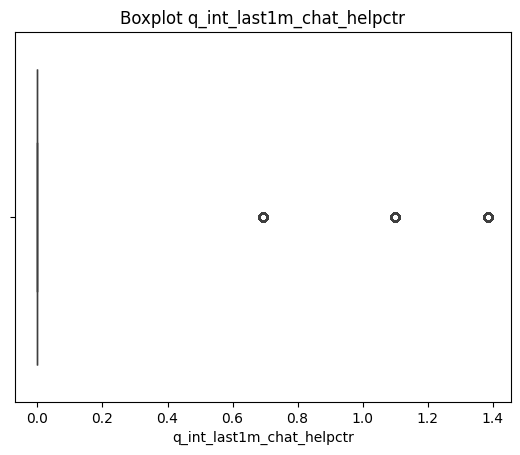

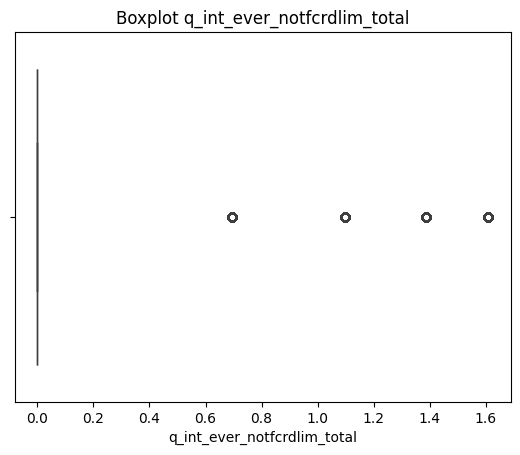

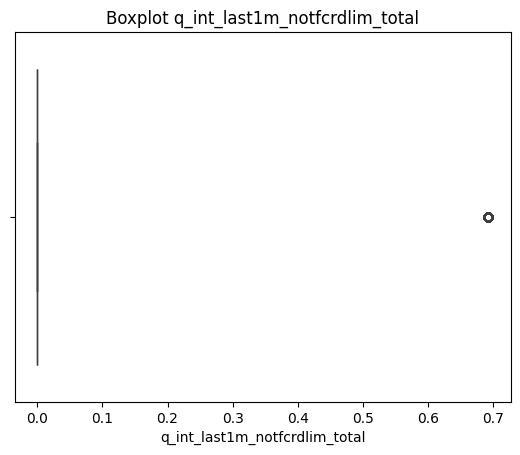

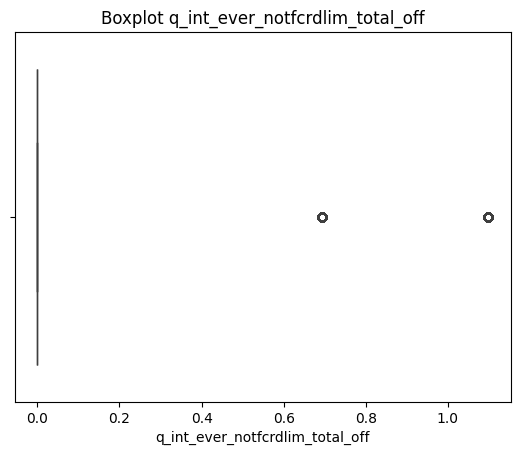

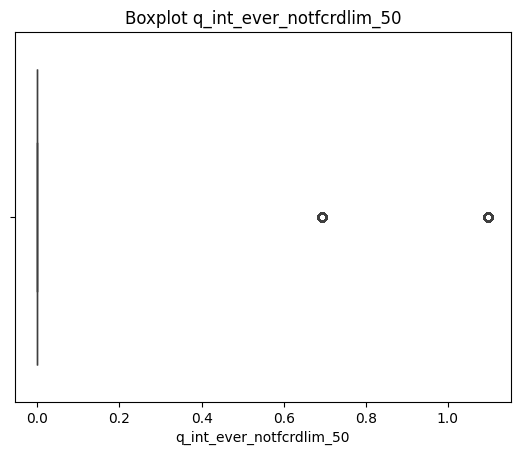

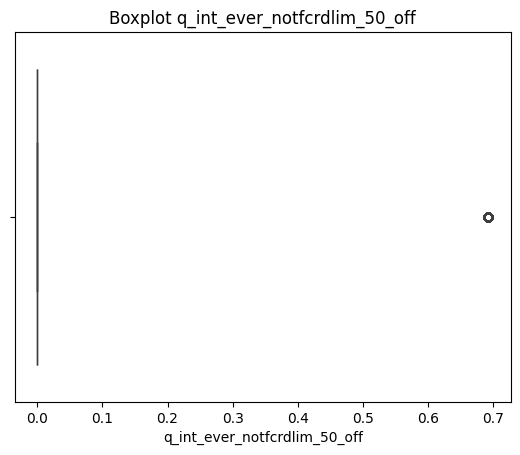

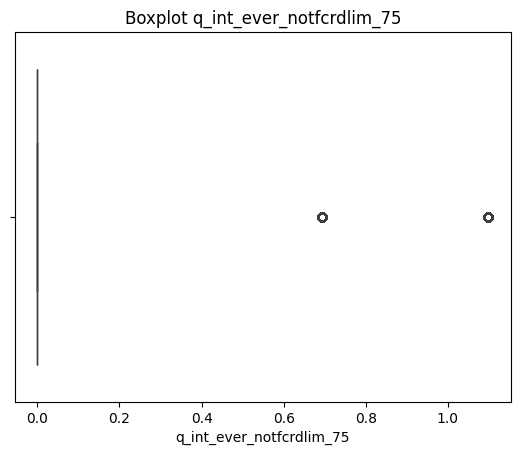

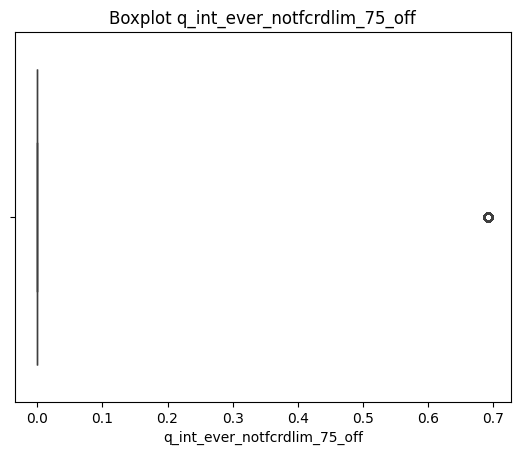

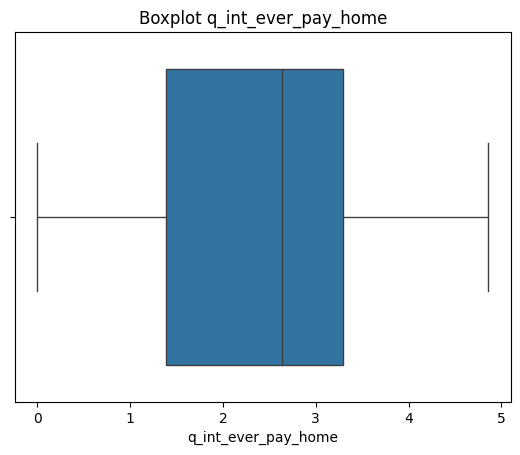

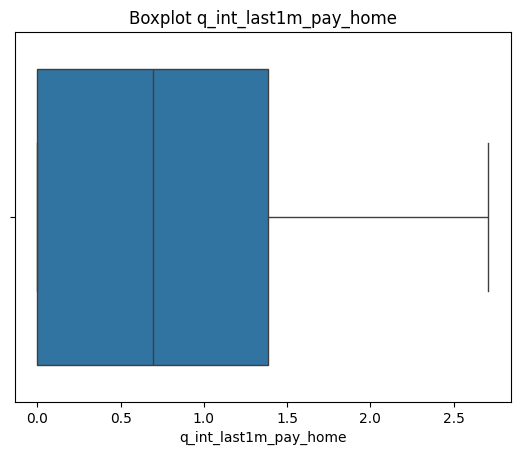

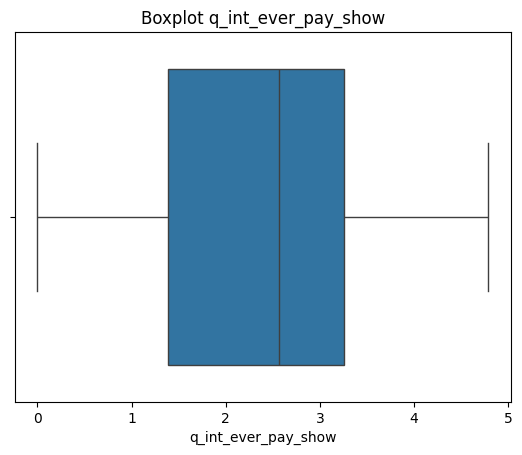

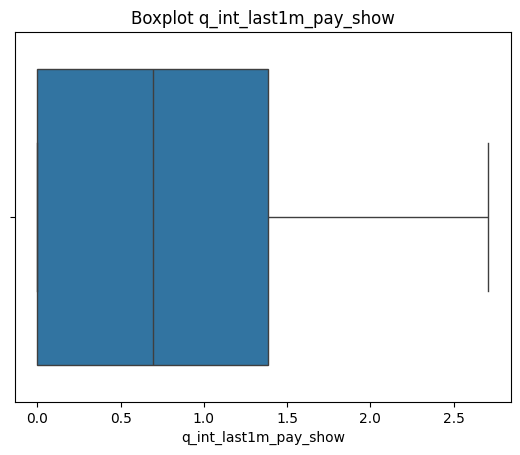

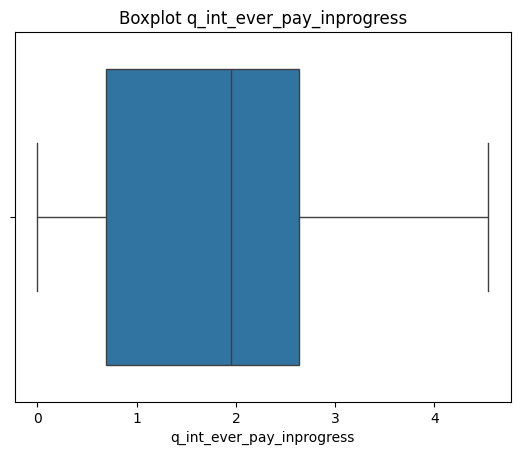

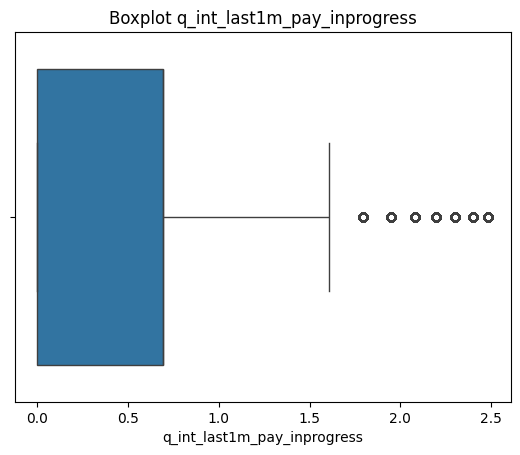

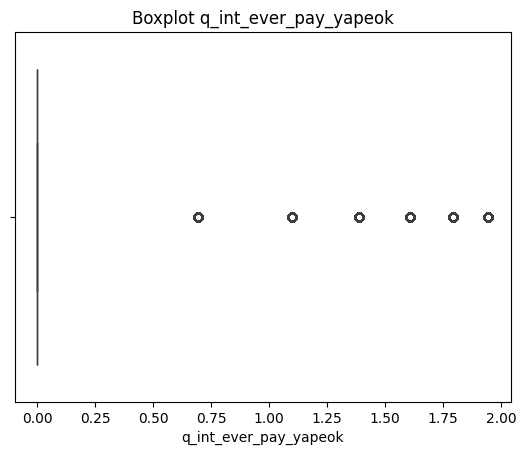

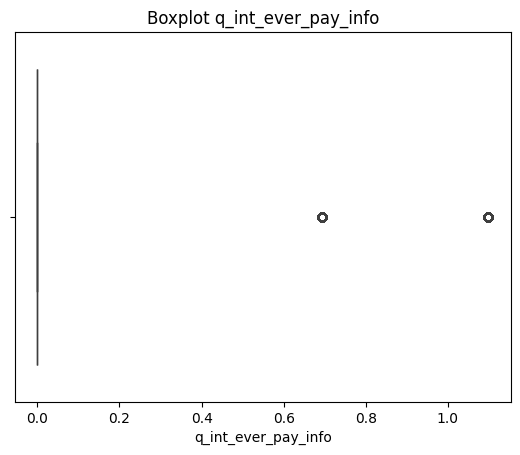

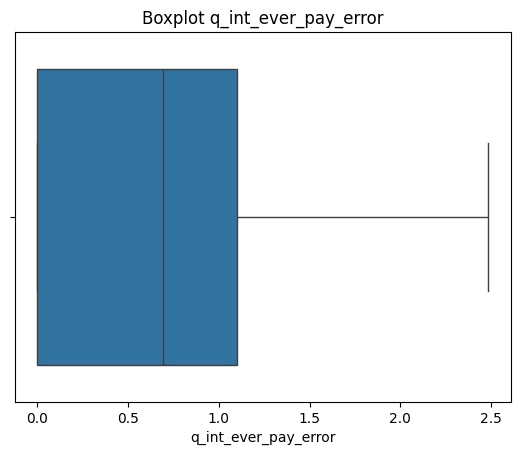

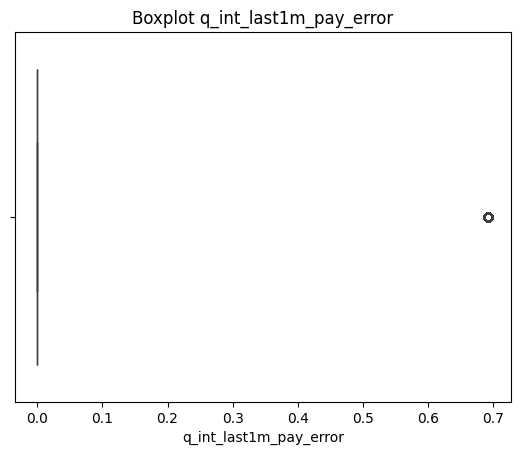

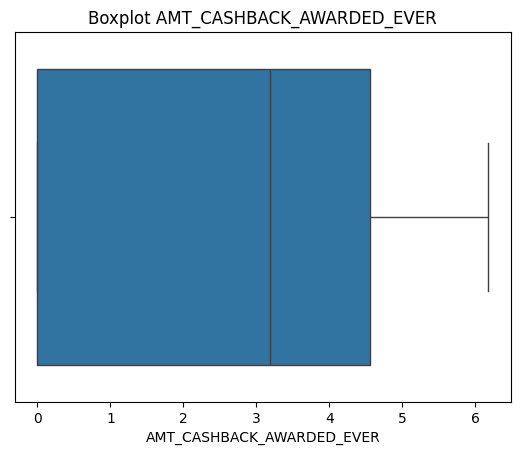

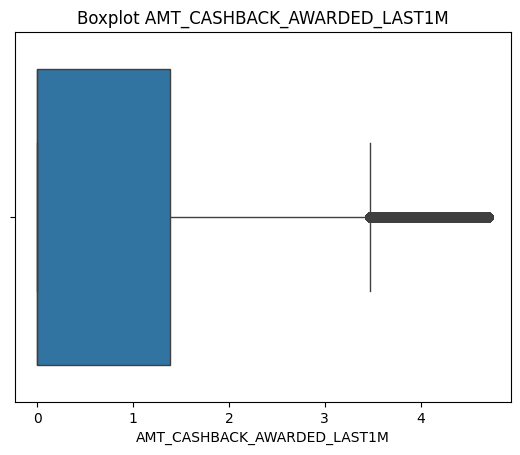

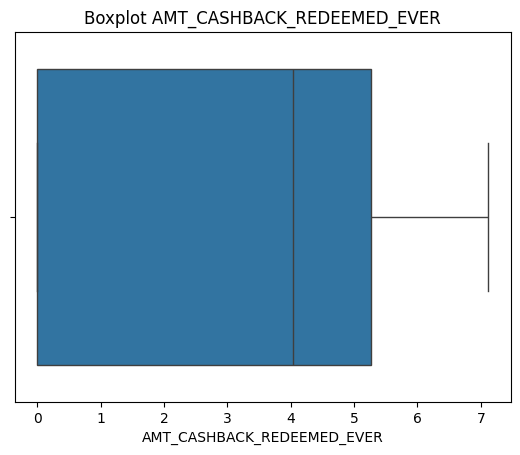

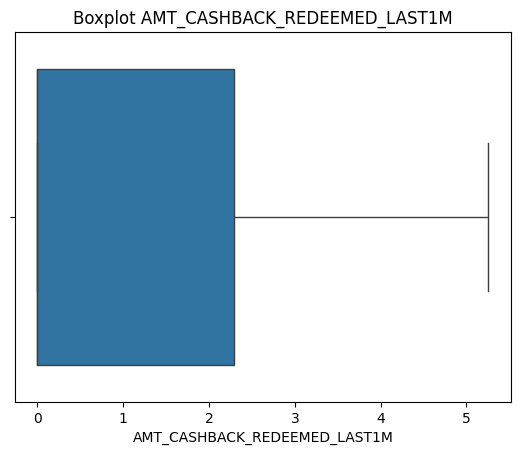

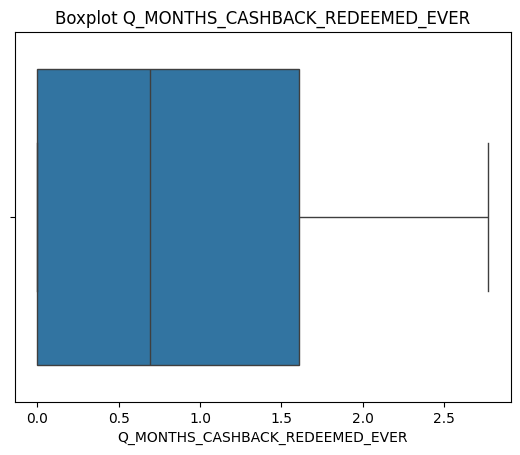

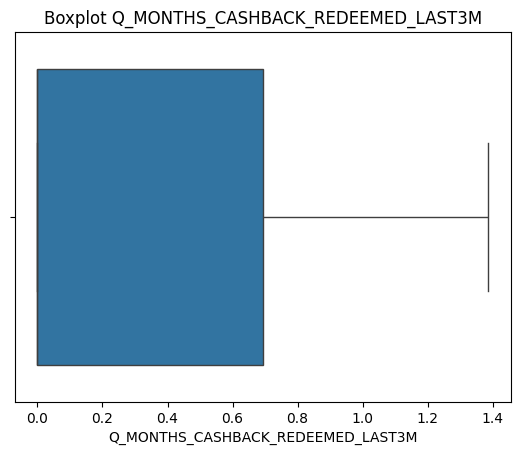

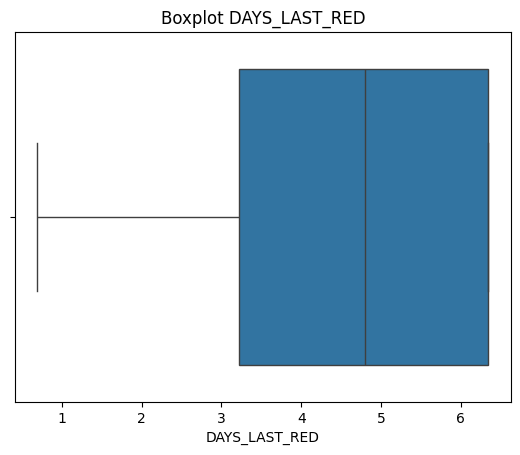

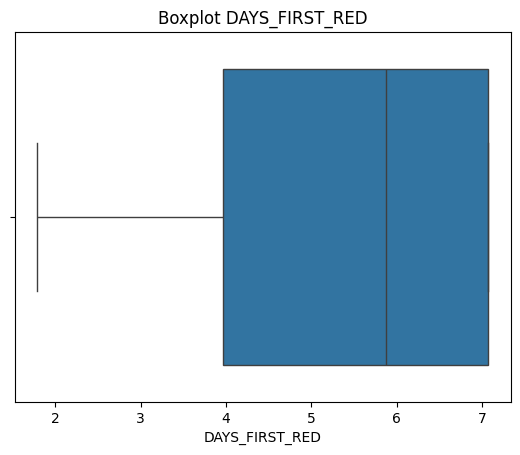

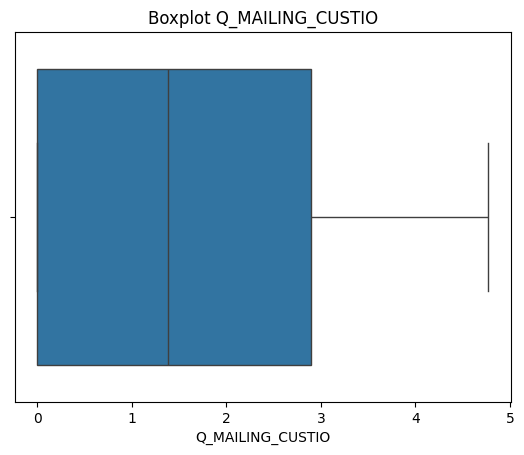

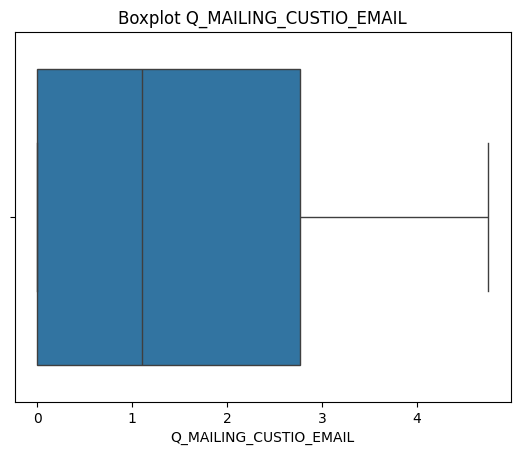

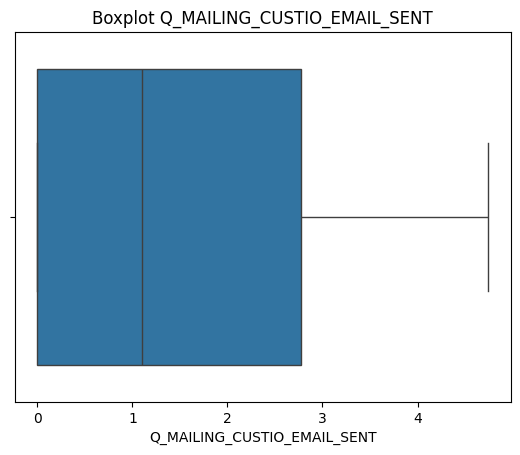

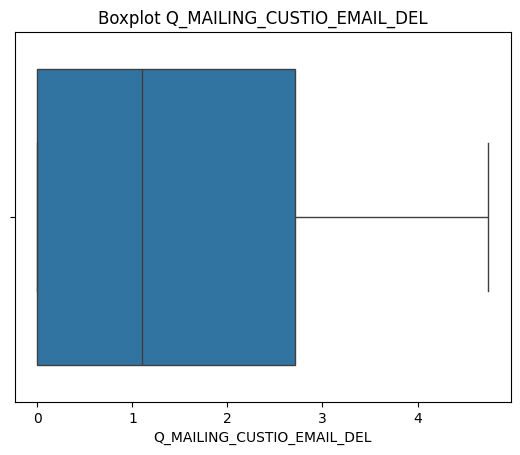

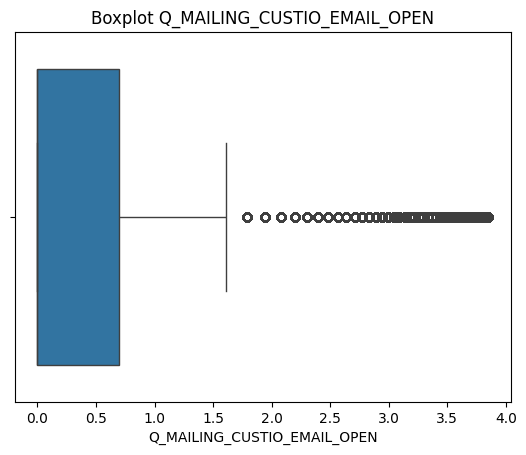

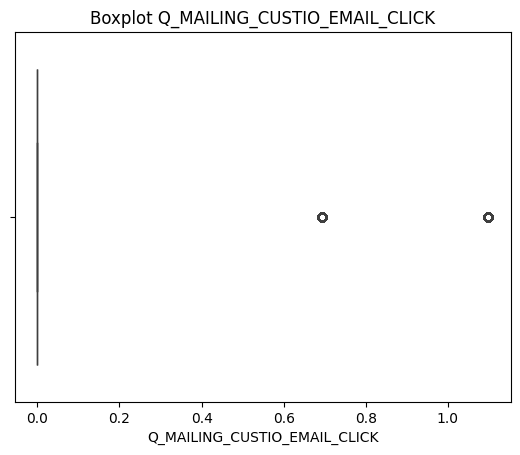

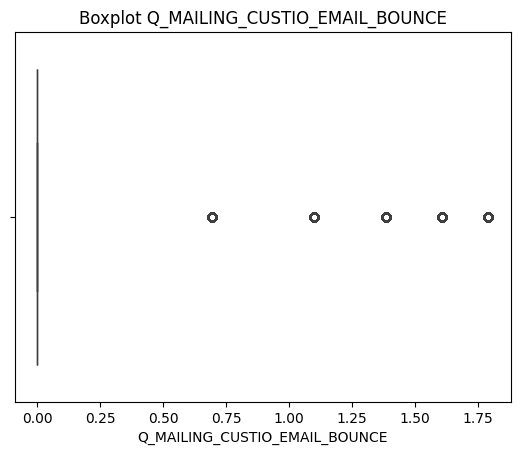

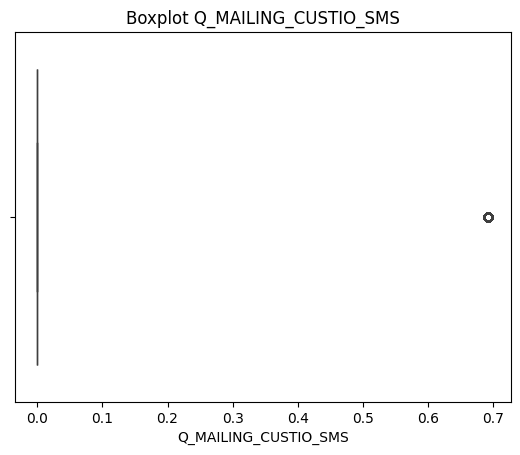

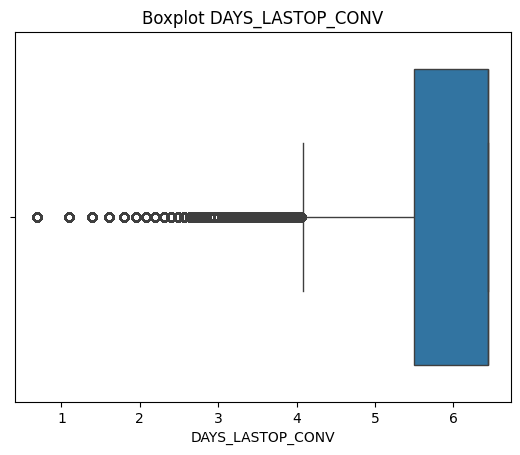

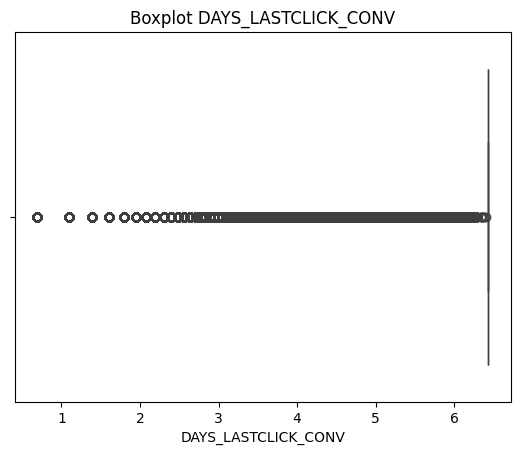

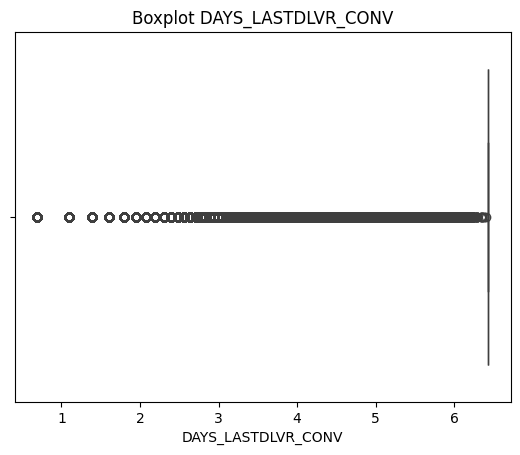

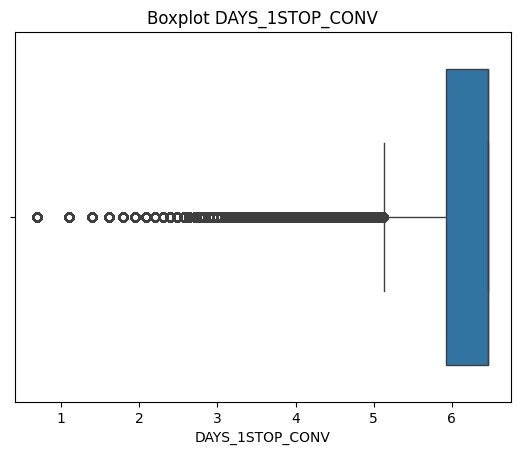

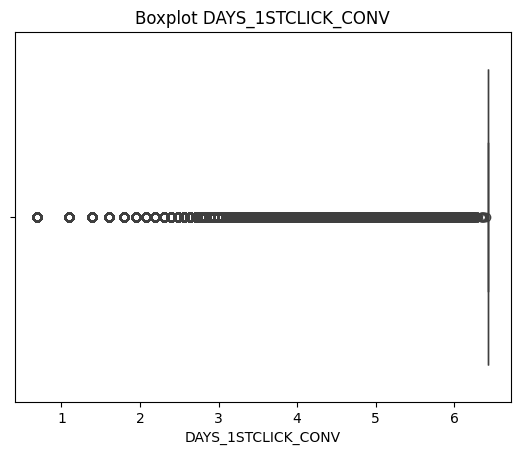

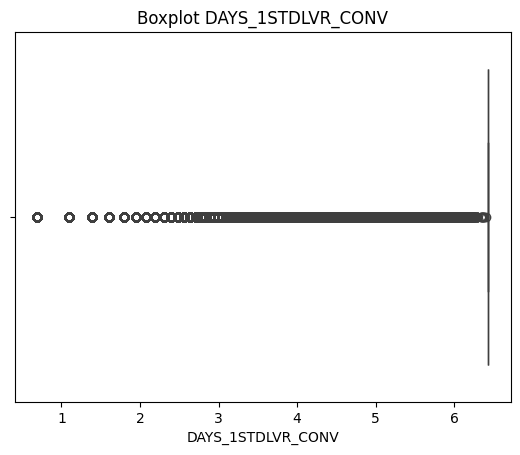

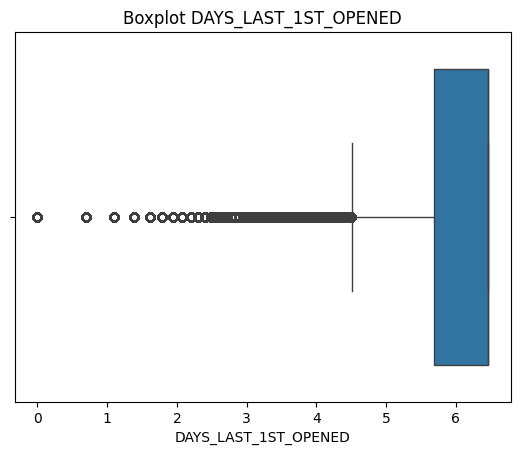

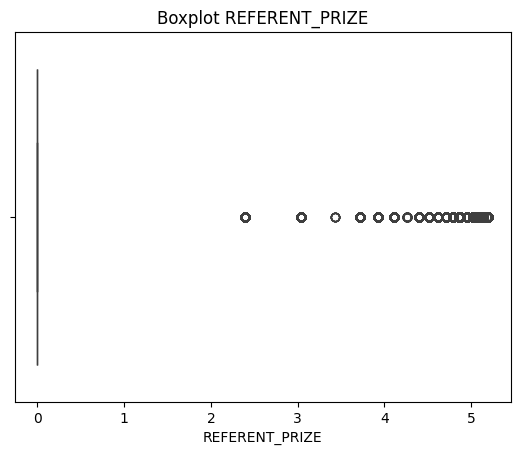

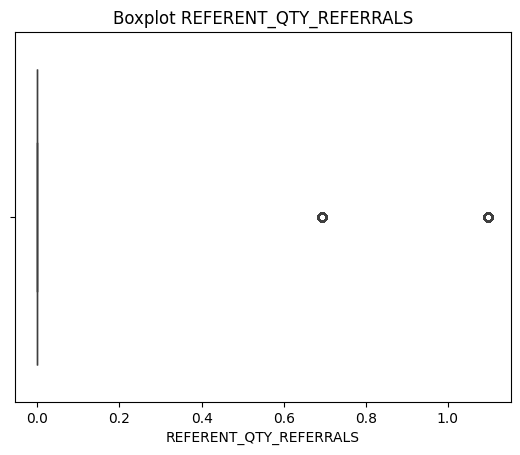

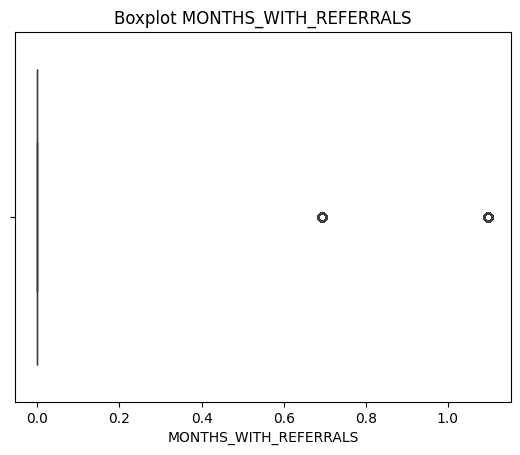

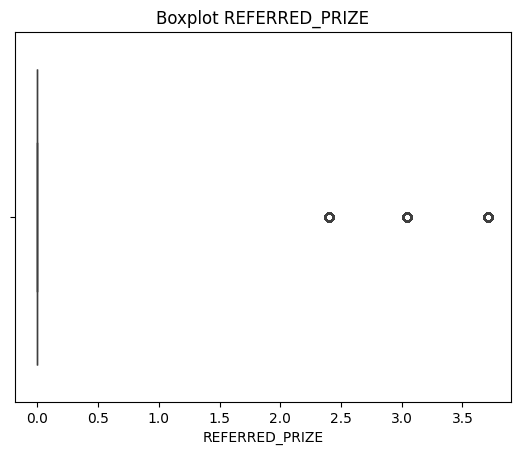

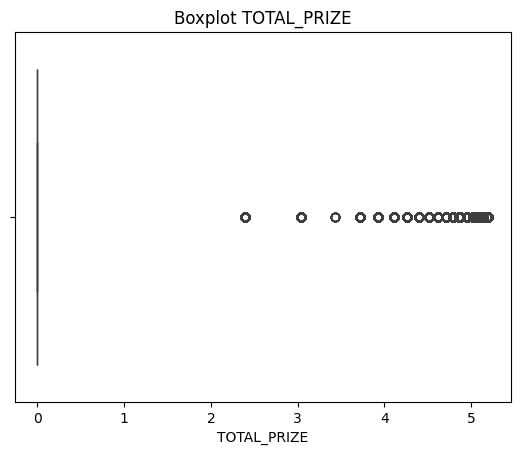

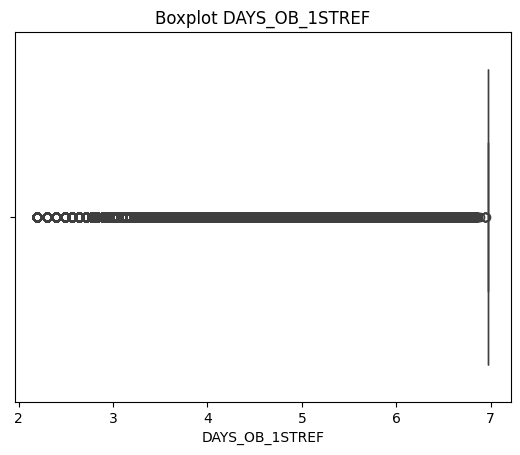

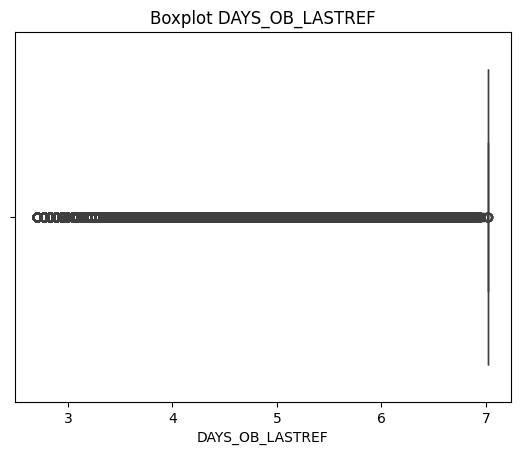

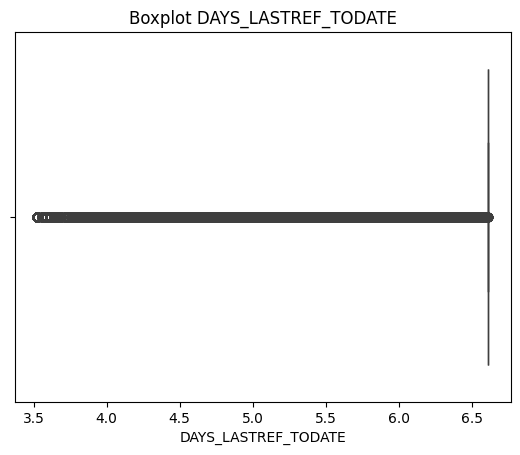

In [ ]:
for variable in variables_numericas:
  sns.boxplot(data=df_final6, x=variable)
  plt.title(f"Boxplot {variable}")
  plt.show()

In [ ]:
df_dummies = pd.get_dummies(df_final6[['PROFESION_cat','Lima_Prov','DOMAIN_EMAIL_cat','TCF_LAST_INNING','TCF_LAST_STATUS','USERDEVICE_PLATFORM_SO',
'mobile_brand_name','COUNTRY_1','COUNTRY_2','GENDER']]).astype(int)
df_dummies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 473998 entries, 0 to 473997
Data columns (total 37 columns):
 #   Column                          Non-Null Count   Dtype
---  ------                          --------------   -----
 0   PROFESION_cat_ABOGACIA          473998 non-null  int64
 1   PROFESION_cat_ADMINISTRADOR     473998 non-null  int64
 2   PROFESION_cat_COMUNIC           473998 non-null  int64
 3   PROFESION_cat_CONTADOR          473998 non-null  int64
 4   PROFESION_cat_DOCENTE           473998 non-null  int64
 5   PROFESION_cat_ECONOMISTA        473998 non-null  int64
 6   PROFESION_cat_INGENIERO         473998 non-null  int64
 7   PROFESION_cat_PSICOLOGO         473998 non-null  int64
 8   PROFESION_cat_RESTO             473998 non-null  int64
 9   PROFESION_cat_TECNICO           473998 non-null  int64
 10  Lima_Prov_Lima                  473998 non-null  int64
 11  Lima_Prov_Provincia             473998 non-null  int64
 12  DOMAIN_EMAIL_cat_RESTO          473998 non-n

In [ ]:
df_final7 = pd.concat([df_final6,df_dummies], axis=1)
df_final7 = df_final7.drop(columns=['PROFESION_cat','Lima_Prov','DOMAIN_EMAIL_cat','TCF_LAST_INNING','TCF_LAST_STATUS','USERDEVICE_PLATFORM_SO',
'mobile_brand_name','COUNTRY_1','COUNTRY_2','GENDER'])
df_final7.shape

(473998, 366)

### *Carga de datos preprocesados*


In [ ]:
df_final7.to_csv('Dataset_retrain_v3_Churn.csv', index=False)

In [ ]:
#ejemplo7 = df_final7.head(10).copy()
table_id = "data-matrix-lab-ss.DS_WORKSPACE_ALAB.DATASET_RETRAIN_CHURN_V3_HAROLD"

# Configuración de carga
job_config = bigquery.LoadJobConfig(
          write_disposition="WRITE_APPEND"  # o WRITE_TRUNCATE, WRITE_EMPTY
      )

# Cargar datos
job = client.load_table_from_dataframe(df_final7, table_id, job_config=job_config)

# Esperar a que termine el job
job.result()

print(f"Insertada {job.output_rows} filas.")

Insertada 473998 filas.


***Análisis PSI***
----------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
def calcular_psi(expected, actual, bins=6):
    breakpoints = np.percentile(expected, np.linspace(0, 100, bins + 1))
    breakpoints = np.unique(breakpoints)
    expected_counts = np.histogram(expected, bins=breakpoints)[0]
    actual_counts = np.histogram(actual, bins=breakpoints)[0]
    expected_perc = expected_counts / len(expected)
    actual_perc = actual_counts / len(actual)
    expected_perc = np.where(expected_perc == 0, 1e-6, expected_perc)
    actual_perc = np.where(actual_perc == 0, 1e-6, actual_perc)

    psi = np.sum((actual_perc - expected_perc) * np.log(actual_perc / expected_perc))

    return psi

df = df_final7.copy()

variables = [col for col in df.columns if col not in ['FECHA_SNPASHOT','COD_CLIENTE','FECHA_TARGET','TARGET_CHURN']]
fechas = sorted(df['FECHA_SNAPSHOT'].unique())
fecha_base = fechas[0]
df_base = df[df['FECHA_SNAPSHOT'] == fecha_base]
resultados = []

for var in variables:
    for fecha in fechas:

        df_actual = df[df['FECHA_SNAPSHOT'] == fecha]

        # eliminar na
        expected = df_base[var].dropna()
        actual = df_actual[var].dropna()

        if len(expected) == 0 or len(actual) == 0:
            psi_value = np.nan
        else:
            psi_value = calcular_psi(expected, actual)

        resultados.append({
            'Variable': var,
            'FECHA': fecha,
            'PSI': psi_value
        })

psi_df = pd.DataFrame(resultados)
psi_pivot = psi_df.pivot(index='Variable', columns='FECHA', values='PSI')
def color_psi(val):
    if pd.isna(val):
        return ''
    elif val < 0.1:
        return 'background-color: lightgreen'
    elif val < 0.25:
        return 'background-color: gold'
    else:
        return 'background-color: salmon'

psi_styled = psi_pivot.style.applymap(color_psi).format("{:.3f}")

psi_styled

/tmp/ipykernel_156/2219446002.py:77: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  psi_styled = psi_pivot.style.applymap(color_psi).format("{:.3f}")


FECHA,2025-10-01,2025-11-01,2025-12-01,2026-01-01,2026-02-01,2026-03-01,2026-04-01,2026-05-01
Variable,,,,,,,,
AMT_AUTO_1M,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
AMT_AUTO_3M,0.000,0.000,0.001,0.003,0.002,0.002,0.003,0.002
AMT_AUTO_EVER,0.000,0.001,0.001,0.004,0.000,0.000,0.000,0.000
AMT_BENEFITS_1M,0.000,0.003,0.001,0.019,0.005,0.004,0.011,0.009
AMT_BENEFITS_3M,0.000,0.003,0.006,0.025,0.015,0.016,0.019,0.019
AMT_BENEFITS_EVER,0.000,0.001,0.002,0.007,0.007,0.010,0.010,0.015
AMT_CASHBACK_AWARDED_EVER,0.000,0.009,0.022,0.090,0.055,0.064,0.085,0.096
AMT_CASHBACK_AWARDED_LAST1M,0.000,0.002,0.017,0.011,0.019,0.000,0.000,0.004
AMT_CASHBACK_REDEEMED_EVER,0.000,0.004,0.009,0.026,0.010,0.005,0.006,0.004


***Análisis Predicción (Bivariado Target)***
----------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
### Poder predictivo de variables
from sklearn.metrics import roc_auc_score

def gini_coefficient(y_true, y_pred):
    """
    Calcula el coeficiente de Gini basado en la métrica AUC.
    """
    return 2 * roc_auc_score(y_true, y_pred) - 1

def gini_for_features(df, target, variables):
    """
    Calcula el coeficiente de Gini para cada variable independiente en un DataFrame.

    Parámetros:
        df (pd.DataFrame): DataFrame con las variables predictoras y el target.
        target (str): Nombre de la columna objetivo binaria.

    Retorna:
        pd.Series: Gini de cada variable en orden descendente.
    """
    gini_scores = []
    for col in variables:
        if col in df.columns and col != target:
            try:
                if df[col].nunique() > 1:  # Evita columnas constantes
                    gini_scores.append((col, gini_coefficient(df[target], df[col]), roc_auc_score(df[target], df[col])))
            except Exception as e:
                print(f"Error con la variable {col}: {e}")

    return pd.DataFrame(gini_scores, columns=["Variable", "Gini", "AUC"]).sort_values(by="Gini", ascending=False)

In [ ]:
variables_predictivas = df_final7.columns.tolist()
variables_predictivas.remove('FECHA_SNAPSHOT')
variables_predictivas.remove('COD_CLIENTE')
variables_predictivas.remove('FECHA_TARGET')
variables_predictivas.remove('TARGET_CHURN')
len(variables_predictivas)

362

In [ ]:
dim_variables_poder_predictivo = gini_for_features(df_final6, 'TARGET_CHURN', variables_predictivas).copy()
dim_variables_poder_predictivo

,Variable,Gini,AUC
153,DIAS_DESDE_ULTIMA_COMPRA,0.319709,0.659855
292,DAYS_LAST_RED,0.190851,0.595426
152,MESES_DESDE_ULTIMA_COMPRA,0.188738,0.594369
192,flag_TC_STATUS_EVER,0.159400,0.579700
187,Q_TC_STATUS_EVER,0.158239,0.579119
...,...,...,...
80,AVG_CURRENT_BALANCE_1M,-0.355499,0.322250
2,AMT_PURCH_3M,-0.359688,0.320156
98,Q_PURCH_1M,-0.366192,0.316904
171,Q_MCC_TRX_LAST1M,-0.367893,0.316054


In [ ]:
psi_pivot2 = psi_pivot.reset_index()
psi_pivot2 = psi_pivot2.merge(dim_variables_poder_predictivo,on=['Variable'], how = 'left').drop(columns=['Gini'])
psi_pivot2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 364 entries, 0 to 363
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Variable    364 non-null    object 
 1   2025-10-01  364 non-null    float64
 2   2025-11-01  364 non-null    float64
 3   2025-12-01  364 non-null    float64
 4   2026-01-01  364 non-null    float64
 5   2026-02-01  364 non-null    float64
 6   2026-03-01  364 non-null    float64
 7   2026-04-01  364 non-null    float64
 8   2026-05-01  364 non-null    float64
 9   AUC         320 non-null    float64
dtypes: float64(9), object(1)
memory usage: 28.6+ KB


In [ ]:
psi_pivot2.to_excel('Analisi_PSI.xlsx', index=False)

In [ ]:
psi_pivot2.columns = psi_pivot2.columns.astype(str)
df_variables_eliminar = psi_pivot2[psi_pivot2['2026-05-01']>=0.25].copy()
df_variables_eliminar = df_variables_eliminar['Variable'].copy()
lista_variables_eliminar = df_variables_eliminar.tolist()
lista_variables_eliminar

['MAX_CREDIT_LINE_EVER',
 'q_int_ever_home_benefits',
 'q_int_ever_ref_bau',
 'q_int_last1m_cshb_error',
 'q_int_last1m_cshb_success',
 'q_int_last1m_cshb_tryuse',
 'q_int_last1m_home_benefits',
 'q_int_last1m_sdta_ccd',
 'q_int_last1m_sdta_ccdshow']

In [ ]:
len(lista_variables_eliminar)

9

In [ ]:
df_final8 = df_final7.drop(columns = lista_variables_eliminar).copy()
df_final8.shape

(473998, 357)

***Análisis Boruta***
----------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
!pip install boruta -i https://pypi.org/simple

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.9/57.9 kB 2.7 MB/s eta 0:00:00


In [ ]:
sql = f"""
SELECT
* EXCEPT (MAX_CREDIT_LINE_EVER,
 q_int_ever_home_benefits,
 q_int_ever_ref_bau,
 q_int_last1m_cshb_error,
 q_int_last1m_cshb_success,
 q_int_last1m_cshb_tryuse,
 q_int_last1m_home_benefits,
 q_int_last1m_sdta_ccd,
 q_int_last1m_sdta_ccdshowq_int_last1m_cshb_about,q_int_last1m_bnf_seemore, q_int_last1m_bnf_share, q_int_last1m_pay_yapeok, q_int_last1m_pay_info)
FROM data-matrix-lab-ss.DS_WORKSPACE_ALAB.DATASET_RETRAIN_CHURN_V3_HAROLD
WHERE FECHA_SNAPSHOT >= '2025-10-01'
"""
df_final8 = client.query(sql).to_dataframe()
df_final8.shape

(473998, 357)

In [ ]:
### Aplicar percentiles
## Pipeline (Column Transforms)
## Category Encoding
from sklearn.ensemble import RandomForestClassifier
from boruta import BorutaPy
X = df_final8.drop(columns=['FECHA_SNAPSHOT','COD_CLIENTE','FECHA_TARGET','TARGET_CHURN'])
y = df_final8['TARGET_CHURN']
X = X.astype(float)
y = y.astype(int)
X_values = X.values
y_values = y.values
##Modelo Base
rf = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1,
    class_weight='balanced'
)

boruta = BorutaPy(
    estimator=rf,
    n_estimators='auto',
    max_iter=80,
    verbose=2, ##  Avance
    random_state=42
)

boruta.fit(X_values, y_values)
selected_features = X.columns[boruta.support_].tolist() ## Variables importantes
tentative_features = X.columns[boruta.support_weak_].tolist()
ranking = boruta.ranking_
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'ranking': ranking,
    'selected': boruta.support_,
    'tentative': boruta.support_weak_
}).sort_values(by='ranking')
feature_importance.info()

Iteration: 	1 / 80
Confirmed: 	0
Tentative: 	353
Rejected: 	0
Iteration: 	2 / 80
Confirmed: 	0
Tentative: 	353
Rejected: 	0
Iteration: 	3 / 80
Confirmed: 	0
Tentative: 	353
Rejected: 	0
Iteration: 	4 / 80
Confirmed: 	0
Tentative: 	353
Rejected: 	0
Iteration: 	5 / 80
Confirmed: 	0
Tentative: 	353
Rejected: 	0
Iteration: 	6 / 80
Confirmed: 	0
Tentative: 	353
Rejected: 	0
Iteration: 	7 / 80
Confirmed: 	0
Tentative: 	353
Rejected: 	0
Iteration: 	8 / 80
Confirmed: 	0
Tentative: 	46
Rejected: 	307
Iteration: 	9 / 80
Confirmed: 	10
Tentative: 	36
Rejected: 	307
Iteration: 	10 / 80
Confirmed: 	10
Tentative: 	36
Rejected: 	307
Iteration: 	11 / 80
Confirmed: 	10
Tentative: 	36
Rejected: 	307
Iteration: 	12 / 80
Confirmed: 	12
Tentative: 	31
Rejected: 	310
Iteration: 	13 / 80
Confirmed: 	12
Tentative: 	31
Rejected: 	310
Iteration: 	14 / 80
Confirmed: 	12
Tentative: 	31
Rejected: 	310
Iteration: 	15 / 80
Confirmed: 	12
Tentative: 	31
Rejected: 	310
Iteration: 	16 / 80
Confirmed: 	12
Tentative: 	27

In [ ]:
selected_features ### Boruta 80 iteraciones

['AMT_PURCH_3M',
 'AMT_PURCH_1M',
 'AMT_PURCH_15A22_1M',
 'AVG_CURRENT_BALANCE_1M',
 'AVG_DIAS_ENTRE_COMPRAS_EVER',
 'APROX_AGE',
 'Q_PURCH_15A22_1M',
 'DIAS_DESDE_ULTIMA_COMPRA',
 'q_int_ever_home_showbal',
 'q_int_ever_myprf_dropact',
 'q_int_last1m_myprf_dropact',
 'DAYS_LAST_RED']

In [ ]:
selected_features ### Boruta 40 iteraciones

['AMT_PURCH_3M',
 'AMT_PURCH_1M',
 'AMT_PURCH_15A22_1M',
 'AVG_CURRENT_BALANCE_1M',
 'AVG_DIAS_ENTRE_COMPRAS_EVER',
 'APROX_AGE',
 'Q_PURCH_15A22_1M',
 'DIAS_DESDE_ULTIMA_COMPRA',
 'q_int_ever_home_showbal',
 'q_int_ever_myprf_dropact',
 'q_int_last1m_myprf_dropact',
 'DAYS_LAST_RED']

In [ ]:
feature_importance.to_excel('Boruta_80iter.xlsx', index=False)

NameError: name 'feature_importance' is not defined

*Análisis de correlaciones*



<Axes: >

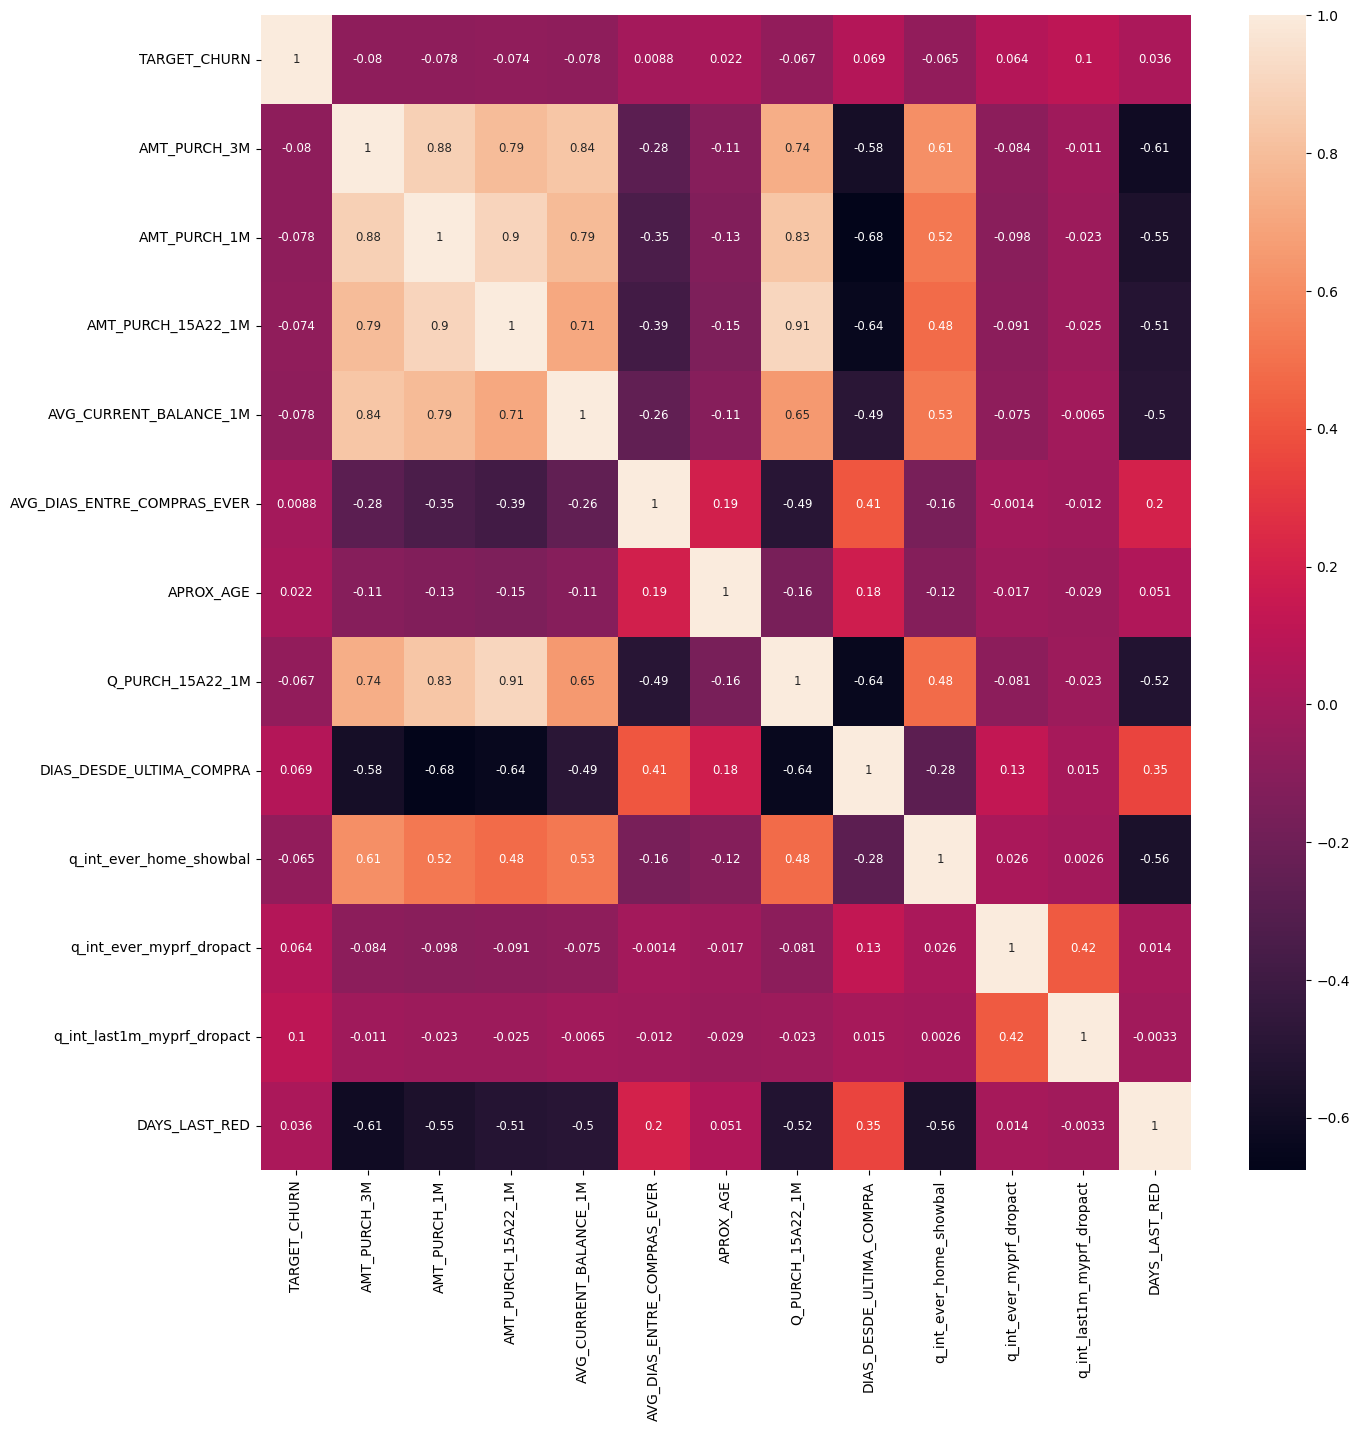

In [ ]:
plt.figure(figsize =(15,15))
sns.heatmap(df_final8[['TARGET_CHURN','AMT_PURCH_3M',
 'AMT_PURCH_1M',
 'AMT_PURCH_15A22_1M',
 'AVG_CURRENT_BALANCE_1M',
 'AVG_DIAS_ENTRE_COMPRAS_EVER',
 'APROX_AGE',
 'Q_PURCH_15A22_1M',
 'DIAS_DESDE_ULTIMA_COMPRA',
 'q_int_ever_home_showbal',
 'q_int_ever_myprf_dropact',
 'q_int_last1m_myprf_dropact',
 'DAYS_LAST_RED']].corr(),annot=True, annot_kws = {'size':8.5})

In [ ]:
df_variables = df_final8.drop(columns=[
"COUNTRY_1_EXTRANJERO","COUNTRY_1_PERU","COUNTRY_2_EXTRANJERO","COUNTRY_2_PERU",
"DOMAIN_EMAIL_cat_RESTO","DOMAIN_EMAIL_cat_gmail","DOMAIN_EMAIL_cat_hotmail","DOMAIN_EMAIL_cat_outlook","DOMAIN_EMAIL_cat_yahoo",
"GENDER_DESCONOCIDO","GENDER_FEMENINO","GENDER_MASCULINO",
"Lima_Prov_Lima","Lima_Prov_Provincia",
"PROFESION_cat_ABOGACIA","PROFESION_cat_ADMINISTRADOR","PROFESION_cat_COMUNIC","PROFESION_cat_CONTADOR",
"PROFESION_cat_DOCENTE","PROFESION_cat_ECONOMISTA","PROFESION_cat_INGENIERO","PROFESION_cat_PSICOLOGO",
"PROFESION_cat_RESTO","PROFESION_cat_TECNICO",
"TCF_LAST_INNING_afternoon","TCF_LAST_INNING_morning","TCF_LAST_INNING_unique",
"TCF_LAST_STATUS_CLOSED","TCF_LAST_STATUS_PENDING","TCF_LAST_STATUS_RECEIVED",
"USERDEVICE_PLATFORM_SO_ANDROID","USERDEVICE_PLATFORM_SO_IOS","USERDEVICE_PLATFORM_SO_OTROS",
"mobile_brand_name_APPLE","mobile_brand_name_OTROS","mobile_brand_name_SAMSUNG","mobile_brand_name_XIAOMI",
"q_int_last1m_bnf_seemore","q_int_last1m_bnf_share","q_int_last1m_cshb_about",
"q_int_last1m_pay_info","q_int_last1m_pay_yapeok"
]).copy()
corr_matrix = df_variables.corr(numeric_only=True)
#corr_matrix.to_csv('Matriz_Correlaciones.csv', index=True)

In [ ]:
### Estas columnas estan llenas de 0
#q_int_last1m_cshb_about,q_int_last1m_bnf_seemore, q_int_last1m_bnf_share, q_int_last1m_pay_yapeok, q_int_last1m_pay_info

In [ ]:
corr_long = corr_matrix.stack().reset_index()
corr_long.columns = ['variable_1', 'variable_2', 'correlacion']
corr_long = corr_long[corr_long['variable_1'] != corr_long['variable_2']]
corr_long['pair'] = corr_long.apply(
    lambda x: tuple(sorted([x['variable_1'], x['variable_2']])), axis=1
)
corr_long = corr_long.drop_duplicates('pair').drop(columns='pair')
corr_long['correlacion'] = round(corr_long['correlacion'],2)
corr_long

,variable_1,variable_2,correlacion
1,FLAG_ACTIVE_EVER,TARGET_CHURN,-0.06
2,FLAG_ACTIVE_EVER,AMT_PURCH_EVER,0.83
3,FLAG_ACTIVE_EVER,AMT_PURCH_3M,0.59
4,FLAG_ACTIVE_EVER,AMT_PURCH_1M,0.49
5,FLAG_ACTIVE_EVER,AMT_PHY_PURCH_EVER,0.39
...,...,...,...
96406,TOTAL_PRIZE,DAYS_OB_LASTREF,-0.77
96407,TOTAL_PRIZE,DAYS_LASTREF_TODATE,-0.79
96718,DAYS_OB_1STREF,DAYS_OB_LASTREF,0.97
96719,DAYS_OB_1STREF,DAYS_LASTREF_TODATE,0.70


In [ ]:
### Poder predictivo de variables
from sklearn.metrics import roc_auc_score

def gini_coefficient(y_true, y_pred):
    """
    Calcula el coeficiente de Gini basado en la métrica AUC.
    """
    return 2 * roc_auc_score(y_true, y_pred) - 1

def gini_for_features(df, target, variables):
    """
    Calcula el coeficiente de Gini para cada variable independiente en un DataFrame.

    Parámetros:
        df (pd.DataFrame): DataFrame con las variables predictoras y el target.
        target (str): Nombre de la columna objetivo binaria.

    Retorna:
        pd.Series: Gini de cada variable en orden descendente.
    """
    gini_scores = []
    for col in variables:
        if col in df.columns and col != target:
            try:
                if df[col].nunique() > 1:  # Evita columnas constantes
                    gini_scores.append((col, gini_coefficient(df[target], df[col]), roc_auc_score(df[target], df[col])))
            except Exception as e:
                print(f"Error con la variable {col}: {e}")

    return pd.DataFrame(gini_scores, columns=["Variable", "Gini", "AUC"]).sort_values(by="Gini", ascending=False)

In [ ]:
variables_predictivas = df_variables.columns.tolist()
variables_predictivas.remove('FECHA_SNAPSHOT')
variables_predictivas.remove('COD_CLIENTE')
variables_predictivas.remove('FECHA_TARGET')
variables_predictivas.remove('TARGET_CHURN')
len(variables_predictivas)

311

In [ ]:
dim_variables_poder_predictivo = gini_for_features(df_variables, 'TARGET_CHURN', variables_predictivas).copy()
dim_variables_poder_predictivo

,Variable,Gini,AUC
152,DIAS_DESDE_ULTIMA_COMPRA,0.319709,0.659855
283,DAYS_LAST_RED,0.190851,0.595426
151,MESES_DESDE_ULTIMA_COMPRA,0.188738,0.594369
191,flag_TC_STATUS_EVER,0.159400,0.579700
186,Q_TC_STATUS_EVER,0.158239,0.579119
...,...,...,...
79,AVG_CURRENT_BALANCE_1M,-0.355499,0.322250
2,AMT_PURCH_3M,-0.359688,0.320156
97,Q_PURCH_1M,-0.366192,0.316904
170,Q_MCC_TRX_LAST1M,-0.367893,0.316054


In [ ]:
corr_long2 = corr_long.merge(dim_variables_poder_predictivo,left_on='variable_1',right_on='Variable', how = 'left').rename(columns={'AUC': 'AUC_1'}).drop(columns=['Variable','Gini'])
corr_long2 = corr_long2.merge(dim_variables_poder_predictivo,left_on='variable_2',right_on='Variable', how = 'left').rename(columns={'AUC': 'AUC_2'}).drop(columns=['Variable','Gini'])
corr_long2 = corr_long2.sort_values(by='correlacion',ascending=False)
corr_long2.head(10)

,variable_1,variable_2,correlacion,AUC_1,AUC_2
48438,DAYS_1STCLICK_CONV,DAYS_1STDLVR_CONV,1.0,0.503746,0.503746
48396,DAYS_LASTCLICK_CONV,DAYS_LASTDLVR_CONV,1.0,0.503806,0.503806
40651,TCF_Q_REPLACEMENTS,flag_TCF_Q_REPLACEMENTS,1.0,0.492815,0.492815
38786,TOTAL_ATTEMPTS_OB,DAYS_DISTCT_ATT_OB,1.0,0.481279,0.481315
36612,Q_REJ_MAXAMT_EVER,flag_REJ_MAXAMT_EVER,1.0,0.497889,0.497889
34986,MESES_CON_CONSUMO,MESES_CON_CONSUMO_10,1.0,0.450057,0.450626
47614,q_int_last1m_pay_home,q_int_last1m_pay_show,1.0,0.357427,0.357417
47571,q_int_ever_pay_home,q_int_ever_pay_show,1.0,0.347893,0.346770
18135,AMT_REJ_MAXAMT_3M,AMT_REJ_MAXAMT_1M,1.0,0.499987,0.499987
18012,AMT_REJ_MAXAMT_EVER,flag_REJ_MAXAMT_EVER,1.0,0.497889,0.497889


In [ ]:
corr_long2.to_excel('Matriz_Cor_auc.xlsx', index=False)

In [ ]:
corr_long3 = corr_long2[corr_long2['variable_1']!='TARGET_CHURN'].copy()
corr_long3 = corr_long3[corr_long3['variable_2']!='TARGET_CHURN'].copy()
corr_long3['correlacion'] = corr_long3['correlacion'].abs()
corr_long3 = corr_long3.sort_values(by=['correlacion','AUC_1'],ascending=[False,False])
corr_long3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 48205 entries, 48396 to 1298
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   variable_1   48205 non-null  object 
 1   variable_2   48205 non-null  object 
 2   correlacion  48205 non-null  float64
 3   AUC_1        48205 non-null  float64
 4   AUC_2        48205 non-null  float64
dtypes: float64(3), object(2)
memory usage: 2.2+ MB


In [ ]:
corr_long3

,variable_1,variable_2,correlacion,AUC_1,AUC_2
48396,DAYS_LASTCLICK_CONV,DAYS_LASTDLVR_CONV,1.0,0.503806,0.503806
48438,DAYS_1STCLICK_CONV,DAYS_1STDLVR_CONV,1.0,0.503746,0.503746
18135,AMT_REJ_MAXAMT_3M,AMT_REJ_MAXAMT_1M,1.0,0.499987,0.499987
36735,Q_REJ_MAXAMT_3M,Q_REJ_MAXAMT_1M,1.0,0.499987,0.499987
18012,AMT_REJ_MAXAMT_EVER,flag_REJ_MAXAMT_EVER,1.0,0.497889,0.497889
...,...,...,...,...,...
1327,AMT_PURCH_1M,HORA_INICIO_ONBOARDING,0.0,0.313154,0.494582
1299,AMT_PURCH_1M,AMT_REJ_MAXAMT_1M,0.0,0.313154,0.499987
1301,AMT_PURCH_1M,AMT_REJ_BAD_3M,0.0,0.313154,0.499672
1302,AMT_PURCH_1M,AMT_REJ_BAD_1M,0.0,0.313154,0.499960


In [ ]:
flag_correlacion = 1
variables_multicolinealidad = []
corr_long4 = corr_long3.copy()
while flag_correlacion >= 0.80:
  valor_variable1 = corr_long4.iloc[0, 0]
  valor_variable2 = corr_long4.iloc[0, 1]
  #valor_correlacion = corr_long3.iloc[0, 2]
  valor_auc1 = corr_long4.iloc[0, 3]
  valor_auc2 = corr_long4.iloc[0, 4]

  if valor_auc1 >= valor_auc2:
    variables_multicolinealidad.append(valor_variable2)
    var_mult = valor_variable2
  else:
    variables_multicolinealidad.append(valor_variable1)
    var_mult = valor_variable1
  print('================================================================')
  print(f"Variable con multicolinealidad: {var_mult}")
  corr_long4 = corr_long4[corr_long4['variable_1']!=var_mult]
  corr_long4 = corr_long4[corr_long4['variable_2']!=var_mult]
  corr_long4 = corr_long4.sort_values(by='correlacion',ascending=False)
  flag_correlacion = corr_long4.iloc[0, 2]

Variable con multicolinealidad: DAYS_LASTDLVR_CONV
Variable con multicolinealidad: DAYS_1STDLVR_CONV
Variable con multicolinealidad: q_int_last1m_pay_show
Variable con multicolinealidad: AMT_REJ_MAXAMT_1M
Variable con multicolinealidad: Q_REJ_MAXAMT_1M
Variable con multicolinealidad: TOTAL_ATTEMPTS_OB
Variable con multicolinealidad: Q_REJ_MAXAMT_EVER
Variable con multicolinealidad: flag_TCF_Q_REPLACEMENTS
Variable con multicolinealidad: flag_REJ_MAXAMT_EVER
Variable con multicolinealidad: q_int_ever_pay_show
Variable con multicolinealidad: MESES_CON_CONSUMO
Variable con multicolinealidad: Q_MAILING_CUSTIO_EMAIL
Variable con multicolinealidad: REFERENT_QTY_REFERRALS
Variable con multicolinealidad: Q_MAILING_CUSTIO_EMAIL_SENT
Variable con multicolinealidad: MAX_CREDIT_LINE_1M
Variable con multicolinealidad: REFERENT_PRIZE
Variable con multicolinealidad: q_int_ever_sdta_ccd
Variable con multicolinealidad: q_int_ever_cshb_error
Variable con multicolinealidad: q_int_ever_notfcrdlim_50_off
V

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
X = df_final8[variables_multicolinealidad].copy()
X = X.replace([np.inf, -np.inf], np.nan)
X = X.dropna(axis=1, how='all')
X = X.loc[:, X.nunique() > 1]
X = X.dropna()
X = X.astype(float)

vif_df = pd.DataFrame({
    "variable": X.columns,
    "VIF": [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
vif_df

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/outliers_influence.py:197: RuntimeWarning: divide by zero encountered in scalar divide
  vif = 1. / (1. - r_squared_i)


,variable,VIF
0,DAYS_LASTDLVR_CONV,1108.425382
1,DAYS_1STDLVR_CONV,inf
2,q_int_last1m_pay_show,9.395175
3,AMT_REJ_MAXAMT_1M,2.392242
4,Q_REJ_MAXAMT_1M,2.394692
...,...,...
142,SUM_PAYMENT_AMT_EVER,61.312126
143,AMT_PAYMENT_3M,6.704098
144,HORA_INICIO_ONBOARDING,8.437200
145,AMT_PURCH_15A22_3M,99.252565


In [ ]:
variables_boruta = ['AMT_PURCH_3M',
 'AMT_PURCH_1M',
 'AMT_PURCH_15A22_1M',
 'AVG_CURRENT_BALANCE_1M',
 'AVG_DIAS_ENTRE_COMPRAS_EVER',
 'APROX_AGE',
 'Q_PURCH_15A22_1M',
 'DIAS_DESDE_ULTIMA_COMPRA',
 'q_int_ever_home_showbal',
 'q_int_ever_myprf_dropact',
 'q_int_last1m_myprf_dropact',
 'DAYS_LAST_RED']
variables_VIF_multicolinealidad =  [
"DAYS_1STDLVR_CONV","Q_REJ_MAXAMT_EVER","flag_REJ_MAXAMT_EVER","DAYS_1STCLICK_CONV","MESES_CON_CONSUMO","MESES_CON_CONSUMO_10",
"Q_PURCH_EVER","DAYS_LASTDLVR_CONV","Q_PURCH_3M","q_int_ever_pay_home","q_int_ever_pay_show","Q_PURCH_15A22_EVER",
"AMT_PURCH_EVER","Q_MAILING_CUSTIO_EMAIL","Q_PURCH_1M","Q_PURCH_15A22_3M","Q_WE_PURCH_EVER","DAYS_DISTCT_ATT_OB",
"TOTAL_ATTEMPTS_OB","DAYS_OB_LASTREF","Q_PURCH_7A14_EVER","AMT_PURCH_3M","Q_MAILING_CUSTIO_EMAIL_SENT",
"Q_MCC_TRX_LAST3M","Q_MCC_TRX_EVER","Q_MAILING_CUSTIO","AMT_PURCH_15A22_EVER","Q_DISTINCT_CREDITLINE_EVER",
"Q_MCC_TRX_LAST1M","AMT_PURCH_15A22_3M","MAX_CREDIT_LINE_1M","REFERENT_QTY_REFERRALS",
"AVG_CURRENT_BALANCE_3M","AVG_CURRENT_BALANCE_EVER","Q_WE_PURCH_3M","MONTHS_WITH_REFERRALS",
"Q_PURCH_15A22_1M","AMT_PURCH_1M","AMT_WE_PURCH_EVER","Q_PURCH_7A14_3M","AMT_PURCH_7A14_EVER",
"q_int_ever_cshb_error","q_int_ever_cshb_tryuse","AVG_STATEMENT_BALANCE_3M","SUM_PAYMENT_AMT_EVER",
"AVG_CURRENT_BALANCE_1M","REFERENT_PRIZE","AVG_STATEMENT_BALANCE_1M","AMT_WE_PURCH_3M",
"Q_MONTHS_CASHBACK_REDEEMED_EVER","AMT_PURCH_15A22_1M","Q_PURCH_7A14_1M","Q_DISTINCT_APRVALUE_3M",
"Q_PHY_PURCH_3M","q_int_ever_home_crdetails","Q_SUPER_EVER","q_int_ever_home_amtmov","Q_SUPER_3M",
"Q_TAXI_3M","Q_STREAMING_3M","MESES_DESDE_ULTIMA_COMPRA","DAYS_LASTOP_CONV","PORC_UTILIZ_3M",
"q_int_ever_sdta_ccd","AMT_PURCH_7A14_1M","PORC_UTILIZ_1M","Q_DELIVERY_3M","AMT_TAXI_3M",
"AMT_SUPER_3M","DAYS_LAST_1ST_OPENED","AMT_DELIVERY_3M","AMT_PHY_PURCH_3M","Q_RESTAUR_EVER",
"Q_PURCH_23A6_EVER","Q_TC_STATUS_EVER","AMT_CASHBACK_REDEEMED_EVER","Q_AUTO_3M","Q_RESTAUR_3M",
"SUM_PAYMENT_AMT_1M","AMT_STREAMING_3M","flag_REJ_BAD_EVER","Q_REJ_BAD_EVER","Q_REJ_INSFD_3M",
"Q_REJ_INSFD_EVER","AMT_RESTCOMRAPIDA_3M","AMT_AUTO_3M","AMT_REJ_INSFD_3M","flag_DISTINCT_APRVALUE_EVER",
"Q_PHY_PURCH_EVER","Q_PHY_PURCH_1M","flag_DISTINCT_CREDITLINE_EVER","AMT_WE_PURCH_1M",
"AMT_REJ_INSFD_EVER","AMT_RESTCOMRAPIDA_EVER"
]

# ***Modelado Variables Boruta***
----------------------------------------------------------------------------------------------------------------------------------------------




In [ ]:
sql = f"""
SELECT
* EXCEPT (MAX_CREDIT_LINE_EVER,
 q_int_ever_home_benefits,
 q_int_ever_ref_bau,
 q_int_last1m_cshb_error,
 q_int_last1m_cshb_success,
 q_int_last1m_cshb_tryuse,
 q_int_last1m_home_benefits,
 q_int_last1m_sdta_ccd,
 q_int_last1m_sdta_ccdshow,q_int_last1m_cshb_about,q_int_last1m_bnf_seemore, q_int_last1m_bnf_share, q_int_last1m_pay_yapeok, q_int_last1m_pay_info)
FROM data-matrix-lab-ss.DS_WORKSPACE_ALAB.DATASET_RETRAIN_CHURN_V3_HAROLD
WHERE FECHA_SNAPSHOT >= '2025-10-01'
"""
df_final8 = client.query(sql).to_dataframe()
df_final8.shape

(473998, 352)

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split
df_final9 = df_final8.copy()
df_final9['FECHA_SNAPSHOT'] = pd.to_datetime(df_final9['FECHA_SNAPSHOT'])
train = pd.to_datetime([
    '2025-10-01','2025-11-01','2025-12-01','2026-01-01','2026-02-01','2026-03-01','2026-04-01'
])
validation = pd.to_datetime(['2026-05-01'])
variables_predictivas = ['AMT_PURCH_3M',
 'AMT_PURCH_1M',
 'AMT_PURCH_15A22_1M',
 'AVG_CURRENT_BALANCE_1M',
 'AVG_DIAS_ENTRE_COMPRAS_EVER',
 'APROX_AGE',
 'Q_PURCH_15A22_1M',
 'DIAS_DESDE_ULTIMA_COMPRA',
 'q_int_ever_home_showbal',
 'q_int_ever_myprf_dropact',
 'q_int_last1m_myprf_dropact',
 'DAYS_LAST_RED']
data_train = df_final9[df_final9['FECHA_SNAPSHOT'].isin(train)].copy()
data_validation = df_final9[df_final9['FECHA_SNAPSHOT'].isin(validation)].copy()
x = data_train.drop(columns=['FECHA_SNAPSHOT','COD_CLIENTE','FECHA_TARGET','TARGET_CHURN']).copy()
y = data_train['TARGET_CHURN'].copy()

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)
x_valid = data_validation.drop(columns=['FECHA_SNAPSHOT','COD_CLIENTE','FECHA_TARGET','TARGET_CHURN']).copy()
y_valid = data_validation['TARGET_CHURN'].copy()

In [ ]:
x_train.shape, x_test.shape, x_valid.shape, df_final9.shape

((316298, 348), (79075, 348), (78625, 348), (473998, 352))

In [ ]:
y_train.value_counts(normalize=True)

,proportion
TARGET_CHURN,
0,0.986342
1,0.013658


In [ ]:
y_train.value_counts()

,count
TARGET_CHURN,
0,311978
1,4320


In [ ]:
y_test.value_counts(normalize=True)

,proportion
TARGET_CHURN,
0,0.987151
1,0.012849


In [ ]:
y_valid.value_counts(normalize=True)

,proportion
TARGET_CHURN,
0,0.990703
1,0.009297


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score,roc_curve,accuracy_score,recall_score,precision_score
from sklearn.metrics import f1_score

In [ ]:
### Funcion de modelado
def modelo_aplicado (modelo, xTrain, yTrain, xTest, yTest, xValid, yValid):
  modelo.fit(xTrain,yTrain)
  predicciones_test = modelo.predict(xTest)
  predicciones_train = modelo.predict(xTrain)
  predicciones_valid = modelo.predict(xValid)
  predicciones_prob_test = modelo.predict_proba(xTest)
  predicciones_prob_train = modelo.predict_proba(xTrain)
  predicciones_prob_valid = modelo.predict_proba(xValid)
  tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, predicciones_test).ravel()
  tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, predicciones_train).ravel()
  tn_valid, fp_valid, fn_valid, tp_valid = confusion_matrix(y_valid, predicciones_valid).ravel()



  #Mostrando las métricas
  print('Accuracy Test:',accuracy_score(yTest, predicciones_test))
  print('Accuracy Train:',accuracy_score(yTrain, predicciones_train))
  print('Accuracy Validation:',accuracy_score(yValid, predicciones_valid))
  print('AUC-ROC Test:',roc_auc_score(yTest,predicciones_prob_test[:,1] ))
  print('AUC-ROC Train:',roc_auc_score(yTrain,predicciones_prob_train[:,1]))
  print('AUC-ROC Validation:',roc_auc_score(yValid,predicciones_prob_valid[:,1]))
  print('Sensibilidad Test:',recall_score(yTest, predicciones_test, pos_label = 1))
  print('Sensibilidad Train:',recall_score(yTrain, predicciones_train, pos_label = 1))
  print('Sensibilidad Valid:',recall_score(yValid, predicciones_valid, pos_label = 1))
  print('Especificidad Test:',recall_score(yTest, predicciones_test, pos_label = 0))
  print('Especificidad Train:',recall_score(yTrain, predicciones_train, pos_label = 0))
  print('Especificidad Valid:',recall_score(yValid, predicciones_valid, pos_label = 0))
  print('F1 Score Test:',f1_score(yTest, predicciones_test))
  print('F1 Score Train:',f1_score(yTrain, predicciones_train))
  print('F1 Score Valid:',f1_score(yValid, predicciones_valid))
  print('Tasa de FN Test:', fn_test / (tn_test + fn_test))
  print('Tasa de FN Train:', fn_train / (tn_train + fn_train))
  print('Tasa de FN Valid:', fn_valid / (tn_valid + fn_valid))
  print('Precision Test:', precision_score(y_test, predicciones_test))
  print('Precision Train:', precision_score(y_train, predicciones_train))
  print('Precision Valid:', precision_score(y_valid, predicciones_valid))

  #Matriz de Confusión
  cm = confusion_matrix(yTest, predicciones_test)
  disp = ConfusionMatrixDisplay(cm)
  disp.plot()
  plt.title('MATRIZ CONFUSIÓN (TEST)')
  plt.show()


  ##Curva AUC ROC
  fpr_test, tpr_test, thresholds_test = roc_curve(yTest, predicciones_prob_test[:,1])
  fpr_train, tpr_train, thresholds_train = roc_curve(yTrain, predicciones_prob_train[:,1])
  fpr_valid, tpr_valid, thresholds_valid = roc_curve(yValid, predicciones_prob_valid[:,1])
  plt.plot(fpr_test, tpr_test, color = 'red', label = f'AUC Test:{round(roc_auc_score(yTest,predicciones_prob_test[:,1] ),4)}')
  plt.plot(fpr_train, tpr_train, color = 'green', label = f'AUC Train:{round(roc_auc_score(yTrain,predicciones_prob_train[:,1] ),4)}')
  plt.plot(fpr_valid, tpr_valid, color = 'pink', label = f'AUC Valid:{round(roc_auc_score(yValid,predicciones_prob_valid[:,1] ),4)}')
  plt.plot([0, 1], [0, 1])
  plt.legend()
  plt.title('CURVA ROC')
  plt.show()

In [ ]:
x_train = x_train[variables_boruta].copy()
x_test = x_test[variables_boruta].copy()
x_valid = x_valid[variables_boruta].copy()

Accuracy Test: 0.7417262092949731
Accuracy Train: 0.741784646124857
Accuracy Validation: 0.7826899841017488
Sensibilidad Test: 0.6822519083969466
Sensibilidad Train: 0.7371735074626866
Sensibilidad Valid: 0.4952120383036936
Especificidad Test: 0.7425250233893396
Especificidad Train: 0.7418480176917407
Especificidad Valid: 0.7853878347497881
F1 Score Test: 0.06543723973825104
F1 Score Train: 0.0718449911926814
F1 Score Valid: 0.04065131948343627
Tasa de FN Test: 0.005714776042560495
Tasa de FN Train: 0.0048454153428120605
Tasa de FN Valid: 0.0059955155493452055
Precision Test: 0.03436673876472002
Precision Train: 0.03776267217795405
Precision Valid: 0.021195620352479655


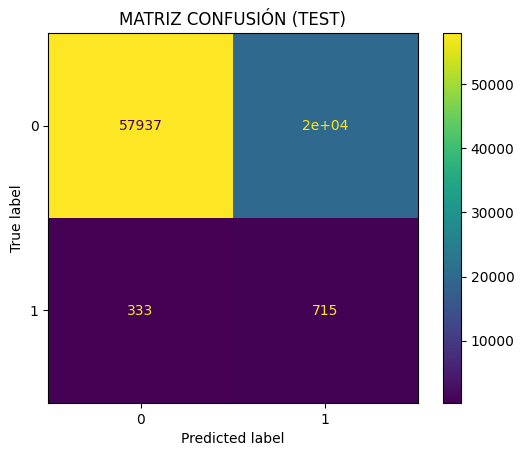

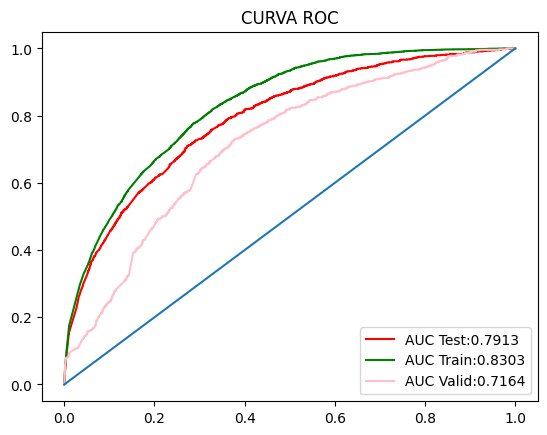

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
modelo_hgb = HistGradientBoostingClassifier(
    #max_depth=6,
    #learning_rate=0.05,
    #max_iter=300,
    class_weight='balanced'
)
modelo_aplicado(modelo_hgb, x_train, y_train, x_test, y_test, x_valid, y_valid)

Accuracy Test: 0.7414479924122669
Accuracy Train: 0.7408772739631613
Accuracy Validation: 0.77939586645469
Sensibilidad Test: 0.683206106870229
Sensibilidad Train: 0.7133861940298507
Sensibilidad Valid: 0.4911080711354309
Especificidad Test: 0.7422302536301537
Especificidad Train: 0.7412550879779495
Especificidad Valid: 0.782101317174622
F1 Score Test: 0.06545687251451296
F1 Score Train: 0.06946115942687163
F1 Score Valid: 0.039749764712395504
Tasa de FN Test: 0.005699962229165951
Tasa de FN Train: 0.005285839627023586
Tasa de FN Valid: 0.006069208555626255
Precision Test: 0.03437515003120649
Precision Train: 0.03650793650793651
Precision Valid: 0.020713131779367643


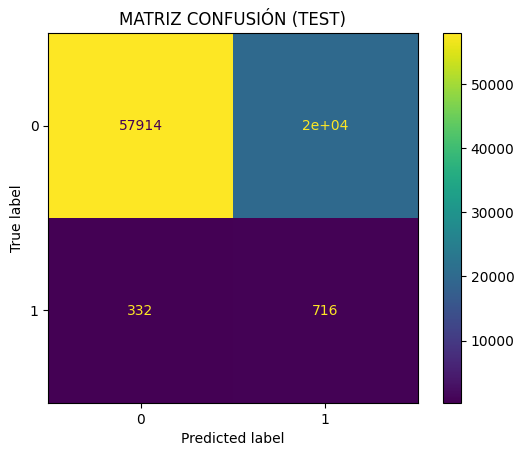

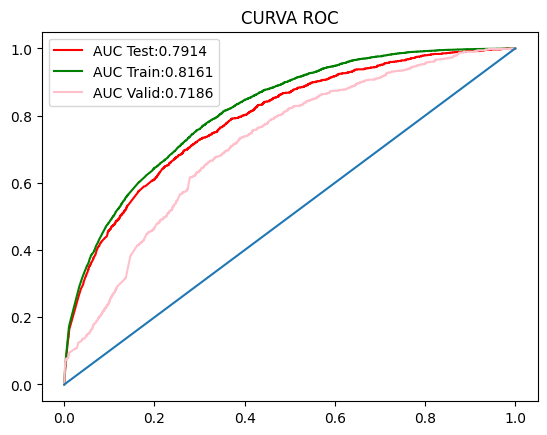

In [ ]:
modelo_hgb2 = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    max_iter=300,
    class_weight='balanced'
)
modelo_aplicado(modelo_hgb2, x_train, y_train, x_test, y_test, x_valid, y_valid)

Accuracy Test: 0.8017831172937085
Accuracy Train: 0.8084559497688888
Accuracy Validation: 0.8377996820349761
Sensibilidad Test: 0.5906488549618321
Sensibilidad Train: 0.9361007462686567
Sensibilidad Valid: 0.3693570451436389
Especificidad Test: 0.8046189139656785
Especificidad Train: 0.8067017082785808
Especificidad Valid: 0.842195804554908
F1 Score Test: 0.07320245979186377
F1 Score Train: 0.11700406628481483
F1 Score Valid: 0.040622884224779957
Tasa de FN Test: 0.006786793437851007
Tasa de FN Train: 0.0010874180963833426
Tasa de FN Valid: 0.006978187487701134
Precision Test: 0.039019162884518406
Precision Train: 0.06240186552662262
Precision Valid: 0.021493392771851617


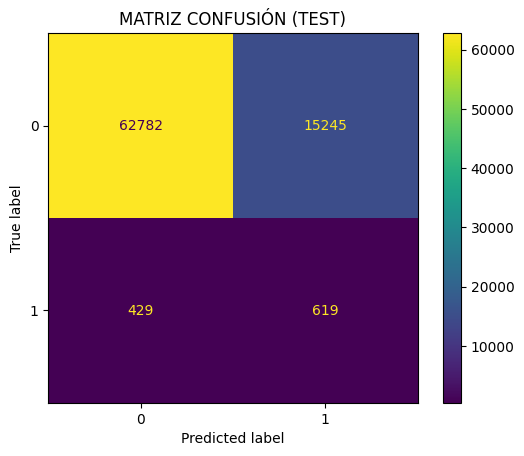

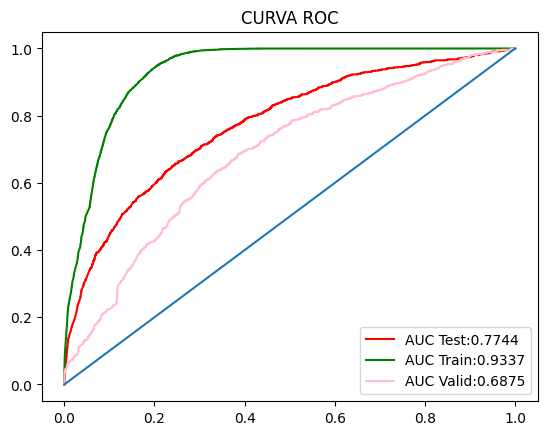

In [ ]:
import xgboost as xgb
modelo_xgb=xgb.XGBClassifier(scale_pos_weight=72)
modelo_aplicado(modelo_xgb, x_train, y_train, x_test, y_test, x_valid, y_valid)

[LightGBM] [Info] Number of positive: 4288, number of negative: 312010
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.005715 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 2095
[LightGBM] [Info] Number of data points in the train set: 316298, number of used features: 12
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.013557 -> initscore=-4.287215
[LightGBM] [Info] Start training from score -4.287215
Accuracy Test: 0.7783243755927917
Accuracy Train: 0.7802578580958464
Accuracy Validation: 0.8160763116057234
Sensibilidad Test: 0.648854961832061
Sensibilidad Train: 0.8505130597014925
Sensibilidad Valid: 0.4322845417236662
Especificidad Test: 0.7800633114178426
Especificidad Train: 0.7792923303740265
Especificidad Valid: 0.819678023981308
F1 Score Test: 0.07199957647307957
F1 Score Train: 0.09497643167790829
F1 Score Valid: 0.0418737162

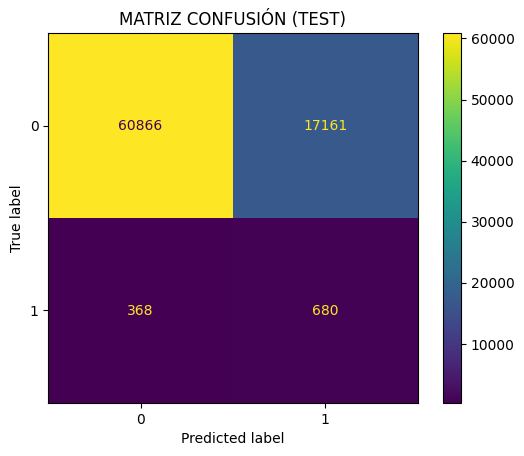

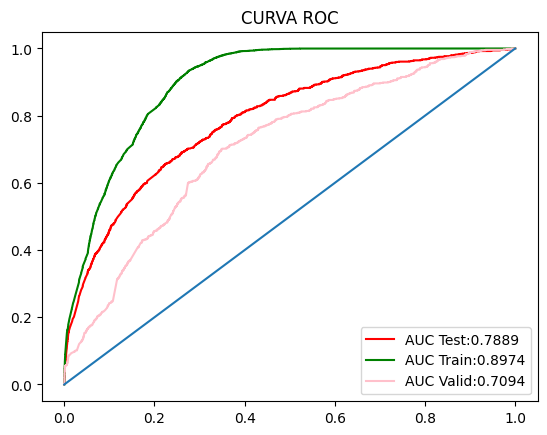

In [ ]:
from lightgbm import LGBMClassifier
modelo_lgb2 = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train[y_train==0]) / len(y_train[y_train==1]))
)
modelo_aplicado(modelo_lgb2, x_train, y_train, x_test, y_test, x_valid, y_valid)

Accuracy Test: 0.9865064811887448
Accuracy Train: 0.9865791121031432
Accuracy Validation: 0.9904992050874404
Sensibilidad Test: 0.003816793893129771
Sensibilidad Train: 0.01655783582089552
Sensibilidad Valid: 0.006839945280437756
Especificidad Test: 0.999705230240814
Especificidad Train: 0.9999102592865613
Especificidad Valid: 0.9997304028551621
F1 Score Test: 0.0074418604651162795
F1 Score Train: 0.03236836106678824
F1 Score Valid: 0.013210039630118891
Tasa de FN Test: 0.013207165266673414
Tasa de FN Train: 0.013336538066217794
Tasa de FN Valid: 0.009236758737388516
Precision Test: 0.14814814814814814
Precision Train: 0.7171717171717171
Precision Valid: 0.19230769230769232


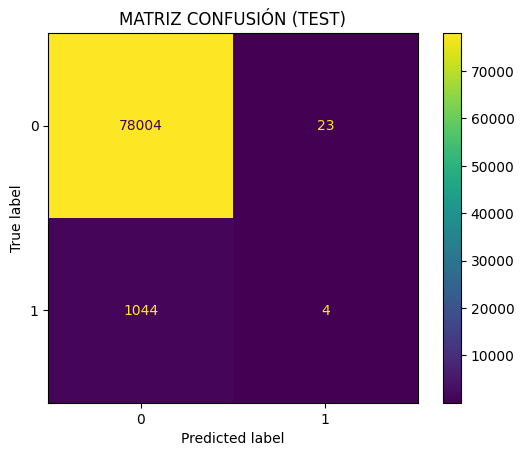

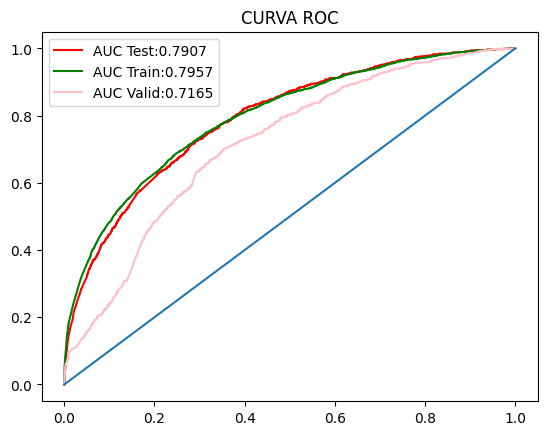

In [ ]:
modelo_gb = GradientBoostingClassifier()
modelo_aplicado(modelo_gb, x_train, y_train, x_test, y_test, x_valid, y_valid)

***Validación Rolling (variables Boruta)***
----------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
from sklearn.base import clone
from sklearn.metrics import roc_auc_score

# =========================
# 1) Preparación
# =========================
df = df_final9.copy()
df["FECHA_SNAPSHOT"] = pd.to_datetime(df["FECHA_SNAPSHOT"])

variables_predictivas = [
    'AMT_PURCH_3M',
    'AMT_PURCH_1M',
    'AMT_PURCH_15A22_1M',
    'AVG_CURRENT_BALANCE_1M',
    'AVG_DIAS_ENTRE_COMPRAS_EVER',
    'APROX_AGE',
    'Q_PURCH_15A22_1M',
    'DIAS_DESDE_ULTIMA_COMPRA',
    'q_int_ever_home_showbal',
    'q_int_ever_myprf_dropact',
    'q_int_last1m_myprf_dropact',
    'DAYS_LAST_RED'
]
df = df.sort_values("FECHA_SNAPSHOT").reset_index(drop=True)
meses = sorted(df["FECHA_SNAPSHOT"].dropna().unique())
meses = [m for m in meses if m in pd.to_datetime([
    '2025-10-01','2025-11-01','2025-12-01',
    '2026-01-01','2026-02-01','2026-03-01',
    '2026-04-01','2026-05-01'
])]

#print("Meses considerados:")
#print(pd.to_datetime(meses).strftime("%Y-%m-%d").tolist())


# =========================
# 2) Función rolling / expanding window
# =========================
def rolling_time_validation(
    df,
    date_col,
    target_col,
    features,
    model,
    months=None,
    min_train_months=3,
    verbose=True
):
    """
    Validación temporal expansiva:
    - Entrena con todos los meses anteriores
    - Testea con el mes siguiente
    - Repite mes a mes

    Retorna:
    - results_df: métricas por fold
    - models: modelos entrenados por fold
    """
    data = df.copy()
    data[date_col] = pd.to_datetime(data[date_col])

    # Meses ordenados
    if months is None:
        months = sorted(data[date_col].dropna().unique())
    else:
        months = sorted(pd.to_datetime(months))

    results = []
    fitted_models = []

    for i in range(min_train_months, len(months)):
        train_months = months[:i]
        test_month = months[i]

        train_mask = data[date_col].isin(train_months)
        test_mask = data[date_col] == test_month

        train_df = data.loc[train_mask, features + [target_col]].dropna().copy()
        test_df = data.loc[test_mask, features + [target_col]].dropna().copy()

        # Seguridad: si no hay datos o hay una sola clase, saltar fold
        if train_df.empty or test_df.empty or test_df[target_col].nunique() < 2:
            if verbose:
                print(f"Saltando fold {pd.to_datetime(test_month).strftime('%Y-%m-%d')} "
                      f"(train={len(train_df)}, test={len(test_df)}, "
                      f"classes_test={test_df[target_col].nunique() if not test_df.empty else 0})")
            continue

        X_train = train_df[features]
        y_train = train_df[target_col].astype(int)

        X_test = test_df[features]
        y_test = test_df[target_col].astype(int)

        # Clonar modelo para no reutilizar el ajuste anterior
        mdl = clone(model)
        mdl.fit(X_train, y_train)

        # Score AUC
        train_proba = mdl.predict_proba(X_train)[:, 1]
        test_proba = mdl.predict_proba(X_test)[:, 1]

        auc_train = roc_auc_score(y_train, train_proba)
        auc_test = roc_auc_score(y_test, test_proba)

        results.append({
            "test_month": pd.to_datetime(test_month).strftime("%Y-%m-%d"),
            "train_months": [pd.to_datetime(m).strftime("%Y-%m-%d") for m in train_months],
            "n_train": len(train_df),
            "n_test": len(test_df),
            "pos_rate_train": y_train.mean(),
            "pos_rate_test": y_test.mean(),
            "auc_train": auc_train,
            "auc_test": auc_test,
            "gap_train_test": auc_train - auc_test
        })

        fitted_models.append({
            "test_month": pd.to_datetime(test_month).strftime("%Y-%m-%d"),
            "model": mdl
        })

        if verbose:
            print(
                f"Fold {pd.to_datetime(test_month).strftime('%Y-%m-%d')} | "
                f"AUC train: {auc_train:.4f} | AUC test: {auc_test:.4f} | "
                f"gap: {auc_train - auc_test:.4f}"
            )

    results_df = pd.DataFrame(results).sort_values("test_month").reset_index(drop=True)
    return results_df, fitted_models

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import HistGradientBoostingClassifier

modelos = {
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        solver="lbfgs"
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=123),
    "HistGradientBoosting": HistGradientBoostingClassifier(
        random_state=123,
        max_depth=3,
        learning_rate=0.05,
        max_iter=200
    )
}

todos_resultados = []

for nombre, mdl in modelos.items():
    res, _ = rolling_time_validation(
        df=df,
        date_col="FECHA_SNAPSHOT",
        target_col="TARGET_CHURN",
        features=variables_predictivas,
        model=mdl,
        months=meses,
        min_train_months=3,
        verbose=False
    )
    res["modelo"] = nombre
    todos_resultados.append(res)

df_resultados = pd.concat(todos_resultados, ignore_index=True)

print(df_resultados[["modelo", "test_month", "auc_train", "auc_test", "gap_train_test"]])

print("\nPromedio por modelo:")
print(
    df_resultados.groupby("modelo")[["auc_train", "auc_test", "gap_train_test"]]
    .mean()
    .sort_values("auc_test", ascending=False)
)

                  modelo  test_month  auc_train  auc_test  gap_train_test
0     LogisticRegression  2026-01-01   0.806190  0.656286        0.149904
1     LogisticRegression  2026-02-01   0.788043  0.648749        0.139294
2     LogisticRegression  2026-03-01   0.776109  0.663799        0.112310
3     LogisticRegression  2026-04-01   0.766717  0.677889        0.088828
4     LogisticRegression  2026-05-01   0.759742  0.698211        0.061531
5       GradientBoosting  2026-01-01   0.846919  0.660978        0.185941
6       GradientBoosting  2026-02-01   0.822479  0.673195        0.149284
7       GradientBoosting  2026-03-01   0.811417  0.683616        0.127801
8       GradientBoosting  2026-04-01   0.801802  0.701926        0.099875
9       GradientBoosting  2026-05-01   0.795547  0.719090        0.076457
10  HistGradientBoosting  2026-01-01   0.847033  0.664057        0.182976
11  HistGradientBoosting  2026-02-01   0.828659  0.669319        0.159340
12  HistGradientBoosting  2026-03-01  

In [ ]:
df_resultados.to_excel('Experimentacion_mensual.xlsx', index=False)

***Modelado Variables Boruta (sin variables digitales)***
----------------------------------------------------------------------------------------------------------------------------------------------





In [ ]:
df_final9 = df_final8.copy()
df_final9['FECHA_SNAPSHOT'] = pd.to_datetime(df_final9['FECHA_SNAPSHOT'])
train = pd.to_datetime([
    '2025-10-01','2025-11-01','2025-12-01','2026-01-01','2026-02-01','2026-03-01','2026-04-01'
])
validation = pd.to_datetime(['2026-05-01'])
variables_predictivas = ['AMT_PURCH_3M',
 'AMT_PURCH_1M',
 'AMT_PURCH_15A22_1M',
 'AVG_CURRENT_BALANCE_1M',
 'AVG_DIAS_ENTRE_COMPRAS_EVER',
 'APROX_AGE',
 'Q_PURCH_15A22_1M',
 'DIAS_DESDE_ULTIMA_COMPRA',
 'DAYS_LAST_RED']
data_train = df_final9[df_final9['FECHA_SNAPSHOT'].isin(train)].copy()
data_validation = df_final9[df_final9['FECHA_SNAPSHOT'].isin(validation)].copy()
x = data_train[variables_predictivas].copy()
y = data_train['TARGET_CHURN'].copy()

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)
x_valid = data_validation[variables_predictivas].copy()
y_valid = data_validation['TARGET_CHURN'].copy()

Accuracy Test: 0.6846917483401833
Accuracy Train: 0.6862926733649912
Accuracy Validation: 0.7262829888712241
AUC-ROC Test: 0.7642441090138461
AUC-ROC Train: 0.7940841381443563
AUC-ROC Validation: 0.7076157935630858
Sensibilidad Test: 0.7204724409448819
Sensibilidad Train: 0.7546296296296297
Sensibilidad Valid: 0.585499316005472
Especificidad Test: 0.684226034153653
Especificidad Train: 0.6853464026309547
Especificidad Valid: 0.7276041800395409
F1 Score Test: 0.05546084782361632
F1 Score Train: 0.06165776159629297
F1 Score Valid: 0.03825356392724673
Tasa de FN Test: 0.005289231571497747
Tasa de FN Train: 0.00493314655633793
Tasa de FN Valid: 0.005317748644237351
Precision Test: 0.028840471218628108
Precision Train: 0.032141976830170074
Precision Valid: 0.01977270627367643


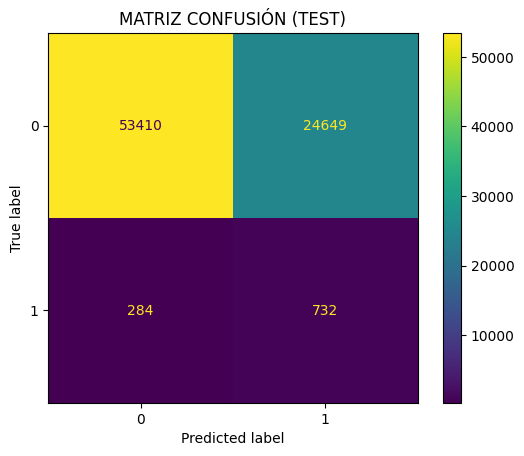

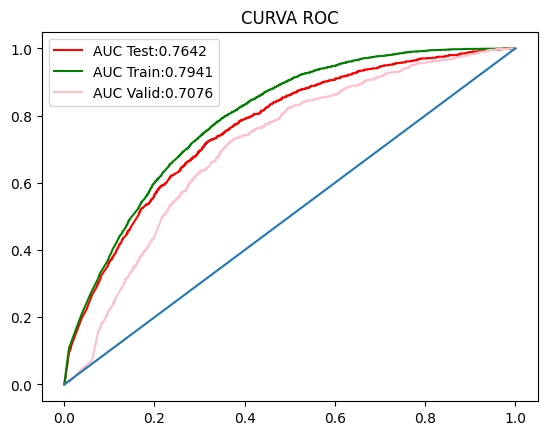

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
modelo_hgb2 = HistGradientBoostingClassifier(
    max_depth=6,
    learning_rate=0.05,
    max_iter=300,
    class_weight='balanced'
)
modelo_aplicado(modelo_hgb2, x_train, y_train, x_test, y_test, x_valid, y_valid)

Accuracy Test: 0.7505659184318685
Accuracy Train: 0.7603494173216397
Accuracy Validation: 0.7888330683624801
AUC-ROC Test: 0.7487566441011255
AUC-ROC Train: 0.9135402123855837
AUC-ROC Validation: 0.6903828616650703
Sensibilidad Test: 0.6082677165354331
Sensibilidad Train: 0.9530092592592593
Sensibilidad Valid: 0.47606019151846785
Especificidad Test: 0.7524180427625258
Especificidad Train: 0.7576816313970857
Especificidad Valid: 0.7917683005109508
F1 Score Test: 0.05896946564885496
F1 Score Train: 0.09798298328077587
F1 Score Valid: 0.04023353951095439
Tasa de FN Test: 0.00673081801423957
Tasa de FN Train: 0.0008580498176115782
Tasa de FN Valid: 0.006171745330905458
Precision Test: 0.03098676293622142
Precision Train: 0.051646490622843884
Precision Valid: 0.021004345726702078


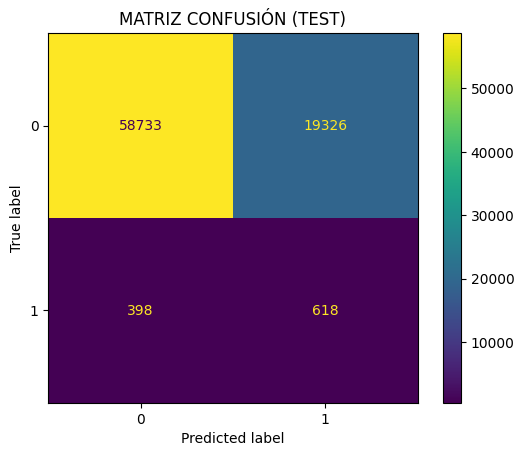

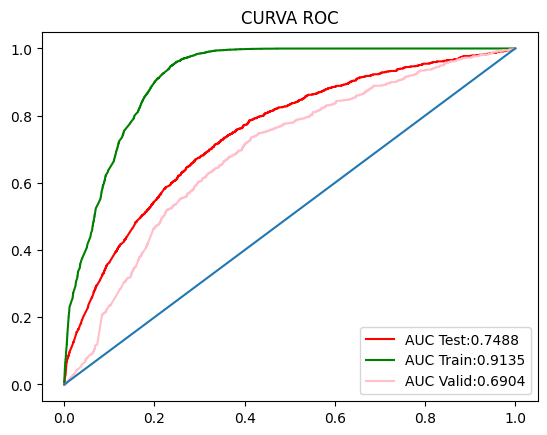

In [ ]:
import xgboost as xgb
modelo_xgb=xgb.XGBClassifier(scale_pos_weight=72)
modelo_aplicado(modelo_xgb, x_train, y_train, x_test, y_test, x_valid, y_valid)

[LightGBM] [Info] Number of positive: 4320, number of negative: 311978
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002415 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1879
[LightGBM] [Info] Number of data points in the train set: 316298, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.013658 -> initscore=-4.279677
[LightGBM] [Info] Start training from score -4.279677
Accuracy Test: 0.7265760354094214
Accuracy Train: 0.7328184180740946
Accuracy Validation: 0.764972972972973
AUC-ROC Test: 0.7600909563359757
AUC-ROC Train: 0.8704084487913796
AUC-ROC Validation: 0.7045433414949503
Sensibilidad Test: 0.6624015748031497
Sensibilidad Train: 0.8773148148148148
Sensibilidad Valid: 0.5198358413132695
Especificidad Test: 0.7274113170806698
Especificidad Train: 0.7308175576482957
Especificidad Valid: 0.7672734742

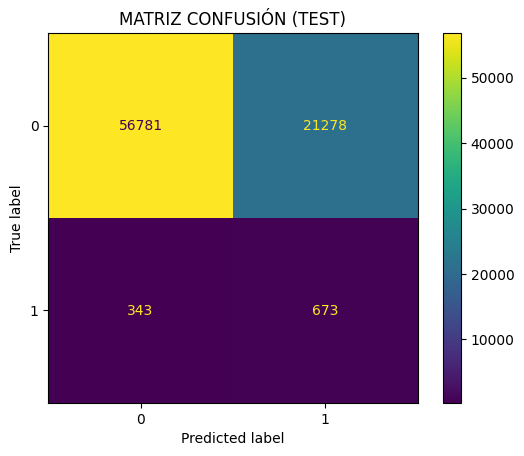

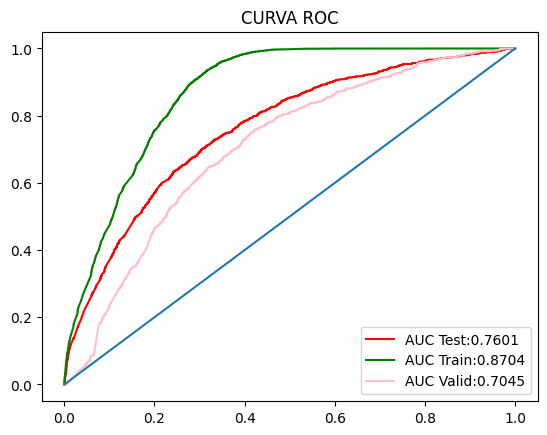

In [ ]:
from lightgbm import LGBMClassifier
modelo_lgb2 = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.03,
    num_leaves=31,
    max_depth=-1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train[y_train==0]) / len(y_train[y_train==1]))
)
modelo_aplicado(modelo_lgb2, x_train, y_train, x_test, y_test, x_valid, y_valid)

Accuracy Test: 0.9870123300663927
Accuracy Train: 0.9864621338105205
Accuracy Validation: 0.9905119236883942
AUC-ROC Test: 0.7630686151692446
AUC-ROC Train: 0.7786981006406435
AUC-ROC Validation: 0.7037768398086466
Sensibilidad Test: 0.0
Sensibilidad Train: 0.010185185185185186
Sensibilidad Valid: 0.0
Especificidad Test: 0.9998590809515879
Especificidad Train: 0.9999807678746578
Especificidad Valid: 0.9998074306108301
F1 Score Test: 0.0
F1 Score Train: 0.020137299771167048
F1 Score Valid: 0.0
Tasa de FN Test: 0.012850349084286148
Tasa de FN Train: 0.013521034125116996
Tasa de FN Valid: 0.009299071364966289
Precision Test: 0.0
Precision Train: 0.88
Precision Valid: 0.0


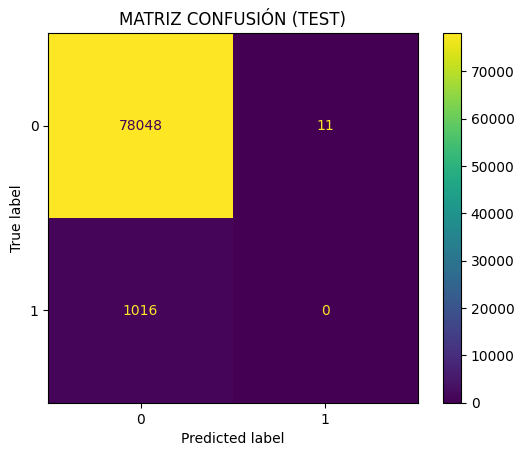

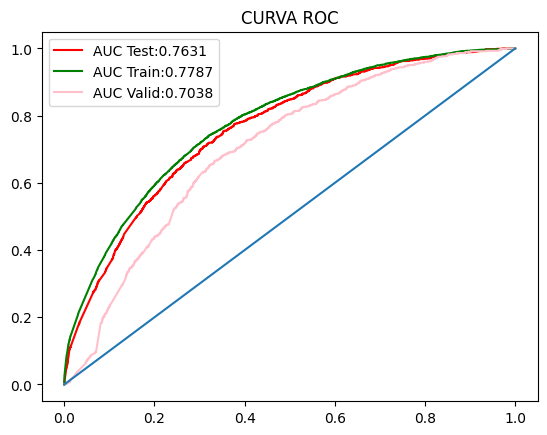

In [ ]:
modelo_gb = GradientBoostingClassifier()
modelo_aplicado(modelo_gb, x_train, y_train, x_test, y_test, x_valid, y_valid)

***Modelado Variables Post PSI (Sin Nov, ni Dic)***
----------------------------------------------------------------------------------------------------------------------------------------------*texto en cursiva*


In [ ]:
variables_boruta

['AMT_PURCH_3M',
 'AMT_PURCH_1M',
 'AMT_PURCH_15A22_1M',
 'AVG_CURRENT_BALANCE_1M',
 'AVG_DIAS_ENTRE_COMPRAS_EVER',
 'APROX_AGE',
 'Q_PURCH_15A22_1M',
 'DIAS_DESDE_ULTIMA_COMPRA',
 'q_int_ever_home_showbal',
 'q_int_ever_myprf_dropact',
 'q_int_last1m_myprf_dropact',
 'DAYS_LAST_RED']

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split
df_final9 = df_final8.copy()
df_final9['FECHA_SNAPSHOT'] = pd.to_datetime(df_final9['FECHA_SNAPSHOT'])
train = pd.to_datetime([
    '2025-10-01',
    '2026-01-01','2026-02-01','2026-03-01','2026-04-01'
])
validation = pd.to_datetime(['2026-05-01'])
variables_predictivas = variables_boruta
data_train = df_final9[df_final9['FECHA_SNAPSHOT'].isin(train)].copy()
data_validation = df_final9[df_final9['FECHA_SNAPSHOT'].isin(validation)].copy()
x = data_train.drop(columns=['FECHA_SNAPSHOT','COD_CLIENTE','FECHA_TARGET','TARGET_CHURN']).copy()
y = data_train['TARGET_CHURN'].copy()

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)
x_valid = data_validation.drop(columns=['FECHA_SNAPSHOT','COD_CLIENTE','FECHA_TARGET','TARGET_CHURN']).copy()
y_valid = data_validation['TARGET_CHURN'].copy()

In [ ]:
x_train.shape, x_test.shape, x_valid.shape, df_final9.shape

((236584, 348), (59147, 348), (78625, 348), (473998, 352))

In [ ]:
y_train.value_counts(normalize=True)

,proportion
TARGET_CHURN,
0,0.991775
1,0.008225


Accuracy Test: 0.9921720459194887
Accuracy Train: 0.9918506746018327
Accuracy Validation: 0.9907662957074722
AUC-ROC Test: 0.7392609755812748
AUC-ROC Train: 0.8149818779687714
AUC-ROC Validation: 0.7403967410620845
Sensibilidad Test: 0.014989293361884369
Sensibilidad Train: 0.013360739979445015
Sensibilidad Valid: 0.01094391244870041
Especificidad Test: 0.9999488752556237
Especificidad Train: 0.9999659049258859
Especificidad Valid: 0.9999614861221661
F1 Score Test: 0.029350104821802937
F1 Score Train: 0.026262626262626262
F1 Score Valid: 0.0215633423180593
Tasa de FN Test: 0.007778548117084059
Tasa de FN Train: 0.008116677235256817
Tasa de FN Valid: 0.009196835169308266
Precision Test: 0.7
Precision Train: 0.7647058823529411
Precision Valid: 0.7272727272727273


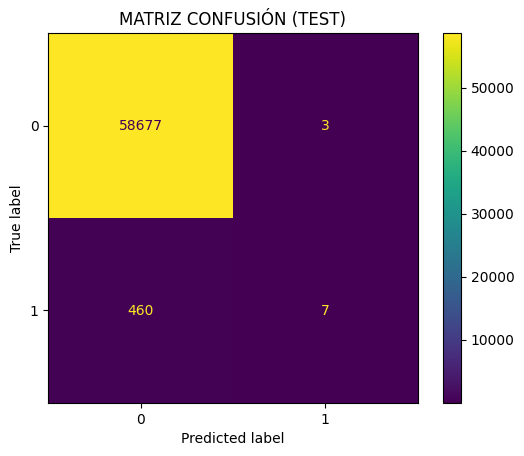

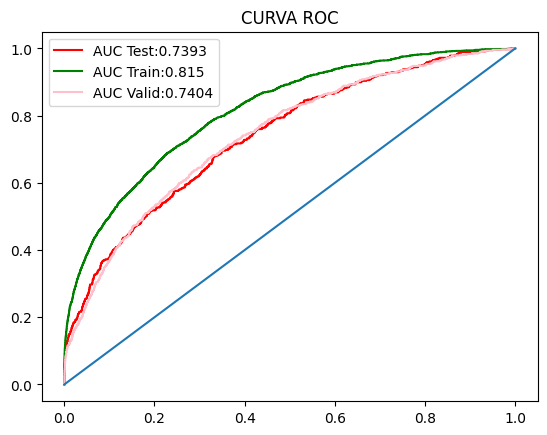

In [ ]:
modelo_hgb3 = HistGradientBoostingClassifier(
    max_depth=3,
    learning_rate=0.05,
    max_iter=200,
    min_samples_leaf=100
)
modelo_aplicado(modelo_hgb3, x_train, y_train, x_test, y_test, x_valid, y_valid)

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split
df_final9 = df_final8.copy()
df_final9['FECHA_SNAPSHOT'] = pd.to_datetime(df_final9['FECHA_SNAPSHOT'])
train = pd.to_datetime([
    '2025-10-01','2025-11-01','2025-12-01',
    '2026-01-01','2026-02-01','2026-03-01','2026-04-01'
])
validation = pd.to_datetime(['2026-05-01'])
variables_predictivas = variables_boruta
data_train = df_final9[df_final9['FECHA_SNAPSHOT'].isin(train)].copy()
data_validation = df_final9[df_final9['FECHA_SNAPSHOT'].isin(validation)].copy()
x = data_train.drop(columns=['FECHA_SNAPSHOT','COD_CLIENTE','FECHA_TARGET','TARGET_CHURN']).copy()
y = data_train['TARGET_CHURN'].copy()

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)
x_valid = data_validation.drop(columns=['FECHA_SNAPSHOT','COD_CLIENTE','FECHA_TARGET','TARGET_CHURN']).copy()
y_valid = data_validation['TARGET_CHURN'].copy()

Accuracy Test: 0.9871387922858046
Accuracy Train: 0.9864178717538524
Accuracy Validation: 0.9907535771065182
AUC-ROC Test: 0.8090919807478556
AUC-ROC Train: 0.8407878668676304
AUC-ROC Validation: 0.73868890610998
Sensibilidad Test: 0.004921259842519685
Sensibilidad Train: 0.006944444444444444
Sensibilidad Valid: 0.013679890560875513
Especificidad Test: 0.9999231350645025
Especificidad Train: 0.9999807678746578
Especificidad Valid: 0.999922972244332
F1 Score Test: 0.009737098344693282
F1 Score Train: 0.013774104683195593
F1 Score Valid: 0.02677376171352075
Tasa de FN Test: 0.012787109177375291
Tasa de FN Train: 0.013564702683218344
Tasa de FN Valid: 0.00917197776336043
Precision Test: 0.45454545454545453
Precision Train: 0.8333333333333334
Precision Valid: 0.625


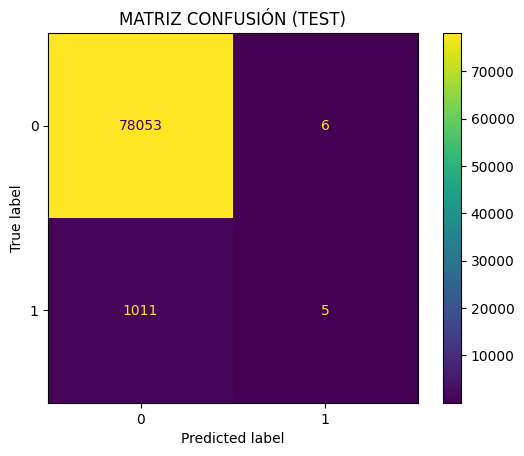

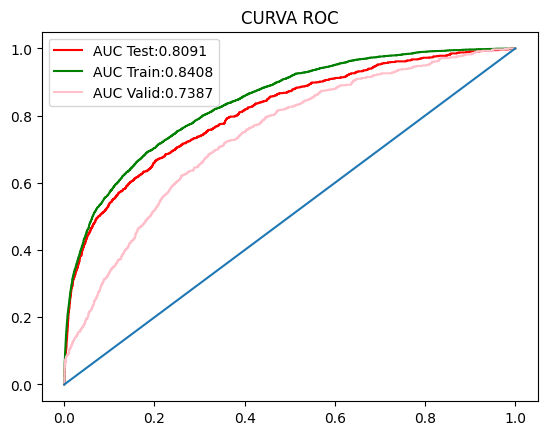

In [ ]:
modelo_hgb3 = HistGradientBoostingClassifier(
    max_depth=3,
    learning_rate=0.05,
    max_iter=200,
    min_samples_leaf=100
)
modelo_aplicado(modelo_hgb3, x_train, y_train, x_test, y_test, x_valid, y_valid)

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 425.6/425.6 kB 9.3 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import optuna

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import roc_auc_score

# =========================================================
# 1) Datos base
# =========================================================
df = df_final9.copy()
df["FECHA_SNAPSHOT"] = pd.to_datetime(df["FECHA_SNAPSHOT"])

FEATURES = variables_predictivas
TARGET = "TARGET_CHURN"
DATE_COL = "FECHA_SNAPSHOT"

# Train histórico hasta abril
months_all = pd.to_datetime([
    "2025-10-01",
    "2025-11-01",
    "2025-12-01",
    "2026-01-01",
    "2026-02-01",
    "2026-03-01",
    "2026-04-01",
])

# Variante excluyendo Nov y Dic
months_no_nd = pd.to_datetime([
    "2025-10-01",
    "2026-01-01",
    "2026-02-01",
    "2026-03-01",
    "2026-04-01",
])

# Holdout final
month_valid_final = pd.to_datetime("2026-05-01")


# =========================================================
# 2) Rolling / expanding validation
# =========================================================
def rolling_auc_score(
    data: pd.DataFrame,
    months: list,
    features: list,
    target: str,
    params: dict,
    min_train_months: int = 3,
):
    """
    Entrena con meses anteriores y valida en el mes siguiente.
    Devuelve:
      - AUC promedio ponderado por tamaño del fold
      - DataFrame con métricas por fold
    """
    months = sorted(pd.to_datetime(months))
    rows = []

    for i in range(min_train_months, len(months)):
        train_months = months[:i]
        test_month = months[i]

        train_df = data.loc[data[DATE_COL].isin(train_months), features + [target]].dropna().copy()
        test_df = data.loc[data[DATE_COL] == test_month, features + [target]].dropna().copy()

        if train_df.empty or test_df.empty:
            continue

        # Si en test hay una sola clase, AUC no se puede calcular
        if test_df[target].nunique() < 2:
            continue

        X_train = train_df[features]
        y_train = train_df[target].astype(int)

        X_test = test_df[features]
        y_test = test_df[target].astype(int)

        model = HistGradientBoostingClassifier(**params)
        model.fit(X_train, y_train)

        p_train = model.predict_proba(X_train)[:, 1]
        p_test = model.predict_proba(X_test)[:, 1]

        auc_train = roc_auc_score(y_train, p_train)
        auc_test = roc_auc_score(y_test, p_test)

        rows.append({
            "test_month": pd.to_datetime(test_month).strftime("%Y-%m-%d"),
            "n_train": len(train_df),
            "n_test": len(test_df),
            "pos_rate_train": y_train.mean(),
            "pos_rate_test": y_test.mean(),
            "auc_train": auc_train,
            "auc_test": auc_test,
            "gap_train_test": auc_train - auc_test,
        })

    results = pd.DataFrame(rows)

    if results.empty:
        return np.nan, results

    weighted_auc = np.average(results["auc_test"], weights=results["n_test"])
    return weighted_auc, results


# =========================================================
# 3) Optuna objective
# =========================================================
def make_objective(data: pd.DataFrame, months: list, features: list, target: str):
    def objective(trial):
        params = {
            "loss": "log_loss",
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.10, log=True),
            "max_iter": trial.suggest_int("max_iter", 80, 500),
            "max_depth": trial.suggest_int("max_depth", 2, 6),
            "min_samples_leaf": trial.suggest_int("min_samples_leaf", 20, 500, log=True),
            "l2_regularization": trial.suggest_float("l2_regularization", 1e-8, 10.0, log=True),
            "max_bins": trial.suggest_int("max_bins", 64, 255),
            "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 63),
            "early_stopping": False,
            "random_state": 123,
        }

        mean_auc, fold_df = rolling_auc_score(
            data=data,
            months=months,
            features=features,
            target=target,
            params=params,
            min_train_months=3,
        )

        # Si por alguna razón no se pudo evaluar, castigo fuerte
        if np.isnan(mean_auc):
            return 0.0

        # Opcional: favorecer estabilidad además de nivel de AUC
        # score = mean_auc - 0.01 * fold_df["gap_train_test"].mean()
        # return score

        return mean_auc

    return objective


# =========================================================
# 4) Ejecutar dos estudios: con y sin Nov-Dic
# =========================================================
sampler = optuna.samplers.TPESampler(seed=123)

study_all = optuna.create_study(direction="maximize", sampler=sampler)
study_all.optimize(
    make_objective(df, months_all, FEATURES, TARGET),
    n_trials=100,
    show_progress_bar=True,
)

study_no_nd = optuna.create_study(direction="maximize", sampler=sampler)
study_no_nd.optimize(
    make_objective(df, months_no_nd, FEATURES, TARGET),
    n_trials=100,
    show_progress_bar=True,
)

print("=== ESTUDIO CON TODOS LOS MESES ===")
print("Best rolling AUC:", study_all.best_value)
print("Best params:", study_all.best_params)

print("\n=== ESTUDIO SIN NOV Y DIC ===")
print("Best rolling AUC:", study_no_nd.best_value)
print("Best params:", study_no_nd.best_params)


# =========================================================
# 5) Entrenamiento final y evaluación en mayo
# =========================================================
def fit_final_and_eval(data, train_months, valid_month, features, target, best_params):
    train_df = data.loc[data[DATE_COL].isin(train_months), features + [target]].dropna().copy()
    valid_df = data.loc[data[DATE_COL] == valid_month, features + [target]].dropna().copy()

    X_train = train_df[features]
    y_train = train_df[target].astype(int)

    X_valid = valid_df[features]
    y_valid = valid_df[target].astype(int)

    final_params = {
        "loss": "log_loss",
        "early_stopping": False,
        "random_state": 123,
        **best_params,
    }

    model = HistGradientBoostingClassifier(**final_params)
    model.fit(X_train, y_train)

    p_train = model.predict_proba(X_train)[:, 1]
    p_valid = model.predict_proba(X_valid)[:, 1]

    auc_train = roc_auc_score(y_train, p_train)
    auc_valid = roc_auc_score(y_valid, p_valid)

    return model, auc_train, auc_valid


# Modelo final usando todos los meses
model_all, auc_train_all, auc_valid_all = fit_final_and_eval(
    df,
    months_all,
    month_valid_final,
    FEATURES,
    TARGET,
    study_all.best_params,
)

print("\n=== FINAL CON TODOS LOS MESES ===")
print("AUC Train:", auc_train_all)
print("AUC Valid:", auc_valid_all)

# Modelo final sin Nov y Dic
model_no_nd, auc_train_no_nd, auc_valid_no_nd = fit_final_and_eval(
    df,
    months_no_nd,
    month_valid_final,
    FEATURES,
    TARGET,
    study_no_nd.best_params,
)

print("\n=== FINAL SIN NOV Y DIC ===")
print("AUC Train:", auc_train_no_nd)
print("AUC Valid:", auc_valid_no_nd)

[I 2026-06-09 17:14:31,285] A new study created in memory with name: no-name-85a6a9c9-8c16-45d6-b1da-280ea712038f


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-09 17:14:39,520] Trial 0 finished with value: 0.6851050710146671 and parameters: {'learning_rate': 0.049712909978071915, 'max_iter': 200, 'max_depth': 3, 'min_samples_leaf': 117, 'l2_regularization': 0.0298690031084307, 'max_bins': 145, 'max_leaf_nodes': 63}. Best is trial 0 with value: 0.6851050710146671.
[I 2026-06-09 17:14:49,280] Trial 1 finished with value: 0.6856194259817996 and parameters: {'learning_rate': 0.04839825891759375, 'max_iter': 282, 'max_depth': 3, 'min_samples_leaf': 59, 'l2_regularization': 0.03642900979056708, 'max_bins': 148, 'max_leaf_nodes': 17}. Best is trial 1 with value: 0.6856194259817996.
[I 2026-06-09 17:15:01,144] Trial 2 finished with value: 0.67684328788817 and parameters: {'learning_rate': 0.025006001640318763, 'max_iter': 390, 'max_depth': 2, 'min_samples_leaf': 34, 'l2_regularization': 0.0006080823033339466, 'max_bins': 166, 'max_leaf_nodes': 46}. Best is trial 1 with value: 0.6856194259817996.
[I 2026-06-09 17:15:16,082] Trial 3 finished

[I 2026-06-09 17:35:48,480] A new study created in memory with name: no-name-92c3d54f-14fb-4646-9700-72234cd9c547


[I 2026-06-09 17:35:48,477] Trial 99 finished with value: 0.6852995436460133 and parameters: {'learning_rate': 0.029419688548344685, 'max_iter': 335, 'max_depth': 6, 'min_samples_leaf': 226, 'l2_regularization': 5.548462820713368e-06, 'max_bins': 75, 'max_leaf_nodes': 43}. Best is trial 83 with value: 0.6890436228997995.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-09 17:35:56,559] Trial 0 finished with value: 0.7068857423658339 and parameters: {'learning_rate': 0.012465580757668638, 'max_iter': 452, 'max_depth': 5, 'min_samples_leaf': 204, 'l2_regularization': 1.3968920968210637e-08, 'max_bins': 178, 'max_leaf_nodes': 42}. Best is trial 0 with value: 0.7068857423658339.
[I 2026-06-09 17:35:59,581] Trial 1 finished with value: 0.7013615805964635 and parameters: {'learning_rate': 0.014419813523676687, 'max_iter': 144, 'max_depth': 5, 'min_samples_leaf': 55, 'l2_regularization': 0.016894006610635955, 'max_bins': 170, 'max_leaf_nodes': 34}. Best is trial 0 with value: 0.7068857423658339.
[I 2026-06-09 17:36:04,952] Trial 2 finished with value: 0.7040503151112639 and parameters: {'learning_rate': 0.08416518640486187, 'max_iter': 434, 'max_depth': 3, 'min_samples_leaf': 22, 'l2_regularization': 5.5323883828333925e-06, 'max_bins': 140, 'max_leaf_nodes': 49}. Best is trial 0 with value: 0.7068857423658339.
[I 2026-06-09 17:36:09,034] Trial 3 

In [ ]:
study_all.best_params

{'learning_rate': 0.02179134856709615,
 'max_iter': 286,
 'max_depth': 5,
 'min_samples_leaf': 240,
 'l2_regularization': 2.7394577650109246e-05,
 'max_bins': 108,
 'max_leaf_nodes': 43}

In [ ]:
study_no_nd.best_params

{'learning_rate': 0.02391004504532633,
 'max_iter': 463,
 'max_depth': 3,
 'min_samples_leaf': 358,
 'l2_regularization': 1.833838163341522,
 'max_bins': 129,
 'max_leaf_nodes': 50}

# ***Modelo Variables Post PSI (Sin Nov, ni Dic) - Hiperparámetros Optimizados***
----------------------------------------------------------------------------------------------------------------------------------------------
---

*Aquí se encuentra el mejor modelo*

## *Modelo seleccionado 1*

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split
df_final9 = df_final8.copy()
df_final9['FECHA_SNAPSHOT'] = pd.to_datetime(df_final9['FECHA_SNAPSHOT'])
train = pd.to_datetime([
    '2025-10-01',
    '2026-01-01','2026-02-01','2026-03-01','2026-04-01'
])
validation = pd.to_datetime(['2026-05-01'])
variables_predictivas = variables_boruta
data_train = df_final9[df_final9['FECHA_SNAPSHOT'].isin(train)].copy()
data_validation = df_final9[df_final9['FECHA_SNAPSHOT'].isin(validation)].copy()
x = data_train.drop(columns=['FECHA_SNAPSHOT','COD_CLIENTE','FECHA_TARGET','TARGET_CHURN']).copy()
y = data_train['TARGET_CHURN'].copy()

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)
x_valid = data_validation.drop(columns=['FECHA_SNAPSHOT','COD_CLIENTE','FECHA_TARGET','TARGET_CHURN']).copy()
y_valid = data_validation['TARGET_CHURN'].copy()

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

def objective(trial):
    params = {
        "loss": "log_loss",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15),
        "max_iter": trial.suggest_int("max_iter", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 20, 300),
        "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 5.0),
        "max_bins": trial.suggest_int("max_bins", 64, 255),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 63),
        "random_state": 42,
        "early_stopping": True,
        "validation_fraction": 0.1,
        "n_iter_no_change": 30,
    }

    model = HistGradientBoostingClassifier(**params)

    model.fit(
        x_train,
        y_train,
        sample_weight=sample_weights
    )

    preds_test = model.predict_proba(x_test)[:, 1]
    auc_test = roc_auc_score(y_test, preds_test)

    return auc_test

In [ ]:
study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(objective, n_trials=100, show_progress_bar=True)

[I 2026-06-09 18:04:32,484] A new study created in memory with name: no-name-65ebc837-f3ff-4e8e-89ea-ffb4b35a9071


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-06-09 18:04:45,137] Trial 0 finished with value: 0.7420955343028425 and parameters: {'learning_rate': 0.062435616638630745, 'max_iter': 576, 'max_depth': 7, 'min_samples_leaf': 188, 'l2_regularization': 0.7800932022121826, 'max_bins': 93, 'max_leaf_nodes': 17}. Best is trial 0 with value: 0.7420955343028425.
[I 2026-06-09 18:04:53,633] Trial 1 finished with value: 0.7323805556650304 and parameters: {'learning_rate': 0.1312646604084909, 'max_iter': 401, 'max_depth': 6, 'min_samples_leaf': 25, 'l2_regularization': 4.8495492608099715, 'max_bins': 223, 'max_leaf_nodes': 25}. Best is trial 0 with value: 0.7420955343028425.
[I 2026-06-09 18:05:08,409] Trial 2 finished with value: 0.7492603333289544 and parameters: {'learning_rate': 0.035455495408994085, 'max_iter': 191, 'max_depth': 4, 'min_samples_leaf': 167, 'l2_regularization': 2.1597250932105787, 'max_bins': 119, 'max_leaf_nodes': 44}. Best is trial 2 with value: 0.7492603333289544.
[I 2026-06-09 18:05:23,382] Trial 3 finished wi

In [ ]:
best_params_hgb1 = study.best_params
best_params_hgb1

{'learning_rate': 0.1383808904826321,
 'max_iter': 531,
 'max_depth': 2,
 'min_samples_leaf': 224,
 'l2_regularization': 1.3035953161815257,
 'max_bins': 117,
 'max_leaf_nodes': 49}

AUC-ROC Test: 0.7470319367264691
AUC-ROC Train: 0.7867623588314351
AUC-ROC Validation: 0.746338099441814
Sensibilidad Test: 0.6209850107066381
Sensibilidad Train: 0.6855087358684481
Sensibilidad Valid: 0.6347469220246238
Especificidad Test: 0.719972733469666
Especificidad Train: 0.7165250300462841
Especificidad Valid: 0.7341130253934834
F1 Score Test: 0.033742509744604104
F1 Score Train: 0.03822678167177694
F1 Score Valid: 0.04236282297087556
Tasa de FN Test: 0.0041720683559222154
Tasa de FN Train: 0.003626967570642898
Tasa de FN Valid: 0.004647519582245431
Precision Test: 0.017342423155124985
Precision Train: 0.019661596509845537
Precision Valid: 0.021912632821723732


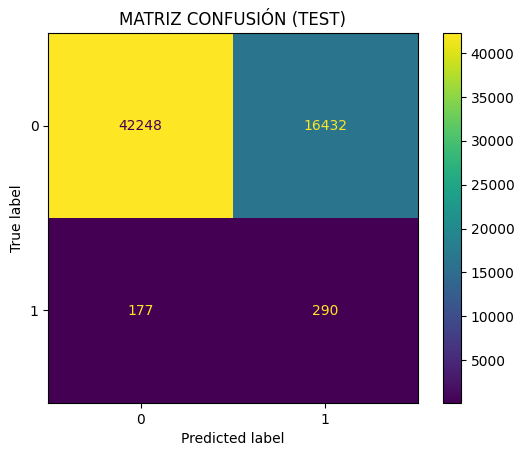

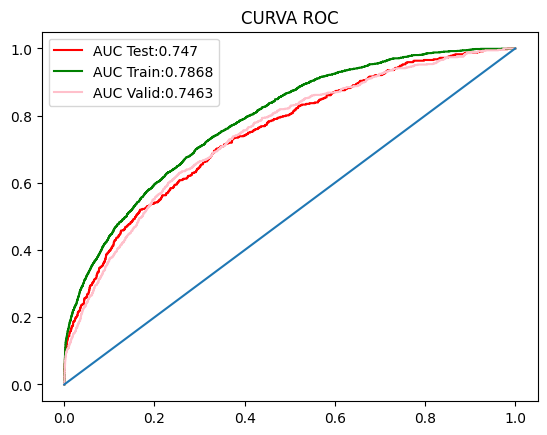

In [ ]:
modelo_hgb_optuna1 = HistGradientBoostingClassifier(**best_params_hgb1)
modelo_hgb_optuna1.fit(x_train,y_train,sample_weight=sample_weights)
predicciones_test = modelo_hgb_optuna1.predict(x_test)
predicciones_train = modelo_hgb_optuna1.predict(x_train)
predicciones_valid = modelo_hgb_optuna1.predict(x_valid)
predicciones_prob_test = modelo_hgb_optuna1.predict_proba(x_test)
predicciones_prob_train = modelo_hgb_optuna1.predict_proba(x_train)
predicciones_prob_valid = modelo_hgb_optuna1.predict_proba(x_valid)
tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, predicciones_test).ravel()
tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, predicciones_train).ravel()
tn_valid, fp_valid, fn_valid, tp_valid = confusion_matrix(y_valid, predicciones_valid).ravel()



#Mostrando las métricas
print('AUC-ROC Test:',roc_auc_score(y_test,predicciones_prob_test[:,1] ))
print('AUC-ROC Train:',roc_auc_score(y_train,predicciones_prob_train[:,1]))
print('AUC-ROC Validation:',roc_auc_score(y_valid,predicciones_prob_valid[:,1]))
print('Sensibilidad Test:',recall_score(y_test, predicciones_test, pos_label = 1))
print('Sensibilidad Train:',recall_score(y_train, predicciones_train, pos_label = 1))
print('Sensibilidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 1))
print('Especificidad Test:',recall_score(y_test, predicciones_test, pos_label = 0))
print('Especificidad Train:',recall_score(y_train, predicciones_train, pos_label = 0))
print('Especificidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 0))
print('F1 Score Test:',f1_score(y_test, predicciones_test))
print('F1 Score Train:',f1_score(y_train, predicciones_train))
print('F1 Score Valid:',f1_score(y_valid, predicciones_valid))
print('Tasa de FN Test:', fn_test / (tn_test + fn_test))
print('Tasa de FN Train:', fn_train / (tn_train + fn_train))
print('Tasa de FN Valid:', fn_valid / (tn_valid + fn_valid))
print('Precision Test:', precision_score(y_test, predicciones_test))
print('Precision Train:', precision_score(y_train, predicciones_train))
print('Precision Valid:', precision_score(y_valid, predicciones_valid))

#Matriz de Confusión
cm = confusion_matrix(y_test, predicciones_test)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('MATRIZ CONFUSIÓN (TEST)')
plt.show()


##Curva AUC ROC
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, predicciones_prob_test[:,1])
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, predicciones_prob_train[:,1])
fpr_valid, tpr_valid, thresholds_valid = roc_curve(y_valid, predicciones_prob_valid[:,1])
plt.plot(fpr_test, tpr_test, color = 'red', label = f'AUC Test:{round(roc_auc_score(y_test,predicciones_prob_test[:,1] ),4)}')
plt.plot(fpr_train, tpr_train, color = 'green', label = f'AUC Train:{round(roc_auc_score(y_train,predicciones_prob_train[:,1] ),4)}')
plt.plot(fpr_valid, tpr_valid, color = 'pink', label = f'AUC Valid:{round(roc_auc_score(y_valid,predicciones_prob_valid[:,1] ),4)}')
plt.plot([0, 1], [0, 1])
plt.legend()
plt.title('CURVA ROC')
plt.show()

In [ ]:
### Guardando modelo seleccionado
import joblib
joblib.dump(modelo_hgb_optuna1, "modelo_Churn_reentrenado_V1.pkl")

['modelo_Churn_reentrenado_V1.pkl']

In [ ]:
x_train.to_csv('data_train.csv', index=False)

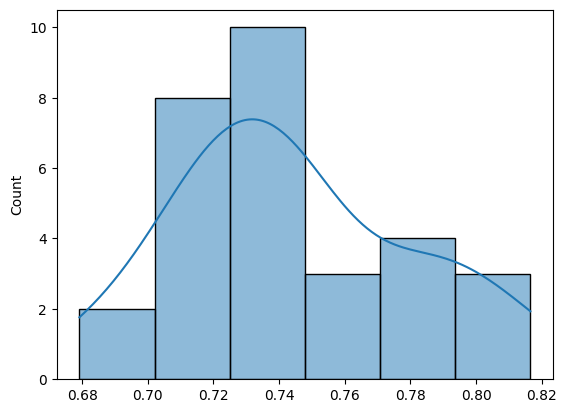

In [ ]:
from sklearn.model_selection import RepeatedKFold, cross_val_score,RepeatedStratifiedKFold
#Validacion Cruzada
cv = RepeatedStratifiedKFold(n_splits=15, n_repeats=2, random_state=123)
scores = cross_val_score(modelo_hgb_optuna1, x_valid,y_valid,cv = cv, scoring='roc_auc').round(4)
ax = sns.histplot(x=scores, kde = True)

In [ ]:
print(scores.mean())
print(scores.std())
print(scores.min())
print(scores.max())

0.7445033333333331
0.03546045199310854
0.6792
0.8165


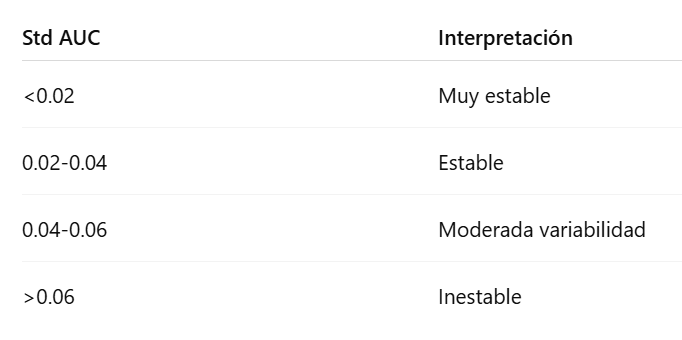

***Feature Importance***
----------------------------------------------------------------------------------------------------

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd

result = permutation_importance(
    modelo_hgb_optuna1,
    x_train,
    y_train,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

importances = pd.DataFrame({
    "feature": x_train.columns,
    "importance": result.importances_mean * 100
})

importances = importances.sort_values(
    by="importance",
    ascending=False
)

importances

,feature,importance
152,DIAS_DESDE_ULTIMA_COMPRA,3.562745
284,DAYS_FIRST_RED,1.232629
283,DAYS_LAST_RED,0.951042
87,AVG_DIAS_ENTRE_COMPRAS_EVER,0.877199
91,APROX_AGE,0.868830
...,...,...
83,SUM_PAYMENT_AMT_EVER,-0.003782
135,Q_PAGSERV_3M,-0.003834
49,AMT_PAGSERV_3M,-0.011236
55,AMT_PURCH_15A22_3M,-0.016495


In [ ]:
importances.to_excel('Feature_Importance.xlsx', index=False)

***Análisis Shap***
----------------------------------------------------------------------------------------------------

In [ ]:
## SHAP VALUES
! pip install shap
import shap

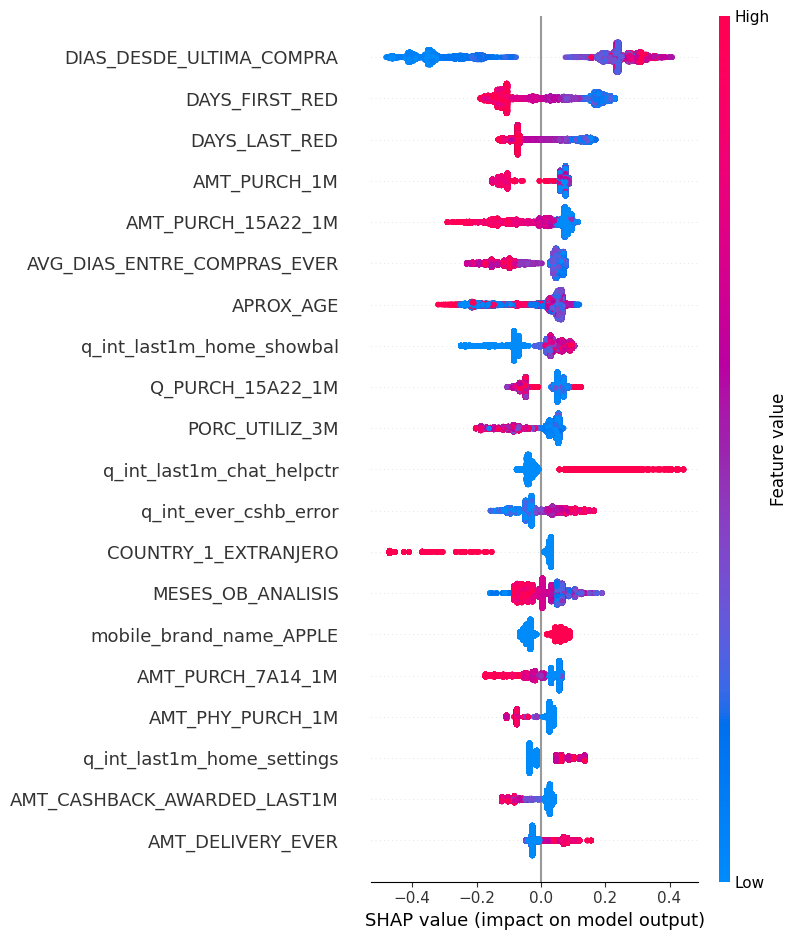

In [ ]:
x_sample = x_train.sample(50500, random_state=42)
explainer = shap.Explainer(modelo_hgb_optuna1)
shap_values = explainer.shap_values(x_sample)
shap.initjs()
shap.summary_plot(shap_values, x_sample)

***Análisis Treshold Óptimo***
----------------------------------------------------------------------------------------------------

In [ ]:
### Eligiendo el treshold
probabilidad_testeo = modelo_hgb_optuna1.predict_proba(x_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test,probabilidad_testeo)
youden_j = tpr - fpr
idx = np.argmax(youden_j)
best_threshold = thresholds[idx]
print(best_threshold)

0.4788498384741453


In [ ]:
def predict_with_threshold(model, X, threshold):
    probs = model.predict_proba(X)[:,1]
    return (probs >= threshold).astype(int)

Accuracy Test: 0.6620623193061356
Accuracy Train: 0.6591147330335103
Accuracy Validation: 0.6818314785373609
Sensibilidad Test: 0.702355460385439
Sensibilidad Train: 0.7461459403905447
Sensibilidad Valid: 0.6730506155950753
Especificidad Test: 0.6617416496250852
Especificidad Train: 0.6583929286816287
Especificidad Valid: 0.6819138829691632
F1 Score Test: 0.03177678744429374
F1 Score Train: 0.0347567981616239
F1 Score Valid: 0.03784615384615385
Tasa de FN Test: 0.003566846292019502
Tasa de FN Train: 0.0031875492005316885
Tasa de FN Valid: 0.004479346277831921
Precision Test: 0.0162561332209942
Precision Train: 0.01779280935225351
Precision Valid: 0.019470497447465273


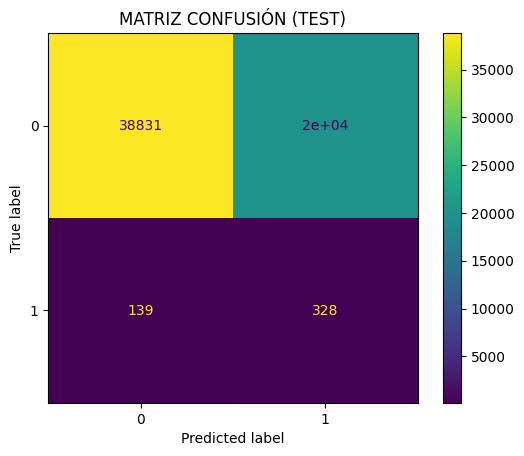

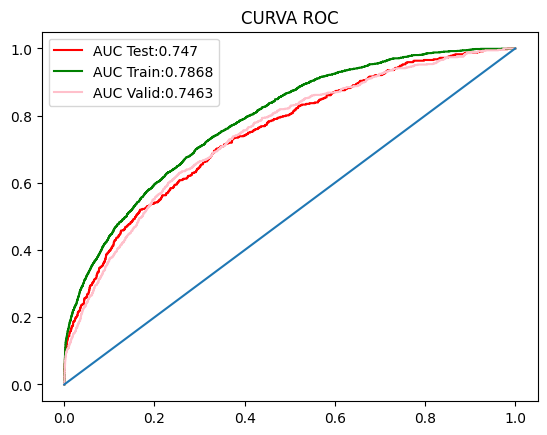

In [ ]:
predicciones_test = predict_with_threshold(modelo_hgb_optuna1, x_test, 0.4788498384741453) ### Test:0.4788498384741453
predicciones_train = predict_with_threshold(modelo_hgb_optuna1, x_train, 0.4788498384741453)
predicciones_valid = predict_with_threshold(modelo_hgb_optuna1, x_valid, 0.4788498384741453)
predicciones_prob_test = modelo_hgb_optuna1.predict_proba(x_test)
predicciones_prob_train = modelo_hgb_optuna1.predict_proba(x_train)
predicciones_prob_valid = modelo_hgb_optuna1.predict_proba(x_valid)
tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, predicciones_test).ravel()
tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, predicciones_train).ravel()
tn_valid, fp_valid, fn_valid, tp_valid = confusion_matrix(y_valid, predicciones_valid).ravel()


  #Mostrando las métricas
print('Accuracy Test:',accuracy_score(y_test, predicciones_test))
print('Accuracy Train:',accuracy_score(y_train, predicciones_train))
print('Accuracy Validation:',accuracy_score(y_valid, predicciones_valid))
print('Sensibilidad Test:',recall_score(y_test, predicciones_test, pos_label = 1))
print('Sensibilidad Train:',recall_score(y_train, predicciones_train, pos_label = 1))
print('Sensibilidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 1))
print('Especificidad Test:',recall_score(y_test, predicciones_test, pos_label = 0))
print('Especificidad Train:',recall_score(y_train, predicciones_train, pos_label = 0))
print('Especificidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 0))
print('F1 Score Test:',f1_score(y_test, predicciones_test))
print('F1 Score Train:',f1_score(y_train, predicciones_train))
print('F1 Score Valid:',f1_score(y_valid, predicciones_valid))
print('Tasa de FN Test:', fn_test / (tn_test + fn_test))
print('Tasa de FN Train:', fn_train / (tn_train + fn_train))
print('Tasa de FN Valid:', fn_valid / (tn_valid + fn_valid))
print('Precision Test:', precision_score(y_test, predicciones_test))
print('Precision Train:', precision_score(y_train, predicciones_train))
print('Precision Valid:', precision_score(y_valid, predicciones_valid))

#Matriz de Confusión
cm = confusion_matrix(y_test, predicciones_test)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('MATRIZ CONFUSIÓN (TEST)')
plt.show()


##Curva AUC ROC
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, predicciones_prob_test[:,1])
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, predicciones_prob_train[:,1])
fpr_valid, tpr_valid, thresholds_valid = roc_curve(y_valid, predicciones_prob_valid[:,1])
plt.plot(fpr_test, tpr_test, color = 'red', label = f'AUC Test:{round(roc_auc_score(y_test,predicciones_prob_test[:,1] ),4)}')
plt.plot(fpr_train, tpr_train, color = 'green', label = f'AUC Train:{round(roc_auc_score(y_train,predicciones_prob_train[:,1] ),4)}')
plt.plot(fpr_valid, tpr_valid, color = 'pink', label = f'AUC Valid:{round(roc_auc_score(y_valid,predicciones_prob_valid[:,1] ),4)}')
plt.plot([0, 1], [0, 1])
plt.legend()
plt.title('CURVA ROC')
plt.show()

## ***Análisis Lift***

In [ ]:
def lift_table(y_true, y_score, n_bins=10):

    df = pd.DataFrame({
        "target": y_true,
        "score": y_score
    })

    # Ordenar de mayor score a menor score
    df = df.sort_values("score", ascending=False).reset_index(drop=True)

    # Deciles
    df["decil"] = pd.qcut(
        df.index,
        q=n_bins,
        labels=range(1, n_bins+1)
    )

    overall_rate = df["target"].mean()

    lift_df = (
        df.groupby("decil")
        .agg(
            clientes=("target","count"),
            positivos=("target","sum"),
            tasa_churn=("target","mean"),
            score_min=("score","min"),
            score_max=("score","max")
        )
        .reset_index()
    )

    lift_df["lift"] = lift_df["tasa_churn"] / overall_rate

    return lift_df


# ====================================================
# TEST
# ====================================================
probs_test = modelo_hgb_optuna1.predict_proba(x_test)[:,1]

lift_test = lift_table(
    y_true=y_test,
    y_score=probs_test,
    n_bins=10
)

lift_test

/tmp/ipykernel_7130/1660980375.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("decil")


,decil,clientes,positivos,tasa_churn,score_min,score_max,lift
0,1,5915,184,0.031107,0.591135,0.983548,3.939843
1,2,5915,67,0.011327,0.533103,0.591131,1.434617
2,3,5914,49,0.008285,0.494049,0.533090,1.049375
3,4,5915,45,0.007608,0.456302,0.494044,0.963549
4,5,5915,29,0.004903,0.411517,0.456290,0.620954
5,6,5914,32,0.005411,0.363299,0.411515,0.685306
6,7,5915,24,0.004057,0.318564,0.363298,0.513893
7,8,5914,21,0.003551,0.267764,0.318562,0.449732
8,9,5915,10,0.001691,0.204948,0.267760,0.214122
9,10,5915,6,0.001014,0.028238,0.204940,0.128473


## Análisis Kolgomorov Smirnov

In [ ]:
def ks_table(y_true, y_score, n_bins=10):

    df = pd.DataFrame({
        'target': y_true,
        'score': y_score
    })

    # Ordenar de mayor riesgo a menor riesgo
    df = df.sort_values('score', ascending=False).reset_index(drop=True)

    # Crear deciles
    df['decil'] = pd.qcut(
        df.index,
        q=n_bins,
        labels=range(1, n_bins + 1)
    )

    ks_df = (
        df.groupby('decil')
        .agg(
            total=('target', 'count'),
            bad=('target', 'sum'),
            score_min=('score', 'min'),
            score_max=('score', 'max')
        )
        .reset_index()
    )

    ks_df['good'] = ks_df['total'] - ks_df['bad']

    total_bad = ks_df['bad'].sum()
    total_good = ks_df['good'].sum()

    ks_df['bad_dist'] = ks_df['bad'] / total_bad
    ks_df['good_dist'] = ks_df['good'] / total_good

    ks_df['cum_bad'] = ks_df['bad_dist'].cumsum()
    ks_df['cum_good'] = ks_df['good_dist'].cumsum()

    ks_df['ks'] = np.abs(
        ks_df['cum_bad'] - ks_df['cum_good']
    )

    ks_max = ks_df['ks'].max()

    return ks_df, ks_max

probs_test = modelo_hgb_optuna1.predict_proba(x_test)[:,1]

ks_test_df, ks_test = ks_table(
    y_true=y_test,
    y_score=probs_test,
    n_bins=10
)

print("KS Test:", round(ks_test,4))

ks_test_df

KS Test: 0.3451


/tmp/ipykernel_7130/2094271449.py:19: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('decil')


,decil,total,bad,score_min,score_max,good,bad_dist,good_dist,cum_bad,cum_good,ks
0,1,5915,184,0.591135,0.983548,5731,0.394004,0.097665,0.394004,0.097665,0.296339
1,2,5915,67,0.533103,0.591131,5848,0.143469,0.099659,0.537473,0.197324,0.340149
2,3,5914,49,0.494049,0.533090,5865,0.104925,0.099949,0.642398,0.297273,0.345125
3,4,5915,45,0.456302,0.494044,5870,0.09636,0.100034,0.738758,0.397307,0.341451
4,5,5915,29,0.411517,0.456290,5886,0.062099,0.100307,0.800857,0.497614,0.303242
5,6,5914,32,0.363299,0.411515,5882,0.068522,0.100239,0.869379,0.597853,0.271526
6,7,5915,24,0.318564,0.363298,5891,0.051392,0.100392,0.920771,0.698245,0.222526
7,8,5914,21,0.267764,0.318562,5893,0.044968,0.100426,0.965739,0.798671,0.167068
8,9,5915,10,0.204948,0.267760,5905,0.021413,0.100631,0.987152,0.899301,0.087851
9,10,5915,6,0.028238,0.204940,5909,0.012848,0.100699,1.0,1.0,0.0


***Optuna 1(variables importantes HGB)***
----------------------------------------------------------------------------------------------------------------------------------------------

In [ ]:
variables_importantes = [
    "DIAS_DESDE_ULTIMA_COMPRA",
    "DAYS_FIRST_RED",
    "DAYS_LAST_RED",
    "AVG_DIAS_ENTRE_COMPRAS_EVER",
    "APROX_AGE",
    "q_int_last1m_chat_helpctr",
    "q_int_ever_cshb_error",
    "COUNTRY_1_EXTRANJERO",
    "q_int_last1m_home_showbal",
    "PORC_UTILIZ_3M",
    "q_int_ever_myprf_dropact",
    "MESES_OB_ANALISIS",
    "q_int_last1m_myprf_dropact",
    "q_int_last1m_home_settings",
    "AMT_DELIVERY_EVER",
    "Q_TC_STATUS_EVER",
    "mobile_brand_name_APPLE",
    "AMT_PURCH_15A22_1M",
    "Q_PAGSERV_EVER",
    "AMT_FARMA_1M",
    "q_int_last1m_home_amtmov",
    "PROFESION_cat_ADMINISTRADOR",
    "AVG_STATEMENT_BALANCE_3M",
    "AVG_DIAS_ENTRE_COMPRAS_LAST3M",
    "Q_MAILING_CUSTIO_EMAIL_OPEN",
    "q_int_ever_home_settings",
    "AVG_CURRENT_BALANCE_1M",
    "MAX_DPD_1M",
    "mobile_brand_name_XIAOMI",
    "Q_MAILING_CUSTIO_EMAIL_DEL",
    "USERDEVICE_PLATFORM_SO_IOS",
    "PORC_UTILIZ_EVER",
    "q_int_ever_notfcrdlim_total",
    "q_int_ever_cshb_success",
    "AMT_ROPA_EVER",
    "AMT_PAYMENT_3M",
    "AMT_CASHBACK_AWARDED_LAST1M",
    "Q_MAILING_CUSTIO_EMAIL_SENT",
    "DAYS_OB_LASTREF",
    "q_int_last1m_home_crdetails",
    "MESES_CON_CONSUMO_10",
    "q_int_ever_pay_yapeok",
    "DAYS_LASTREF_TODATE",
    "PROFESION_cat_RESTO",
    "PORC_UTILIZ_1M",
    "AMT_WE_PURCH_EVER",
    "AMT_PURCH_1M",
    "q_int_ever_sdta_error",
    "DIAS_OB_1RACOMPRA",
    "q_int_last1m_myprf_avatar",
    "DAYS_1STOP_CONV",
    "AMT_PURCH_7A14_1M",
    "DOMAIN_EMAIL_cat_hotmail",
    "AMT_WE_PURCH_3M",
    "MAX_CREDIT_LINE_1M",
    "q_int_ever_pay_home",
    "Q_PURCH_15A22_1M",
    "q_int_ever_bnf_seemore",
    "Q_DELIVERY_EVER",
    "TIEMPO_TOTAL_ONBOARGING_MINUTOS",
    "AMT_DELIVERY_3M",
    "q_int_ever_home_amtmov",
    "AMT_BENEFITS_3M",
    "q_int_last1m_ref_sharecode",
    "q_int_ever_chat_helpctr",
    "MAX_APR_VALUE_EVER",
    "q_int_last1m_home_hidebal",
    "Q_DELIVERY_3M",
    "AVG_STATEMENT_BALANCE_1M",
    "q_int_last1m_myprf_ref",
    "MAX_DPD_EVER",
    "q_int_last1m_ref_bau",
    "Q_REJ_INSFD_EVER",
    "Q_STREAMING_3M",
    "q_int_ever_myprf_avatar",
    "q_int_ever_login_recpasscheck",
    "AMT_PHY_PURCH_1M",
    "AMT_PURCH_7A14_EVER",
    "q_int_ever_sdta_ccd",
    "Q_TECNO_EVER",
    "AMT_PURCH_3M",
    "q_int_last1m_notfcrdlim_75",
    "Q_PHY_PURCH_1M",
    "USERDEVICE_PLATFORM_SO_ANDROID",
    "q_int_ever_home_crdetails",
    "q_int_last1m_bnf_bydept",
    "Q_RESTAUR_EVER",
    "AMT_CASHBACK_REDEEMED_EVER",
    "AVG_STATEMENT_BALANCE_EVER",
    "Q_FARMA_1M",
    "q_int_ever_ref_sharecode",
    "AMT_BENEFITS_EVER",
    "q_int_ever_notfcrdlim_75_off",
    "Q_RESTAUR_3M",
    "q_int_ever_home_hidebal",
    "MESES_DESDE_ULTIMA_COMPRA",
    "AMT_WE_PURCH_1M",
    "AMT_SUPER_EVER",
    "AMT_AUTO_3M",
    "AMT_SUPER_1M",
    "Q_WE_PURCH_1M",
    "MESES_CON_CONSUMO",
    "TOTAL_PRIZE"
]

In [ ]:
len(variables_importantes)

103

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split
df_final9 = df_final8.copy()
df_final9['FECHA_SNAPSHOT'] = pd.to_datetime(df_final9['FECHA_SNAPSHOT'])
train = pd.to_datetime([
    '2025-10-01',
    '2026-01-01','2026-02-01','2026-03-01','2026-04-01'
])
validation = pd.to_datetime(['2026-05-01'])
data_train = df_final9[df_final9['FECHA_SNAPSHOT'].isin(train)].copy()
data_validation = df_final9[df_final9['FECHA_SNAPSHOT'].isin(validation)].copy()
x = data_train[variables_importantes].copy()
y = data_train['TARGET_CHURN'].copy()

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)
x_valid = data_validation[variables_importantes].copy()
y_valid = data_validation['TARGET_CHURN'].copy()

In [ ]:
x_train.shape

(236584, 103)

In [ ]:
best_params_hgb1 = {'learning_rate': 0.1383808904826321,
 'max_iter': 531,
 'max_depth': 2,
 'min_samples_leaf': 224,
 'l2_regularization': 1.3035953161815257,
 'max_bins': 117,
 'max_leaf_nodes': 49}

AUC-ROC Test: 0.7456985060585601
AUC-ROC Train: 0.7959397642198827
AUC-ROC Validation: 0.7389708406917437
Sensibilidad Test: 0.6314655172413793
Sensibilidad Train: 0.6962544894817855
Sensibilidad Valid: 0.5759233926128591
Especificidad Test: 0.7274508801526848
Especificidad Train: 0.7263750079911352
Especificidad Valid: 0.7550902508537243
F1 Score Test: 0.03498298609038266
F1 Score Train: 0.04020264264976003
F1 Score Valid: 0.041623411933363
Tasa de FN Test: 0.003989734017732151
Tasa de FN Train: 0.0034614822394386786
Tasa de FN Valid: 0.0052429516126304395
Precision Test: 0.017989807822189476
Precision Train: 0.020698912430024863
Precision Valid: 0.0215919581495538


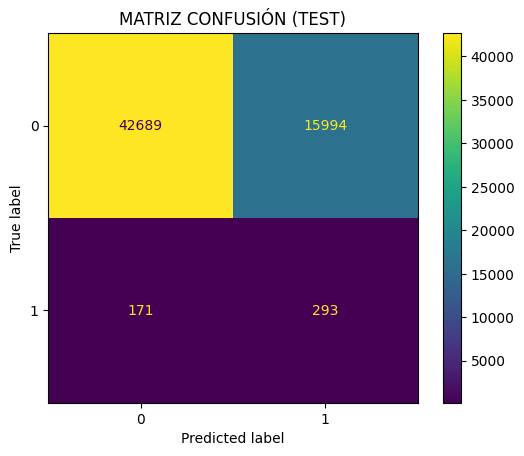

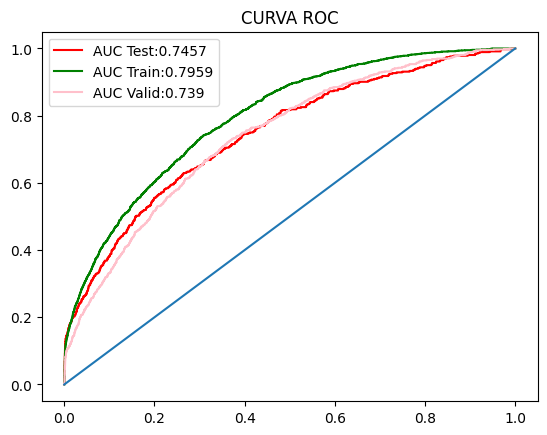

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score,roc_curve,accuracy_score,recall_score,precision_score
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_sample_weight

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
from sklearn.ensemble import HistGradientBoostingClassifier
modelo_hgb_optuna1_vi = HistGradientBoostingClassifier(**best_params_hgb1)
modelo_hgb_optuna1_vi.fit(x_train,y_train,sample_weight=sample_weights)
predicciones_test = modelo_hgb_optuna1_vi.predict(x_test)
predicciones_train = modelo_hgb_optuna1_vi.predict(x_train)
predicciones_valid = modelo_hgb_optuna1_vi.predict(x_valid)
predicciones_prob_test = modelo_hgb_optuna1_vi.predict_proba(x_test)
predicciones_prob_train = modelo_hgb_optuna1_vi.predict_proba(x_train)
predicciones_prob_valid = modelo_hgb_optuna1_vi.predict_proba(x_valid)
tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, predicciones_test).ravel()
tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, predicciones_train).ravel()
tn_valid, fp_valid, fn_valid, tp_valid = confusion_matrix(y_valid, predicciones_valid).ravel()



#Mostrando las métricas
print('AUC-ROC Test:',roc_auc_score(y_test,predicciones_prob_test[:,1] ))
print('AUC-ROC Train:',roc_auc_score(y_train,predicciones_prob_train[:,1]))
print('AUC-ROC Validation:',roc_auc_score(y_valid,predicciones_prob_valid[:,1]))
print('Sensibilidad Test:',recall_score(y_test, predicciones_test, pos_label = 1))
print('Sensibilidad Train:',recall_score(y_train, predicciones_train, pos_label = 1))
print('Sensibilidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 1))
print('Especificidad Test:',recall_score(y_test, predicciones_test, pos_label = 0))
print('Especificidad Train:',recall_score(y_train, predicciones_train, pos_label = 0))
print('Especificidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 0))
print('F1 Score Test:',f1_score(y_test, predicciones_test))
print('F1 Score Train:',f1_score(y_train, predicciones_train))
print('F1 Score Valid:',f1_score(y_valid, predicciones_valid))
print('Tasa de FN Test:', fn_test / (tn_test + fn_test))
print('Tasa de FN Train:', fn_train / (tn_train + fn_train))
print('Tasa de FN Valid:', fn_valid / (tn_valid + fn_valid))
print('Precision Test:', precision_score(y_test, predicciones_test))
print('Precision Train:', precision_score(y_train, predicciones_train))
print('Precision Valid:', precision_score(y_valid, predicciones_valid))

#Matriz de Confusión
cm = confusion_matrix(y_test, predicciones_test)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('MATRIZ CONFUSIÓN (TEST)')
plt.show()


##Curva AUC ROC
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, predicciones_prob_test[:,1])
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, predicciones_prob_train[:,1])
fpr_valid, tpr_valid, thresholds_valid = roc_curve(y_valid, predicciones_prob_valid[:,1])
plt.plot(fpr_test, tpr_test, color = 'red', label = f'AUC Test:{round(roc_auc_score(y_test,predicciones_prob_test[:,1] ),4)}')
plt.plot(fpr_train, tpr_train, color = 'green', label = f'AUC Train:{round(roc_auc_score(y_train,predicciones_prob_train[:,1] ),4)}')
plt.plot(fpr_valid, tpr_valid, color = 'pink', label = f'AUC Valid:{round(roc_auc_score(y_valid,predicciones_prob_valid[:,1] ),4)}')
plt.plot([0, 1], [0, 1])
plt.legend()
plt.title('CURVA ROC')
plt.show()

In [ ]:
!pip install optuna

In [ ]:
import optuna
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

def objective(trial):
    params = {
        "loss": "log_loss",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15),
        "max_iter": trial.suggest_int("max_iter", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 20, 300),
        "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 5.0),
        "max_bins": trial.suggest_int("max_bins", 64, 255),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 63),
        "random_state": 42,
        "early_stopping": True,
        "validation_fraction": 0.1,
        "n_iter_no_change": 30,
    }

    model = HistGradientBoostingClassifier(**params)

    model.fit(
        x_train,
        y_train,
        sample_weight=sample_weights
    )

    preds_test = model.predict_proba(x_test)[:, 1]
    auc_test = roc_auc_score(y_test, preds_test)

    return auc_test

In [ ]:
study2 = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study2.optimize(objective, n_trials=200, show_progress_bar=True)

[I 2026-06-10 14:52:21,761] A new study created in memory with name: no-name-cd0905cf-bca2-49ab-9d08-25ea739de8a9


  0%|          | 0/200 [00:00<?, ?it/s]

[I 2026-06-10 14:52:24,937] Trial 0 finished with value: 0.7404175201712062 and parameters: {'learning_rate': 0.062435616638630745, 'max_iter': 576, 'max_depth': 7, 'min_samples_leaf': 188, 'l2_regularization': 0.7800932022121826, 'max_bins': 93, 'max_leaf_nodes': 17}. Best is trial 0 with value: 0.7404175201712062.
[I 2026-06-10 14:52:27,769] Trial 1 finished with value: 0.7407414222059258 and parameters: {'learning_rate': 0.1312646604084909, 'max_iter': 401, 'max_depth': 6, 'min_samples_leaf': 25, 'l2_regularization': 4.8495492608099715, 'max_bins': 223, 'max_leaf_nodes': 25}. Best is trial 1 with value: 0.7407414222059258.
[I 2026-06-10 14:52:33,566] Trial 2 finished with value: 0.7449353466638696 and parameters: {'learning_rate': 0.035455495408994085, 'max_iter': 191, 'max_depth': 4, 'min_samples_leaf': 167, 'l2_regularization': 2.1597250932105787, 'max_bins': 119, 'max_leaf_nodes': 44}. Best is trial 2 with value: 0.7449353466638696.
[I 2026-06-10 14:52:39,279] Trial 3 finished wi

In [ ]:
best_params_hgb_vi = study2.best_params
best_params_hgb_vi

{'learning_rate': 0.11016368621580948,
 'max_iter': 308,
 'max_depth': 2,
 'min_samples_leaf': 133,
 'l2_regularization': 2.4575482447374184,
 'max_bins': 64,
 'max_leaf_nodes': 52}

In [ ]:
best_params_hgb_vi = {'learning_rate': 0.11016368621580948,
 'max_iter': 308,
 'max_depth': 2,
 'min_samples_leaf': 133,
 'l2_regularization': 2.4575482447374184,
 'max_bins': 64,
 'max_leaf_nodes': 52,
 "loss": "log_loss",
 "random_state": 42,
 "early_stopping": True,
 "validation_fraction": 0.1,
  "n_iter_no_change": 30}

AUC-ROC Test: 0.7452746551165907
AUC-ROC Train: 0.8090612568194984
AUC-ROC Validation: 0.7394517460801284
Sensibilidad Test: 0.6293103448275862
Sensibilidad Train: 0.7090815802975885
Sensibilidad Valid: 0.5526675786593708
Especificidad Test: 0.7351703218990168
Especificidad Train: 0.7340379738743155
Especificidad Valid: 0.7698410660641385
F1 Score Test: 0.03583481622384488
F1 Score Train: 0.04204761542557237
F1 Score Valid: 0.042385773487908514
Tasa de FN Test: 0.003971002447245694
Tasa de FN Train: 0.0032812879778701142
Tasa de FN Valid: 0.005423515167598229
Precision Test: 0.0184424935261795
Precision Train: 0.021666196344025335
Precision Valid: 0.022037966397556185


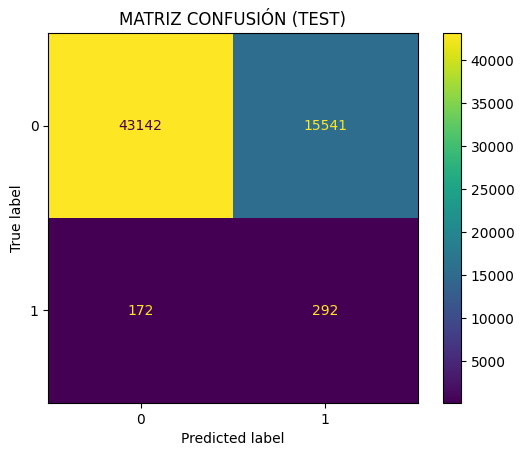

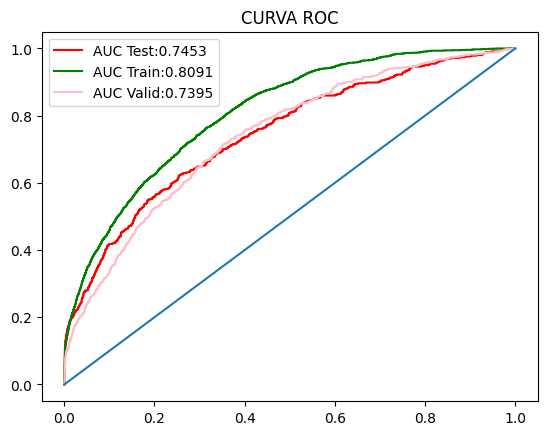

In [ ]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
modelo_hgb_optuna_vi2 = HistGradientBoostingClassifier(**best_params_hgb_vi)
modelo_hgb_optuna_vi2.fit(x_train,y_train,sample_weight=sample_weights)
predicciones_test = modelo_hgb_optuna_vi2.predict(x_test)
predicciones_train = modelo_hgb_optuna_vi2.predict(x_train)
predicciones_valid = modelo_hgb_optuna_vi2.predict(x_valid)
predicciones_prob_test = modelo_hgb_optuna_vi2.predict_proba(x_test)
predicciones_prob_train = modelo_hgb_optuna_vi2.predict_proba(x_train)
predicciones_prob_valid = modelo_hgb_optuna_vi2.predict_proba(x_valid)
tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, predicciones_test).ravel()
tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, predicciones_train).ravel()
tn_valid, fp_valid, fn_valid, tp_valid = confusion_matrix(y_valid, predicciones_valid).ravel()



#Mostrando las métricas
print('AUC-ROC Test:',roc_auc_score(y_test,predicciones_prob_test[:,1] ))
print('AUC-ROC Train:',roc_auc_score(y_train,predicciones_prob_train[:,1]))
print('AUC-ROC Validation:',roc_auc_score(y_valid,predicciones_prob_valid[:,1]))
print('Sensibilidad Test:',recall_score(y_test, predicciones_test, pos_label = 1))
print('Sensibilidad Train:',recall_score(y_train, predicciones_train, pos_label = 1))
print('Sensibilidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 1))
print('Especificidad Test:',recall_score(y_test, predicciones_test, pos_label = 0))
print('Especificidad Train:',recall_score(y_train, predicciones_train, pos_label = 0))
print('Especificidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 0))
print('F1 Score Test:',f1_score(y_test, predicciones_test))
print('F1 Score Train:',f1_score(y_train, predicciones_train))
print('F1 Score Valid:',f1_score(y_valid, predicciones_valid))
print('Tasa de FN Test:', fn_test / (tn_test + fn_test))
print('Tasa de FN Train:', fn_train / (tn_train + fn_train))
print('Tasa de FN Valid:', fn_valid / (tn_valid + fn_valid))
print('Precision Test:', precision_score(y_test, predicciones_test))
print('Precision Train:', precision_score(y_train, predicciones_train))
print('Precision Valid:', precision_score(y_valid, predicciones_valid))

#Matriz de Confusión
cm = confusion_matrix(y_test, predicciones_test)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('MATRIZ CONFUSIÓN (TEST)')
plt.show()


##Curva AUC ROC
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, predicciones_prob_test[:,1])
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, predicciones_prob_train[:,1])
fpr_valid, tpr_valid, thresholds_valid = roc_curve(y_valid, predicciones_prob_valid[:,1])
plt.plot(fpr_test, tpr_test, color = 'red', label = f'AUC Test:{round(roc_auc_score(y_test,predicciones_prob_test[:,1] ),4)}')
plt.plot(fpr_train, tpr_train, color = 'green', label = f'AUC Train:{round(roc_auc_score(y_train,predicciones_prob_train[:,1] ),4)}')
plt.plot(fpr_valid, tpr_valid, color = 'pink', label = f'AUC Valid:{round(roc_auc_score(y_valid,predicciones_prob_valid[:,1] ),4)}')
plt.plot([0, 1], [0, 1])
plt.legend()
plt.title('CURVA ROC')
plt.show()

***Modelo Seleccionado 2 - Optuna 2 (Experimentación Variables Importantes sin Edad, ni Antiguedad)***
----------------------------------------------------------------------------------------------------------------------------------------------


---
Aquí se encuentra el segundo mejor modelo


In [ ]:
variables_importantes1 = [
    "DIAS_DESDE_ULTIMA_COMPRA",
    "DAYS_FIRST_RED",
    "DAYS_LAST_RED",
    "AVG_DIAS_ENTRE_COMPRAS_EVER",
    #"APROX_AGE",
    "q_int_last1m_chat_helpctr",
    "q_int_ever_cshb_error",
    "COUNTRY_1_EXTRANJERO",
    "q_int_last1m_home_showbal",
    "PORC_UTILIZ_3M",
    "q_int_ever_myprf_dropact",
    #"MESES_OB_ANALISIS",
    "q_int_last1m_myprf_dropact",
    "q_int_last1m_home_settings",
    "AMT_DELIVERY_EVER",
    "Q_TC_STATUS_EVER",
    "mobile_brand_name_APPLE",
    "AMT_PURCH_15A22_1M",
    "Q_PAGSERV_EVER",
    "AMT_FARMA_1M",
    "q_int_last1m_home_amtmov",
    "PROFESION_cat_ADMINISTRADOR",
    "AVG_STATEMENT_BALANCE_3M",
    "AVG_DIAS_ENTRE_COMPRAS_LAST3M",
    "Q_MAILING_CUSTIO_EMAIL_OPEN",
    "q_int_ever_home_settings",
    "AVG_CURRENT_BALANCE_1M",
    "MAX_DPD_1M",
    "mobile_brand_name_XIAOMI",
    "Q_MAILING_CUSTIO_EMAIL_DEL",
    "USERDEVICE_PLATFORM_SO_IOS",
    "PORC_UTILIZ_EVER",
    "q_int_ever_notfcrdlim_total",
    "q_int_ever_cshb_success",
    "AMT_ROPA_EVER",
    "AMT_PAYMENT_3M",
    "AMT_CASHBACK_AWARDED_LAST1M",
    "Q_MAILING_CUSTIO_EMAIL_SENT",
    "DAYS_OB_LASTREF",
    "q_int_last1m_home_crdetails",
    "MESES_CON_CONSUMO_10",
    "q_int_ever_pay_yapeok",
    "DAYS_LASTREF_TODATE",
    "PROFESION_cat_RESTO",
    "PORC_UTILIZ_1M",
    "AMT_WE_PURCH_EVER",
    "AMT_PURCH_1M",
    "q_int_ever_sdta_error",
    "DIAS_OB_1RACOMPRA",
    "q_int_last1m_myprf_avatar",
    "DAYS_1STOP_CONV",
    "AMT_PURCH_7A14_1M",
    "DOMAIN_EMAIL_cat_hotmail",
    "AMT_WE_PURCH_3M",
    "MAX_CREDIT_LINE_1M",
    "q_int_ever_pay_home",
    "Q_PURCH_15A22_1M",
    "q_int_ever_bnf_seemore",
    "Q_DELIVERY_EVER",
    "TIEMPO_TOTAL_ONBOARGING_MINUTOS",
    "AMT_DELIVERY_3M",
    "q_int_ever_home_amtmov",
    "AMT_BENEFITS_3M",
    "q_int_last1m_ref_sharecode",
    "q_int_ever_chat_helpctr",
    "MAX_APR_VALUE_EVER",
    "q_int_last1m_home_hidebal",
    "Q_DELIVERY_3M",
    "AVG_STATEMENT_BALANCE_1M",
    "q_int_last1m_myprf_ref",
    "MAX_DPD_EVER",
    "q_int_last1m_ref_bau",
    "Q_REJ_INSFD_EVER",
    "Q_STREAMING_3M",
    "q_int_ever_myprf_avatar",
    "q_int_ever_login_recpasscheck",
    "AMT_PHY_PURCH_1M",
    "AMT_PURCH_7A14_EVER",
    "q_int_ever_sdta_ccd",
    "Q_TECNO_EVER",
    "AMT_PURCH_3M",
    "q_int_last1m_notfcrdlim_75",
    "Q_PHY_PURCH_1M",
    "USERDEVICE_PLATFORM_SO_ANDROID",
    "q_int_ever_home_crdetails",
    "q_int_last1m_bnf_bydept",
    "Q_RESTAUR_EVER",
    "AMT_CASHBACK_REDEEMED_EVER",
    "AVG_STATEMENT_BALANCE_EVER",
    "Q_FARMA_1M",
    "q_int_ever_ref_sharecode",
    "AMT_BENEFITS_EVER",
    "q_int_ever_notfcrdlim_75_off",
    "Q_RESTAUR_3M",
    "q_int_ever_home_hidebal",
    "MESES_DESDE_ULTIMA_COMPRA",
    "AMT_WE_PURCH_1M",
    "AMT_SUPER_EVER",
    "AMT_AUTO_3M",
    "AMT_SUPER_1M",
    "Q_WE_PURCH_1M",
    "MESES_CON_CONSUMO",
    "TOTAL_PRIZE"
]

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split
df_final9 = df_final8.copy()
df_final9['FECHA_SNAPSHOT'] = pd.to_datetime(df_final9['FECHA_SNAPSHOT'])
train = pd.to_datetime([
    '2025-10-01',
    '2026-01-01','2026-02-01','2026-03-01','2026-04-01'
])
validation = pd.to_datetime(['2026-05-01'])
data_train = df_final9[df_final9['FECHA_SNAPSHOT'].isin(train)].copy()
data_validation = df_final9[df_final9['FECHA_SNAPSHOT'].isin(validation)].copy()
x = data_train.drop(columns=['TARGET_CHURN']).copy()
y = data_train['TARGET_CHURN'].copy()

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)
x_valid = data_validation.drop(columns=['TARGET_CHURN']).copy()
y_valid = data_validation['TARGET_CHURN'].copy()

In [ ]:
x_train_exp1 = x_train[variables_importantes1].copy()
x_test_exp1 = x_test[variables_importantes1].copy()
x_valid_exp1 = x_valid[variables_importantes1].copy()

In [ ]:
x_train.shape, x_train_exp1.shape

((236584, 351), (236584, 101))

In [ ]:
best_params_hgb1

{'learning_rate': 0.1383808904826321,
 'max_iter': 531,
 'max_depth': 2,
 'min_samples_leaf': 224,
 'l2_regularization': 1.3035953161815257,
 'max_bins': 117,
 'max_leaf_nodes': 49}

AUC-ROC Test: 0.7442580335196647
AUC-ROC Train: 0.7942801611135306
AUC-ROC Validation: 0.7415910488619755
Sensibilidad Test: 0.6357758620689655
Sensibilidad Train: 0.7008722421754746
Sensibilidad Valid: 0.6060191518467852
Especificidad Test: 0.7212310209089515
Especificidad Train: 0.7205617235280329
Especificidad Valid: 0.7449482630241097
F1 Score Test: 0.03446664329945087
F1 Score Train: 0.03966260652429553
F1 Score Valid: 0.04210826481631101
Tasa de FN Test: 0.003977125644223755
Tasa de FN Train: 0.0034364463725744467
Tasa de FN Valid: 0.004938695018434365
Precision Test: 0.017713462231295784
Precision Train: 0.020408773083129148
Precision Valid: 0.021811915312653866


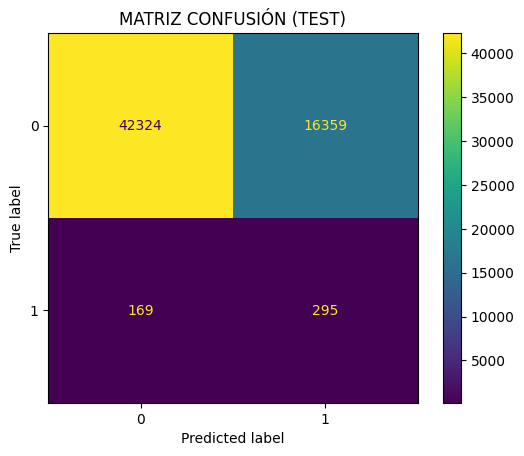

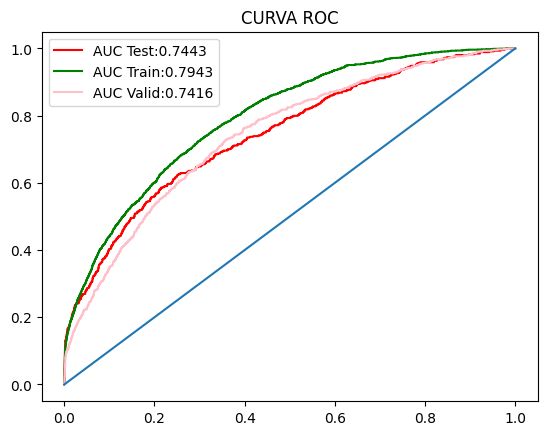

In [ ]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
modelo_hgb_optuna1_vi_exp1 = HistGradientBoostingClassifier(**best_params_hgb1)
modelo_hgb_optuna1_vi_exp1.fit(x_train_exp1,y_train,sample_weight=sample_weights)
predicciones_test = modelo_hgb_optuna1_vi_exp1.predict(x_test_exp1)
predicciones_train = modelo_hgb_optuna1_vi_exp1.predict(x_train_exp1)
predicciones_valid = modelo_hgb_optuna1_vi_exp1.predict(x_valid_exp1)
predicciones_prob_test = modelo_hgb_optuna1_vi_exp1.predict_proba(x_test_exp1)
predicciones_prob_train = modelo_hgb_optuna1_vi_exp1.predict_proba(x_train_exp1)
predicciones_prob_valid = modelo_hgb_optuna1_vi_exp1.predict_proba(x_valid_exp1)
tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, predicciones_test).ravel()
tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, predicciones_train).ravel()
tn_valid, fp_valid, fn_valid, tp_valid = confusion_matrix(y_valid, predicciones_valid).ravel()


#Mostrando las métricas
print('AUC-ROC Test:',roc_auc_score(y_test,predicciones_prob_test[:,1] ))
print('AUC-ROC Train:',roc_auc_score(y_train,predicciones_prob_train[:,1]))
print('AUC-ROC Validation:',roc_auc_score(y_valid,predicciones_prob_valid[:,1]))
print('Sensibilidad Test:',recall_score(y_test, predicciones_test, pos_label = 1))
print('Sensibilidad Train:',recall_score(y_train, predicciones_train, pos_label = 1))
print('Sensibilidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 1))
print('Especificidad Test:',recall_score(y_test, predicciones_test, pos_label = 0))
print('Especificidad Train:',recall_score(y_train, predicciones_train, pos_label = 0))
print('Especificidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 0))
print('F1 Score Test:',f1_score(y_test, predicciones_test))
print('F1 Score Train:',f1_score(y_train, predicciones_train))
print('F1 Score Valid:',f1_score(y_valid, predicciones_valid))
print('Tasa de FN Test:', fn_test / (tn_test + fn_test))
print('Tasa de FN Train:', fn_train / (tn_train + fn_train))
print('Tasa de FN Valid:', fn_valid / (tn_valid + fn_valid))
print('Precision Test:', precision_score(y_test, predicciones_test))
print('Precision Train:', precision_score(y_train, predicciones_train))
print('Precision Valid:', precision_score(y_valid, predicciones_valid))

#Matriz de Confusión
cm = confusion_matrix(y_test, predicciones_test)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('MATRIZ CONFUSIÓN (TEST)')
plt.show()

##Curva AUC ROC
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, predicciones_prob_test[:,1])
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, predicciones_prob_train[:,1])
fpr_valid, tpr_valid, thresholds_valid = roc_curve(y_valid, predicciones_prob_valid[:,1])
plt.plot(fpr_test, tpr_test, color = 'red', label = f'AUC Test:{round(roc_auc_score(y_test,predicciones_prob_test[:,1] ),4)}')
plt.plot(fpr_train, tpr_train, color = 'green', label = f'AUC Train:{round(roc_auc_score(y_train,predicciones_prob_train[:,1] ),4)}')
plt.plot(fpr_valid, tpr_valid, color = 'pink', label = f'AUC Valid:{round(roc_auc_score(y_valid,predicciones_prob_valid[:,1] ),4)}')
plt.plot([0, 1], [0, 1])
plt.legend()
plt.title('CURVA ROC')
plt.show()

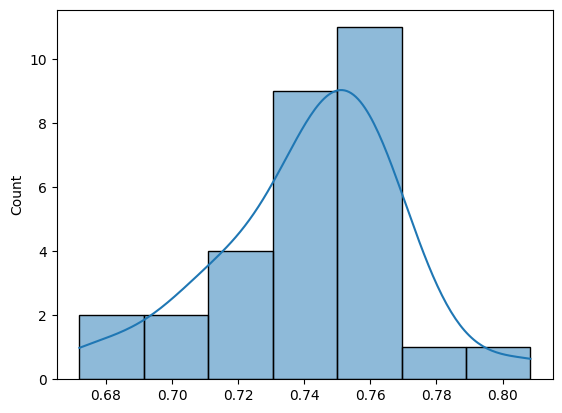

In [ ]:
from sklearn.model_selection import RepeatedKFold, cross_val_score,RepeatedStratifiedKFold
#Validacion Cruzada
cv = RepeatedStratifiedKFold(n_splits=15, n_repeats=2, random_state=123)
scores = cross_val_score(modelo_hgb_optuna1_vi_exp1,x_valid_exp1,y_valid,cv = cv, scoring='roc_auc').round(4)
ax = sns.histplot(x=scores, kde = True)

In [ ]:
import joblib
joblib.dump(modelo_hgb_optuna1_vi_exp1, "modelo_Churn_reentrenado_V2.pkl")

['modelo_Churn_reentrenado_V2.pkl']

In [ ]:
import optuna
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

def objective(trial):
    params = {
        #"loss": "log_loss",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15),
        "max_iter": trial.suggest_int("max_iter", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 20, 300),
        "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 5.0),
        "max_bins": trial.suggest_int("max_bins", 64, 255),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 63),
        #"random_state": 42,
        #"early_stopping": True,
        #"validation_fraction": 0.1,
        #"n_iter_no_change": 30,
    }

    model = HistGradientBoostingClassifier(**params)

    model.fit(
        x_train_exp1,
        y_train,
        sample_weight=sample_weights
    )

    preds_test = model.predict_proba(x_test_exp1)[:, 1]
    auc_test = roc_auc_score(y_test, preds_test)

    return auc_test

In [ ]:
study3 = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=42)
)
study3.optimize(objective, n_trials=500, show_progress_bar=True)

[I 2026-06-10 20:11:32,353] A new study created in memory with name: no-name-ed3c7de5-bf40-4a88-ba04-d7ed71aaf0ae


  0%|          | 0/500 [00:00<?, ?it/s]

[I 2026-06-10 20:11:35,257] Trial 0 finished with value: 0.7423743923370864 and parameters: {'learning_rate': 0.062435616638630745, 'max_iter': 576, 'max_depth': 7, 'min_samples_leaf': 188, 'l2_regularization': 0.7800932022121826, 'max_bins': 93, 'max_leaf_nodes': 17}. Best is trial 0 with value: 0.7423743923370864.
[I 2026-06-10 20:11:36,753] Trial 1 finished with value: 0.7384649816342276 and parameters: {'learning_rate': 0.1312646604084909, 'max_iter': 401, 'max_depth': 6, 'min_samples_leaf': 25, 'l2_regularization': 4.8495492608099715, 'max_bins': 223, 'max_leaf_nodes': 25}. Best is trial 0 with value: 0.7423743923370864.
[I 2026-06-10 20:11:40,867] Trial 2 finished with value: 0.7468828721470766 and parameters: {'learning_rate': 0.035455495408994085, 'max_iter': 191, 'max_depth': 4, 'min_samples_leaf': 167, 'l2_regularization': 2.1597250932105787, 'max_bins': 119, 'max_leaf_nodes': 44}. Best is trial 2 with value: 0.7468828721470766.
[I 2026-06-10 20:11:43,862] Trial 3 finished wi

In [ ]:
best_params_hgb_vi_exp1 = study3.best_params
best_params_hgb_vi_exp1

{'learning_rate': 0.052681983302528455,
 'max_iter': 577,
 'max_depth': 3,
 'min_samples_leaf': 98,
 'l2_regularization': 4.141076239528974,
 'max_bins': 200,
 'max_leaf_nodes': 25}

AUC-ROC Test: 0.7459666218025899
AUC-ROC Train: 0.8053619344338662
AUC-ROC Validation: 0.7345066379274343
Sensibilidad Test: 0.6228448275862069
Sensibilidad Train: 0.7018984094407389
Sensibilidad Valid: 0.5622435020519836
Especificidad Test: 0.7412708961709524
Especificidad Train: 0.7394378502780915
Especificidad Valid: 0.7587490692479524
F1 Score Test: 0.03627008032128514
F1 Score Train: 0.04244887826977379
F1 Score Valid: 0.041236079060900974
Tasa de FN Test: 0.004006868918145392
Tasa de FN Train: 0.003337565128476152
Tasa de FN Valid: 0.005385210864662919
Precision Test: 0.018678903826266805
Precision Train: 0.021886249100071996
Precision Valid: 0.02140290579596938


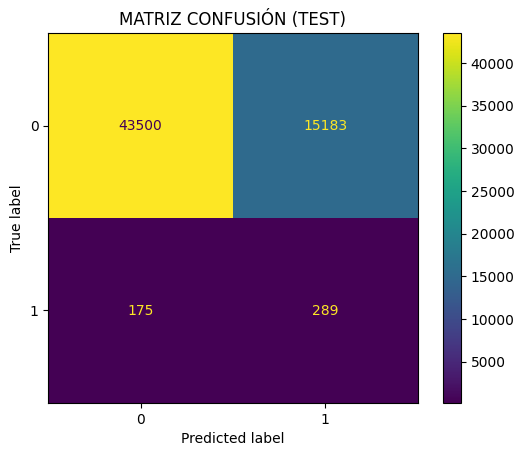

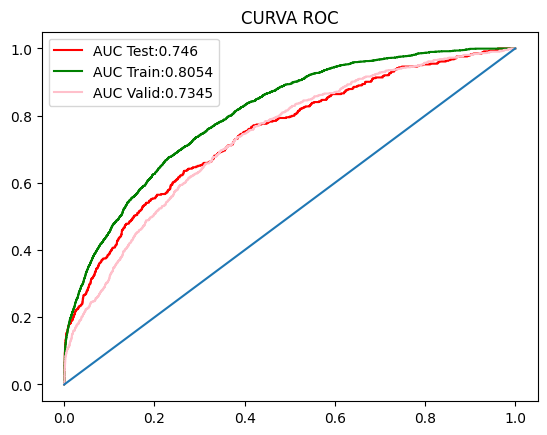

In [ ]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
modelo_exp1_optimizado_vi = HistGradientBoostingClassifier(**best_params_hgb_vi_exp1)
modelo_exp1_optimizado_vi.fit(x_train_exp1,y_train,sample_weight=sample_weights)
predicciones_test = modelo_exp1_optimizado_vi.predict(x_test_exp1)
predicciones_train = modelo_exp1_optimizado_vi.predict(x_train_exp1)
predicciones_valid =modelo_exp1_optimizado_vi.predict(x_valid_exp1)
predicciones_prob_test = modelo_exp1_optimizado_vi.predict_proba(x_test_exp1)
predicciones_prob_train = modelo_exp1_optimizado_vi.predict_proba(x_train_exp1)
predicciones_prob_valid = modelo_exp1_optimizado_vi.predict_proba(x_valid_exp1)
tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, predicciones_test).ravel()
tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, predicciones_train).ravel()
tn_valid, fp_valid, fn_valid, tp_valid = confusion_matrix(y_valid, predicciones_valid).ravel()


#Mostrando las métricas
print('AUC-ROC Test:',roc_auc_score(y_test,predicciones_prob_test[:,1] ))
print('AUC-ROC Train:',roc_auc_score(y_train,predicciones_prob_train[:,1]))
print('AUC-ROC Validation:',roc_auc_score(y_valid,predicciones_prob_valid[:,1]))
print('Sensibilidad Test:',recall_score(y_test, predicciones_test, pos_label = 1))
print('Sensibilidad Train:',recall_score(y_train, predicciones_train, pos_label = 1))
print('Sensibilidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 1))
print('Especificidad Test:',recall_score(y_test, predicciones_test, pos_label = 0))
print('Especificidad Train:',recall_score(y_train, predicciones_train, pos_label = 0))
print('Especificidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 0))
print('F1 Score Test:',f1_score(y_test, predicciones_test))
print('F1 Score Train:',f1_score(y_train, predicciones_train))
print('F1 Score Valid:',f1_score(y_valid, predicciones_valid))
print('Tasa de FN Test:', fn_test / (tn_test + fn_test))
print('Tasa de FN Train:', fn_train / (tn_train + fn_train))
print('Tasa de FN Valid:', fn_valid / (tn_valid + fn_valid))
print('Precision Test:', precision_score(y_test, predicciones_test))
print('Precision Train:', precision_score(y_train, predicciones_train))
print('Precision Valid:', precision_score(y_valid, predicciones_valid))

#Matriz de Confusión
cm = confusion_matrix(y_test, predicciones_test)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('MATRIZ CONFUSIÓN (TEST)')
plt.show()

##Curva AUC ROC
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, predicciones_prob_test[:,1])
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, predicciones_prob_train[:,1])
fpr_valid, tpr_valid, thresholds_valid = roc_curve(y_valid, predicciones_prob_valid[:,1])
plt.plot(fpr_test, tpr_test, color = 'red', label = f'AUC Test:{round(roc_auc_score(y_test,predicciones_prob_test[:,1] ),4)}')
plt.plot(fpr_train, tpr_train, color = 'green', label = f'AUC Train:{round(roc_auc_score(y_train,predicciones_prob_train[:,1] ),4)}')
plt.plot(fpr_valid, tpr_valid, color = 'pink', label = f'AUC Valid:{round(roc_auc_score(y_valid,predicciones_prob_valid[:,1] ),4)}')
plt.plot([0, 1], [0, 1])
plt.legend()
plt.title('CURVA ROC')
plt.show()

## ***Optuna 3 (Experimentación Variables Importantes y Variables Negativas)***

In [ ]:
variables_importantes2 = [
    "DIAS_DESDE_ULTIMA_COMPRA",
    "DAYS_FIRST_RED",
    "DAYS_LAST_RED",
    "AVG_DIAS_ENTRE_COMPRAS_EVER",
    #"APROX_AGE",
    "q_int_last1m_chat_helpctr",
    "q_int_ever_cshb_error",
    "COUNTRY_1_EXTRANJERO",
    "q_int_last1m_home_showbal",
    "PORC_UTILIZ_3M",
    "q_int_ever_myprf_dropact",
    #"MESES_OB_ANALISIS",
    "q_int_last1m_myprf_dropact",
    "q_int_last1m_home_settings",
    "AMT_DELIVERY_EVER",
    "Q_TC_STATUS_EVER",
    "mobile_brand_name_APPLE",
    "AMT_PURCH_15A22_1M",
    "Q_PAGSERV_EVER",
    "AMT_FARMA_1M",
    "q_int_last1m_home_amtmov",
    "PROFESION_cat_ADMINISTRADOR",
    "AVG_STATEMENT_BALANCE_3M",
    "AVG_DIAS_ENTRE_COMPRAS_LAST3M",
    "Q_MAILING_CUSTIO_EMAIL_OPEN",
    "q_int_ever_home_settings",
    "AVG_CURRENT_BALANCE_1M",
    "MAX_DPD_1M",
    "mobile_brand_name_XIAOMI",
    "Q_MAILING_CUSTIO_EMAIL_DEL",
    "USERDEVICE_PLATFORM_SO_IOS",
    "PORC_UTILIZ_EVER",
    "q_int_ever_notfcrdlim_total",
    "q_int_ever_cshb_success",
    "AMT_ROPA_EVER",
    "AMT_PAYMENT_3M",
    "AMT_CASHBACK_AWARDED_LAST1M",
    "Q_MAILING_CUSTIO_EMAIL_SENT",
    "DAYS_OB_LASTREF",
    "q_int_last1m_home_crdetails",
    "MESES_CON_CONSUMO_10",
    "q_int_ever_pay_yapeok",
    "DAYS_LASTREF_TODATE",
    "PROFESION_cat_RESTO",
    "PORC_UTILIZ_1M",
    "AMT_WE_PURCH_EVER",
    "AMT_PURCH_1M",
    "q_int_ever_sdta_error",
    "DIAS_OB_1RACOMPRA",
    "q_int_last1m_myprf_avatar",
    "DAYS_1STOP_CONV",
    "AMT_PURCH_7A14_1M",
    "DOMAIN_EMAIL_cat_hotmail",
    "AMT_WE_PURCH_3M",
    "MAX_CREDIT_LINE_1M",
    "q_int_ever_pay_home",
    "Q_PURCH_15A22_1M",
    "q_int_ever_bnf_seemore",
    "Q_DELIVERY_EVER",
    "TIEMPO_TOTAL_ONBOARGING_MINUTOS",
    "AMT_DELIVERY_3M",
    "q_int_ever_home_amtmov",
    "AMT_BENEFITS_3M",
    "q_int_last1m_ref_sharecode",
    "q_int_ever_chat_helpctr",
    "MAX_APR_VALUE_EVER",
    "q_int_last1m_home_hidebal",
    "Q_DELIVERY_3M",
    "AVG_STATEMENT_BALANCE_1M",
    "q_int_last1m_myprf_ref",
    "MAX_DPD_EVER",
    "q_int_last1m_ref_bau",
    "Q_REJ_INSFD_EVER",
    "Q_STREAMING_3M",
    "q_int_ever_myprf_avatar",
    "q_int_ever_login_recpasscheck",
    "AMT_PHY_PURCH_1M",
    "AMT_PURCH_7A14_EVER",
    "q_int_ever_sdta_ccd",
    "Q_TECNO_EVER",
    "AMT_PURCH_3M",
    "q_int_last1m_notfcrdlim_75",
    "Q_PHY_PURCH_1M",
    "USERDEVICE_PLATFORM_SO_ANDROID",
    "q_int_ever_home_crdetails",
    "q_int_last1m_bnf_bydept",
    "Q_RESTAUR_EVER",
    "AMT_CASHBACK_REDEEMED_EVER",
    "AVG_STATEMENT_BALANCE_EVER",
    "Q_FARMA_1M",
    "q_int_ever_ref_sharecode",
    "AMT_BENEFITS_EVER",
    "q_int_ever_notfcrdlim_75_off",
    "Q_RESTAUR_3M",
    "q_int_ever_home_hidebal",
    "MESES_DESDE_ULTIMA_COMPRA",
    "AMT_WE_PURCH_1M",
    "AMT_SUPER_EVER",
    "AMT_AUTO_3M",
    "AMT_SUPER_1M",
    "Q_WE_PURCH_1M",
    "MESES_CON_CONSUMO",
    "TOTAL_PRIZE",
    ### Agregando los negativos
    'SUM_PAYMENT_AMT_EVER',
    'Q_PAGSERV_3M',
    'AMT_PAGSERV_3M',
    'AMT_PURCH_15A22_3M',
    'Q_MCC_TRX_LAST1M'
]

In [ ]:
x_train_exp2 = x_train[variables_importantes2].copy()
x_test_exp2 = x_test[variables_importantes2].copy()
x_valid_exp2 = x_valid[variables_importantes2].copy()

In [ ]:
x_train.shape, x_train_exp2.shape, x_train_exp1.shape

((236584, 351), (236584, 106), (236584, 101))

AUC-ROC Test: 0.7458479244414908
AUC-ROC Train: 0.790245969299849
AUC-ROC Validation: 0.7358632730291124
Sensibilidad Test: 0.6314655172413793
Sensibilidad Train: 0.6859928168291431
Sensibilidad Valid: 0.5909712722298222
Especificidad Test: 0.7276383279655096
Especificidad Train: 0.7267798921729495
Especificidad Valid: 0.7512260251110483
F1 Score Test: 0.03500597371565114
F1 Score Train: 0.03967771133500512
F1 Score Valid: 0.04206221702935592
Tasa de FN Test: 0.003988710316997504
Tasa de FN Train: 0.003576019633048966
Tasa de FN Valid: 0.005083737141885573
Precision Test: 0.018001966085033176
Precision Train: 0.02042968033738769
Precision Valid: 0.021807168096920748


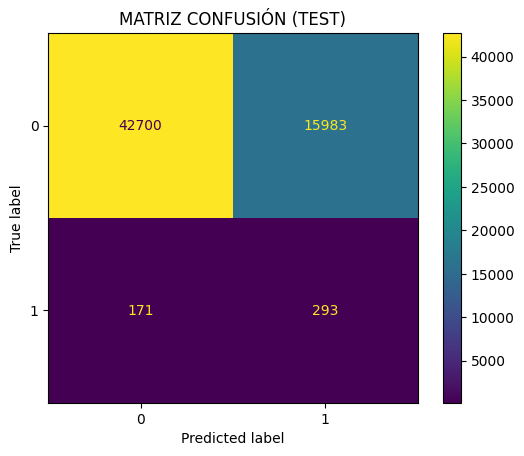

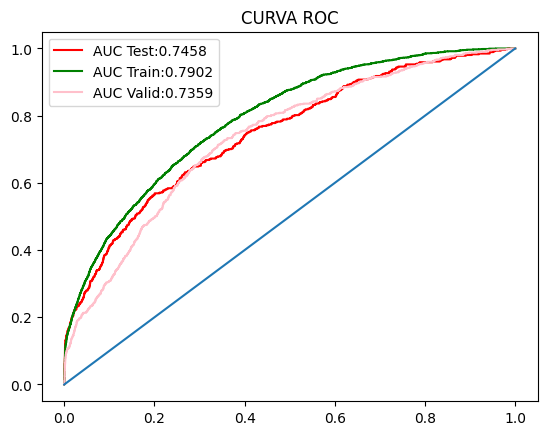

In [ ]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
modelo_hgb_optuna1_vi_exp2 = HistGradientBoostingClassifier(**best_params_hgb1)
modelo_hgb_optuna1_vi_exp2.fit(x_train_exp2,y_train,sample_weight=sample_weights)
predicciones_test = modelo_hgb_optuna1_vi_exp2.predict(x_test_exp2)
predicciones_train = modelo_hgb_optuna1_vi_exp2.predict(x_train_exp2)
predicciones_valid = modelo_hgb_optuna1_vi_exp2.predict(x_valid_exp2)
predicciones_prob_test = modelo_hgb_optuna1_vi_exp2.predict_proba(x_test_exp2)
predicciones_prob_train = modelo_hgb_optuna1_vi_exp2.predict_proba(x_train_exp2)
predicciones_prob_valid = modelo_hgb_optuna1_vi_exp2.predict_proba(x_valid_exp2)
tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, predicciones_test).ravel()
tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, predicciones_train).ravel()
tn_valid, fp_valid, fn_valid, tp_valid = confusion_matrix(y_valid, predicciones_valid).ravel()


#Mostrando las métricas
print('AUC-ROC Test:',roc_auc_score(y_test,predicciones_prob_test[:,1] ))
print('AUC-ROC Train:',roc_auc_score(y_train,predicciones_prob_train[:,1]))
print('AUC-ROC Validation:',roc_auc_score(y_valid,predicciones_prob_valid[:,1]))
print('Sensibilidad Test:',recall_score(y_test, predicciones_test, pos_label = 1))
print('Sensibilidad Train:',recall_score(y_train, predicciones_train, pos_label = 1))
print('Sensibilidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 1))
print('Especificidad Test:',recall_score(y_test, predicciones_test, pos_label = 0))
print('Especificidad Train:',recall_score(y_train, predicciones_train, pos_label = 0))
print('Especificidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 0))
print('F1 Score Test:',f1_score(y_test, predicciones_test))
print('F1 Score Train:',f1_score(y_train, predicciones_train))
print('F1 Score Valid:',f1_score(y_valid, predicciones_valid))
print('Tasa de FN Test:', fn_test / (tn_test + fn_test))
print('Tasa de FN Train:', fn_train / (tn_train + fn_train))
print('Tasa de FN Valid:', fn_valid / (tn_valid + fn_valid))
print('Precision Test:', precision_score(y_test, predicciones_test))
print('Precision Train:', precision_score(y_train, predicciones_train))
print('Precision Valid:', precision_score(y_valid, predicciones_valid))

#Matriz de Confusión
cm = confusion_matrix(y_test, predicciones_test)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('MATRIZ CONFUSIÓN (TEST)')
plt.show()

##Curva AUC ROC
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, predicciones_prob_test[:,1])
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, predicciones_prob_train[:,1])
fpr_valid, tpr_valid, thresholds_valid = roc_curve(y_valid, predicciones_prob_valid[:,1])
plt.plot(fpr_test, tpr_test, color = 'red', label = f'AUC Test:{round(roc_auc_score(y_test,predicciones_prob_test[:,1] ),4)}')
plt.plot(fpr_train, tpr_train, color = 'green', label = f'AUC Train:{round(roc_auc_score(y_train,predicciones_prob_train[:,1] ),4)}')
plt.plot(fpr_valid, tpr_valid, color = 'pink', label = f'AUC Valid:{round(roc_auc_score(y_valid,predicciones_prob_valid[:,1] ),4)}')
plt.plot([0, 1], [0, 1])
plt.legend()
plt.title('CURVA ROC')
plt.show()

In [ ]:
import optuna
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)

def objective(trial):
    params = {
        #"loss": "log_loss",
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.15),
        "max_iter": trial.suggest_int("max_iter", 100, 600),
        "max_depth": trial.suggest_int("max_depth", 2, 8),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 20, 300),
        "l2_regularization": trial.suggest_float("l2_regularization", 0.0, 5.0),
        "max_bins": trial.suggest_int("max_bins", 64, 255),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 15, 63),
        #"random_state": 42,
        #"early_stopping": True,
        #"validation_fraction": 0.1,
        #"n_iter_no_change": 30,
    }

    model = HistGradientBoostingClassifier(**params)

    model.fit(
        x_train_exp2,
        y_train,
        sample_weight=sample_weights
    )

    preds_test = model.predict_proba(x_test_exp2)[:, 1]
    auc_test = roc_auc_score(y_test, preds_test)

    return auc_test

In [ ]:
study4 = optuna.create_study(direction="maximize")
study4.optimize(objective, n_trials=300, show_progress_bar=True)

[I 2026-06-10 20:56:38,260] A new study created in memory with name: no-name-c1e9af82-9307-491b-aed0-ae9169bc37ce


  0%|          | 0/300 [00:00<?, ?it/s]

[I 2026-06-10 20:56:40,358] Trial 0 finished with value: 0.7271971241451 and parameters: {'learning_rate': 0.08484213578502924, 'max_iter': 599, 'max_depth': 7, 'min_samples_leaf': 179, 'l2_regularization': 4.0039970784063685, 'max_bins': 117, 'max_leaf_nodes': 61}. Best is trial 0 with value: 0.7271971241451.
[I 2026-06-10 20:56:42,258] Trial 1 finished with value: 0.7393550833026308 and parameters: {'learning_rate': 0.12908260685254552, 'max_iter': 154, 'max_depth': 6, 'min_samples_leaf': 156, 'l2_regularization': 0.5055275837092615, 'max_bins': 135, 'max_leaf_nodes': 22}. Best is trial 1 with value: 0.7393550833026308.
[I 2026-06-10 20:56:45,633] Trial 2 finished with value: 0.7469738783540085 and parameters: {'learning_rate': 0.06054668970681981, 'max_iter': 498, 'max_depth': 4, 'min_samples_leaf': 165, 'l2_regularization': 0.6842481164947761, 'max_bins': 164, 'max_leaf_nodes': 29}. Best is trial 2 with value: 0.7469738783540085.
[I 2026-06-10 20:56:48,013] Trial 3 finished with va

In [ ]:
best_params_exp2 = study4.best_params
best_params_exp2

{'learning_rate': 0.059639074298651916,
 'max_iter': 502,
 'max_depth': 4,
 'min_samples_leaf': 178,
 'l2_regularization': 3.51965044316257,
 'max_bins': 166,
 'max_leaf_nodes': 23}

AUC-ROC Test: 0.7449307375924532
AUC-ROC Train: 0.8037759858950602
AUC-ROC Validation: 0.7350710602998771
Sensibilidad Test: 0.6206896551724138
Sensibilidad Train: 0.70702924576706
Sensibilidad Valid: 0.5937072503419972
Especificidad Test: 0.7278087350680776
Especificidad Train: 0.7277217806380122
Especificidad Valid: 0.7496597940791332
F1 Score Test: 0.03443946188340807
F1 Score Train: 0.041003972445806613
F1 Score Valid: 0.04200338736994919
Tasa de FN Test: 0.004103903371729702
Tasa de FN Train: 0.0033329441979920616
Tasa de FN Valid: 0.005060401083641444
Precision Test: 0.017711087878974234
Precision Train: 0.02111424368717823
Precision Valid: 0.021771847095414867


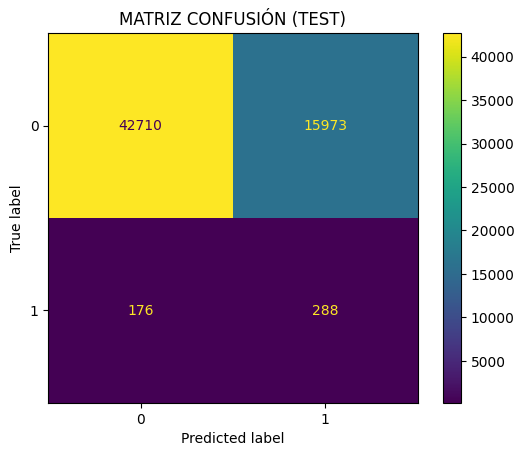

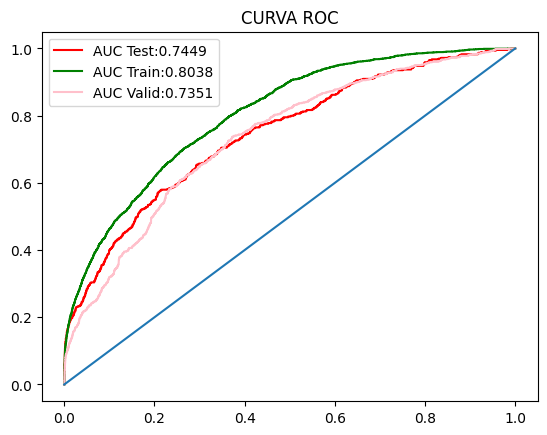

In [ ]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
modelo_exp2_optimizado = HistGradientBoostingClassifier(**best_params_exp2)
modelo_exp2_optimizado.fit(x_train_exp2,y_train,sample_weight=sample_weights)
predicciones_test = modelo_exp2_optimizado.predict(x_test_exp2)
predicciones_train = modelo_exp2_optimizado.predict(x_train_exp2)
predicciones_valid = modelo_exp2_optimizado.predict(x_valid_exp2)
predicciones_prob_test = modelo_exp2_optimizado.predict_proba(x_test_exp2)
predicciones_prob_train = modelo_exp2_optimizado.predict_proba(x_train_exp2)
predicciones_prob_valid = modelo_exp2_optimizado.predict_proba(x_valid_exp2)
tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, predicciones_test).ravel()
tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, predicciones_train).ravel()
tn_valid, fp_valid, fn_valid, tp_valid = confusion_matrix(y_valid, predicciones_valid).ravel()


#Mostrando las métricas
print('AUC-ROC Test:',roc_auc_score(y_test,predicciones_prob_test[:,1] ))
print('AUC-ROC Train:',roc_auc_score(y_train,predicciones_prob_train[:,1]))
print('AUC-ROC Validation:',roc_auc_score(y_valid,predicciones_prob_valid[:,1]))
print('Sensibilidad Test:',recall_score(y_test, predicciones_test, pos_label = 1))
print('Sensibilidad Train:',recall_score(y_train, predicciones_train, pos_label = 1))
print('Sensibilidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 1))
print('Especificidad Test:',recall_score(y_test, predicciones_test, pos_label = 0))
print('Especificidad Train:',recall_score(y_train, predicciones_train, pos_label = 0))
print('Especificidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 0))
print('F1 Score Test:',f1_score(y_test, predicciones_test))
print('F1 Score Train:',f1_score(y_train, predicciones_train))
print('F1 Score Valid:',f1_score(y_valid, predicciones_valid))
print('Tasa de FN Test:', fn_test / (tn_test + fn_test))
print('Tasa de FN Train:', fn_train / (tn_train + fn_train))
print('Tasa de FN Valid:', fn_valid / (tn_valid + fn_valid))
print('Precision Test:', precision_score(y_test, predicciones_test))
print('Precision Train:', precision_score(y_train, predicciones_train))
print('Precision Valid:', precision_score(y_valid, predicciones_valid))

#Matriz de Confusión
cm = confusion_matrix(y_test, predicciones_test)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('MATRIZ CONFUSIÓN (TEST)')
plt.show()

##Curva AUC ROC
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, predicciones_prob_test[:,1])
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, predicciones_prob_train[:,1])
fpr_valid, tpr_valid, thresholds_valid = roc_curve(y_valid, predicciones_prob_valid[:,1])
plt.plot(fpr_test, tpr_test, color = 'red', label = f'AUC Test:{round(roc_auc_score(y_test,predicciones_prob_test[:,1] ),4)}')
plt.plot(fpr_train, tpr_train, color = 'green', label = f'AUC Train:{round(roc_auc_score(y_train,predicciones_prob_train[:,1] ),4)}')
plt.plot(fpr_valid, tpr_valid, color = 'pink', label = f'AUC Valid:{round(roc_auc_score(y_valid,predicciones_prob_valid[:,1] ),4)}')
plt.plot([0, 1], [0, 1])
plt.legend()
plt.title('CURVA ROC')
plt.show()

# ***Validación Modelo seleccionado 1 (Sugerencia Lautaro)***

In [ ]:
sql = f"""
SELECT
* EXCEPT (MAX_CREDIT_LINE_EVER,
 q_int_ever_home_benefits,
 q_int_ever_ref_bau,
 q_int_last1m_cshb_error,
 q_int_last1m_cshb_success,
 q_int_last1m_cshb_tryuse,
 q_int_last1m_home_benefits,
 q_int_last1m_sdta_ccd,
 q_int_last1m_sdta_ccdshow,q_int_last1m_cshb_about,q_int_last1m_bnf_seemore, q_int_last1m_bnf_share, q_int_last1m_pay_yapeok, q_int_last1m_pay_info)
FROM data-matrix-lab-ss.DS_WORKSPACE_ALAB.DATASET_RETRAIN_CHURN_V3_HAROLD
WHERE FECHA_SNAPSHOT >= '2025-10-01'
"""
df_final8 = client.query(sql).to_dataframe()
df_final8.shape

(473998, 352)

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.model_selection import train_test_split
df_final9 = df_final8.copy()
df_final9['FECHA_SNAPSHOT'] = pd.to_datetime(df_final9['FECHA_SNAPSHOT'])
train = pd.to_datetime([
    '2025-10-01',
    '2026-01-01','2026-02-01','2026-03-01'
])
validation = pd.to_datetime(['2026-04-01','2026-05-01'])
data_train = df_final9[df_final9['FECHA_SNAPSHOT'].isin(train)].copy()
data_validation = df_final9[df_final9['FECHA_SNAPSHOT'].isin(validation)].copy()
x = data_train.drop(columns=['FECHA_SNAPSHOT','COD_CLIENTE','FECHA_TARGET','TARGET_CHURN']).copy()
y = data_train['TARGET_CHURN'].copy()

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=123)
x_valid = data_validation.drop(columns=['FECHA_SNAPSHOT','COD_CLIENTE','FECHA_TARGET','TARGET_CHURN']).copy()
y_valid = data_validation['TARGET_CHURN'].copy()

In [ ]:
best_params_hgb1 = {'learning_rate': 0.1383808904826321,
 'max_iter': 531,
 'max_depth': 2,
 'min_samples_leaf': 224,
 'l2_regularization': 1.3035953161815257,
 'max_bins': 117,
 'max_leaf_nodes': 49}

AUC-ROC Test: 0.7383609294134194
AUC-ROC Train: 0.8074954525868514
AUC-ROC Validation: 0.7210916326356105
Sensibilidad Test: 0.6136363636363636
Sensibilidad Train: 0.6979030144167759
Sensibilidad Valid: 0.5442338072669827
Especificidad Test: 0.7319446624363775
Especificidad Train: 0.734720321299558
Especificidad Valid: 0.7599991910312329
F1 Score Test: 0.03449652639143975
F1 Score Train: 0.042699061823430355
F1 Score Valid: 0.03669187346895303
Tasa de FN Test: 0.004148871262965223
Tasa de FN Train: 0.0035071969812239434
Tasa de FN Valid: 0.005092090051450407
Precision Test: 0.017747103771259553
Precision Train: 0.0220232433103106
Precision Valid: 0.018985946541747036


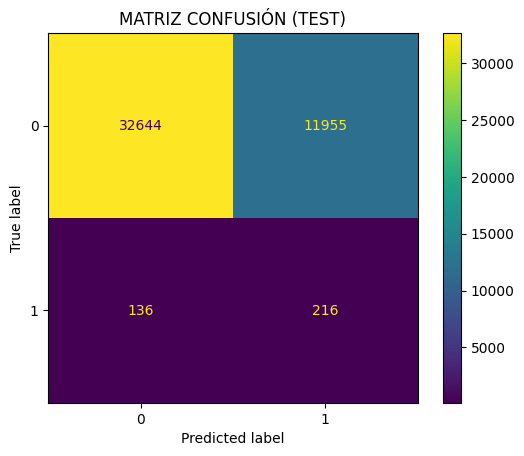

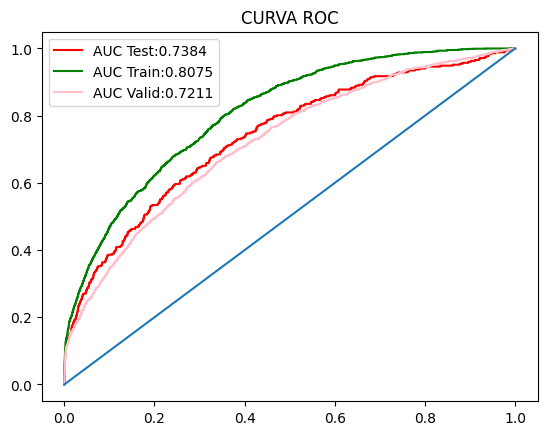

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score,roc_curve,accuracy_score,recall_score,precision_score
from sklearn.metrics import f1_score

sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
val_modelo_hgb_optuna1 = HistGradientBoostingClassifier(**best_params_hgb1)
val_modelo_hgb_optuna1.fit(x_train,y_train,sample_weight=sample_weights)
predicciones_test = val_modelo_hgb_optuna1.predict(x_test)
predicciones_train = val_modelo_hgb_optuna1.predict(x_train)
predicciones_valid = val_modelo_hgb_optuna1.predict(x_valid)
predicciones_prob_test = val_modelo_hgb_optuna1.predict_proba(x_test)
predicciones_prob_train = val_modelo_hgb_optuna1.predict_proba(x_train)
predicciones_prob_valid = val_modelo_hgb_optuna1.predict_proba(x_valid)
tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, predicciones_test).ravel()
tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, predicciones_train).ravel()
tn_valid, fp_valid, fn_valid, tp_valid = confusion_matrix(y_valid, predicciones_valid).ravel()



#Mostrando las métricas
print('AUC-ROC Test:',roc_auc_score(y_test,predicciones_prob_test[:,1] ))
print('AUC-ROC Train:',roc_auc_score(y_train,predicciones_prob_train[:,1]))
print('AUC-ROC Validation:',roc_auc_score(y_valid,predicciones_prob_valid[:,1]))
print('Sensibilidad Test:',recall_score(y_test, predicciones_test, pos_label = 1))
print('Sensibilidad Train:',recall_score(y_train, predicciones_train, pos_label = 1))
print('Sensibilidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 1))
print('Especificidad Test:',recall_score(y_test, predicciones_test, pos_label = 0))
print('Especificidad Train:',recall_score(y_train, predicciones_train, pos_label = 0))
print('Especificidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 0))
print('F1 Score Test:',f1_score(y_test, predicciones_test))
print('F1 Score Train:',f1_score(y_train, predicciones_train))
print('F1 Score Valid:',f1_score(y_valid, predicciones_valid))
print('Tasa de FN Test:', fn_test / (tn_test + fn_test))
print('Tasa de FN Train:', fn_train / (tn_train + fn_train))
print('Tasa de FN Valid:', fn_valid / (tn_valid + fn_valid))
print('Precision Test:', precision_score(y_test, predicciones_test))
print('Precision Train:', precision_score(y_train, predicciones_train))
print('Precision Valid:', precision_score(y_valid, predicciones_valid))

#Matriz de Confusión
cm = confusion_matrix(y_test, predicciones_test)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('MATRIZ CONFUSIÓN (TEST)')
plt.show()


##Curva AUC ROC
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, predicciones_prob_test[:,1])
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, predicciones_prob_train[:,1])
fpr_valid, tpr_valid, thresholds_valid = roc_curve(y_valid, predicciones_prob_valid[:,1])
plt.plot(fpr_test, tpr_test, color = 'red', label = f'AUC Test:{round(roc_auc_score(y_test,predicciones_prob_test[:,1] ),4)}')
plt.plot(fpr_train, tpr_train, color = 'green', label = f'AUC Train:{round(roc_auc_score(y_train,predicciones_prob_train[:,1] ),4)}')
plt.plot(fpr_valid, tpr_valid, color = 'pink', label = f'AUC Valid:{round(roc_auc_score(y_valid,predicciones_prob_valid[:,1] ),4)}')
plt.plot([0, 1], [0, 1])
plt.legend()
plt.title('CURVA ROC')
plt.show()

In [ ]:
df_abr = df_final9[df_final9['FECHA_SNAPSHOT'].isin(pd.to_datetime(['2026-04-01']))].copy()
df_may = df_final9[df_final9['FECHA_SNAPSHOT'].isin(pd.to_datetime(['2026-05-01']))].copy()
pred_abr = val_modelo_hgb_optuna1.predict_proba(df_abr.drop(columns=['FECHA_SNAPSHOT','COD_CLIENTE','FECHA_TARGET','TARGET_CHURN']).copy())
pred_may = val_modelo_hgb_optuna1.predict_proba(df_may.drop(columns=['FECHA_SNAPSHOT','COD_CLIENTE','FECHA_TARGET','TARGET_CHURN']).copy())
print('AUC-ROC Abril:',roc_auc_score(df_abr['TARGET_CHURN'],pred_abr[:,1] ))
print('AUC-ROC Mayo:',roc_auc_score(df_may['TARGET_CHURN'],pred_may[:,1] ))

AUC-ROC Abril: 0.714471845136009
AUC-ROC Mayo: 0.7264727360908614


In [ ]:
variables_importantes1 = [
    "DIAS_DESDE_ULTIMA_COMPRA",
    "DAYS_FIRST_RED",
    "DAYS_LAST_RED",
    "AVG_DIAS_ENTRE_COMPRAS_EVER",
    #"APROX_AGE",
    "q_int_last1m_chat_helpctr",
    "q_int_ever_cshb_error",
    "COUNTRY_1_EXTRANJERO",
    "q_int_last1m_home_showbal",
    "PORC_UTILIZ_3M",
    "q_int_ever_myprf_dropact",
    #"MESES_OB_ANALISIS",
    "q_int_last1m_myprf_dropact",
    "q_int_last1m_home_settings",
    "AMT_DELIVERY_EVER",
    "Q_TC_STATUS_EVER",
    "mobile_brand_name_APPLE",
    "AMT_PURCH_15A22_1M",
    "Q_PAGSERV_EVER",
    "AMT_FARMA_1M",
    "q_int_last1m_home_amtmov",
    "PROFESION_cat_ADMINISTRADOR",
    "AVG_STATEMENT_BALANCE_3M",
    "AVG_DIAS_ENTRE_COMPRAS_LAST3M",
    "Q_MAILING_CUSTIO_EMAIL_OPEN",
    "q_int_ever_home_settings",
    "AVG_CURRENT_BALANCE_1M",
    "MAX_DPD_1M",
    "mobile_brand_name_XIAOMI",
    "Q_MAILING_CUSTIO_EMAIL_DEL",
    "USERDEVICE_PLATFORM_SO_IOS",
    "PORC_UTILIZ_EVER",
    "q_int_ever_notfcrdlim_total",
    "q_int_ever_cshb_success",
    "AMT_ROPA_EVER",
    "AMT_PAYMENT_3M",
    "AMT_CASHBACK_AWARDED_LAST1M",
    "Q_MAILING_CUSTIO_EMAIL_SENT",
    "DAYS_OB_LASTREF",
    "q_int_last1m_home_crdetails",
    "MESES_CON_CONSUMO_10",
    "q_int_ever_pay_yapeok",
    "DAYS_LASTREF_TODATE",
    "PROFESION_cat_RESTO",
    "PORC_UTILIZ_1M",
    "AMT_WE_PURCH_EVER",
    "AMT_PURCH_1M",
    "q_int_ever_sdta_error",
    "DIAS_OB_1RACOMPRA",
    "q_int_last1m_myprf_avatar",
    "DAYS_1STOP_CONV",
    "AMT_PURCH_7A14_1M",
    "DOMAIN_EMAIL_cat_hotmail",
    "AMT_WE_PURCH_3M",
    "MAX_CREDIT_LINE_1M",
    "q_int_ever_pay_home",
    "Q_PURCH_15A22_1M",
    "q_int_ever_bnf_seemore",
    "Q_DELIVERY_EVER",
    "TIEMPO_TOTAL_ONBOARGING_MINUTOS",
    "AMT_DELIVERY_3M",
    "q_int_ever_home_amtmov",
    "AMT_BENEFITS_3M",
    "q_int_last1m_ref_sharecode",
    "q_int_ever_chat_helpctr",
    "MAX_APR_VALUE_EVER",
    "q_int_last1m_home_hidebal",
    "Q_DELIVERY_3M",
    "AVG_STATEMENT_BALANCE_1M",
    "q_int_last1m_myprf_ref",
    "MAX_DPD_EVER",
    "q_int_last1m_ref_bau",
    "Q_REJ_INSFD_EVER",
    "Q_STREAMING_3M",
    "q_int_ever_myprf_avatar",
    "q_int_ever_login_recpasscheck",
    "AMT_PHY_PURCH_1M",
    "AMT_PURCH_7A14_EVER",
    "q_int_ever_sdta_ccd",
    "Q_TECNO_EVER",
    "AMT_PURCH_3M",
    "q_int_last1m_notfcrdlim_75",
    "Q_PHY_PURCH_1M",
    "USERDEVICE_PLATFORM_SO_ANDROID",
    "q_int_ever_home_crdetails",
    "q_int_last1m_bnf_bydept",
    "Q_RESTAUR_EVER",
    "AMT_CASHBACK_REDEEMED_EVER",
    "AVG_STATEMENT_BALANCE_EVER",
    "Q_FARMA_1M",
    "q_int_ever_ref_sharecode",
    "AMT_BENEFITS_EVER",
    "q_int_ever_notfcrdlim_75_off",
    "Q_RESTAUR_3M",
    "q_int_ever_home_hidebal",
    "MESES_DESDE_ULTIMA_COMPRA",
    "AMT_WE_PURCH_1M",
    "AMT_SUPER_EVER",
    "AMT_AUTO_3M",
    "AMT_SUPER_1M",
    "Q_WE_PURCH_1M",
    "MESES_CON_CONSUMO",
    "TOTAL_PRIZE"
]

In [ ]:
x_train_val_exp = x_train[variables_importantes1].copy()
x_test_val_exp = x_test[variables_importantes1].copy()
x_valid_val_exp = x_valid[variables_importantes1].copy()

AUC-ROC Test: 0.7367634555096017
AUC-ROC Train: 0.7934766396792909
AUC-ROC Validation: 0.7217687951927829
Sensibilidad Test: 0.65625
Sensibilidad Train: 0.6880733944954128
Sensibilidad Valid: 0.5560821484992101
Especificidad Test: 0.7204197403529227
Especificidad Train: 0.7216563081962799
Especificidad Valid: 0.7437928500643805
F1 Score Test: 0.035396874042292366
F1 Score Train: 0.040231426491436455
F1 Score Valid: 0.035222013758599124
Tasa de FN Test: 0.003751821648941118
Tasa de FN Train: 0.003686207697669016
Tasa de FN Valid: 0.005067902681840316
Precision Test: 0.018188976377952755
Precision Train: 0.020721502999684244
Precision Valid: 0.018186984938903097


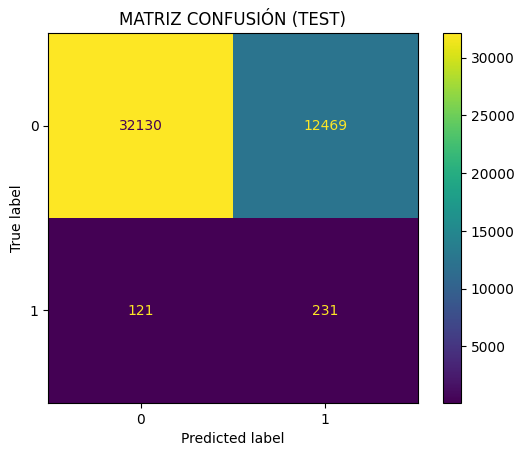

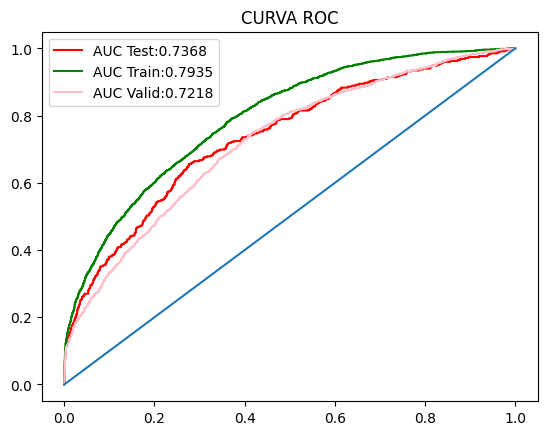

In [ ]:
sample_weights = compute_sample_weight(class_weight="balanced", y=y_train)
val_modelo_hgb_optuna1 = HistGradientBoostingClassifier(**best_params_hgb1)
val_modelo_hgb_optuna1.fit(x_train_val_exp,y_train,sample_weight=sample_weights)
predicciones_test = val_modelo_hgb_optuna1.predict(x_test_val_exp)
predicciones_train = val_modelo_hgb_optuna1.predict(x_train_val_exp)
predicciones_valid = val_modelo_hgb_optuna1.predict(x_valid_val_exp)
predicciones_prob_test = val_modelo_hgb_optuna1.predict_proba(x_test_val_exp)
predicciones_prob_train = val_modelo_hgb_optuna1.predict_proba(x_train_val_exp)
predicciones_prob_valid = val_modelo_hgb_optuna1.predict_proba(x_valid_val_exp)
tn_test, fp_test, fn_test, tp_test = confusion_matrix(y_test, predicciones_test).ravel()
tn_train, fp_train, fn_train, tp_train = confusion_matrix(y_train, predicciones_train).ravel()
tn_valid, fp_valid, fn_valid, tp_valid = confusion_matrix(y_valid, predicciones_valid).ravel()



#Mostrando las métricas
print('AUC-ROC Test:',roc_auc_score(y_test,predicciones_prob_test[:,1] ))
print('AUC-ROC Train:',roc_auc_score(y_train,predicciones_prob_train[:,1]))
print('AUC-ROC Validation:',roc_auc_score(y_valid,predicciones_prob_valid[:,1]))
print('Sensibilidad Test:',recall_score(y_test, predicciones_test, pos_label = 1))
print('Sensibilidad Train:',recall_score(y_train, predicciones_train, pos_label = 1))
print('Sensibilidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 1))
print('Especificidad Test:',recall_score(y_test, predicciones_test, pos_label = 0))
print('Especificidad Train:',recall_score(y_train, predicciones_train, pos_label = 0))
print('Especificidad Valid:',recall_score(y_valid, predicciones_valid, pos_label = 0))
print('F1 Score Test:',f1_score(y_test, predicciones_test))
print('F1 Score Train:',f1_score(y_train, predicciones_train))
print('F1 Score Valid:',f1_score(y_valid, predicciones_valid))
print('Tasa de FN Test:', fn_test / (tn_test + fn_test))
print('Tasa de FN Train:', fn_train / (tn_train + fn_train))
print('Tasa de FN Valid:', fn_valid / (tn_valid + fn_valid))
print('Precision Test:', precision_score(y_test, predicciones_test))
print('Precision Train:', precision_score(y_train, predicciones_train))
print('Precision Valid:', precision_score(y_valid, predicciones_valid))

#Matriz de Confusión
cm = confusion_matrix(y_test, predicciones_test)
disp = ConfusionMatrixDisplay(cm)
disp.plot()
plt.title('MATRIZ CONFUSIÓN (TEST)')
plt.show()


##Curva AUC ROC
fpr_test, tpr_test, thresholds_test = roc_curve(y_test, predicciones_prob_test[:,1])
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, predicciones_prob_train[:,1])
fpr_valid, tpr_valid, thresholds_valid = roc_curve(y_valid, predicciones_prob_valid[:,1])
plt.plot(fpr_test, tpr_test, color = 'red', label = f'AUC Test:{round(roc_auc_score(y_test,predicciones_prob_test[:,1] ),4)}')
plt.plot(fpr_train, tpr_train, color = 'green', label = f'AUC Train:{round(roc_auc_score(y_train,predicciones_prob_train[:,1] ),4)}')
plt.plot(fpr_valid, tpr_valid, color = 'pink', label = f'AUC Valid:{round(roc_auc_score(y_valid,predicciones_prob_valid[:,1] ),4)}')
plt.plot([0, 1], [0, 1])
plt.legend()
plt.title('CURVA ROC')
plt.show()

In [ ]:
df_abr = df_final9[df_final9['FECHA_SNAPSHOT'].isin(pd.to_datetime(['2026-04-01']))].copy()
df_may = df_final9[df_final9['FECHA_SNAPSHOT'].isin(pd.to_datetime(['2026-05-01']))].copy()
pred_abr = val_modelo_hgb_optuna1.predict_proba(df_abr[variables_importantes1].copy())
pred_may = val_modelo_hgb_optuna1.predict_proba(df_may[variables_importantes1].copy())
print('AUC-ROC Abril:',roc_auc_score(df_abr['TARGET_CHURN'],pred_abr[:,1] ))
print('AUC-ROC Mayo:',roc_auc_score(df_may['TARGET_CHURN'],pred_may[:,1] ))

AUC-ROC Abril: 0.7281064786124553
AUC-ROC Mayo: 0.7178368287999648
